# Notebook 09: The Learner Class - Building a Training Framework

---

## What This Notebook Covers

This notebook builds a **Learner** class - a flexible framework for training neural networks. This is similar to what frameworks like fastai, PyTorch Lightning, and Keras provide. We will learn:

1. **Basic Learner Class** - Encapsulating the training loop
2. **Callbacks System** - Customizing behavior at any point in training
3. **Metrics** - Tracking accuracy, loss, and other measurements
4. **Flexible Architecture** - Using callbacks for everything
5. **Special Learners** - TrainLearner and MomentumLearner
6. **Learning Rate Finder** - Automatically finding optimal learning rate

---

## Why Build a Learner Framework?

Writing training loops from scratch every time is:
- **Error-prone** - Easy to forget things like `model.eval()` or `torch.no_grad()`
- **Repetitive** - The same boilerplate code again and again
- **Inflexible** - Hard to add features like logging, early stopping, etc.

A **Learner framework** provides:
- **Encapsulation** - All training logic in one place
- **Reusability** - Use the same code for different models
- **Extensibility** - Add features via callbacks without changing core code

---

### 🎮 About the interactive visualizations in this notebook

Scattered through this notebook are cells marked **🎮 Interactive**. Each one loads a small, self-contained HTML + JavaScript visualization inside an isolated `<iframe>` — just **run the cell** and use the buttons and sliders.

Every visualization supports:

- **Step ▶** — advance one stage at a time,
- **Auto / Pause** — play the whole animation, with a **speed slider**,
- **clicking a stage** to jump straight to it (the matching code highlights), and
- **Reset ↺**.

They load from the published copy on **GitHub Pages**, so they need an internet connection (the 3D Learning-Rate-Finder also pulls `three.js` from a CDN). **Run the one-time `show_viz()` setup cell just below once**, then run any 🎮 Interactive cell to display its visualization full width — the iframe auto-fits its height. Standalone copies of every visualization live in the **`interactive_viz/`** folder next to this notebook.

---

In [ ]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> shown FULL WIDTH that
# auto-fits its content height. No inline base64 -- the visualizations are read
# from GitHub, so the cells stay short.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="700px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;display:block;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="viz-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

# Part 1: Setup and Imports

---

In [ ]:
# =====================================================
# CORE PYTHON IMPORTS
# =====================================================

import math                            # Mathematical functions
from collections.abc import Mapping    # For checking dictionary types
from operator import attrgetter        # Get attributes by name
from functools import partial          # Partial function application
from copy import copy                  # Shallow copying
from contextlib import contextmanager  # Context manager utilities

# =====================================================
# PYTORCH IMPORTS
# =====================================================

import torch
from torch import nn, tensor, optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF

# =====================================================
# VISUALIZATION
# =====================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# =====================================================
# DATA LOADING
# =====================================================

from datasets import load_dataset
from torch.utils.data import DataLoader, default_collate

In [ ]:
def collate_dict(ds):
    """
    Create a collate function for dictionary-based datasets.
    
    Returns a function that:
        1. Extracts 'image' and 'label' from each sample
        2. Stacks them into batch tensors
    """
    def _collate(batch):
        # Stack all images: list of (1,28,28) -> (batch_size, 1, 28, 28)
        images = torch.stack([b['image'] for b in batch])
        # Stack all labels: list of ints -> (batch_size,)
        labels = torch.tensor([b['label'] for b in batch])
        return images, labels
    return _collate

Instead of the above function, the following function will work also without the argument ds inside collate_dict function.

In [ ]:
def collate_dict():          # no parameter at all
    def _collate(batch):
        images = torch.stack([b['image'] for b in batch])
        labels = torch.tensor([b['label'] for b in batch])
        return images, labels
    return _collate

In [ ]:
# =====================================================
# CONFIGURATION
# =====================================================

# PyTorch display settings
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)

# Reproducibility
torch.manual_seed(1)

# Visualization settings
mpl.rcParams['image.cmap'] = 'gray'

# Suppress warnings
import logging
logging.disable(logging.WARNING)

In [10]:
# =====================================================
# DEVICE SELECTION
# =====================================================

if torch.backends.mps.is_available():
    def_device = 'mps'
elif torch.cuda.is_available():
    def_device = 'cuda'
else:
    def_device = 'cpu'

print(f"Using device: {def_device}")

Using device: cuda


In [11]:
# =====================================================
# HELPER FUNCTIONS
# =====================================================

def to_device(x, device=def_device):
    """
    Move tensors or collections of tensors to specified device.

    Handles:
    - Single tensors
    - Dictionaries of tensors
    - Lists/tuples of tensors
    """
    if isinstance(x, torch.Tensor):
        return x.to(device)
    if isinstance(x, Mapping):
        return {k: to_device(v, device) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(to_device(o, device) for o in x)
    return x

def to_cpu(x):
    """
    Move tensors to CPU and detach from computation graph.

    Used for metrics calculation and logging.
    Also converts float16 to float32 for numerical stability.
    """
    if isinstance(x, Mapping):
        return {k: to_cpu(v) for k, v in x.items()}
    if isinstance(x, list):
        return [to_cpu(o) for o in x]
    if isinstance(x, tuple):
        return tuple(to_cpu(list(x)))
    res = x.detach().cpu()
    return res.float() if res.dtype == torch.float16 else res

# Helper to store attributes
def store_attr(names=None, self=None, **attrs):
    """
    Store function arguments as instance attributes.

    This is a simplified version of fastcore's store_attr.
    When called in __init__, it stores all arguments as self.arg_name.
    """
    # Import the inspect module to look at the code's current state (the stack)
    import inspect
    # If the class instance 'self' wasn't passed, we need to find it automatically
    if self is None:
        # Get the 'frame' (the environment) of the function that called store_attr
        frame = inspect.currentframe().f_back
        # Look inside that caller's local variables to find the object instance named 'self'
        self = frame.f_locals['self']
        # If the user didn't specify which names to store, we store everything available
        if names is None:
            # Collect every variable name in the caller's function, but skip 'self' itself
            names = [k for k in frame.f_locals.keys() if k != 'self']
        # Loop through each variable name we want to save into the object
        for n in names:
            # Dynamically set the attribute: self.variable_name = variable_value
            setattr(self, n, frame.f_locals[n])
    # Also handle any extra named arguments (like store_attr(a=1)) passed directly
    for k, v in attrs.items():
        # Store these extra key-value pairs as attributes on the object
        setattr(self, k, v)

# Deep Dive: `store_attr` — The Attribute Storage Helper

---

## The Problem `store_attr` Solves

When you write a Python class, you almost always have an `__init__` method that looks like this:

```python
class Learner:
    def __init__(self, model, dls, loss_func, lr, opt_func):
        self.model = model           # Repetitive!
        self.dls = dls               # Repetitive!
        self.loss_func = loss_func   # Repetitive!
        self.lr = lr                 # Repetitive!
        self.opt_func = opt_func     # Repetitive!
```

Every single argument is being copied to `self` with the **exact same name**. This is tedious, error-prone, and violates the DRY principle (Don't Repeat Yourself). Imagine a class with 15 parameters — you'd write 15 nearly identical lines.

**`store_attr` automates this entire process.** With it, you just write:

```python
class Learner:
    def __init__(self, model, dls, loss_func, lr, opt_func):
        store_attr()  # One line does all the work!
```

Now let's break down **exactly** how it achieves this magic.

---

## The Complete Code

```python
def store_attr(names=None, self=None, **attrs):
    import inspect
    if self is None:
        frame = inspect.currentframe().f_back
        self = frame.f_locals['self']
        if names is None:
            names = [k for k in frame.f_locals.keys() if k != 'self']
        for n in names:
            setattr(self, n, frame.f_locals[n])
    for k, v in attrs.items():
        setattr(self, k, v)
```

---

## Line-by-Line Explanation

---

### Line 1: The Function Signature

```python
def store_attr(names=None, self=None, **attrs):
```

**What it does:** Defines a function called `store_attr` with three parameters.

**Parameter breakdown:**

| Parameter | Default | Purpose |
|-----------|---------|---------|
| `names` | `None` | Optional list of specific argument names to store. If `None`, store ALL arguments. |
| `self` | `None` | The object instance to store attributes on. If `None`, it will figure it out automatically. |
| `**attrs` | (empty dict) | Extra keyword arguments to store directly as attributes. |

**Why these defaults?** The beauty is that you can call `store_attr()` with **no arguments at all** inside an `__init__`, and it will automatically figure out what to store and where. The defaults of `None` trigger the "auto-detect" behavior.

**The `**attrs` parameter** uses Python's "keyword argument packing" — any extra `key=value` pairs you pass will be collected into a dictionary called `attrs`. For example:
```python
store_attr(extra_thing=42)  # attrs = {'extra_thing': 42}
```

---

### Line 2: Importing the `inspect` Module

```python
    import inspect
```

**What it does:** Imports Python's built-in `inspect` module, which lets you examine live objects, including the **call stack** (the chain of functions that called each other to get to this point).

**Why import inside the function?** This is a design choice — it keeps the import local so it only loads when `store_attr` is actually called. It also makes the function self-contained (you can copy-paste it anywhere without worrying about top-level imports).

**What is `inspect`?** Think of it like X-ray vision for Python. It lets you look "behind the scenes" at:
- What function called this function
- What local variables exist in that function
- What arguments were passed to that function

This is the key to the "magic" — `store_attr` uses `inspect` to look back at the `__init__` that called it and read its arguments.

---

### Line 3: Check if `self` Was Provided

```python
    if self is None:
```

**What it does:** Checks whether the caller explicitly passed a `self` (the object instance) to `store_attr`. This determines which of two modes the function operates in.

---

#### Mode 1: `self` IS `None` — Auto-Detect Mode (The Common Case)

This happens when you call `store_attr()` with **no arguments** inside `__init__`. The function will use stack frame introspection to automatically figure out which object to attach attributes to and which arguments to store.

```python
class Learner:
    def __init__(self, model, dls, loss_func, lr, opt_func=optim.SGD):
        store_attr()  # ← self=None (default), names=None (default)
        
        # store_attr internally does:
        #   1. Looks back at __init__'s stack frame
        #   2. Finds 'self' = the Learner instance being created
        #   3. Finds all other locals: ['model', 'dls', 'loss_func', 'lr', 'opt_func']
        #   4. Sets each one: self.model = model, self.dls = dls, etc.

# Usage:
learn = Learner(my_model, my_dls, F.cross_entropy, lr=0.2)
print(learn.model)      # ✓ works
print(learn.lr)         # ✓ works
print(learn.loss_func)  # ✓ works
```

You can also use this mode with a **specific list of names** to store only some arguments:

```python
class Learner:
    def __init__(self, model, dls, loss_func, lr, opt_func=optim.SGD):
        store_attr(['model', 'lr'])  # ← self=None, but names=['model', 'lr']
        
        # Only stores self.model and self.lr
        # dls, loss_func, opt_func are NOT stored

learn = Learner(my_model, my_dls, F.cross_entropy, lr=0.2)
print(learn.model)      # ✓ works
print(learn.lr)         # ✓ works
print(learn.loss_func)  # ✗ AttributeError! Was not stored.
```

---

#### Mode 2: `self` is NOT `None` — Explicit Mode

This happens when you **manually pass** the object instance. The function skips all the stack frame introspection and directly stores the `**attrs` keyword arguments on the given object. This is useful **outside** of `__init__`, or when attaching attributes to an object you already have a reference to.

```python
class Config:
    pass

my_config = Config()

# Explicitly tell store_attr WHICH object to attach to and WHAT to attach
store_attr(self=my_config, temperature=0.7, top_k=50, model_name="gpt2")

# Now my_config has these attributes:
print(my_config.temperature)  # 0.7
print(my_config.top_k)        # 50
print(my_config.model_name)   # "gpt2"
```

**No stack frame inspection happens here** — you told it exactly what object (`my_config`) and exactly what attributes (`temperature`, `top_k`, `model_name`) to store, so there's nothing to auto-detect.

---

#### Side-by-Side Summary

| | **Mode 1: `self` is `None`** | **Mode 2: `self` is NOT `None`** |
|---|---|---|
| **When** | `store_attr()` inside `__init__` | `store_attr(self=obj, key=val)` anywhere |
| **Finds object via** | Stack frame introspection | Directly provided by caller |
| **Finds names via** | Reading caller's local variables | Only uses `**attrs` keywords |
| **Uses `inspect`?** | Yes | No |
| **Typical use** | Inside `__init__` to auto-store all args | Outside `__init__` to attach extra attributes |

---

### Line 4: Get the Caller's Stack Frame

```python
        frame = inspect.currentframe().f_back
```

**This is the most important and "magical" line.** Let's break it into two parts:

#### Part A: `inspect.currentframe()`

This returns the **current stack frame** — a Python object representing the state of `store_attr` itself while it's running. A stack frame contains everything about a function call: its local variables, its arguments, where it was called from, etc.

#### Part B: `.f_back`

This moves **one step back** up the call stack — to the function that **called** `store_attr`. In our use case, that's the `__init__` method.

**Visual analogy — the call stack:**

```
┌─────────────────────────────┐
│  store_attr()               │  ← inspect.currentframe() points HERE
│  (running right now)        │
├─────────────────────────────┤
│  __init__(self, model, dls) │  ← .f_back points HERE (the caller!)
│  (called store_attr)        │
├─────────────────────────────┤
│  main code                  │  
│  (created the object)       │
└─────────────────────────────┘
```

So `frame` now points to the `__init__` method's execution environment. Through this frame, we can access **all the local variables** that exist inside that `__init__`, including `self`, `model`, `dls`, `loss_func`, etc.

---

### Line 5: Extract `self` from the Caller

```python
        self = frame.f_locals['self']
```

**What it does:** From the caller's stack frame (`__init__`), it reads the dictionary of local variables (`f_locals`) and extracts the value of `'self'`.

**Why?** Remember, inside `__init__`, the first parameter is always `self` — the instance being constructed. We need this object so we can attach attributes to it. By reading it from the frame, `store_attr` doesn't need you to pass `self` explicitly.

**`f_locals` is a dictionary** that maps variable names to their values. If `__init__` was called like `Learner(model, dls, F.cross_entropy, lr=0.2)`, then `f_locals` looks like:

```python
{
    'self': <Learner object at 0x...>,   # The instance being created
    'model': <Sequential model>,          # The model argument
    'dls': <DataLoaders object>,          # The dataloaders argument
    'loss_func': <function cross_entropy>, # The loss function
    'lr': 0.2,                            # The learning rate
    'opt_func': <class 'SGD'>             # The optimizer class
}
```

So `frame.f_locals['self']` gives us the actual Learner object that's being initialized.

---

### Lines 6-7: Auto-Detect Which Names to Store

```python
        if names is None:
            names = [k for k in frame.f_locals.keys() if k != 'self']
```

**What it does:** If no specific `names` were provided (the common case), it automatically builds a list of ALL variable names from the caller's local scope, **excluding** `'self'`.

**Line 7 in detail — the list comprehension:**

```python
names = [k for k in frame.f_locals.keys() if k != 'self']
```

This says: "For every key `k` in the caller's local variables, include it in the list — but skip `'self'`."

**Why skip `'self'`?** Because `self.self = self` would be circular and nonsensical. We want to store the *arguments*, not the instance itself.

**Continuing our example,** `names` would become:

```python
['model', 'dls', 'loss_func', 'lr', 'opt_func']
```

**What if you only want to store SOME attributes?** You can pass a specific list:

```python
store_attr(['model', 'lr'])  # Only stores self.model and self.lr
```

---

### Lines 8-9: Store Each Attribute on the Object

```python
        for n in names:
            setattr(self, n, frame.f_locals[n])
```

**What it does:** Loops through each name and stores the corresponding value as an attribute on `self`.

**Breaking down `setattr(self, n, frame.f_locals[n])`:**

- `setattr(object, name, value)` is a built-in Python function that sets an attribute on an object. It's equivalent to writing `object.name = value`, but the attribute name can be a **variable** (a string).
- `self` — the object to set the attribute on (our Learner instance)
- `n` — the attribute name as a string (e.g., `'model'`)
- `frame.f_locals[n]` — the actual value from the caller's scope (e.g., the actual model object)

**Iteration example:**

| Iteration | `n` | `frame.f_locals[n]` | Equivalent To |
|-----------|-----|---------------------|---------------|
| 1 | `'model'` | `<Sequential model>` | `self.model = model` |
| 2 | `'dls'` | `<DataLoaders>` | `self.dls = dls` |
| 3 | `'loss_func'` | `cross_entropy` | `self.loss_func = loss_func` |
| 4 | `'lr'` | `0.2` | `self.lr = 0.2` |
| 5 | `'opt_func'` | `SGD` | `self.opt_func = SGD` |

**After this loop completes, the object has all five attributes set — exactly as if you'd written them out manually!**

---

### Lines 10-11: Handle Extra Keyword Arguments

```python
    for k, v in attrs.items():
        setattr(self, k, v)
```

**What it does:** Stores any additional keyword arguments (`**attrs`) as attributes on the object.

**Important:** This code runs **outside** the `if self is None:` block, so it runs in ALL cases — both auto-detect mode and explicit mode.

**When is this useful?** When you want to store extra attributes that aren't function parameters:

```python
def __init__(self, model, dls):
    store_attr(extra_info="created at startup", version=2)
    # Now self.model, self.dls, self.extra_info, and self.version all exist
```

Or when you use `store_attr` outside of `__init__` by passing `self` explicitly:

```python
store_attr(self=my_object, temperature=0.7, top_k=50)
# Sets my_object.temperature = 0.7 and my_object.top_k = 50
```

---

## Complete Execution Walkthrough

Let's trace through exactly what happens when this code runs:

```python
class Learner:
    def __init__(self, model, dls, loss_func, lr, opt_func=optim.SGD):
        store_attr()

# When you create a Learner:
learn = Learner(my_model, my_dls, F.cross_entropy, lr=0.2)
```

### Step-by-step execution:

```
1. Python calls __init__(self=<new Learner>, model=my_model, dls=my_dls, 
                         loss_func=F.cross_entropy, lr=0.2, opt_func=SGD)

2. __init__ calls store_attr(names=None, self=None)
   (all defaults since we passed no arguments)

3. import inspect                          → loads the inspect module

4. if self is None:                        → True (we didn't pass self)

5. frame = inspect.currentframe().f_back   → frame now points to __init__

6. self = frame.f_locals['self']           → self = the new Learner object

7. if names is None:                       → True (we didn't pass names)

8. names = [k for k in frame.f_locals.keys() if k != 'self']
   → names = ['model', 'dls', 'loss_func', 'lr', 'opt_func']

9. Loop:
   setattr(self, 'model', my_model)        → self.model = my_model         ✓
   setattr(self, 'dls', my_dls)            → self.dls = my_dls             ✓
   setattr(self, 'loss_func', cross_entropy)→ self.loss_func = cross_entropy ✓
   setattr(self, 'lr', 0.2)               → self.lr = 0.2                  ✓
   setattr(self, 'opt_func', SGD)          → self.opt_func = SGD            ✓

10. for k, v in attrs.items():             → attrs is empty {}, so this 
                                              loop does nothing

11. Done! The Learner object now has all 5 attributes set.
```

---

## How `store_attr` Is Used in This Notebook

In the fast.ai Learner framework notebook, `store_attr` (or `fc.store_attr()` from the `fastcore` library) is used in the Learner class and various callbacks to eliminate boilerplate:

```python
# WITHOUT store_attr (verbose, repetitive):
class Learner:
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD):
        self.model = model
        self.dls = dls
        self.loss_func = loss_func
        self.lr = lr
        self.cbs = cbs
        self.opt_func = opt_func

# WITH store_attr (clean, one line):
class Learner:
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD):
        store_attr()
```

Both versions produce **identical results** — the Learner object ends up with `.model`, `.dls`, `.loss_func`, `.lr`, `.cbs`, and `.opt_func` attributes. The `store_attr` version is just cleaner and less error-prone.

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **`inspect` module** | Line 2, 4 | Examines the runtime call stack |
| **Stack frames** | Line 4 | Represents a function's execution state |
| **`f_locals`** | Lines 5, 7, 9 | Dictionary of a frame's local variables |
| **`setattr()`** | Lines 9, 11 | Dynamically sets an attribute on an object |
| **`**kwargs`** | Line 1 | Collects extra keyword arguments into a dict |
| **List comprehension** | Line 7 | Concisely builds a filtered list |
| **Default parameters** | Line 1 | Enables the "call with no args" convenience |

---

## Summary

`store_attr` is a **metaprogramming utility** that uses Python's introspection capabilities to automatically store function arguments as object attributes. It eliminates the repetitive `self.x = x` pattern by:

1. **Looking back** at the calling function's stack frame
2. **Finding** the `self` object and all other local variables
3. **Setting** each variable as an attribute on the object

This is a simplified version of `fastcore.store_attr`, which the fast.ai library uses extensively to keep code clean and focused on logic rather than boilerplate.

---

# Part 2: Loading Fashion MNIST

---

We'll use Fashion MNIST again, but this time with a simple fully-connected model (for speed).

In [12]:
# =====================================================
# LOAD DATASET
# =====================================================

x, y = 'image', 'label'
name = "zalando-datasets/fashion_mnist"
from datasets import load_dataset

# Loads the dataset from Hugging Face; returns a DatasetDict containing Dataset objects for each split.
dsd = load_dataset(name)

print(f"Loaded: {name}")
print(f"Train: {len(dsd['train'])}, Test: {len(dsd['test'])}")

Loaded: zalando-datasets/fashion_mnist
Train: 60000, Test: 10000


In [ ]:
# =====================================================
# TRANSFORMATION: FLATTEN IMAGES FOR MLP
# =====================================================

# For a simple MLP (Multi-Layer Perceptron), we flatten 28x28 -> 784
# This is different from CNNs which use 2D convolutions

def inplace(f):
    """
    A 'decorator' is a special type of function in Python that 'wraps' another function 
    to extend or change its behavior without modifying its source code directly.
    
    This specific decorator, 'inplace', is used to ensure that a function which 
    modifies an object (like a dictionary or list) returns that object after 
    the modification is complete.
    
    Args:
        f: This is the original function that we are decorating.
    """
    
    # We define an internal function (often called a 'wrapper') that will 
    # actually be executed whenever the decorated function is called.
    def _inner(b):
        """
        The wrapper function that handles the logic.
        
        Args:
            b: This represents the data or object (e.g., a batch of data) 
               being passed into the function.
        """
        # Step 1: Run the original function 'f' on the input 'b'.
        # We assume 'f' modifies 'b' internally (in-place).
        f(b)
        
        # Step 2: Explicitly return the modified object 'b'.
        # This is helpful because it allows us to see the result of the 
        # transformation immediately or chain multiple operations together.
        return b
        
    # Finally, the decorator returns this new '_inner' function.
    # From now on, whenever you call the decorated function, you are 
    # actually calling '_inner'.
    return _inner

@inplace
def transformi(b):
    """
    Transform images to flattened tensors.
    
    Steps:
    1. TF.to_tensor: PIL Image -> (1, 28, 28) tensor
    2. torch.flatten: (1, 28, 28) -> (784,) flat vector
    
    This prepares data for fully-connected (Linear) layers.
    """
    b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]

# Deep Dive: The `@inplace` Decorator and `transformi`

---

## The Problem

Our `transformi` function takes a batch of data (a dictionary), grabs the images, converts each one to a tensor, and flattens it from `(1, 28, 28)` to `(784,)`. It modifies the dictionary directly — this is called **in-place modification**:

```python
def transformi(b):
    b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]
```

This works fine internally — `b` gets modified. But there's a subtle bug: **this function returns nothing**. In Python, a function that doesn't explicitly return something returns `None` by default.

Why does that matter? Because later, when we use this function with HuggingFace's `with_transform`:

```python
tds = dsd.with_transform(transformi)
```

...HuggingFace's internal code does something like this behind the scenes:

```python
data = transformi(raw_batch)
```

It calls `transformi` and **uses whatever comes back**. Without a return statement, `data` becomes `None` — the transformed images are silently lost, even though `b` was correctly modified. We never see this assignment in our notebook; it happens inside HuggingFace's library code. But that library code depends on `transformi` returning the modified data.

We could fix this by simply adding `return b` at the end of `transformi`. But instead, the notebook uses a more elegant, reusable solution: a **decorator**.

---

## What Is a Decorator?

A decorator is a function that **wraps** another function to modify its behavior — without changing the original function's source code. You apply it with the `@` symbol:

```python
@inplace
def transformi(b):
    b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]
```

When Python sees `@inplace` above `def transformi(b)`, it does this behind the scenes:

```python
transformi = inplace(transformi)
```

So `transformi` (the original function) is passed as the argument `f` to `inplace`. After this line, the name `transformi` **no longer points to the original function** — it now points to whatever `inplace` returns.

---

## How `inplace` Works

```python
def inplace(f):              # f = the original transformi function
    def _inner(b):           # define a new wrapper function
        f(b)                 # Step 1: call original transformi(b) — modifies b in-place
        return b             # Step 2: return b (which the original forgot to do!)
    return _inner            # replace transformi with this new _inner function
```

After the decorator runs, `transformi` now points to `_inner`. So whenever anything calls `transformi(b)`, it's actually calling `_inner(b)`, which:

1. Runs the original transformation (modifying `b` in-place)
2. Returns `b` — the one thing the original forgot to do

---

## Before vs. After the Decorator

**Without `@inplace`:**

```python
data = transformi(raw_batch)    # data = None (transformation lost!)
```

The batch gets modified internally, but since `transformi` returns `None`, any code that relies on the return value gets nothing.

**With `@inplace`:**

```python
data = transformi(raw_batch)    # data = raw_batch (modified and returned!)
```

Now HuggingFace's `with_transform` gets the actual modified batch back, and everything works.

---

## Why Use a Decorator Instead of Just Adding `return b`?

You absolutely could just write:

```python
def transformi(b):
    b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]
    return b   # simple fix
```

But the decorator approach has an advantage: **reusability**. If you have many functions that modify data in-place but forget to return it, you can slap `@inplace` on each one instead of remembering to add `return b` every time. It's a pattern — write once, use everywhere.

---

## The Complete Flow

Putting it all together, here is the full chain from raw data to batched tensors:

```python
# 1. @inplace wraps transformi so it returns the modified batch
@inplace
def transformi(b):
    b[x] = [torch.flatten(TF.to_tensor(o)) for o in b[x]]

# 2. with_transform tells the dataset: "call transformi on data when accessed"
tds = dsd.with_transform(transformi)

# 3. DataLoaders create batched iterators over the transformed data
dls = DataLoaders.from_dd(tds, bs)

# 4. When we iterate, the DataLoader:
#    a) Grabs 1024 raw samples from tds
#    b) HuggingFace internally calls transformi(raw_batch) → gets modified batch back
#    c) Passes the batch to collate_fn (_collate) → stacks into tensors
#    d) Returns (xb, yb)
xb, yb = next(iter(dls.train))
# xb shape: (1024, 784)  — 1024 flattened images
# yb shape: (1024,)       — 1024 labels
```"

In [14]:
# =============================================================================
# DATA LOADERS SETUP
# =============================================================================
# In deep learning, we don't feed the entire dataset into the model at once
# because it wouldn't fit in memory. Instead, we break it into small "batches".
# This section defines a structure to manage these batches for both training
# and validation (testing).

# 1. Configuration Constants
bs = 1024  # 'bs' stands for Batch Size. We will process 1024 images at a time.
           # Larger batches can speed up training if your hardware (GPU) allows.

# 2. Prepare the Dataset
# 'dsd' is our DatasetDict. 'with_transform' applies a function (transformi)
# on-the-fly whenever data is requested, converting raw data into tensors.
tds = dsd.with_transform(transformi)

class DataLoaders:
    """
    A DataLoaders object is a simple container that holds two things:
    1. A 'train' DataLoader: Used to teach the model.
    2. A 'valid' DataLoader: Used to check how well the model is learning.
    """

    def __init__(self, train, valid):
        """
        The __init__ method (constructor) initializes the object.
        - train: The data stream for the training set.
        - valid: The data stream for the validation/test set.
        """
        self.train = train
        self.valid = valid

    # @classmethod allows to call from dd with . as in DataLoaders.from_dd
    # instead of creating an instance of DataLoaders first and then calling the method
    @classmethod
    def from_dd(cls, dd, batch_size, num_workers=0):
        """
        EXPLAINING THE @classmethod DECORATOR:
        Normally, methods inside a class operate on an 'instance' (a specific object you've
        already created), which is why they usually start with 'self'.

        However, a @classmethod operates on the 'Class' itself (represented by 'cls').
        This is useful for creating 'Factory Methods'—functions that create and return
        a new instance of the class for you.

        Instead of manually creating training and validation loaders and then passing them
        to DataLoaders(), we call `DataLoaders.from_dd(...)` and let this method handle the setup.



        ARGUMENTS:
        - dd: The 'DatasetDict'. This is a container (like a dictionary) that holds our
          'train' and 'test' (validation) datasets.
        - batch_size: The number of items (images) to group together in a single batch.
        - num_workers: The number of CPU processes to use for loading data in parallel.
          '0' means everything happens in the main process (safest for Windows/beginners).
        """

        # 1. GENERATE DATALOADERS USING LIST COMPREHENSION
        # We iterate through every dataset (ds) inside the DatasetDict (dd.values()).
        # For each dataset, we create a 'DataLoader' object.
        #
        # A DataLoader is a "smart iterator" that knows how to:
        #   a) Shuffle the data (if requested).
        #   b) Group items into batches of 'batch_size'.
        #   c) Use 'collate_fn' to stack individual dictionary items into actual Tensors.
        #
        # 'collate_dict(ds)' is a helper function that tells the loader exactly how
        # to format the data so the model can read it correctly.
        loaders = [
            DataLoader(ds, batch_size, num_workers=num_workers, collate_fn=collate_dict())
            for ds in dd.values()
        ]

        # 2. CREATE AND RETURN THE DATALOADERS INSTANCE
        # 'cls' refers to the DataLoaders class itself.
        # The '*' symbol is the 'unpacking operator'.
        # Since 'loaders' is a list (e.g., [train_loader, valid_loader]),
        # 'cls(*loaders)' is equivalent to calling 'DataLoaders(train_loader, valid_loader)'.
        # This passes our newly created loaders into the __init__ method defined above.
        return cls(*loaders)


# =============================================================================
# EXECUTION & TESTING
# =============================================================================

# Create the DataLoaders instance using our class method.
# num_workers=0 means the main process handles data loading (safest for beginners/Windows).
dls = DataLoaders.from_dd(tds, bs, num_workers=0)

# To verify everything works, we manually pull one batch from the training set:
dt = dls.train             # Access the training DataLoader
it = iter(dt)              # Create an 'iterator' (a pointer to the data stream)
xb, yb = next(it)          # Grab the very 'next' (first) batch of data

# xb: The batch of input data (images). Shape will be [1024, Channels, Height, Width].
# yb: The batch of target labels.
print(f"Batch shape (Images): {xb.shape}")
print(f"First 10 Labels in batch: {yb[:10]}")

Batch shape (Images): torch.Size([1024, 784])
First 10 Labels in batch: tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5])


# Deep Dive: DataLoaders Setup — Batching Data for Training

---

## The Problem This Code Solves

A typical deep learning dataset like Fashion MNIST has **60,000 training images**. You cannot feed all 60,000 images into your GPU at once — it would run out of memory. Even if it could fit, processing everything at once gives poor gradient updates (the math of why is beyond this notebook, but trust this for now).

The solution is **batching**: split your data into small groups (e.g., 1,024 images each), feed one group at a time, update the model, then feed the next group. One full pass through all groups = one **epoch**.

This code builds the infrastructure to manage that batching process for both training data and validation data.

---

## The Complete Code

```python
bs = 1024
tds = dsd.with_transform(transformi)

class DataLoaders:
    def __init__(self, train, valid):
        self.train = train
        self.valid = valid
    
    @classmethod
    def from_dd(cls, dd, batch_size, num_workers=0):
        loaders = [
            DataLoader(ds, batch_size, num_workers=num_workers, collate_fn=collate_dict(ds)) 
            for ds in dd.values()
        ]
        return cls(*loaders)

dls = DataLoaders.from_dd(tds, bs, num_workers=0)

dt = dls.train
it = iter(dt)
xb, yb = next(it)

print(f"Batch shape (Images): {xb.shape}") 
print(f"First 10 Labels in batch: {yb[:10]}")
```

---

## Section 1: Configuration

---

### Line 1: Setting the Batch Size

```python
bs = 1024
```

**What it does:** Creates a variable `bs` (short for **B**atch **S**ize) and sets it to 1,024.

**What does this number mean?** During training, instead of showing the model all 60,000 images at once, we show it 1,024 images at a time. After the model looks at those 1,024 images and learns from them (one "batch"), we show it the next 1,024, and so on.

**How many batches per epoch?**

```
60,000 images ÷ 1,024 per batch ≈ 59 batches per epoch
```

**How to choose this number:**

| Batch Size | Trade-off |
|------------|-----------|
| **Smaller** (32, 64) | Uses less GPU memory. Noisier gradients, which can sometimes help find better solutions. Slower per epoch because more batches. |
| **Larger** (512, 1024) | Uses more GPU memory. Smoother gradients. Faster per epoch because fewer batches. |
| **Too large** | Crashes with "CUDA out of memory" error. |

1,024 is a reasonable choice for Fashion MNIST on most modern GPUs because these are small (28×28) grayscale images.

---

### Line 2: Applying Transformations to the Dataset

```python
tds = dsd.with_transform(transformi)
```

**What it does:** Takes the raw dataset (`dsd`) and wraps it with a transformation function (`transformi`) that will be applied **on-the-fly** every time data is loaded.

**Breaking it down:**

- `dsd` — This is a `DatasetDict` from the Hugging Face `datasets` library that was loaded earlier in the notebook. It contains two splits:
  ```python
  dsd = {
      'train': <Dataset with 60,000 samples>,
      'test':  <Dataset with 10,000 samples>
  }
  ```
  Each sample is a dictionary like `{'image': <PIL Image>, 'label': 5}`.

- `.with_transform(transformi)` — This does **NOT** transform the data right now. Instead, it says: "Whenever someone asks for data from this dataset, run `transformi` on it first, then return the result." This is called **lazy transformation** — it saves memory because you don't store 60,000 transformed images upfront.

- `transformi` — Defined earlier in the notebook, it converts PIL images into flattened tensors:
  ```
  PIL Image (28×28 pixels) → Tensor (1, 28, 28) → Flattened Tensor (784,)
  ```

- `tds` — The result is a **T**ransformed **D**ata**S**et. Same structure as `dsd`, but every time you access a sample, it's automatically transformed.

**Visual flow:**
```
Raw data (dsd)                     Transformed data (tds)
┌──────────────────┐               ┌──────────────────────┐
│ 'train':         │  .with_       │ 'train':             │
│   image: PIL     │  transform    │   image: tensor(784) │
│   label: 5       │ ──────────►   │   label: 5           │
│ 'test':          │ (transformi)  │ 'test':              │
│   image: PIL     │               │   image: tensor(784) │
│   label: 3       │               │   label: 3           │
└──────────────────┘               └──────────────────────┘
```

---

## Section 2: The DataLoaders Class

---

### Lines 3-4: Class Definition and Docstring

```python
class DataLoaders:
```

**What it does:** Defines a new class called `DataLoaders` (note the plural — it holds **multiple** DataLoader objects).

**Why do we need this class?** In every training loop, you need two separate data streams:

1. **Training DataLoader** — feeds data to the model for learning (with gradient updates)
2. **Validation DataLoader** — feeds data to check how well the model generalizes (no gradient updates)

Instead of passing two separate variables everywhere, we bundle them into one convenient object. This is a common pattern in deep learning frameworks.

---

### Lines 5-7: The `__init__` Constructor

```python
    def __init__(self, train, valid):
        self.train = train
        self.valid = valid
```

**What it does:** The constructor — called automatically when you create a new `DataLoaders` object. It receives two DataLoader objects and stores them.

**Line-by-line:**

- `def __init__(self, train, valid):` — Defines the constructor. `self` is the new object being created. `train` and `valid` are the two DataLoader objects being passed in.

- `self.train = train` — Stores the training DataLoader so you can later access it as `dls.train`.

- `self.valid = valid` — Stores the validation DataLoader so you can later access it as `dls.valid`.

**After construction, the object looks like:**
```
DataLoaders object
├── .train  →  DataLoader(60,000 training images, batch_size=1024)
└── .valid  →  DataLoader(10,000 test images, batch_size=1024)
```

---

### Line 8: The `@classmethod` Decorator

```python
    @classmethod
    def from_dd(cls, dd, batch_size, num_workers=0):
```

**What it does:** Defines a **class method** called `from_dd` — a "factory method" that creates a `DataLoaders` instance from a `DatasetDict`.

**What is `@classmethod`?** 

Normally, methods in a class take `self` as the first argument — meaning they operate on a specific **instance** (an object you've already created). A `@classmethod` takes `cls` as the first argument — meaning it operates on the **class itself**. 

Think of it this way:

| Method Type | First Parameter | Called On | Purpose |
|-------------|----------------|-----------|---------|
| Regular method | `self` (an instance) | `my_obj.method()` | Do something with an existing object |
| `@classmethod` | `cls` (the class) | `MyClass.method()` | Create a new object (factory pattern) |

**Why use a factory method instead of just `__init__`?**

The raw ingredients we have are a `DatasetDict` and a batch size. But `__init__` expects two ready-made DataLoader objects. The factory method bridges this gap — it takes the raw ingredients, does the setup work (creating the DataLoaders from the DatasetDict), and then calls `__init__` for us.

```python
# WITHOUT factory method (manual, tedious):
train_dl = DataLoader(tds['train'], 1024, collate_fn=collate_dict(tds['train']))
valid_dl = DataLoader(tds['test'], 1024, collate_fn=collate_dict(tds['test']))
dls = DataLoaders(train_dl, valid_dl)

# WITH factory method (clean, one line):
dls = DataLoaders.from_dd(tds, 1024)
```

**Parameters:**

| Parameter | What It Is |
|-----------|------------|
| `cls` | The `DataLoaders` class itself (injected automatically by Python, you never pass this) |
| `dd` | A `DatasetDict` containing `'train'` and `'test'` datasets |
| `batch_size` | How many samples per batch (e.g., 1024) |
| `num_workers` | Number of parallel CPU processes for data loading. Default `0` = do everything in the main process (safest for beginners and Windows) |

---

### Lines 9-12: Creating DataLoaders with List Comprehension

```python
        loaders = [
            DataLoader(ds, batch_size, num_workers=num_workers, collate_fn=collate_dict(ds)) 
            for ds in dd.values()
        ]
```

**What it does:** Creates a list of PyTorch `DataLoader` objects — one for each dataset in the `DatasetDict`.

This is a **list comprehension** — a compact way to build a list by looping. Let's unpack it step by step.

---

#### Step A: `dd.values()`

`dd` is our `DatasetDict` (the transformed one, `tds`). It's essentially a dictionary:

```python
dd = {
    'train': <Dataset with 60,000 samples>,
    'test':  <Dataset with 10,000 samples>
}
```

`.values()` returns just the values (the datasets), ignoring the keys:

```python
dd.values() → [<train Dataset>, <test Dataset>]
```

---

#### Step B: `for ds in dd.values()`

This loops through each dataset. On the first iteration, `ds` is the training dataset (60,000 samples). On the second iteration, `ds` is the test dataset (10,000 samples).

---

#### Step C: `DataLoader(ds, batch_size, num_workers=num_workers, collate_fn=collate_dict(ds))`

For each dataset `ds`, we create a PyTorch `DataLoader`. A DataLoader is a **smart iterator** that handles all the mechanics of batching.

**Arguments to `DataLoader`:**

| Argument | Value | What It Does |
|----------|-------|--------------|
| `ds` | The dataset | The data source to draw samples from |
| `batch_size` | 1024 | Group this many samples into each batch |
| `num_workers` | 0 | Number of parallel loading processes |
| `collate_fn` | `collate_dict(ds)` | Custom function that defines how to combine individual samples into a batch |

**Why do we need `collate_fn`?**

Each sample from our Hugging Face dataset is a **dictionary** like `{'image': tensor(784), 'label': 5}`. But our model expects two **separate tensors**: a batch of images and a batch of labels. The `collate_fn` tells the DataLoader how to convert a list of dictionaries into these two tensors:

```
Input to collate_fn (list of dicts):
[
    {'image': tensor(784), 'label': 5},
    {'image': tensor(784), 'label': 3},
    {'image': tensor(784), 'label': 0},
    ... (1024 total)
]

Output from collate_fn (two tensors):
images → tensor of shape (1024, 784)    # All images stacked
labels → tensor of shape (1024,)         # All labels stacked
```

The `collate_dict(ds)` function was defined earlier in the notebook and does exactly this extraction and stacking.

---

#### The Full Result

After the list comprehension, `loaders` is a list with two DataLoader objects:

```python
loaders = [
    DataLoader(train_dataset, 1024, ...),  # loaders[0] — training
    DataLoader(test_dataset, 1024, ...),   # loaders[1] — validation
]
```

---

### Line 13: Creating and Returning the DataLoaders Instance

```python
        return cls(*loaders)
```

**What it does:** Creates a new `DataLoaders` instance and returns it. This single line combines two Python concepts.

---

#### Part A: `*loaders` — The Unpacking Operator

The `*` (asterisk) **unpacks** a list into separate arguments. Since `loaders` is `[train_loader, valid_loader]`:

```python
cls(*loaders)
# is exactly equivalent to:
cls(loaders[0], loaders[1])
# which is:
DataLoaders(train_loader, valid_loader)
```

**Why use unpacking?** It works regardless of how many items are in the list. If we had 3 splits (train/valid/test), it would still work without changing this line.

---

#### Part B: `cls(...)` — Calling the Class Constructor

Remember, `cls` is the `DataLoaders` class itself (because this is a `@classmethod`). Calling `cls(train_loader, valid_loader)` is the same as calling `DataLoaders(train_loader, valid_loader)`, which triggers `__init__` and creates the object.

**Why `cls` instead of writing `DataLoaders` directly?** Using `cls` supports **inheritance**. If someone creates a subclass `class MyDataLoaders(DataLoaders)`, calling `cls(...)` inside the factory method will correctly create a `MyDataLoaders` instance, not a `DataLoaders` instance. Writing `DataLoaders(...)` would always create the parent class, breaking the subclass.

---

## Section 3: Execution and Testing

---

### Line 14: Creating the DataLoaders

```python
dls = DataLoaders.from_dd(tds, bs, num_workers=0)
```

**What it does:** Calls the factory method to create a `DataLoaders` instance from our transformed dataset.

**Tracing the execution:**

```
1. DataLoaders.from_dd(tds, 1024, num_workers=0) is called

2. Inside from_dd:
   - dd.values() gives [train_dataset, test_dataset]
   - Loop creates two DataLoader objects:
     - DataLoader(train_dataset, 1024, ...)
     - DataLoader(test_dataset, 1024, ...)
   - loaders = [train_dl, valid_dl]

3. cls(*loaders) → DataLoaders(train_dl, valid_dl)

4. __init__ stores:
   - self.train = train_dl
   - self.valid = valid_dl

5. Returns the DataLoaders object → stored in 'dls'
```

**After this line, `dls` is ready to use:**
```
dls
├── .train  →  DataLoader(60,000 images, batches of 1024)
└── .valid  →  DataLoader(10,000 images, batches of 1024)
```

---

### Lines 15-17: Pulling a Single Batch (Manual Verification)

```python
dt = dls.train
it = iter(dt)
xb, yb = next(it)
```

**What these three lines do together:** Manually extract one batch of data from the training DataLoader to verify everything works.

---

#### Line 15: `dt = dls.train`

Grabs the training DataLoader from our `dls` object. `dt` is now a DataLoader that can produce batches of 1,024 training images.

---

#### Line 16: `it = iter(dt)`

**What is `iter()`?** It creates an **iterator** — an object that knows how to produce items one at a time from a collection.

Think of a DataLoader as a **deck of cards** (where each "card" is a batch of 1,024 images). The iterator is like **your hand holding the deck** — it remembers where you are and gives you the next card when you ask.

```
DataLoader (dt)          Iterator (it)
┌─────────────┐          ┌─────────────┐
│ Batch 0     │          │ → Batch 0   │  ← pointer starts here
│ Batch 1     │   iter() │   Batch 1   │
│ Batch 2     │ ───────► │   Batch 2   │
│ ...         │          │   ...       │
│ Batch 58    │          │   Batch 58  │
└─────────────┘          └─────────────┘
```

---

#### Line 17: `xb, yb = next(it)`

**What is `next()`?** It asks the iterator for the **next item** (the next batch). Since we just created the iterator, this gives us the **first** batch.

**What is `xb, yb = ...`?** This is **tuple unpacking**. The DataLoader (via our `collate_fn`) returns a tuple of two tensors: `(images_batch, labels_batch)`. This line splits that tuple into two separate variables:

- `xb` — **X** **B**atch: The input images. Shape: `(1024, 784)` — 1,024 images, each flattened to 784 pixels.
- `yb` — **Y** **B**atch: The target labels. Shape: `(1024,)` — 1,024 integer labels (0-9).

**The naming convention `xb`/`yb`** comes from math: `x` = inputs, `y` = outputs/targets, `b` = batch. This is standard in the fast.ai ecosystem.

```
next(it) returns:
┌────────────────────────────────────────┐
│ xb = tensor of shape (1024, 784)       │  ← 1024 flattened images
│      [[0.01, 0.00, ..., 0.45],         │     each with 784 pixel values
│       [0.00, 0.12, ..., 0.00],         │
│       ...]                              │
├────────────────────────────────────────┤
│ yb = tensor of shape (1024,)           │  ← 1024 labels
│      [9, 0, 0, 3, 0, 2, 7, ...]       │     (integers 0-9)
└────────────────────────────────────────┘
```

---

### Lines 18-19: Printing Verification

```python
print(f"Batch shape (Images): {xb.shape}") 
print(f"First 10 Labels in batch: {yb[:10]}")
```

**What it does:** Prints out the shape and some labels to confirm everything is working.

- `xb.shape` → `torch.Size([1024, 784])` — confirming we have 1,024 images of 784 pixels each.
- `yb[:10]` → something like `tensor([9, 0, 0, 3, 0, 2, 7, 2, 5, 5])` — the first 10 labels in the batch. Each number corresponds to a Fashion MNIST class:

| Label | Class |
|-------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

---

## How DataLoaders Fits into the Training Pipeline

This DataLoaders object is what the `Learner` class (built later in the notebook) consumes during training:

```
                    DataLoaders (dls)
                    ┌─────────────────┐
                    │                 │
                    │   .train ───────┼──► Learner uses for training
                    │                 │    (gradients ON, model learns)
                    │                 │
                    │   .valid ───────┼──► Learner uses for validation
                    │                 │    (gradients OFF, just measuring)
                    │                 │
                    └─────────────────┘

For each epoch:
  1. Learner loops through dls.train (59 batches of 1024)
     → forward pass → compute loss → backward pass → update weights
  
  2. Learner loops through dls.valid (10 batches of 1024)
     → forward pass → compute loss → report metrics (no weight updates)
```

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **`@classmethod`** | `from_dd` | Lets a method create new instances of its own class |
| **`cls`** | `from_dd` | Reference to the class itself (not an instance) |
| **List comprehension** | `loaders = [... for ds in ...]` | Builds a list by looping in a single expression |
| **`*` unpacking** | `cls(*loaders)` | Expands a list into separate function arguments |
| **`iter()`** | `iter(dt)` | Creates an iterator to step through data one item at a time |
| **`next()`** | `next(it)` | Gets the next item from an iterator |
| **Tuple unpacking** | `xb, yb = next(it)` | Splits a tuple into individual variables |
| **f-strings** | `f"Batch shape: {xb.shape}"` | Embeds variables directly inside strings |
| **Lazy transformation** | `.with_transform()` | Applies transforms only when data is accessed, not upfront |

---

## Summary

This code block sets up the **data pipeline** for training:

1. **`bs = 1024`** — decides how many images per batch
2. **`tds = dsd.with_transform(transformi)`** — wraps the dataset with on-the-fly image-to-tensor conversion
3. **`DataLoaders` class** — a simple container bundling a training DataLoader and a validation DataLoader
4. **`from_dd` factory method** — automates creating both DataLoaders from a DatasetDict
5. **Verification** — pulls one batch and prints its shape to confirm the pipeline works

The result, `dls`, is the single object that the Learner will use to access all training and validation data throughout the entire training process.

---

# Part 3: The Basic Learner Class

---

Let's start with a simple Learner that encapsulates the training loop.

## What Does a Learner Need?

| Component | Purpose |
|-----------|----------|
| **model** | The neural network to train |
| **dls** | DataLoaders (train and valid) |
| **loss_func** | How to compute loss |
| **lr** | Learning rate |
| **opt_func** | Optimizer constructor (e.g., SGD, Adam) |

> **🎮 Interactive — Anatomy of the training loop.** Before reading the code below, walk through the loop visually. See how `fit` contains epochs, each epoch contains batches, and each batch runs the same five steps — and exactly where every callback hook fires. Click any stage to see its corresponding code line.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/training_loop_anatomy.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. The Training Loop: fit -> epoch -> batch -> 5 steps.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/training_loop_anatomy.html", height="760px")

In [ ]:
# =====================================================
# BASIC LEARNER CLASS (VERSION 1)
# =====================================================

class Learner:
    """
    A basic training framework that encapsulates the training loop.
    
    This version is simple but not very flexible - we'll improve it later!
    """
    
    def __init__(self, model, dls, loss_func, lr, opt_func=optim.SGD):
        """
        Initialize the Learner.
        
        Arguments:
            model     - Neural network to train
            dls       - DataLoaders object with .train and .valid
            loss_func - Loss function (e.g., F.cross_entropy)
            lr        - Learning rate
            opt_func  - Optimizer class (default: SGD)
        """
        # Store all arguments as instance attributes
        self.model = model
        self.dls = dls
        self.loss_func = loss_func
        self.lr = lr
        self.opt_func = opt_func

    def one_batch(self):
        """
        Process a single batch.
        
        Steps:
        1. Move data to device (GPU)
        2. Forward pass: get predictions
        3. Compute loss
        4. If training: backward pass and update weights
        5. Track statistics
        """
        # Move batch to device (e.g., GPU)
        self.xb, self.yb = to_device(self.batch)
        
        # Forward pass: model(input) -> predictions
        self.preds = self.model(self.xb)
        
        # Compute loss: how wrong are our predictions?
        self.loss = self.loss_func(self.preds, self.yb)
        
        # If we're in training mode, do backward pass
        if self.model.training:
            self.loss.backward()    # Compute gradients
            self.opt.step()         # Update weights
            self.opt.zero_grad()    # Reset gradients for next batch
        
        # Track statistics (with no gradients needed)
        with torch.no_grad():
            self.calc_stats()

    def calc_stats(self):
        """
        Calculate and accumulate statistics for the current batch.
        
        We track:
        - Accuracy: number of correct predictions
        - Loss: total loss (multiplied by batch size for proper averaging)
        - n: number of samples
        """
        # Accuracy: count correct predictions
        # preds.argmax(dim=1) gets the predicted class for each sample
        acc = (self.preds.argmax(dim=1) == self.yb).float().sum()
        self.accs.append(acc)
        
        # Store loss weighted by batch size
        n = len(self.xb)
        self.losses.append(self.loss * n)
        self.ns.append(n)

    def one_epoch(self, train):
        """
        Run one epoch (one pass through the data).
        
        Arguments:
            train - True for training, False for validation
        """
        # Set model mode: train mode enables dropout, etc.
        self.model.training = train
        
        # Select the right data loader
        dl = self.dls.train if train else self.dls.valid
        
        # Process all batches
        for self.num, self.batch in enumerate(dl):
            self.one_batch()
        
        # Print epoch summary
        n = sum(self.ns)
        avg_loss = sum(self.losses).item() / n
        avg_acc = sum(self.accs).item() / n
        mode = "train" if train else "valid"
        print(f"Epoch {self.epoch}, {mode}: loss={avg_loss:.4f}, acc={avg_acc:.4f}")
    
    def fit(self, n_epochs):
        """
        Train the model for n_epochs.
        
        For each epoch:
        1. Train on training data (with gradient updates)
        2. Evaluate on validation data (no gradient updates)
        """
        # Initialize statistics trackers
        self.accs, self.losses, self.ns = [], [], []
        
        # Move model to device (GPU)
        self.model.to(def_device) # def_device is defined in one of the previous cells, it is also
        # shown below in commented out cell
        
        # Create optimizer
        self.opt = self.opt_func(self.model.parameters(), self.lr)
        
        # Training loop
        self.n_epochs = n_epochs
        for self.epoch in range(n_epochs):
            # Training phase
            self.one_epoch(True)
            
            # Validation phase (no gradients!)
            with torch.no_grad():
                self.one_epoch(False)

    """
    # =====================================================
    # DEVICE SELECTION
    # =====================================================

    if torch.backends.mps.is_available():
        def_device = 'mps'
    elif torch.cuda.is_available():
        def_device = 'cuda'
    else:
        def_device = 'cpu'

    print(f"Using device: {def_device}")
    """

In [17]:
# =====================================================
# CREATE A SIMPLE MODEL
# =====================================================

# Input size: 28*28 = 784 pixels (flattened) (m = number of input features)
# Hidden size: 50 neurons (nh = number of hidden neurons)
# Output size: 10 classes

m, nh = 28*28, 50

model = nn.Sequential(
    nn.Linear(m, nh),   # 784 -> 50
    nn.ReLU(),          # Activation
    nn.Linear(nh, 10)   # 50 -> 10 classes
)

print(f"Model: {m} -> {nh} -> 10")

Model: 784 -> 50 -> 10


In [18]:
# =====================================================
# TRAIN WITH THE BASIC LEARNER
# =====================================================

learn = Learner(model, dls, F.cross_entropy, lr=0.2)
learn.fit(1)

Epoch 0, train: loss=1.1852, acc=0.5955
Epoch 0, valid: loss=1.1354, acc=0.6087


**Our basic Learner works!** But it's not very flexible. What if we want to:
- Add early stopping?
- Log to a file?
- Change learning rate during training?

We'd have to modify the Learner class each time. Instead, let's use **callbacks**!

---

---

# Part 4: The Callback System

---

## What Are Callbacks?

Callbacks are functions that are "called back" at specific points during training. They let us customize behavior without modifying the core Learner code.

**Key callback points in a training loop:**

```
fit(n_epochs):
    before_fit()              # Called once at start
    for epoch in epochs:
        before_epoch()        # Called before each epoch
        for batch in data:
            before_batch()    # Called before each batch
            ... training ...  
            after_batch()     # Called after each batch
        after_epoch()         # Called after each epoch
    after_fit()               # Called once at end
```

---

## Cancel Exceptions

Sometimes callbacks need to **stop** training early. We use custom exceptions for this:

> **🎮 Interactive — The callback system.** This is the heart of the design. Watch how the Learner just *announces* a hook name (`before_fit`, `after_batch`, …) and `run_cbs` delivers it to every callback that implements it, **sorted by `order`**. Try arming the **CancelBatchException** button to see early-stopping in action.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/callback_system.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. The Callback System: hook points & run_cbs dispatch.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/callback_system.html", height="720px")

In [ ]:
# =====================================================
# CANCEL EXCEPTIONS
# =====================================================

# These exceptions let callbacks control the training flow:

class CancelFitException(Exception):
    """Raised to stop training completely (e.g., early stopping)."""
    pass

class CancelEpochException(Exception):
    """Raised to skip to the next epoch."""
    pass

class CancelBatchException(Exception):
    """Raised to skip to the next batch."""
    pass

## The Callback Base Class

In [ ]:
# =====================================================
# CALLBACK BASE CLASS
# =====================================================

class Callback:
    """
    Base class for all callbacks.
    
    Attributes:
        order - Determines callback execution order
                Lower numbers run first (default=0)
    
    Callbacks can define any of these methods:
        before_fit, after_fit
        before_epoch, after_epoch
        before_batch, after_batch
    
    Each method receives the Learner as argument.
    """
    order = 0  # Default order; override in subclasses

In [ ]:
# =====================================================
# FUNCTION TO RUN CALLBACKS
# =====================================================

def run_cbs(cbs, method_nm, learn=None):
    """
    Run a specific method on all callbacks.
    
    Arguments:
        cbs       - List of Callback objects
        method_nm - Name of method to call (e.g., 'before_fit')
        learn     - The Learner object to pass to callbacks
    
    How it works:
    1. Sort callbacks by their 'order' attribute
    2. For each callback, get the method by name
    3. If method exists, call it with the Learner
    
    The sorting ensures callbacks run in consistent order.
    """
    # Sort callbacks by order (lower order runs first)
    for cb in sorted(cbs, key=attrgetter('order')):
        # Get the method by name (returns None if not found)
        method = getattr(cb, method_nm, None)
        # If the method exists, call it
        if method is not None:
            method(learn)

# Deep Dive: `run_cbs` — The Callback Dispatcher

---

## The Problem This Function Solves

The Learner has a list of callback objects (e.g., `DeviceCB`, `MetricsCB`, `SingleBatchCB`). At specific moments during training — before fit, after batch, etc. — the Learner needs to tell **all** callbacks: "Hey, this event just happened. Do your thing if you care about it."

But there are three challenges:

1. **Not every callback cares about every event.** `DeviceCB` has a `before_fit` method (to move the model to GPU), but it doesn't have an `after_epoch` method (it has nothing to do there). We can't just blindly call `cb.after_epoch()` on every callback — that would crash for callbacks that don't define it.

2. **Callbacks need to run in a specific order.** For example, `CompletionCB` (which counts batches) should run *before* `SingleBatchCB` (which stops training). If they run in the wrong order, `SingleBatchCB` would stop training before `CompletionCB` gets a chance to count.

3. **Callbacks need access to the Learner.** They need to read things like `learn.loss`, `learn.preds`, `learn.model` — and sometimes modify them (like `DeviceCB` moving `learn.batch` to GPU).

`run_cbs` handles all three of these challenges in just 4 lines.

---

## The Complete Code

```python
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None:
            method(learn)
```

---

## Line-by-Line Explanation

---

### Line 1: Function Signature

```python
def run_cbs(cbs, method_nm, learn=None):
```

**What it does:** Defines a function called `run_cbs` (short for "**run** **c**all**b**ack**s**") with three parameters.

**Parameters:**

| Parameter | Type | Example | Purpose |
|-----------|------|---------|---------|
| `cbs` | list | `[DeviceCB(), MetricsCB(), SingleBatchCB()]` | The list of callback objects to notify |
| `method_nm` | string | `'before_fit'`, `'after_batch'`, `'after_epoch'` | The name of the event that just happened |
| `learn` | Learner or None | `<Learner object>` | The Learner instance, so callbacks can inspect/modify training state |

**Why is `learn=None`?** The default `None` makes the argument optional. In the early test example in the notebook, `run_cbs` is called without a Learner just to demonstrate the concept:

```python
# Early test — no Learner exists yet:
run_cbs(cbs, 'before_fit')          # learn defaults to None

# Later, in the real Learner:
run_cbs(self.cbs, 'after_batch', self)  # learn = the Learner instance
```

---

### Line 2: Loop Through Callbacks in Sorted Order

```python
    for cb in sorted(cbs, key=attrgetter('order')):
```

**What it does:** Loops through all callbacks, but in a **sorted order** based on each callback's `order` attribute. Callbacks with a lower `order` number run first.

This line packs several concepts together. Let's unpack each one:

---

#### Part A: `sorted(cbs, ...)` — Sort Without Modifying the Original

`sorted()` is a built-in Python function that returns a **new sorted list**, leaving the original list unchanged:

```python
cbs = [SingleBatchCB(), CompletionCB(), DeviceCB()]
sorted_cbs = sorted(cbs, ...)
# cbs is still [SingleBatchCB, CompletionCB, DeviceCB] — unchanged
# sorted_cbs is a new list in the correct order
```

**Why `sorted()` instead of `cbs.sort()`?** Because `cbs.sort()` would modify the original list in-place. We don't want to rearrange the user's callback list — we just want to process them in order this one time.

---

#### Part B: `key=attrgetter('order')` — What to Sort By

By default, `sorted()` doesn't know how to compare callback objects (Python can't tell if `DeviceCB` should come before `MetricsCB`). The `key` parameter tells it **what value to use for comparison**.

`attrgetter('order')` comes from Python's `operator` module (imported at the top of the notebook). It creates a function that extracts the `order` attribute from any object:

```python
from operator import attrgetter

get_order = attrgetter('order')

# It's equivalent to writing:
def get_order(obj):
    return obj.order
```

So `key=attrgetter('order')` tells `sorted()`: "For each callback, look at its `.order` attribute and use that number to decide the sorting."

**How callbacks define their order:**

```python
class Callback():
    order = 0                # Default: order 0

class SingleBatchCB(Callback):
    order = 1                # Runs AFTER default callbacks

class ProgressCB(Callback):
    order = -1               # Runs BEFORE default callbacks (negative = earlier)
```

---

#### Putting It Together: A Concrete Sorting Example

```python
cbs = [SingleBatchCB(), CompletionCB(), DeviceCB()]

# Their order attributes:
# SingleBatchCB.order = 1
# CompletionCB.order  = 0  (inherited from Callback)
# DeviceCB.order      = 0  (inherited from Callback)

sorted(cbs, key=attrgetter('order'))
# Result: [CompletionCB(), DeviceCB(), SingleBatchCB()]
#          order=0          order=0     order=1
#          ^^^^^^^^^^^^^^^^             ^^^^^^^^^^^^
#          These run first (order 0)    This runs last (order 1)
```

**Callbacks with the same order** (like `CompletionCB` and `DeviceCB`, both order 0) maintain their original relative order. This is called a **stable sort** — Python's `sorted()` guarantees this behavior.

---

#### The `for cb in ...` Part

The `for` loop iterates through the sorted list. On each iteration, `cb` is one callback object:

```
Iteration 1: cb = CompletionCB()   (order 0)
Iteration 2: cb = DeviceCB()       (order 0)
Iteration 3: cb = SingleBatchCB()  (order 1)
```

---

### Line 3: Look Up the Method by Name

```python
        method = getattr(cb, method_nm, None)
```

**What it does:** Looks for a method named `method_nm` (e.g., `'before_fit'`) on the callback object `cb`. If found, it returns the method. If not found, it returns `None`.

**`getattr()` explained:**

`getattr(object, name, default)` is a built-in Python function with three arguments:

| Argument | What It Is | Example |
|----------|-----------|---------|
| `object` | The object to look inside | `CompletionCB()` |
| `name` | The attribute name to look for (as a string) | `'before_fit'` |
| `default` | What to return if the attribute doesn't exist | `None` |

**`getattr` is like dictionary `.get()` but for object attributes:**

```python
# Dictionary:
my_dict.get('key', None)         # Returns value if key exists, else None

# Object:
getattr(my_obj, 'method', None)  # Returns method if it exists, else None
```

**Why use `getattr` instead of `cb.before_fit`?** Because the method name is a **variable** (a string stored in `method_nm`). You can't write `cb.method_nm` — Python would literally look for an attribute called `method_nm`, not an attribute whose name is stored in the variable `method_nm`. `getattr` solves this by accepting the name as a string.

```python
# This does NOT work:
method_nm = 'before_fit'
cb.method_nm                # ✗ Looks for an attribute literally called 'method_nm'

# This DOES work:
method_nm = 'before_fit'
getattr(cb, method_nm)      # ✓ Looks for an attribute called 'before_fit'
```

---

#### Concrete Examples of What `getattr` Returns

```python
# CompletionCB defines before_fit, after_batch, and after_fit:
cb = CompletionCB()

getattr(cb, 'before_fit', None)   → <bound method CompletionCB.before_fit>  (exists!)
getattr(cb, 'after_batch', None)  → <bound method CompletionCB.after_batch> (exists!)
getattr(cb, 'after_epoch', None)  → None  (CompletionCB doesn't define this!)
getattr(cb, 'before_batch', None) → None  (CompletionCB doesn't define this either!)
```

**What is a "bound method"?** Notice the output says "bound method" — not just "function." This is important and we'll explain it fully on line 5 below. For now, just know that when you access a method through an instance (like `cb.before_fit`), Python "binds" it to that instance, pre-filling the `self` parameter.

---

### Lines 4-5: Call the Method If It Exists

```python
        if method is not None:
            method(learn)
```

**What it does:** If the method was found (is not `None`), call it and pass the Learner object.

**Line 4: `if method is not None:`**

This is the safety check. If the callback doesn't define the requested method, `getattr` returned `None`, and we skip it. No crash, no error — the callback simply doesn't participate in this event.

**Why `is not None` instead of just `if method`?** Both work in practice, but `is not None` is more explicit and Pythonically correct. It specifically checks for `None` (the sentinel value we chose), rather than relying on truthiness (which could accidentally skip a method that happens to be falsy for some other reason).

**Line 5: `method(learn)`**

Calls the method, passing the Learner instance. But wait — the callback method is defined with **two** parameters (`self` and `learn`):

```python
class CompletionCB(Callback):
    def after_batch(self, learn):
        #            ^^^^  ^^^^^
        #            two parameters
        self.count += 1
```

So how can `method(learn)` work with only **one** argument? Where does `self` come from?

The answer is **bound methods**. Let's trace exactly what happened on line 3:

```python
cb = CompletionCB()
method = getattr(cb, 'after_batch', None)
```

When you access a method through a specific instance (`cb.after_batch` or equivalently `getattr(cb, 'after_batch')`), Python doesn't give you the raw function. It gives you a **bound method** — a special object that has **pre-filled `self` with `cb`**.

You can actually see this:

```python
cb = CompletionCB()

# Raw function (from the class itself) — self is NOT filled in:
CompletionCB.after_batch
# → <function CompletionCB.after_batch at 0x...>
# Calling this requires TWO args: CompletionCB.after_batch(cb, learn)

# Bound method (from an instance) — self IS already filled in:
cb.after_batch
# → <bound method CompletionCB.after_batch of <CompletionCB object>>
#                                            ^^^^^^^^^^^^^^^^^^^^^^
#                                            'cb' is baked in as 'self'
# Calling this requires only ONE arg: cb.after_batch(learn)
```

So when line 3 does `method = getattr(cb, 'after_batch', None)`, `method` is a bound method with `cb` already locked in as `self`. That's why on line 5, we only need to pass `learn`:

```
method(learn)
│
│  method is a BOUND method: cb.after_batch (with cb baked in as self)
│
▼
cb.after_batch(learn)
│
│  Python internally passes: self=cb, learn=learn
│
▼
CompletionCB.after_batch(self=cb, learn=learn)
│
└─ self.count += 1   (self is cb, so cb.count += 1)
```

**All three of these are equivalent:**

```python
# 1. Calling the bound method (what run_cbs does):
method(learn)

# 2. Calling through the instance (normal Python syntax):
cb.after_batch(learn)

# 3. Calling the raw function on the class (explicit, rarely used):
CompletionCB.after_batch(cb, learn)
```

They all result in the same call: `CompletionCB.after_batch` executing with `self=cb` and `learn=learn`.

Inside the callback method, `learn` gives access to everything about the training state:

```python
class DeviceCB(Callback):
    def before_fit(self, learn):
        learn.model.to(def_device)      # Access the model through learn
    
    def before_batch(self, learn):
        learn.batch = to_device(learn.batch)  # Access and modify the batch
```

---

## Complete Execution Walkthrough

Let's trace a concrete call to `run_cbs`:

```python
cbs = [SingleBatchCB(), CompletionCB()]
# SingleBatchCB.order = 1, defines: after_batch
# CompletionCB.order  = 0, defines: before_fit, after_batch, after_fit

run_cbs(cbs, 'after_batch', learn)
```

```
Step 1: sorted(cbs, key=attrgetter('order'))
        ─────────────────────────────────────
        SingleBatchCB.order = 1
        CompletionCB.order  = 0
        Sorted result: [CompletionCB(), SingleBatchCB()]
                        (order 0 first,  order 1 second)


Step 2: Iteration 1 — cb = CompletionCB()
        ──────────────────────────────────
        method = getattr(CompletionCB, 'after_batch', None)
               → <bound method CompletionCB.after_batch>   ← EXISTS
        if method is not None: → True
        method(learn) → CompletionCB.after_batch(learn)
                      → self.count += 1   (counts the batch)


Step 3: Iteration 2 — cb = SingleBatchCB()
        ──────────────────────────────────
        method = getattr(SingleBatchCB, 'after_batch', None)
               → <bound method SingleBatchCB.after_batch>  ← EXISTS
        if method is not None: → True
        method(learn) → SingleBatchCB.after_batch(learn)
                      → raise CancelFitException()   (stops training!)
```

**The order mattered here!** `CompletionCB` (order 0) counted the batch *before* `SingleBatchCB` (order 1) stopped training. If they ran in reverse order, training would stop before the batch was counted.

---

## What Happens When a Callback Doesn't Have the Method

```python
cbs = [DeviceCB(), CompletionCB()]

run_cbs(cbs, 'after_epoch', learn)
```

```
Step 1: sorted → [DeviceCB(), CompletionCB()]  (both order 0)

Step 2: cb = DeviceCB()
        method = getattr(DeviceCB, 'after_epoch', None)
               → None   ← DeviceCB doesn't define after_epoch
        if method is not None: → False
        SKIPPED — DeviceCB has nothing to do for this event

Step 3: cb = CompletionCB()
        method = getattr(CompletionCB, 'after_epoch', None)
               → None   ← CompletionCB doesn't define after_epoch either
        if method is not None: → False
        SKIPPED

Result: Nothing happened. No crash, no error. Both callbacks were
        silently skipped because neither defines 'after_epoch'.
```

This is the beauty of the design — callbacks **opt in** to events by defining the method. If they don't define it, they're simply ignored.

---

## How `run_cbs` Fits into the Learner

The Learner wraps `run_cbs` in a convenience method:

```python
class Learner:
    def callback(self, method_nm):
        run_cbs(self.cbs, method_nm, self)
        #       ^^^^^^^^  ^^^^^^^^^  ^^^^
        #       all the   which      pass myself so
        #       callbacks event      callbacks can
        #                            access my state
```

And this `callback` method is called at every hook point in the training loop:

```
fit():
    self.callback('before_fit')         → run_cbs(cbs, 'before_fit', self)
    for epoch:
        self.callback('before_epoch')   → run_cbs(cbs, 'before_epoch', self)
        for batch:
            self.callback('before_batch') → run_cbs(cbs, 'before_batch', self)
            ... process batch ...
            self.callback('after_batch')  → run_cbs(cbs, 'after_batch', self)
        self.callback('after_epoch')    → run_cbs(cbs, 'after_epoch', self)
    self.callback('after_fit')          → run_cbs(cbs, 'after_fit', self)
```

Every single one of those calls goes through `run_cbs`, which sorts the callbacks, checks which ones care about that event, and calls them in order.

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **`sorted()`** | Line 2 | Returns a new sorted list without modifying the original |
| **`key` parameter** | `sorted(..., key=...)` | Tells `sorted` what value to compare by |
| **`attrgetter('order')`** | `key=attrgetter('order')` | Creates a function that extracts `.order` from objects |
| **Stable sort** | Line 2 | Equal-order callbacks keep their original relative positions |
| **`getattr(obj, name, default)`** | Line 3 | Safely looks up an attribute by name, with a fallback |
| **Dynamic dispatch** | Lines 3-5 | Calls different methods based on a string name at runtime |
| **Bound methods** | `method(learn)` | Accessing a method via an instance pre-fills `self`, so only `learn` needs to be passed |
| **`is not None`** | Line 4 | Explicit check for the `None` sentinel value |

# Callbacks Learner

In [23]:
# Define a function named 'identity' that can accept any number of arguments.
# The '*' before 'args' tells Python to collect all passed arguments into a tuple named 'args'.
def identity(*args):
    # Check if 'args' is empty (meaning no arguments were provided to the function).
    # If it is empty, 'not args' is True, so the function returns None and stops.
    if not args: return
    # This line splits the arguments: 'x' gets the very first argument,
    # and '*args' collects all the remaining arguments into a list named 'args'.
    x, *args = args
    # This is a conditional return (if-else). If 'args' has items
    # (meaning there was more than one argument passed initially),
    # it returns a new tuple created by putting 'x' back at the front of 'args'.
    # If 'args' is empty (meaning only one argument was passed initially),
    # it simply returns 'x'.
    return (x,)+args if args else x

# Deep Dive: `identity` — A "Do Nothing" Function (That's Surprisingly Useful)

---

## The Problem This Function Solves

Sometimes in a framework, you need a **placeholder function** — a function that does absolutely nothing to its input. It receives something and returns it unchanged, like a transparent pipe.

**Why would you ever need that?** Consider the callback system in this notebook. When the Learner looks for a callback method like `predict` or `backward`, it needs a fallback for when no callback defines that method:

```python
# Inside the Learner's callback system:
getattr(cb, method_name, identity)()
#                         ^^^^^^^^
#                         "If the callback doesn't have this method,
#                          use identity instead — which does nothing"
```

Without `identity`, you'd have to write `if/else` checks everywhere:

```python
# WITHOUT identity (verbose):
method = getattr(cb, method_name, None)
if method is not None:
    method()

# WITH identity (clean):
getattr(cb, method_name, identity)()
# If method doesn't exist, identity() is called, which harmlessly does nothing
```

The `identity` function is like a **null operation** — it's the function equivalent of a no-op. It catches whatever is thrown at it and passes it through unchanged (or does nothing at all if nothing is passed).

---

## The Complete Code

```python
def identity(*args):
    if not args: return
    x, *args = args
    return (x,)+args if args else x
```

---

## Line-by-Line Explanation

---

### Line 1: Function Signature with `*args`

```python
def identity(*args):
```

**What it does:** Defines a function called `identity` that accepts **any number of arguments** (zero, one, two, a hundred — anything).

**What is `*args`?** The `*` (asterisk) before `args` is Python's **argument packing** operator. It collects all positional arguments into a **tuple** called `args`.

```python
identity()           → args = ()              # empty tuple
identity(5)          → args = (5,)            # tuple with one element
identity(5, 10)      → args = (5, 10)         # tuple with two elements
identity(5, 10, 20)  → args = (5, 10, 20)     # tuple with three elements
```

**Why accept `*args`?** Because `identity` needs to handle every possible calling pattern — it's a universal stand-in for any function. Sometimes it's called with no arguments (as a no-op callback), sometimes with one (passing through a value), sometimes with several.

---

### Line 2: Handle the "No Arguments" Case

```python
    if not args: return
```

**What it does:** If no arguments were passed, return `None` immediately.

**Breaking it down:**

- `args` is the tuple of arguments. If nothing was passed, `args = ()` (an empty tuple).
- `not args` — In Python, empty collections are **falsy** (they evaluate to `False` in boolean context). So `not ()` is `True`.
- `return` with no value — Returns `None` implicitly.

**When does this happen?** When `identity` is used as a no-op callback:

```python
# The Learner does something like:
getattr(cb, 'predict', identity)()
#                                ^^ called with no arguments

# If cb doesn't have 'predict', this becomes:
identity()  → args = () → not args is True → return None
# Nothing happens. That's exactly what we want.
```

---

### Line 3: Unpack the First Argument from the Rest

```python
    x, *args = args
```

**What it does:** Splits the tuple into the **first element** (`x`) and **everything else** (`*args`).

This is Python's **starred unpacking** (also called "extended iterable unpacking"). The `*` on the left side of `=` means "collect all remaining items into a list."

**Examples:**

```python
# One argument:
args = (5,)
x, *args = args
# x = 5
# args = []          ← empty list (nothing remaining)

# Two arguments:
args = (5, 10)
x, *args = args
# x = 5
# args = [10]        ← list with one element

# Three arguments:
args = (5, 10, 20)
x, *args = args
# x = 5
# args = [10, 20]    ← list with two elements
```

**Important detail:** After this line, `args` is now a **list** (not a tuple). The `*` unpacking always produces a list. This matters for the next line.

**Why split like this?** Because the return behavior is different depending on whether there's one argument or multiple. If someone passes a single value, they expect a single value back (not a tuple). If they pass multiple values, they expect a tuple back. We need `x` separated out to handle the single-argument case.

---

### Line 4: Return Appropriately Based on Argument Count

```python
    return (x,)+args if args else x
```

**What it does:** Returns either a **tuple** (if multiple arguments were passed) or a **single value** (if only one argument was passed).

This is a **ternary expression** (Python's inline if/else). The structure is:

```python
return VALUE_IF_TRUE if CONDITION else VALUE_IF_FALSE
```

Which is equivalent to:

```python
if args:               # If there are remaining arguments (args is non-empty)
    return (x,)+args   # Return everything as a tuple
else:                  # If args is empty (only one argument was passed)
    return x           # Return just the single value (not wrapped in a tuple)
```

---

#### Case A: `args` is empty (single argument was passed)

```python
identity(42)
# Line 3: x = 42, args = []
# Line 4: args is [] (empty = falsy) → return x → return 42
```

The function returns `42` — the same value, unchanged. **Not** `(42,)`. This is important because the caller passed a single value and expects a single value back.

---

#### Case B: `args` is non-empty (multiple arguments were passed)

```python
identity(42, "hello", True)
# Line 3: x = 42, args = ["hello", True]
# Line 4: args is ["hello", True] (non-empty = truthy)
#          → return (x,) + args
#          → return (42,) + ["hello", True]
#          → return (42, "hello", True)
```

**What is `(x,) + args`?**

- `(x,)` — A tuple containing just `x`. The comma is required — without it, `(x)` is just parentheses around `x`, not a tuple.
- `+` — The concatenation operator. When you `+` a tuple and a list, Python converts the list to a tuple and joins them.
- Result: A tuple with all the original arguments.

The function returns `(42, "hello", True)` — all values passed through unchanged.

---

## All Cases Summarized

| Call | `args` tuple | Line 2 | Line 3 | Line 4 | Returns |
|------|-------------|--------|--------|--------|---------|
| `identity()` | `()` | `not args` → `True` → return | — | — | `None` |
| `identity(42)` | `(42,)` | `not args` → `False` | `x=42, args=[]` | `args` is empty → `return x` | `42` |
| `identity(42, "hi")` | `(42, "hi")` | `not args` → `False` | `x=42, args=["hi"]` | `args` is truthy → `return (42,)+"hi"` | `(42, "hi")` |
| `identity(1, 2, 3)` | `(1, 2, 3)` | `not args` → `False` | `x=1, args=[2,3]` | `args` is truthy → `return (1,)+[2,3]` | `(1, 2, 3)` |

**The key insight:** The output always matches the input format — one value in, one value out; multiple values in, tuple out; nothing in, nothing out.

---

## How `identity` Is Used in This Notebook

In the Learner class's callback system:

```python
class Learner:
    def callback(self, method_nm):
        for cb in sorted(self.cbs, key=attrgetter('order')):
            getattr(cb, method_nm, identity)()
            #                       ^^^^^^^^
```

**What's happening here:**

1. `getattr(cb, method_nm, identity)` — Look for a method named `method_nm` (e.g., `'predict'`) on the callback `cb`.
   - If found → returns that method
   - If NOT found → returns `identity` as the fallback

2. `()` — Call whatever was returned with no arguments.

**When a callback HAS the method:**
```python
# cb = TrainCB(), method_nm = 'predict'
getattr(cb, 'predict', identity)()
# → cb.predict exists → calls cb.predict() → runs training prediction logic
```

**When a callback DOESN'T have the method:**
```python
# cb = DeviceCB(), method_nm = 'predict'  
# (DeviceCB doesn't define 'predict')
getattr(cb, 'predict', identity)()
# → cb.predict doesn't exist → returns identity → calls identity()
# → identity() → args=() → not args is True → return None
# → Nothing happens. No crash. Program continues.
```

**Without `identity`, you'd need defensive code everywhere:**
```python
# Verbose alternative without identity:
method = getattr(cb, method_nm, None)
if method is not None:
    method()
```

`identity` eliminates this `if/else` pattern entirely, keeping the callback dispatch clean and concise.

---

## Real-World Analogy

Think of `identity` as a **transparent conveyor belt section** in a factory:

- **Regular conveyor sections** do things to products — paint them, sort them, package them (these are real callback methods like `predict`, `backward`).
- **Transparent sections** just pass products through without doing anything (this is `identity`).

When you're designing the factory line, you might not know which sections will be active. Instead of leaving a gap (which would crash the system), you install a transparent section. Products flow through harmlessly, and the factory line keeps running.

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **`*args` (packing)** | `def identity(*args)` | Collects all positional arguments into a tuple |
| **Truthiness of empty collections** | `if not args` | Empty tuple `()` is falsy; non-empty is truthy |
| **Bare `return`** | `return` (no value) | Returns `None` implicitly |
| **Starred unpacking** | `x, *args = args` | Splits first element from the rest |
| **Ternary expression** | `A if condition else B` | Inline if/else in a single expression |
| **Tuple with one element** | `(x,)` | The comma makes it a tuple (not just parentheses) |
| **`+` concatenation** | `(x,) + args` | Joins a tuple and list into a single tuple |

In [ ]:
class CancelFitException(Exception): pass
class CancelBatchException(Exception): pass
class CancelEpochException(Exception): pass

In [ ]:
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)

> **🎮 Interactive — the `with_cbs` decorator.** The decorator below looks dense. This visualization peels it apart: it wraps your method in a `try` block that fires `before_…`, runs the real method, fires `after_…`, and quietly swallows the matching `Cancel…Exception`. Toggle between a **Normal run** and a **Cancel run**.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/with_cbs_decorator.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. The @with_cbs decorator: try / before / method / after / except.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/with_cbs_decorator.html", height="720px")

In [ ]:
class with_cbs:
    """
    A decorator class that wraps a method to automatically trigger 'before' and 'after' callbacks.
    
    This is useful for 'hooking' into a process (like a training loop) to run extra code 
    (e.g., logging, data augmentation) without cluttering the main logic.
    """
    def __init__(self, nm):
        """
        Store the name of the event we are wrapping.
        
        Args:
            nm (str): The base name for the callbacks (e.g., if nm='fit', 
                     it will look for 'before_fit' and 'after_fit').
        """
        self.nm = nm

    def __call__(self, f):
        """
        This is called when the decorator is applied to a function.
        
        Args:
            f (function): The original function (method) being decorated.
            
        Returns:
            function: A new 'wrapped' version of the function that includes callback logic.
        """

        """
        For example, the code below:

        @with_cbs('fit')
        def fit(self):
        
        uses fit function as f in the __call__ method

        """
        def _f(o, *args, **kwargs):
            """
            The wrapper function that executes whenever the decorated method is called.
            
            Args:
                o: The instance of the class (the 'self' of the object the method belongs to).
                *args: Any positional arguments passed to the original method.
                **kwargs: Any keyword arguments passed to the original method.
            """
            try:
                # 1. Run the 'before' callback logic.
                # We call the 'callback' method on the object 'o' with the name 'before_<nm>'.
                o.callback(f'before_{self.nm}')
                # o is the learner object
                
                # 2. Run the actual original function 'f'.
                # We pass the instance 'o' and all arguments to it.
                f(o, *args, **kwargs)
                
                # 3. Run the 'after' callback logic.
                o.callback(f'after_{self.nm}')
                
            except globals()[f'Cancel{self.nm.title()}Exception']:
                # 4. Handle specific cancellation exceptions dynamically.
                # If 'nm' is 'fit', it looks for 'CancelFitException' in the global scope.
                # If that exception is raised inside the try block, we catch it and 
                # 'pass' (do nothing), effectively stopping the execution of the 
                # remaining steps in this method without crashing the program.
                pass
                
        return _f

# --- EDUCATIONAL EXAMPLE OF USAGE ---
# 1. Define the exception that the decorator looks for in globals()
class CancelFitException(Exception): 
    """Custom exception to stop the 'fit' process."""
    pass

# 2. Define a class that uses the decorator
class Learner:
    def callback(self, name):
        """A simple method to simulate triggering callback logic."""
        print(f"DEBUG: Running callback logic for: {name}")

    @with_cbs('fit')
    def fit(self):
        """The main method we want to wrap with callbacks."""
        print("ACTION: Executing the core 'fit' method logic...")

# 3. Execution flow:
# learn = Learner()
# learn.fit()
# 
# Output would be:
# DEBUG: Running callback logic for: before_fit
# ACTION: Executing the core 'fit' method logic...
# DEBUG: Running callback logic for: after_fit

In [ ]:
#|export
class Learner():
    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs) # Ensure cbs is a fastcore list (L) to handle None or single items uniformly
        fc.store_attr()

    @with_cbs('batch')
    def _one_batch(self):
        self.predict()
        self.callback('after_predict')
        self.get_loss()
        self.callback('after_loss')
        if self.training:
            self.backward()
            self.callback('after_backward')
            self.step()
            self.callback('after_step')
            self.zero_grad()

    @with_cbs('epoch')
    def _one_epoch(self):
        for self.iter,self.batch in enumerate(self.dl): self._one_batch()

    def one_epoch(self, training):
        self.model.train(training)
        self.dl = self.dls.train if training else self.dls.valid
        self._one_epoch()

    @with_cbs('fit')
    def _fit(self, train, valid):
        for self.epoch in self.epochs:
            if train: self.one_epoch(True)
            if valid: torch.no_grad()(self.one_epoch)(False)

    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = fc.L(cbs)
        # `add_cb` and `rm_cb` were added in lesson 18
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            if lr is None: lr = self.lr
            if self.opt_func: self.opt = self.opt_func(self.model.parameters(), lr)
            self._fit(train, valid) # We have created a separate _fit method because we now have 
            # created this with the @with_cbs decorator
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def __getattr__(self, name):
        if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
        raise AttributeError(name)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training

In [ ]:
model = get_model()

metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(1)

# Deep Dive: `with_cbs` — Automatically Wrapping Methods with Callbacks

---

## The Problem This Class Solves

The Learner's training loop has methods like `fit`, `one_epoch`, and `one_batch`. For each of these, we want to run callbacks **before** and **after** the method executes:

```
Before fit → run fit → after fit
Before epoch → run epoch → after epoch
Before batch → run batch → after batch
```

The naive approach would be to manually paste callback calls into every method:

```python
class Learner:
    def fit(self):
        self.callback('before_fit')      # Manual callback call
        # ... actual fit logic ...
        self.callback('after_fit')       # Manual callback call

    def one_epoch(self):
        self.callback('before_epoch')    # Manual callback call
        # ... actual epoch logic ...
        self.callback('after_epoch')     # Manual callback call

    def one_batch(self):
        self.callback('before_batch')    # Manual callback call
        # ... actual batch logic ...
        self.callback('after_batch')     # Manual callback call
```

This is repetitive, error-prone (you might forget one), and clutters the actual training logic with boilerplate. Plus, every method also needs its own `try/except` block to handle cancellation exceptions.

**`with_cbs` automates all of this.** It's a **decorator** that wraps any method with before/after callback calls and exception handling — in one clean line:

```python
class Learner:
    @with_cbs('fit')
    def fit(self):
        # ... just the actual fit logic, nothing else ...

    @with_cbs('epoch')
    def one_epoch(self):
        # ... just the actual epoch logic ...

    @with_cbs('batch')
    def one_batch(self):
        # ... just the actual batch logic ...
```

---

## Prerequisites: What Is a Decorator?

Before we dive into the code, let's make sure we understand decorators — they're essential to understanding `with_cbs`.

### A Simple Decorator

A decorator is a function that **wraps** another function to add behavior:

```python
def shout(f):
    """A decorator that prints 'STARTING!' before any function runs."""
    def wrapper(*args, **kwargs):
        print("STARTING!")
        return f(*args, **kwargs)
    return wrapper

@shout
def greet(name):
    print(f"Hello, {name}")

greet("Alice")
# Output:
# STARTING!
# Hello, Alice
```

When Python sees `@shout` above `greet`, what does that `@` actually mean?

**The `@` symbol is NOT just a comment or annotation — it is an instruction to Python.** It tells Python: "After you create the function defined below, immediately pass it through the function written after `@`, and replace the original with whatever comes back."

In other words, `@` is **syntactic sugar** (a shortcut) for a specific pattern. These two blocks are 100% equivalent:

```python
# VERSION A: Using the @ decorator syntax
@shout
def greet(name):
    print(f"Hello, {name}")

# VERSION B: Doing the same thing manually (no @ symbol)
def greet(name):
    print(f"Hello, {name}")
greet = shout(greet)        # Pass greet into shout, replace greet with the result
```

Both versions produce the exact same result. The `@` syntax just does it in fewer lines and makes the intent clearer ("this function is being decorated").

**Here's exactly what Python does when it encounters the `@` block:**

```
Python reads this code:
┌──────────────────────────────────┐
│ @shout                           │
│ def greet(name):                 │
│     print(f"Hello, {name}")      │
└──────────────────────────────────┘

Step 1: Python sees @shout
        → It notes: "I need to apply 'shout' as a decorator to whatever
           function definition comes next." It evaluates 'shout' to make
           sure it exists and is callable, then waits.

Step 2: Python sees def greet(name): print(f"Hello, {name}")
        → It creates the original greet function object in memory.
           This is a real, working function. But Python does NOT assign
           it to the name 'greet' yet — because it knows a decorator
           is waiting.

Step 3: Python applies the decorator
        → It passes the original function into shout:
              result = shout(original_greet)
        → shout runs, creates 'wrapper', and returns it.
        → Python assigns the result to the name 'greet':
              greet = result   (which is 'wrapper')

After all 3 steps, 'greet' now points to 'wrapper', not the original.
```

So behind the scenes, `@shout` above `def greet` is equivalent to:

```python
greet = shout(greet)
# greet is now the 'wrapper' function that prints "STARTING!"
# and then calls the original greet
```

**Now, what happens when `greet("Alice")` is executed?**

At this point, `greet` no longer points to the original function. It has been **replaced** by the `wrapper` function that `shout` returned. So calling `greet("Alice")` actually calls `wrapper("Alice")`. Let's trace every step:

```
greet("Alice")
│
│  greet is now 'wrapper' (the original greet is captured inside as 'f')
│
▼
wrapper("Alice")                    ← *args = ("Alice",), **kwargs = {}
│
├─ Step 1: print("STARTING!")       → prints: STARTING!
│
├─ Step 2: return f(*args, **kwargs)
│           │
│           ▼
│           original_greet("Alice") ← f is the original greet, captured by the closure
│           │
│           └─ print(f"Hello, Alice")  → prints: Hello, Alice
│
└─ returns whatever original greet returned (None in this case)
```

**Output:**
```
STARTING!
Hello, Alice
```

**Key insight:** The original `greet` function is not gone — it's saved inside `wrapper` as the variable `f` (this is called a **closure**). The `wrapper` function acts as a gatekeeper: it runs its own code (`print("STARTING!")`), then passes the call through to the original function (`f(*args, **kwargs)`), forwarding all arguments untouched.

### The Limitation of Simple Decorators

The simple `@shout` decorator above works, but the message `"STARTING!"` is **hardcoded** inside it. What if you want to print a *different* message for different functions?

```python
@shout
def greet(name):
    print(f"Hello, {name}")
# Always prints "STARTING!" — no way to change it

@shout
def farewell(name):
    print(f"Bye, {name}")
# Also always prints "STARTING!" — stuck with the same message
```

You can't write `@shout("BEGIN!")` because of how the simple decorator works. Let's see why:

```python
# When Python sees @shout, it does:
greet = shout(greet)
#             ^^^^^ shout expects the FUNCTION as its argument

# If you write @shout("BEGIN!"), Python would do:
greet = shout("BEGIN!")(greet)
#             ^^^^^^^^^ shout receives a STRING, not a function
#                       → it would try to do: f = "BEGIN!" → crash!
```

The simple `shout` is designed to receive a **function** as its only argument. If you pass it a string instead, everything breaks. We need a way to first pass the configuration (`"BEGIN!"`), and *then* pass the function.

### A Decorator with Arguments (Decorator Factory)

The solution is to add **one more layer** — a function that accepts the configuration and *returns* a decorator:

```python
def shout(message):
    """A decorator FACTORY that creates a configured decorator."""
    def decorator(f):
        def wrapper(*args, **kwargs):
            print(message)
            return f(*args, **kwargs)
        return wrapper
    return decorator

@shout("BEGIN!")
def greet(name):
    print(f"Hello, {name}")

greet("Alice")
# Output:
# BEGIN!
# Hello, Alice
```

**How is this structurally different from the simple decorator?**

```
SIMPLE DECORATOR (no arguments):          DECORATOR FACTORY (with arguments):

shout ─────────────────────────           shout("BEGIN!") ──────────────────
│                                         │
│  Receives: the function (f)             │  Receives: the config (message)
│  Returns:  wrapper                      │  Returns:  decorator
│                                         │
│  def shout(f):                          │  def shout(message):
│      def wrapper(*args, **kwargs):      │      def decorator(f):
│          print("STARTING!")             │          def wrapper(*args, **kwargs):
│          return f(*args, **kwargs)      │              print(message)
│      return wrapper                     │              return f(*args, **kwargs)
│                                         │          return wrapper
│  1 layer of nesting                     │      return decorator
│                                         │
│                                         │  2 layers of nesting
│                                         │
Python does:                              Python does:
  greet = shout(greet)                      greet = shout("BEGIN!")(greet)
          ^^^^^^^^^^^^                              ^^^^^^^^^^^^^^^ ^^^^^
          one step                                  step 1          step 2
```

**The key difference:** The simple decorator is a **one-step** process (pass function, get wrapper). The decorator factory is a **two-step** process (pass config, get decorator; then pass function, get wrapper). That extra step is what allows configuration.

**Now, what happens when Python sees `@shout("BEGIN!")` above `def greet`?**

Remember from the simple decorator section: the `@` symbol tells Python "evaluate the expression after `@`, then pass the function defined below through it, and replace the name with the result."

With the simple decorator, the expression after `@` was just a name (`shout`), so Python did:
```python
greet = shout(greet)            # one step
```

But now the expression after `@` is a **function call** (`shout("BEGIN!")`). This changes things — Python must first evaluate that call to get a result, and *then* use that result as the decorator:

```python
# What @ does with @shout("BEGIN!"):
# 
# Step 1: Evaluate the expression after @
#          shout("BEGIN!")  → returns 'decorator'
# 
# Step 2: Use that result to decorate the function
#          greet = decorator(greet)  → returns 'wrapper'
#
# Combined, this is equivalent to:
greet = shout("BEGIN!")(greet)
#       ^^^^^^^^^^^^^^^ ^^^^^
#       step 1           step 2
```

The key insight is that **`@` doesn't care what comes after it — as long as it evaluates to something callable**. With `@shout`, the callable is `shout` itself. With `@shout("BEGIN!")`, Python first evaluates `shout("BEGIN!")` to get `decorator`, and *that* becomes the callable.

**Let's trace this in full detail, step by step:**

When Python encounters this block:

```python
@shout("BEGIN!")
def greet(name):
    print(f"Hello, {name}")
```

It processes it in three steps:

```
STEP 1: Python sees @shout("BEGIN!") — evaluate the expression after @
─────────────────────────────────────────────────────────────────────
Python evaluates shout("BEGIN!") FIRST, before even looking at
the function definition below.

shout("BEGIN!")
│
├─ message = "BEGIN!"
├─ defines decorator(f) internally (which remembers message="BEGIN!")
└─ returns decorator
│
▼
Result: decorator   ← a function that's waiting to receive a function to wrap
Python holds onto this and waits for the function definition.


STEP 2: Python sees def greet(name): ... — create the function
─────────────────────────────────────────────────────────────────────
Python creates the original greet function object in memory.
Just like with the simple @shout, this function EXISTS but is NOT
yet assigned to the name 'greet' — the decorator gets to process
it first.

Result: original_greet function object (in memory, unnamed)


STEP 3: Python applies the decorator to the function — combine them
─────────────────────────────────────────────────────────────────────
Python passes the original function into the decorator from Step 1:

decorator(original_greet)
│
├─ f = original_greet
├─ defines wrapper(*args, **kwargs) internally
│   (which remembers both message="BEGIN!" and f=original greet)
└─ returns wrapper
│
▼
Result: greet = wrapper   ← the name 'greet' is now assigned to wrapper
```

**So after all three steps, here is the state of everything in memory:**

```
The name 'greet' ──────► wrapper function
                           │
                           │ (closure remembers:)
                           ├─ message = "BEGIN!"
                           └─ f = original greet function ──► def greet(name):
                                                                  print(f"Hello, {name}")
```

The original function **still exists** — it's alive inside the closure as `f`. But the **name** `greet` no longer points to it. The name `greet` now points to `wrapper`. The original function has no name of its own anymore; it's only accessible through the `f` variable inside `wrapper`.

This is exactly like what happened with the simple `@shout` decorator — the only difference is that Step 1 (evaluating `shout("BEGIN!")` to get `decorator`) is an extra step that didn't exist before.

**Now, what happens when `greet("Alice")` is called?**

```
greet("Alice")
│
│  greet is now 'wrapper'
│  wrapper remembers: message = "BEGIN!", f = original greet
│
▼
wrapper("Alice")                     ← *args = ("Alice",), **kwargs = {}
│
├─ Step 1: print(message)           → prints: BEGIN!
│           (message = "BEGIN!", remembered from the closure)
│
├─ Step 2: return f(*args, **kwargs)
│           │
│           ▼
│           original_greet("Alice")  ← f = original greet, remembered from the closure
│           │
│           └─ print(f"Hello, Alice")   → prints: Hello, Alice
│
└─ returns None
```

**Output:**
```
BEGIN!
Hello, Alice
```

**The power:** Now you can configure different messages for different functions:

```python
@shout("BEGIN!")
def greet(name):
    print(f"Hello, {name}")

@shout("FAREWELL TIME!")
def farewell(name):
    print(f"Bye, {name}")

greet("Alice")
# BEGIN!
# Hello, Alice

farewell("Bob")
# FAREWELL TIME!
# Bye, Bob
```

Each decorated function gets its own `wrapper` with its own captured `message` — that's the closure at work.

### Connecting This to `with_cbs`

**`with_cbs` does exactly the same thing as the decorator factory above — but using a class instead of nested functions.** Here's how the pieces map:

```
DECORATOR FACTORY (nested functions):     with_cbs (class):

def shout(message):                       class with_cbs:
    # Store config                            def __init__(self, nm):
    ...                                           self.nm = nm
    def decorator(f):                         def __call__(self, f):
        def wrapper(*args, **kwargs):             def _f(o, *args, **kwargs):
            print(message)                            ...use self.nm...
            return f(*args, **kwargs)                 f(o, *args, **kwargs)
        return wrapper                                ...
    return decorator                              return _f

@shout("BEGIN!")                          @with_cbs('fit')
def greet(name): ...                      def _fit(self): ...

# shout("BEGIN!") → calls the function   # with_cbs('fit') → calls __init__
# → returns decorator                    # → returns the with_cbs object
# decorator(greet) → returns wrapper     # object(_fit) → calls __call__ → returns _f
```

| Decorator Factory Role | Nested Functions Version | Class Version |
|----------------------|------------------------|---------------|
| Accept configuration | `shout(message)` — outer function | `with_cbs('fit')` — `__init__` stores `nm` |
| Receive the function | `decorator(f)` — middle function | `__call__(self, f)` — object is called like a function |
| Replace the function | `wrapper(...)` — inner function | `_f(o, ...)` — the wrapper |
| Store config | Closure over `message` | `self.nm` attribute |

The class approach is often preferred when the decorator logic is complex, because `self.nm` is more readable than relying on deeply nested closures, and the two-step process (`__init__` then `__call__`) maps naturally to the two stages of decoration.

---

## The Complete Code

```python
class with_cbs:
    def __init__(self, nm):
        self.nm = nm

    def __call__(self, f):
        def _f(o, *args, **kwargs):
            try:
                o.callback(f'before_{self.nm}')
                f(o, *args, **kwargs)
                o.callback(f'after_{self.nm}')
            except globals()[f'Cancel{self.nm.title()}Exception']:
                pass
        return _f
```

---

## Line-by-Line Explanation

---

### Line 1: Class Definition

```python
class with_cbs:
```

**What it does:** Defines `with_cbs` as a **class**, not a function. This is a less common but perfectly valid way to create a decorator in Python.

**Why a class instead of a function?** When a decorator needs to accept arguments (like `'fit'` or `'batch'`), a class is often cleaner than triple-nested functions. The class uses `__init__` to store the arguments and `__call__` to do the wrapping — two clear, separate steps.

**How Python's `@decorator` syntax works with a class:**

```python
@with_cbs('fit')
def _fit(self):
    ...
```

Python executes this in two steps:

```
Step 1:  with_cbs('fit')        → Creates a with_cbs OBJECT (calls __init__)
Step 2:  that_object(_fit)      → Calls __call__ on the object, which wraps _fit
```

So the final result is: `_fit` gets replaced with the wrapped version.

---

### Lines 2-3: The `__init__` Method — Store the Configuration

```python
    def __init__(self, nm):
        self.nm = nm
```

**What it does:** Called when `with_cbs('fit')` is executed. Stores the event name (like `'fit'`, `'epoch'`, or `'batch'`) for later use.

**`nm`** stands for **name** — the name of the training event this decorator is wrapping.

**After `with_cbs('fit')`:**

```python
# A with_cbs object now exists in memory:
# self.nm = 'fit'
# This object knows it should create 'before_fit' and 'after_fit' callbacks
```

**After `with_cbs('batch')`:**

```python
# self.nm = 'batch'
# This object knows it should create 'before_batch' and 'after_batch' callbacks
```

---

### Line 4: The `__call__` Method — The Actual Decorating

```python
    def __call__(self, f):
```

**What it does:** Makes the `with_cbs` object **callable** — meaning you can use it like a function by putting `()` after it. This is what Python invokes when it applies the decorator to the target method.

**What is `__call__`?** In Python, any object with a `__call__` method can be used like a function:

```python
class Multiplier:
    def __init__(self, factor):
        self.factor = factor
    def __call__(self, x):
        return x * self.factor

double = Multiplier(2)   # Creates object via __init__
double(5)                 # Calls __call__ → returns 10
double(7)                 # Calls __call__ → returns 14
```

**In our case, `f` is the original method being decorated.** When Python sees:

```python
@with_cbs('fit')
def _fit(self):
    ...
```

It does:

```python
# Step 1: Create the decorator object
decorator_object = with_cbs('fit')    # __init__ runs, stores nm='fit'

# Step 2: Apply it to the function
_fit = decorator_object(_fit)         # __call__ runs, f = original _fit
#                                     # Returns _f (the wrapped version)
#                                     # _fit is now replaced with _f
```

---

### Line 5: Define the Wrapper Function

```python
        def _f(o, *args, **kwargs):
```

**What it does:** Defines the **replacement function** that will take the place of the original method. Every time someone calls `learner._fit()`, they're actually calling `_f()` instead.

**Parameters:**

| Parameter | What It Is | Why |
|-----------|-----------|-----|
| `o` | The Learner instance (like `self` in the original method) | Since `_f` replaces a method, the first argument is always the object it belongs to |
| `*args` | Any extra positional arguments | Passes through whatever the original method accepts |
| `**kwargs` | Any extra keyword arguments | Passes through keyword arguments too |

**Why `o` instead of `self`?** Because `_f` is technically a standalone function (defined inside `__call__`), not a method of the Learner class. Using `o` avoids confusion with the `self` of the `with_cbs` class itself. When the Learner calls `self._fit()`, Python automatically passes the Learner instance as the first argument, which lands in `o`.

---

### Line 6: Start the Try Block

```python
            try:
```

**What it does:** Begins a `try` block that will catch specific cancellation exceptions.

**Why do we need `try/except`?** Callbacks might want to **stop training early**. For example, a `SingleBatchCB` callback raises `CancelFitException` after one batch to halt training. A `LRFinderCB` raises `CancelFitException` when the loss explodes. Without `try/except`, these exceptions would crash the program. With it, we catch them gracefully and just stop that phase of training.

---

### Line 7: Run "Before" Callbacks

```python
                o.callback(f'before_{self.nm}')
```

**What it does:** Tells the Learner to run all callbacks that have a `before_<event>` method.

**Breaking it down:**

- `o` — The Learner instance
- `.callback(...)` — The Learner's method that loops through all registered callbacks and calls the named method on each one
- `f'before_{self.nm}'` — An f-string that builds the callback name dynamically:

| `self.nm` | f-string result | What it triggers |
|-----------|----------------|-----------------|
| `'fit'` | `'before_fit'` | Called once before training starts |
| `'epoch'` | `'before_epoch'` | Called before each epoch |
| `'batch'` | `'before_batch'` | Called before each batch |

**What happens inside `o.callback('before_fit')`:**

```python
# The Learner's callback method does roughly:
def callback(self, method_nm):
    for cb in self.cbs:                        # Loop through all callbacks
        method = getattr(cb, method_nm, None)  # Look for the method
        if method: method(self)                # Call it if it exists

# So o.callback('before_fit') goes through each callback and calls
# cb.before_fit(learner) if that method exists.
```

For example, `DeviceCB.before_fit` moves the model to GPU. `MetricsCB.before_fit` initializes metric tracking. Callbacks that don't define `before_fit` are silently skipped.

---

### Line 8: Run the Original Method

```python
                f(o, *args, **kwargs)
```

**What it does:** Calls the **original, unwrapped** method — the actual training logic.

- `f` — The original function that was captured when `__call__` was invoked. This is the real `_fit`, `_one_epoch`, or `one_batch` method.
- `o` — The Learner instance (passed as `self` to the original method)
- `*args, **kwargs` — Any other arguments forwarded through

**Example:** If the original method was:

```python
@with_cbs('fit')
def _fit(self):
    for self.epoch in self.epochs:
        self.one_epoch(True)
        self.one_epoch(False)
```

Then `f(o)` executes that training loop — the core logic, untouched by callback machinery.

---

### Line 9: Run "After" Callbacks

```python
                o.callback(f'after_{self.nm}')
```

**What it does:** Same as line 7, but triggers the "after" callbacks.

| `self.nm` | f-string result | What it triggers |
|-----------|----------------|-----------------|
| `'fit'` | `'after_fit'` | Called once after training ends |
| `'epoch'` | `'after_epoch'` | Called after each epoch (e.g., print metrics) |
| `'batch'` | `'after_batch'` | Called after each batch (e.g., record loss) |

**Important:** If the original method `f(o)` raises an exception on line 8 (including a cancellation exception), this line is **skipped**. The execution jumps straight to the `except` block. This means "after" callbacks don't run when training is cancelled — which is the correct behavior.

---

### Lines 10-11: Catch Cancellation Exceptions

```python
            except globals()[f'Cancel{self.nm.title()}Exception']:
                pass
```

**This is the most complex line in the entire class.** Let's break it down piece by piece.

---

#### Part A: `self.nm.title()` — Capitalize the Event Name

The `.title()` string method capitalizes the first letter:

```python
'fit'.title()   → 'Fit'
'epoch'.title() → 'Epoch'
'batch'.title() → 'Batch'
```

---

#### Part B: `f'Cancel{self.nm.title()}Exception'` — Build the Exception Name

The f-string constructs the name of the exception class dynamically:

| `self.nm` | `.title()` | Full f-string result |
|-----------|-----------|---------------------|
| `'fit'` | `'Fit'` | `'CancelFitException'` |
| `'epoch'` | `'Epoch'` | `'CancelEpochException'` |
| `'batch'` | `'Batch'` | `'CancelBatchException'` |

---

#### Part C: `globals()[...]` — Look Up the Exception Class by Name

`globals()` returns a dictionary of all names defined at the module level (i.e., everything in the global scope). Looking up a name in this dictionary gives you the actual object:

```python
# These exception classes are defined elsewhere in the notebook:
class CancelFitException(Exception): pass
class CancelEpochException(Exception): pass
class CancelBatchException(Exception): pass

# globals() contains them:
globals()['CancelFitException']    → <class 'CancelFitException'>
globals()['CancelEpochException']  → <class 'CancelEpochException'>
globals()['CancelBatchException']  → <class 'CancelBatchException'>
```

**Why use `globals()` instead of writing the exception name directly?**

Because the exception class depends on the event name `nm`, which is only known at runtime. You can't write:

```python
# This would require a DIFFERENT except clause for each event:
except CancelFitException: pass    # Only works for 'fit'
except CancelEpochException: pass  # Only works for 'epoch'
except CancelBatchException: pass  # Only works for 'batch'
```

With `globals()`, one line handles all three:

```python
# This DYNAMICALLY picks the right exception:
except globals()[f'Cancel{self.nm.title()}Exception']: pass
# If nm='fit'   → catches CancelFitException
# If nm='epoch' → catches CancelEpochException
# If nm='batch' → catches CancelBatchException
```

---

#### Part D: `pass` — Do Nothing When Cancelled

```python
                pass
```

When a cancellation exception is caught, we simply do nothing — the execution exits the wrapped method cleanly. No crash, no error message. The training phase just stops, and execution continues with whatever comes next.

---

#### Full Exception Handling Example

Suppose `SingleBatchCB` raises `CancelFitException` after the first batch:

```
@with_cbs('fit')
def _fit(self):
    for self.epoch in self.epochs:
        self.one_epoch(True)    ← During this, SingleBatchCB raises CancelFitException
        self.one_epoch(False)   ← Never reached

Execution flow:
1. o.callback('before_fit')     ← Runs normally
2. f(o)                         ← Starts running _fit...
   ↳ one_epoch(True)
     ↳ one_batch()
       ↳ after_batch callbacks run
         ↳ SingleBatchCB.after_batch raises CancelFitException! 💥
3. Exception bubbles up through one_batch → one_epoch → _fit → _f
4. except globals()['CancelFitException']:  ← Caught here!
5. pass                         ← Do nothing, just stop
6. o.callback('after_fit')      ← SKIPPED (was inside the try block)
7. Execution continues normally after the wrapper
```

---

### Line 12: Return the Wrapper

```python
        return _f
```

**What it does:** `__call__` returns the wrapper function `_f`, which permanently replaces the original method.

After this, whenever code calls `learner._fit()`, it's actually calling `_f(learner)`, which runs the before callbacks → original method → after callbacks sequence.

---

## Complete Execution Trace

Let's trace exactly what happens with a concrete example:

```python
# 1. DEFINITION TIME — when the class is defined:

@with_cbs('fit')        # Step A: with_cbs('fit') → creates object, self.nm = 'fit'
def _fit(self):         # Step B: object.__call__(_fit) → returns _f
    for self.epoch in self.epochs:
        self.one_epoch(True)
        self.one_epoch(False)

# After this, _fit is no longer the original function.
# _fit IS NOW _f (the wrapper).
# The original function is captured inside _f as the variable 'f'.


# 2. RUNTIME — when learn._fit() is called:

learn._fit()

# Python calls: _f(learn)
# Where o = learn
#
# _f executes:
#   try:
#       learn.callback('before_fit')     → runs DeviceCB.before_fit, etc.
#       f(learn)                          → runs the ORIGINAL _fit logic
#       learn.callback('after_fit')      → runs CompletionCB.after_fit, etc.
#   except CancelFitException:
#       pass                              → if raised, training stops gracefully
```

---

## Visual: What `@with_cbs` Does to a Method

```
BEFORE @with_cbs('fit'):

    _fit(self)
    ┌─────────────────────────────────────┐
    │ for self.epoch in self.epochs:       │
    │     self.one_epoch(True)             │
    │     self.one_epoch(False)            │
    └─────────────────────────────────────┘


AFTER @with_cbs('fit'):

    _fit(self)  ← now points to _f
    ┌─────────────────────────────────────────────────────┐
    │ try:                                                 │
    │   ┌───────────────────────────────────────────┐     │
    │   │ callback('before_fit')                     │     │
    │   ├───────────────────────────────────────────┤     │
    │   │ ORIGINAL _fit:                             │     │
    │   │   for self.epoch in self.epochs:           │     │
    │   │       self.one_epoch(True)                 │     │
    │   │       self.one_epoch(False)                │     │
    │   ├───────────────────────────────────────────┤     │
    │   │ callback('after_fit')                      │     │
    │   └───────────────────────────────────────────┘     │
    │ except CancelFitException:                           │
    │   pass                                               │
    └─────────────────────────────────────────────────────┘
```

The original method is now **sandwiched** between callback calls, with exception handling wrapped around everything.

---

## The Educational Example at the Bottom

The code at the bottom of the cell demonstrates the decorator in isolation:

```python
class CancelFitException(Exception): 
    pass

class Learner:
    def callback(self, name):
        print(f"DEBUG: Running callback logic for: {name}")

    @with_cbs('fit')
    def fit(self):
        print("ACTION: Executing the core 'fit' method logic...")
```

**When you run `Learner().fit()`:**

```
Step 1: _f(o) starts
Step 2: o.callback('before_fit')
        → prints "DEBUG: Running callback logic for: before_fit"
Step 3: f(o) — the original fit
        → prints "ACTION: Executing the core 'fit' method logic..."
Step 4: o.callback('after_fit')
        → prints "DEBUG: Running callback logic for: after_fit"
```

**Output:**
```
DEBUG: Running callback logic for: before_fit
ACTION: Executing the core 'fit' method logic...
DEBUG: Running callback logic for: after_fit
```

This stripped-down example shows the core mechanism without the complexity of actual training logic.

---

## Why This Pattern Is Powerful

| Without `with_cbs` | With `with_cbs` |
|-------|------|
| Every method manually calls `self.callback('before_...')` | One-line `@with_cbs('...')` adds it automatically |
| Every method needs its own `try/except` block | Exception handling is built into the decorator |
| Easy to forget a callback call or exception handler | Impossible to forget — the decorator handles it |
| Training logic is buried in boilerplate | Training logic is clean and focused |
| Adding a new hook point means editing multiple places | Adding a new hook point means one `@with_cbs` line |

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **Class as decorator** | `class with_cbs` | Uses `__init__` + `__call__` instead of nested functions |
| **`__call__`** | `def __call__(self, f)` | Makes an object callable with `()` like a function |
| **Closure** | `_f` captures `f` and `self` | Inner function remembers variables from outer scope |
| **f-strings** | `f'before_{self.nm}'` | Dynamically builds callback names at runtime |
| **`.title()`** | `self.nm.title()` | Capitalizes first letter: `'fit'` → `'Fit'` |
| **`globals()`** | `globals()[...]` | Looks up a class by its name as a string |
| **Dynamic exception handling** | `except globals()[...]` | Catches different exceptions based on runtime values |
| **`try/except/pass`** | Lines 6-11 | Gracefully handles cancellation without crashing |
| **`*args, **kwargs`** | `_f(o, *args, **kwargs)` | Forwards any arguments to the original function |

# Why `method(learn)` and Not Just `method()` in `run_cbs`?

Excellent question! Let's think through this carefully.

---

## The Key: Look at How Callback Methods Are Defined

```python
class CompletionCB(Callback):
    def before_fit(self, learn): self.count = 0
    def after_batch(self, learn): self.count += 1
    def after_fit(self, learn): print(f'Completed {self.count} batches')
```

Every single callback method takes **two arguments** — `self` (the callback object itself) and `learn` (the Learner). This is by design. The callbacks **need access to the Learner** so they can read and modify things like `learn.loss`, `learn.preds`, `learn.epoch`, etc.

---

## What `getattr` Returns — A Bound Method

Now look at `run_cbs`:

```python
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)
```

`getattr(cb, method_nm, None)` retrieves the method from the callback object. At this point, `method` is a **bound method** — meaning Python has already baked in `self` (the callback instance) automatically.

So when you call `method(learn)`, Python internally sees it as:

```python
cb.before_fit(learn)
# which Python expands to:
CompletionCB.before_fit(cb, learn)
#                       ^^  ^^^^
#                       self  learn
#                  (automatic) (you provide this)
```

`self` is handled invisibly by Python's method binding. The **only argument you need to explicitly pass is `learn`**.

---

## What Would Happen If You Called `method()` With No Arguments?

```python
method()  # ❌ TypeError: before_fit() missing 1 required positional argument: 'learn'
```

Python would complain immediately. The method signature is `def before_fit(self, learn)` — while `self` is automatically filled in by binding, `learn` is not. You'd get a `TypeError` on every single callback call.

---

## Why Not Store the Learner Inside the Callback Upfront?

You might wonder — why not just give each callback a reference to the Learner when it's created, so it never needs `learn` passed in at all?

```python
class CompletionCB(Callback):
    def __init__(self, learn):
        self.learn = learn       # store learner upfront
    def after_batch(self):       # no learn argument needed
        self.count += 1
```

This breaks because of a **chicken-and-egg problem**:

```python
# You need cbs to create the Learner...
# but you need the Learner to create the cbs!
learn = Learner(model, dls, loss, lr, cbs=[CompletionCB(learn)])
#                                                         ^^^^
#                                          ❌ 'learn' doesn't exist yet!
```

---

## The Elegant Solution — Pass `learn` at Call Time

The current design sidesteps this entirely. Callbacks are created as **simple, independent objects** with no upfront knowledge of any Learner:

```python
cbs = [SingleBatchCB(), CompletionCB()]  # created freely, no Learner needed
learn = Learner(model, dls, loss, lr, cbs=cbs)  # Learner created after
```

Then at runtime, when a callback hook fires, the Learner passes **itself** (`self`) in:

```python
def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
#                                                            ^^^^
#                                               Learner passes itself in here
```

This means:
- Callbacks stay **simple and reusable** — they don't care which specific Learner they're attached to
- The Learner stays **in control** — it decides when to fire each hook and hands itself over at that moment
- You can **reuse the same callback** across many different Learners with zero changes

---

## Why `self` Specifically — and Not Some Other Object?

Let's zoom into this one line:

```python
def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
#                                                            ^^^^
#                                             this 'self' is the Learner instance
```

Here `callback` is a method on the **Learner** class. So inside it, `self` refers to the **Learner object itself** — the exact same object that holds `self.model`, `self.loss`, `self.preds`, `self.epoch`, and everything else about the current training run.

By passing `self` (the Learner) as the third argument to `run_cbs`, it becomes the `learn` parameter inside `run_cbs`, and is then handed to every callback:

```python
def run_cbs(cbs, method_nm, learn=None):  # learn = the Learner object
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)  # callback receives the full Learner
```

So the full chain, end to end, looks like this:

```
learn.callback('after_batch')
    └── run_cbs(self.cbs, 'after_batch', self)   # self = the Learner
            └── method(learn)                     # learn = the same Learner
                    └── CompletionCB.after_batch(cb, learn)
                                                      ^^^^
                                        now the callback can do learn.loss,
                                        learn.preds, learn.epoch, anything!
```

### What If You Passed Something Else Instead?

To make this concrete, consider what would break if you passed something other than `self`:

```python
# ❌ Passing None (the default)
run_cbs(self.cbs, method_nm, None)

# Inside the callback:
def after_batch(self, learn): self.count += 1  # fine, doesn't use learn here
def after_fit(self, learn): print(learn.epoch)  # 💥 AttributeError: 'NoneType' has no attribute 'epoch'
```

```python
# ❌ Passing just the model
run_cbs(self.cbs, method_nm, self.model)

# Inside the callback:
def after_batch(self, learn): print(learn.loss)  # 💥 the model has no .loss attribute
```

Only passing `self` — the **whole Learner** — gives callbacks access to everything: the current loss, predictions, epoch number, optimizer, data loader, and more. The Learner is the single source of truth for the entire training state, so it's the only thing worth passing.

### This Is Also Why `learn=None` Is the Default in `run_cbs`

```python
def run_cbs(cbs, method_nm, learn=None):
```

The `None` default exists as a safety fallback — it means `run_cbs` can technically be called without a Learner (e.g., for testing a callback in isolation). But in real training, `learn` is always the live Learner object, passed in via `self` from the `callback` method.

---

## Summary

| Question | Answer |
|---|---|
| Why pass `learn` at all? | Callbacks need to read/modify Learner state (`learn.loss`, `learn.preds`, etc.) |
| Why not `method()` with no args? | The method signature requires `learn` — omitting it causes a `TypeError` |
| Why not store `learn` in `__init__`? | Chicken-and-egg: the Learner doesn't exist yet when callbacks are created |
| What does `method(learn)` actually call? | `cb.some_method(learn)` → Python expands to `SomeCallback.some_method(cb, learn)` |
| Why pass `self` specifically as the third arg? | `self` inside `callback()` is the Learner — the single object holding all training state |
| Why not pass `self.model` or `self.loss` instead? | Callbacks need the whole Learner, not just one piece — they may access loss, preds, epoch, optimizer, and more |
| Why does `run_cbs` default `learn=None`? | Safety fallback for testing callbacks in isolation; in real training `learn` is always the live Learner |

In [ ]:
class Learner():
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD):
        fc.store_attr()
        for cb in cbs: cb.learn = self

    @with_cbs('batch') 
    def one_batch(self):
        self.predict() 
        self.get_loss()
        if self.model.training:
            self.backward()
            self.step()
            self.zero_grad()

    def one_epoch(self, train):
        self.model.train(train)
        self.dl = self.dls.train if train else self.dls.valid
        self._one_epoch()

    @with_cbs('epoch')
    def _one_epoch(self):
        for self.iter, self.batch in enumerate(self.dl): self.one_batch()

    def fit(self, n_epochs):
        self.n_epochs = n_epochs
        self.epochs = range(n_epochs)
        self.opt = self.opt_func(self.model.parameters(), lr=self.lr)
        self._fit()

    @with_cbs('fit')
    def _fit(self):
        for self.epoch in self.epochs: 
            self.one_epoch(True)
            self.one_epoch(False)

    def _getattr_(self, name):
        if name in ('predict', 'get_loss', 'backward', 'step', 'zero_grad'):
            return partial(self.callback, name)
        raise AttributeError(name)  

    def callback(self, name):
        for cb in sorted(self.cbs, key=attrgetter('order')): getattr(cb, method_nm, identity)() 


# Deep Dive: `with_cbs` — Automatically Wrapping Methods with Callbacks

---

## The Problem This Class Solves

The Learner's training loop has methods like `fit`, `one_epoch`, and `one_batch`. For each of these, we want to run callbacks **before** and **after** the method executes:

```
Before fit → run fit → after fit
Before epoch → run epoch → after epoch
Before batch → run batch → after batch
```

The naive approach would be to manually paste callback calls into every method:

```python
class Learner:
    def fit(self):
        self.callback('before_fit')      # Manual callback call
        # ... actual fit logic ...
        self.callback('after_fit')       # Manual callback call

    def one_epoch(self):
        self.callback('before_epoch')    # Manual callback call
        # ... actual epoch logic ...
        self.callback('after_epoch')     # Manual callback call

    def one_batch(self):
        self.callback('before_batch')    # Manual callback call
        # ... actual batch logic ...
        self.callback('after_batch')     # Manual callback call
```

This is repetitive, error-prone (you might forget one), and clutters the actual training logic with boilerplate. Plus, every method also needs its own `try/except` block to handle cancellation exceptions.

**`with_cbs` automates all of this.** It's a **decorator** that wraps any method with before/after callback calls and exception handling — in one clean line:

```python
class Learner:
    @with_cbs('fit')
    def fit(self):
        # ... just the actual fit logic, nothing else ...

    @with_cbs('epoch')
    def one_epoch(self):
        # ... just the actual epoch logic ...

    @with_cbs('batch')
    def one_batch(self):
        # ... just the actual batch logic ...
```

---

## Prerequisites: What Is a Decorator?

Before we dive into the code, let's make sure we understand decorators — they're essential to understanding `with_cbs`.

### A Simple Decorator

A decorator is a function that **wraps** another function to add behavior:

```python
def shout(f):
    """A decorator that prints 'STARTING!' before any function runs."""
    def wrapper(*args, **kwargs):
        print("STARTING!")
        return f(*args, **kwargs)
    return wrapper

@shout
def greet(name):
    print(f"Hello, {name}")

greet("Alice")
# Output:
# STARTING!
# Hello, Alice
```

When Python sees `@shout` above `greet`, it does this behind the scenes:

```python
greet = shout(greet)
# greet is now the 'wrapper' function that prints "STARTING!"
# and then calls the original greet
```

**Now, what happens when `greet("Alice")` is executed?**

At this point, `greet` no longer points to the original function. It has been **replaced** by the `wrapper` function that `shout` returned. So calling `greet("Alice")` actually calls `wrapper("Alice")`. Let's trace every step:

```
greet("Alice")
│
│  greet is now 'wrapper' (the original greet is captured inside as 'f')
│
▼
wrapper("Alice")                    ← *args = ("Alice",), **kwargs = {}
│
├─ Step 1: print("STARTING!")       → prints: STARTING!
│
├─ Step 2: return f(*args, **kwargs)
│           │
│           ▼
│           original_greet("Alice") ← f is the original greet, captured by the closure
│           │
│           └─ print(f"Hello, Alice")  → prints: Hello, Alice
│
└─ returns whatever original greet returned (None in this case)
```

**Output:**
```
STARTING!
Hello, Alice
```

**Key insight:** The original `greet` function is not gone — it's saved inside `wrapper` as the variable `f` (this is called a **closure**). The `wrapper` function acts as a gatekeeper: it runs its own code (`print("STARTING!")`), then passes the call through to the original function (`f(*args, **kwargs)`), forwarding all arguments untouched.

### The Limitation of Simple Decorators

The simple `@shout` decorator above works, but the message `"STARTING!"` is **hardcoded** inside it. What if you want to print a *different* message for different functions?

```python
@shout
def greet(name):
    print(f"Hello, {name}")
# Always prints "STARTING!" — no way to change it

@shout
def farewell(name):
    print(f"Bye, {name}")
# Also always prints "STARTING!" — stuck with the same message
```

You can't write `@shout("BEGIN!")` because of how the simple decorator works. Let's see why:

```python
# When Python sees @shout, it does:
greet = shout(greet)
#             ^^^^^ shout expects the FUNCTION as its argument

# If you write @shout("BEGIN!"), Python would do:
greet = shout("BEGIN!")(greet)
#             ^^^^^^^^^ shout receives a STRING, not a function
#                       → it would try to do: f = "BEGIN!" → crash!
```

The simple `shout` is designed to receive a **function** as its only argument. If you pass it a string instead, everything breaks. We need a way to first pass the configuration (`"BEGIN!"`), and *then* pass the function.

### A Decorator with Arguments (Decorator Factory)

The solution is to add **one more layer** — a function that accepts the configuration and *returns* a decorator:

```python
def shout(message):
    """A decorator FACTORY that creates a configured decorator."""
    def decorator(f):
        def wrapper(*args, **kwargs):
            print(message)
            return f(*args, **kwargs)
        return wrapper
    return decorator

@shout("BEGIN!")
def greet(name):
    print(f"Hello, {name}")

greet("Alice")
# Output:
# BEGIN!
# Hello, Alice
```

**How is this structurally different from the simple decorator?**

```
SIMPLE DECORATOR (no arguments):          DECORATOR FACTORY (with arguments):

shout ─────────────────────────           shout("BEGIN!") ──────────────────
│                                         │
│  Receives: the function (f)             │  Receives: the config (message)
│  Returns:  wrapper                      │  Returns:  decorator
│                                         │
│  def shout(f):                          │  def shout(message):
│      def wrapper(*args, **kwargs):      │      def decorator(f):
│          print("STARTING!")             │          def wrapper(*args, **kwargs):
│          return f(*args, **kwargs)      │              print(message)
│      return wrapper                     │              return f(*args, **kwargs)
│                                         │          return wrapper
│  1 layer of nesting                     │      return decorator
│                                         │
│                                         │  2 layers of nesting
│                                         │
Python does:                              Python does:
  greet = shout(greet)                      greet = shout("BEGIN!")(greet)
          ^^^^^^^^^^^^                              ^^^^^^^^^^^^^^^ ^^^^^
          one step                                  step 1          step 2
```

**The key difference:** The simple decorator is a **one-step** process (pass function, get wrapper). The decorator factory is a **two-step** process (pass config, get decorator; then pass function, get wrapper). That extra step is what allows configuration.

**Let's trace `@shout("BEGIN!")` step by step:**

When Python sees `@shout("BEGIN!")` above `greet`, it executes in two stages:

```
STAGE 1: Python evaluates shout("BEGIN!")
──────────────────────────────────────────
shout("BEGIN!")
│
├─ message = "BEGIN!"
├─ defines decorator(f) internally (which remembers message="BEGIN!")
└─ returns decorator
│
▼
Result: decorator   ← a function that's waiting to receive a function to wrap


STAGE 2: Python applies that decorator to greet
──────────────────────────────────────────
decorator(greet)
│
├─ f = greet (the original function)
├─ defines wrapper(*args, **kwargs) internally
│   (which remembers both message="BEGIN!" and f=original greet)
└─ returns wrapper
│
▼
Result: greet = wrapper   ← greet is now replaced by wrapper
```

**But wait — what happened to `def greet(name): print(f"Hello, {name}")`?**

This is the part that confuses most beginners. When Python encounters this block:

```python
@shout("BEGIN!")
def greet(name):
    print(f"Hello, {name}")
```

it does **not** just skip the `def greet` part. Python processes it in **three** sequential steps:

```
STEP 1: Python sees @shout("BEGIN!")
────────────────────────────────────
Python evaluates the expression shout("BEGIN!").
This calls the shout function, which returns 'decorator'.
Python holds onto this 'decorator' and waits for the function definition below.

         decorator = shout("BEGIN!")   ← Python stores this temporarily


STEP 2: Python sees def greet(name): print(f"Hello, {name}")
────────────────────────────────────────────────────────────
Python creates the original greet function object in memory.
This is a real, complete function — it exists, it works, it could be called.
But Python does NOT assign it to the name 'greet' yet.

         original_greet = function object that prints "Hello, {name}"


STEP 3: Python applies the decorator to the function
────────────────────────────────────────────────────
NOW Python combines the two: it passes the original function into
the decorator, and assigns the RESULT to the name 'greet'.

         greet = decorator(original_greet)
                 │
                 ▼
         greet = wrapper   ← 'greet' now points to wrapper, NOT the original
```

**So after this block finishes, here is the state of everything in memory:**

```
The name 'greet' ──────► wrapper function
                           │
                           │ (closure remembers:)
                           ├─ message = "BEGIN!"
                           └─ f = original greet function ──► def greet(name):
                                                                  print(f"Hello, {name}")
```

The original function **still exists** — it's alive inside the closure as `f`. But the **name** `greet` no longer points to it. The name `greet` now points to `wrapper`. The original function has no name of its own anymore; it's only accessible through the `f` variable inside `wrapper`.

This is exactly like what happened with the simple `@shout` decorator — the only difference is that Stage 1 (evaluating `shout("BEGIN!")` to get `decorator`) is an extra step that didn't exist before.

**Now, what happens when `greet("Alice")` is called?**

```
greet("Alice")
│
│  greet is now 'wrapper'
│  wrapper remembers: message = "BEGIN!", f = original greet
│
▼
wrapper("Alice")                     ← *args = ("Alice",), **kwargs = {}
│
├─ Step 1: print(message)           → prints: BEGIN!
│           (message = "BEGIN!", remembered from the closure)
│
├─ Step 2: return f(*args, **kwargs)
│           │
│           ▼
│           original_greet("Alice")  ← f = original greet, remembered from the closure
│           │
│           └─ print(f"Hello, Alice")   → prints: Hello, Alice
│
└─ returns None
```

**Output:**
```
BEGIN!
Hello, Alice
```

**The power:** Now you can configure different messages for different functions:

```python
@shout("BEGIN!")
def greet(name):
    print(f"Hello, {name}")

@shout("FAREWELL TIME!")
def farewell(name):
    print(f"Bye, {name}")

greet("Alice")
# BEGIN!
# Hello, Alice

farewell("Bob")
# FAREWELL TIME!
# Bye, Bob
```

Each decorated function gets its own `wrapper` with its own captured `message` — that's the closure at work.

### Connecting This to `with_cbs`

**`with_cbs` does exactly the same thing as the decorator factory above — but using a class instead of nested functions.** Here's how the pieces map:

```
DECORATOR FACTORY (nested functions):     with_cbs (class):

def shout(message):                       class with_cbs:
    # Store config                            def __init__(self, nm):
    ...                                           self.nm = nm
    def decorator(f):                         def __call__(self, f):
        def wrapper(*args, **kwargs):             def _f(o, *args, **kwargs):
            print(message)                            ...use self.nm...
            return f(*args, **kwargs)                 f(o, *args, **kwargs)
        return wrapper                                ...
    return decorator                              return _f

@shout("BEGIN!")                          @with_cbs('fit')
def greet(name): ...                      def _fit(self): ...

# shout("BEGIN!") → calls the function   # with_cbs('fit') → calls __init__
# → returns decorator                    # → returns the with_cbs object
# decorator(greet) → returns wrapper     # object(_fit) → calls __call__ → returns _f
```

| Decorator Factory Role | Nested Functions Version | Class Version |
|----------------------|------------------------|---------------|
| Accept configuration | `shout(message)` — outer function | `with_cbs('fit')` — `__init__` stores `nm` |
| Receive the function | `decorator(f)` — middle function | `__call__(self, f)` — object is called like a function |
| Replace the function | `wrapper(...)` — inner function | `_f(o, ...)` — the wrapper |
| Store config | Closure over `message` | `self.nm` attribute |

The class approach is often preferred when the decorator logic is complex, because `self.nm` is more readable than relying on deeply nested closures, and the two-step process (`__init__` then `__call__`) maps naturally to the two stages of decoration.

---

## The Complete Code

```python
class with_cbs:
    def __init__(self, nm):
        self.nm = nm

    def __call__(self, f):
        def _f(o, *args, **kwargs):
            try:
                o.callback(f'before_{self.nm}')
                f(o, *args, **kwargs)
                o.callback(f'after_{self.nm}')
            except globals()[f'Cancel{self.nm.title()}Exception']:
                pass
        return _f
```

---

## Line-by-Line Explanation

---

### Line 1: Class Definition

```python
class with_cbs:
```

**What it does:** Defines `with_cbs` as a **class**, not a function. This is a less common but perfectly valid way to create a decorator in Python.

**Why a class instead of a function?** When a decorator needs to accept arguments (like `'fit'` or `'batch'`), a class is often cleaner than triple-nested functions. The class uses `__init__` to store the arguments and `__call__` to do the wrapping — two clear, separate steps.

**How Python's `@decorator` syntax works with a class:**

```python
@with_cbs('fit')
def _fit(self):
    ...
```

Python executes this in two steps:

```
Step 1:  with_cbs('fit')        → Creates a with_cbs OBJECT (calls __init__)
Step 2:  that_object(_fit)      → Calls __call__ on the object, which wraps _fit
```

So the final result is: `_fit` gets replaced with the wrapped version.

---

### Lines 2-3: The `__init__` Method — Store the Configuration

```python
    def __init__(self, nm):
        self.nm = nm
```

**What it does:** Called when `with_cbs('fit')` is executed. Stores the event name (like `'fit'`, `'epoch'`, or `'batch'`) for later use.

**`nm`** stands for **name** — the name of the training event this decorator is wrapping.

**After `with_cbs('fit')`:**

```python
# A with_cbs object now exists in memory:
# self.nm = 'fit'
# This object knows it should create 'before_fit' and 'after_fit' callbacks
```

**After `with_cbs('batch')`:**

```python
# self.nm = 'batch'
# This object knows it should create 'before_batch' and 'after_batch' callbacks
```

---

### Line 4: The `__call__` Method — The Actual Decorating

```python
    def __call__(self, f):
```

**What it does:** Makes the `with_cbs` object **callable** — meaning you can use it like a function by putting `()` after it. This is what Python invokes when it applies the decorator to the target method.

**What is `__call__`?** In Python, any object with a `__call__` method can be used like a function:

```python
class Multiplier:
    def __init__(self, factor):
        self.factor = factor
    def __call__(self, x):
        return x * self.factor

double = Multiplier(2)   # Creates object via __init__
double(5)                 # Calls __call__ → returns 10
double(7)                 # Calls __call__ → returns 14
```

**In our case, `f` is the original method being decorated.** When Python sees:

```python
@with_cbs('fit')
def _fit(self):
    ...
```

It does:

```python
# Step 1: Create the decorator object
decorator_object = with_cbs('fit')    # __init__ runs, stores nm='fit'

# Step 2: Apply it to the function
_fit = decorator_object(_fit)         # __call__ runs, f = original _fit
#                                     # Returns _f (the wrapped version)
#                                     # _fit is now replaced with _f
```

---

### Line 5: Define the Wrapper Function

```python
        def _f(o, *args, **kwargs):
```

**What it does:** Defines the **replacement function** that will take the place of the original method. Every time someone calls `learner._fit()`, they're actually calling `_f()` instead.

**Parameters:**

| Parameter | What It Is | Why |
|-----------|-----------|-----|
| `o` | The Learner instance (like `self` in the original method) | Since `_f` replaces a method, the first argument is always the object it belongs to |
| `*args` | Any extra positional arguments | Passes through whatever the original method accepts |
| `**kwargs` | Any extra keyword arguments | Passes through keyword arguments too |

**Why `o` instead of `self`?** Because `_f` is technically a standalone function (defined inside `__call__`), not a method of the Learner class. Using `o` avoids confusion with the `self` of the `with_cbs` class itself. When the Learner calls `self._fit()`, Python automatically passes the Learner instance as the first argument, which lands in `o`.

---

### Line 6: Start the Try Block

```python
            try:
```

**What it does:** Begins a `try` block that will catch specific cancellation exceptions.

**Why do we need `try/except`?** Callbacks might want to **stop training early**. For example, a `SingleBatchCB` callback raises `CancelFitException` after one batch to halt training. A `LRFinderCB` raises `CancelFitException` when the loss explodes. Without `try/except`, these exceptions would crash the program. With it, we catch them gracefully and just stop that phase of training.

---

### Line 7: Run "Before" Callbacks

```python
                o.callback(f'before_{self.nm}')
```

**What it does:** Tells the Learner to run all callbacks that have a `before_<event>` method.

**Breaking it down:**

- `o` — The Learner instance
- `.callback(...)` — The Learner's method that loops through all registered callbacks and calls the named method on each one
- `f'before_{self.nm}'` — An f-string that builds the callback name dynamically:

| `self.nm` | f-string result | What it triggers |
|-----------|----------------|-----------------|
| `'fit'` | `'before_fit'` | Called once before training starts |
| `'epoch'` | `'before_epoch'` | Called before each epoch |
| `'batch'` | `'before_batch'` | Called before each batch |

**What happens inside `o.callback('before_fit')`:**

```python
# The Learner's callback method does roughly:
def callback(self, method_nm):
    for cb in self.cbs:                        # Loop through all callbacks
        method = getattr(cb, method_nm, None)  # Look for the method
        if method: method(self)                # Call it if it exists

# So o.callback('before_fit') goes through each callback and calls
# cb.before_fit(learner) if that method exists.
```

For example, `DeviceCB.before_fit` moves the model to GPU. `MetricsCB.before_fit` initializes metric tracking. Callbacks that don't define `before_fit` are silently skipped.

---

### Line 8: Run the Original Method

```python
                f(o, *args, **kwargs)
```

**What it does:** Calls the **original, unwrapped** method — the actual training logic.

- `f` — The original function that was captured when `__call__` was invoked. This is the real `_fit`, `_one_epoch`, or `one_batch` method.
- `o` — The Learner instance (passed as `self` to the original method)
- `*args, **kwargs` — Any other arguments forwarded through

**Example:** If the original method was:

```python
@with_cbs('fit')
def _fit(self):
    for self.epoch in self.epochs:
        self.one_epoch(True)
        self.one_epoch(False)
```

Then `f(o)` executes that training loop — the core logic, untouched by callback machinery.

---

### Line 9: Run "After" Callbacks

```python
                o.callback(f'after_{self.nm}')
```

**What it does:** Same as line 7, but triggers the "after" callbacks.

| `self.nm` | f-string result | What it triggers |
|-----------|----------------|-----------------|
| `'fit'` | `'after_fit'` | Called once after training ends |
| `'epoch'` | `'after_epoch'` | Called after each epoch (e.g., print metrics) |
| `'batch'` | `'after_batch'` | Called after each batch (e.g., record loss) |

**Important:** If the original method `f(o)` raises an exception on line 8 (including a cancellation exception), this line is **skipped**. The execution jumps straight to the `except` block. This means "after" callbacks don't run when training is cancelled — which is the correct behavior.

---

### Lines 10-11: Catch Cancellation Exceptions

```python
            except globals()[f'Cancel{self.nm.title()}Exception']:
                pass
```

**This is the most complex line in the entire class.** Let's break it down piece by piece.

---

#### Part A: `self.nm.title()` — Capitalize the Event Name

The `.title()` string method capitalizes the first letter:

```python
'fit'.title()   → 'Fit'
'epoch'.title() → 'Epoch'
'batch'.title() → 'Batch'
```

---

#### Part B: `f'Cancel{self.nm.title()}Exception'` — Build the Exception Name

The f-string constructs the name of the exception class dynamically:

| `self.nm` | `.title()` | Full f-string result |
|-----------|-----------|---------------------|
| `'fit'` | `'Fit'` | `'CancelFitException'` |
| `'epoch'` | `'Epoch'` | `'CancelEpochException'` |
| `'batch'` | `'Batch'` | `'CancelBatchException'` |

---

#### Part C: `globals()[...]` — Look Up the Exception Class by Name

`globals()` returns a dictionary of all names defined at the module level (i.e., everything in the global scope). Looking up a name in this dictionary gives you the actual object:

```python
# These exception classes are defined elsewhere in the notebook:
class CancelFitException(Exception): pass
class CancelEpochException(Exception): pass
class CancelBatchException(Exception): pass

# globals() contains them:
globals()['CancelFitException']    → <class 'CancelFitException'>
globals()['CancelEpochException']  → <class 'CancelEpochException'>
globals()['CancelBatchException']  → <class 'CancelBatchException'>
```

**Why use `globals()` instead of writing the exception name directly?**

Because the exception class depends on the event name `nm`, which is only known at runtime. You can't write:

```python
# This would require a DIFFERENT except clause for each event:
except CancelFitException: pass    # Only works for 'fit'
except CancelEpochException: pass  # Only works for 'epoch'
except CancelBatchException: pass  # Only works for 'batch'
```

With `globals()`, one line handles all three:

```python
# This DYNAMICALLY picks the right exception:
except globals()[f'Cancel{self.nm.title()}Exception']: pass
# If nm='fit'   → catches CancelFitException
# If nm='epoch' → catches CancelEpochException
# If nm='batch' → catches CancelBatchException
```

---

#### Part D: `pass` — Do Nothing When Cancelled

```python
                pass
```

When a cancellation exception is caught, we simply do nothing — the execution exits the wrapped method cleanly. No crash, no error message. The training phase just stops, and execution continues with whatever comes next.

---

#### Full Exception Handling Example

Suppose `SingleBatchCB` raises `CancelFitException` after the first batch:

```
@with_cbs('fit')
def _fit(self):
    for self.epoch in self.epochs:
        self.one_epoch(True)    ← During this, SingleBatchCB raises CancelFitException
        self.one_epoch(False)   ← Never reached

Execution flow:
1. o.callback('before_fit')     ← Runs normally
2. f(o)                         ← Starts running _fit...
   ↳ one_epoch(True)
     ↳ one_batch()
       ↳ after_batch callbacks run
         ↳ SingleBatchCB.after_batch raises CancelFitException! 💥
3. Exception bubbles up through one_batch → one_epoch → _fit → _f
4. except globals()['CancelFitException']:  ← Caught here!
5. pass                         ← Do nothing, just stop
6. o.callback('after_fit')      ← SKIPPED (was inside the try block)
7. Execution continues normally after the wrapper
```

---

### Line 12: Return the Wrapper

```python
        return _f
```

**What it does:** `__call__` returns the wrapper function `_f`, which permanently replaces the original method.

After this, whenever code calls `learner._fit()`, it's actually calling `_f(learner)`, which runs the before callbacks → original method → after callbacks sequence.

---

## Complete Execution Trace

Let's trace exactly what happens with a concrete example:

```python
# 1. DEFINITION TIME — when the class is defined:

@with_cbs('fit')        # Step A: with_cbs('fit') → creates object, self.nm = 'fit'
def _fit(self):         # Step B: object.__call__(_fit) → returns _f
    for self.epoch in self.epochs:
        self.one_epoch(True)
        self.one_epoch(False)

# After this, _fit is no longer the original function.
# _fit IS NOW _f (the wrapper).
# The original function is captured inside _f as the variable 'f'.


# 2. RUNTIME — when learn._fit() is called:

learn._fit()

# Python calls: _f(learn)
# Where o = learn
#
# _f executes:
#   try:
#       learn.callback('before_fit')     → runs DeviceCB.before_fit, etc.
#       f(learn)                          → runs the ORIGINAL _fit logic
#       learn.callback('after_fit')      → runs CompletionCB.after_fit, etc.
#   except CancelFitException:
#       pass                              → if raised, training stops gracefully
```

---

## Visual: What `@with_cbs` Does to a Method

```
BEFORE @with_cbs('fit'):

    _fit(self)
    ┌─────────────────────────────────────┐
    │ for self.epoch in self.epochs:       │
    │     self.one_epoch(True)             │
    │     self.one_epoch(False)            │
    └─────────────────────────────────────┘


AFTER @with_cbs('fit'):

    _fit(self)  ← now points to _f
    ┌─────────────────────────────────────────────────────┐
    │ try:                                                 │
    │   ┌───────────────────────────────────────────┐     │
    │   │ callback('before_fit')                     │     │
    │   ├───────────────────────────────────────────┤     │
    │   │ ORIGINAL _fit:                             │     │
    │   │   for self.epoch in self.epochs:           │     │
    │   │       self.one_epoch(True)                 │     │
    │   │       self.one_epoch(False)                │     │
    │   ├───────────────────────────────────────────┤     │
    │   │ callback('after_fit')                      │     │
    │   └───────────────────────────────────────────┘     │
    │ except CancelFitException:                           │
    │   pass                                               │
    └─────────────────────────────────────────────────────┘
```

The original method is now **sandwiched** between callback calls, with exception handling wrapped around everything.

---

## The Educational Example at the Bottom

The code at the bottom of the cell demonstrates the decorator in isolation:

```python
class CancelFitException(Exception): 
    pass

class Learner:
    def callback(self, name):
        print(f"DEBUG: Running callback logic for: {name}")

    @with_cbs('fit')
    def fit(self):
        print("ACTION: Executing the core 'fit' method logic...")
```

**When you run `Learner().fit()`:**

```
Step 1: _f(o) starts
Step 2: o.callback('before_fit')
        → prints "DEBUG: Running callback logic for: before_fit"
Step 3: f(o) — the original fit
        → prints "ACTION: Executing the core 'fit' method logic..."
Step 4: o.callback('after_fit')
        → prints "DEBUG: Running callback logic for: after_fit"
```

**Output:**
```
DEBUG: Running callback logic for: before_fit
ACTION: Executing the core 'fit' method logic...
DEBUG: Running callback logic for: after_fit
```

This stripped-down example shows the core mechanism without the complexity of actual training logic.

---

## Why This Pattern Is Powerful

| Without `with_cbs` | With `with_cbs` |
|-------|------|
| Every method manually calls `self.callback('before_...')` | One-line `@with_cbs('...')` adds it automatically |
| Every method needs its own `try/except` block | Exception handling is built into the decorator |
| Easy to forget a callback call or exception handler | Impossible to forget — the decorator handles it |
| Training logic is buried in boilerplate | Training logic is clean and focused |
| Adding a new hook point means editing multiple places | Adding a new hook point means one `@with_cbs` line |

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **Class as decorator** | `class with_cbs` | Uses `__init__` + `__call__` instead of nested functions |
| **`__call__`** | `def __call__(self, f)` | Makes an object callable with `()` like a function |
| **Closure** | `_f` captures `f` and `self` | Inner function remembers variables from outer scope |
| **f-strings** | `f'before_{self.nm}'` | Dynamically builds callback names at runtime |
| **`.title()`** | `self.nm.title()` | Capitalizes first letter: `'fit'` → `'Fit'` |
| **`globals()`** | `globals()[...]` | Looks up a class by its name as a string |
| **Dynamic exception handling** | `except globals()[...]` | Catches different exceptions based on runtime values |
| **`try/except/pass`** | Lines 6-11 | Gracefully handles cancellation without crashing |
| **`*args, **kwargs`** | `_f(o, *args, **kwargs)` | Forwards any arguments to the original function |

# Deep Dive: Tracing `learn.fit(1)` — How Everything Works Together

---

## The Setup

Before we trace, let's be clear about what exists in memory:

```python
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
```

The Learner object `learn` now has:

```
learn
├── .model      → the neural network
├── .dls        → DataLoaders (with .train and .valid)
├── .loss_func  → F.cross_entropy
├── .lr         → 0.2
├── .opt_func   → optim.SGD
└── .cbs        → [TrainCB(), DeviceCB(), MetricsCB(), ProgressCB()]
```

---

## Critical Prerequisite: What Did `@with_cbs` Do to the Learner's Methods?

When Python defined the Learner **class** (not when we created `learn` — when Python first read the class definition), `@with_cbs` **permanently replaced** three methods. Let's trace this once so it's crystal clear:

### What happened to `_fit`:

```python
@with_cbs('fit')           # Step 1: with_cbs('fit') → creates object with self.nm = 'fit'
def _fit(self, train, valid):   # Step 2: Python creates the original _fit function
    for self.epoch in self.epochs:
        if train: self.one_epoch(True)
        if valid: torch.no_grad()(self.one_epoch)(False)
# Step 3: object.__call__(original_fit) runs, returns _f
# _fit is now replaced by _f
```

**After decoration, `_fit` is this wrapper function (with `self.nm = 'fit'` and `f = original _fit`):**

```python
def _f(o, *args, **kwargs):               # o will be the Learner instance
    try:
        o.callback('before_fit')           # self.nm = 'fit' → f'before_fit'
        f(o, *args, **kwargs)              # f = the ORIGINAL _fit
        o.callback('after_fit')            # self.nm = 'fit' → f'after_fit'
    except CancelFitException: pass        # 'fit'.title() = 'Fit' → CancelFitException
    finally: o.callback('cleanup_fit')     # self.nm = 'fit' → f'cleanup_fit'
```

### Same thing happened to `_one_epoch`:

```python
@with_cbs('epoch')         # self.nm = 'epoch'
def _one_epoch(self):
    for self.iter, self.batch in enumerate(self.dl): self._one_batch()
```

**Became:**

```python
def _f(o, *args, **kwargs):
    try:
        o.callback('before_epoch')         # self.nm = 'epoch' → f'before_epoch'
        f(o, *args, **kwargs)              # f = original _one_epoch
        o.callback('after_epoch')          # self.nm = 'epoch' → f'after_epoch'
    except CancelEpochException: pass      # 'epoch'.title() = 'Epoch'
    finally: o.callback('cleanup_epoch')
```

### Same thing happened to `_one_batch`:

```python
@with_cbs('batch')         # self.nm = 'batch'
def _one_batch(self):
    self.predict()
    self.callback('after_predict')
    self.get_loss()
    self.callback('after_loss')
    if self.training:
        self.backward()
        self.callback('after_backward')
        self.step()
        self.callback('after_step')
        self.zero_grad()
```

**Became:**

```python
def _f(o, *args, **kwargs):
    try:
        o.callback('before_batch')         # self.nm = 'batch' → f'before_batch'
        f(o, *args, **kwargs)              # f = original _one_batch
        o.callback('after_batch')          # self.nm = 'batch' → f'after_batch'
    except CancelBatchException: pass      # 'batch'.title() = 'Batch'
    finally: o.callback('cleanup_batch')
```

**Now we know what every method ACTUALLY does when called. Let's trace `learn.fit(1)`.**

But first, three concepts that are essential to understanding the trace:

---

## Concept 0: What Is `o`? (It's Always the Same Thing)

Here's the short answer: **`o` is always `learn` — the one Learner object you created.** It never changes. At every level, in every wrapper, `o` is the exact same object.

### Why?

Look at the wrapper:

```python
def _f(o, *args, **kwargs):
    ...
```

`_f` replaced a **method** on the Learner class (like `_fit`, `_one_epoch`, or `_one_batch`). When you call a method on an object in Python, the object itself is automatically passed as the first argument. That first argument lands in `o`.

Let's trace it concretely:

```python
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(1)
```

`learn.fit(1)` does setup, then calls `self._fit(True, True)`. Here, `self` is `learn`. So:

```
learn._fit(True, True)
│
│  _fit has been replaced by wrapper _f.
│  When you call learn._fit(...), Python passes learn as the first argument.
│
▼
_f(o=learn, True, True)         ← o is learn
    │
    ├── o.callback('before_fit')          o is learn → learn.callback('before_fit')
    ├── f(o, True, True)                  o is learn → original_fit(learn, True, True)
    └── o.callback('after_fit')           o is learn → learn.callback('after_fit')
```

Inside original `_fit`, it calls `self.one_epoch(True)`, which calls `self._one_epoch()`. Again, `self` is `learn`:

```
learn._one_epoch()
│
│  _one_epoch has been replaced by its own wrapper _f.
│  Python passes learn as the first argument.
│
▼
_f(o=learn)                     ← o is learn (same object!)
    │
    ├── o.callback('before_epoch')        o is learn → learn.callback('before_epoch')
    ├── f(o)                              o is learn → original_one_epoch(learn)
    └── o.callback('after_epoch')         o is learn → learn.callback('after_epoch')
```

Inside original `_one_epoch`, it calls `self._one_batch()`. Again, `self` is `learn`:

```
learn._one_batch()
│
│  _one_batch has been replaced by its own wrapper _f.
│  Python passes learn as the first argument.
│
▼
_f(o=learn)                     ← o is learn (same object, AGAIN!)
    │
    ├── o.callback('before_batch')        o is learn → learn.callback('before_batch')
    ├── f(o)                              o is learn → original_one_batch(learn)
    └── o.callback('after_batch')         o is learn → learn.callback('after_batch')
```

**See the pattern? `o` is `learn` every single time.** Here's why it can't be anything else:

```
All three methods (_fit, _one_epoch, _one_batch) belong to the SAME Learner object.

When you call a method on an object:
    learn._fit(...)         → Python passes learn as first arg → o = learn
    learn._one_epoch(...)   → Python passes learn as first arg → o = learn  
    learn._one_batch(...)   → Python passes learn as first arg → o = learn

It's always learn because these are all methods of learn.
```

### Why is it called `o` and not `self`?

In normal methods, the first argument is called `self`:

```python
class Learner:
    def fit(self, ...):     # self = the Learner instance
```

But `_f` is a **standalone function** defined inside `with_cbs`, not a method written inside the Learner class. Using `self` would be confusing because `with_cbs` has its own `self` (the `with_cbs` object). So the author used `o` (short for "object") to avoid confusion. But it means the exact same thing — the Learner instance.

```
Inside a normal Learner method:    self = learn
Inside the _f wrapper:             o    = learn     ← same object, different name
```

### Why does this matter?

Because `o.callback(...)` needs to work. The whole point is to call `learn.callback(...)`, which accesses `learn.cbs` (the list of callbacks) and calls methods on them. If `o` were anything else, the callback system wouldn't have access to the callbacks list.

```
o.callback('before_fit')
│
│  o is learn, so this is:
│  learn.callback('before_fit')
│
│  Which runs:
│  run_cbs(learn.cbs, 'before_fit', learn)
│          ^^^^^^^^^^
│          This is WHY o must be learn —
│          we need access to learn.cbs!
```

### Summary

| Question | Answer |
|----------|--------|
| What is `o`? | The Learner instance (`learn`) |
| Does `o` change between wrappers? | **No.** It's always the same `learn` object |
| Why is it called `o` and not `self`? | To avoid confusion with `with_cbs`'s own `self` |
| How does `o` get its value? | Python automatically passes the object when you call a method on it |

---

## Concept 1: How Does `with_cbs` Know Which Function `f` Is?

This is a question about **when** the `f` variable gets assigned. The answer is: **at class definition time** — not at runtime when training happens. Each `@with_cbs(...)` decoration is a separate event that captures a different `f`.

Let's look at the `with_cbs.__call__` method:

```python
def __call__(self, f):       # 'f' is the function being decorated
    def _f(o, *args, **kwargs):
        try:
            o.callback(f'before_{self.nm}')
            f(o, *args, **kwargs)    # ← THIS 'f' was captured when __call__ ran
            o.callback(f'after_{self.nm}')
        except ...: pass
        finally: ...
    return _f
```

When Python reads the Learner class and encounters `@with_cbs('fit')` above `_fit`, it calls `__call__` and passes the original `_fit` function as `f`. The inner function `_f` **remembers** that `f` forever (this is a closure). Then `_f` is returned and replaces `_fit`.

**This happens THREE separate times — once for each decorated method:**

```
When Python reads the class definition:
─────────────────────────────────────

1. Python sees @with_cbs('fit') above _fit
   │
   ├─ Creates with_cbs object: self.nm = 'fit'
   └─ Calls __call__(f = original _fit)
      └─ Creates _f that remembers: nm='fit', f=original _fit
         └─ _fit is REPLACED by this _f


2. Python sees @with_cbs('epoch') above _one_epoch
   │
   ├─ Creates with_cbs object: self.nm = 'epoch'
   └─ Calls __call__(f = original _one_epoch)
      └─ Creates _f that remembers: nm='epoch', f=original _one_epoch
         └─ _one_epoch is REPLACED by this _f


3. Python sees @with_cbs('batch') above _one_batch
   │
   ├─ Creates with_cbs object: self.nm = 'batch'
   └─ Calls __call__(f = original _one_batch)
      └─ Creates _f that remembers: nm='batch', f=original _one_batch
         └─ _one_batch is REPLACED by this _f
```

**There are now three DIFFERENT `_f` wrapper functions in memory, each with its own captured `f`:**

```
Learner._fit       → _f wrapper #1 (nm='fit',   f=original _fit)
Learner._one_epoch → _f wrapper #2 (nm='epoch', f=original _one_epoch)
Learner._one_batch → _f wrapper #3 (nm='batch', f=original _one_batch)
```

Even though the wrapper code looks the same, each wrapper is a **separate function object** with its own **separate closure** holding different values of `nm` and `f`. It's like three copies of the same form, each filled in with different information:

```
┌──────────────────────────────────┐  ┌──────────────────────────────────┐  ┌──────────────────────────────────┐
│ Wrapper #1 (_fit)                │  │ Wrapper #2 (_one_epoch)          │  │ Wrapper #3 (_one_batch)          │
│                                  │  │                                  │  │                                  │
│ Captured nm = 'fit'              │  │ Captured nm = 'epoch'            │  │ Captured nm = 'batch'            │
│ Captured f  = original _fit      │  │ Captured f  = original _one_epoch│  │ Captured f  = original _one_batch│
│                                  │  │                                  │  │                                  │
│ When called:                     │  │ When called:                     │  │ When called:                     │
│   callback('before_fit')         │  │   callback('before_epoch')       │  │   callback('before_batch')       │
│   original_fit(o, ...)           │  │   original_one_epoch(o, ...)     │  │   original_one_batch(o, ...)     │
│   callback('after_fit')          │  │   callback('after_epoch')        │  │   callback('after_batch')        │
│   except CancelFitException      │  │   except CancelEpochException    │  │   except CancelBatchException    │
│   cleanup: cleanup_fit           │  │   cleanup: cleanup_epoch         │  │   cleanup: cleanup_batch         │
└──────────────────────────────────┘  └──────────────────────────────────┘  └──────────────────────────────────┘
```

**So when `learn._one_epoch()` is called at runtime, Python is calling wrapper #2, which knows that `f` is the original `_one_epoch` (because it captured it in its closure when the class was defined). It doesn't need to figure out `f` at runtime — it already knows.**

---

## Concept 2: Why Are Some Callbacks Skipped and Others Called?

When `run_cbs` is called with an event name like `'before_epoch'`, it goes through each callback and asks: **"Do you have a method called `before_epoch`?"** If yes, call it. If no, skip it.

The answer depends entirely on **what methods each callback class defines**. Let's look at what each callback class has:

```python
class TrainCB(Callback):
    def predict(self, learn):  ...     # ✓ defines predict
    def get_loss(self, learn): ...     # ✓ defines get_loss
    def backward(self, learn): ...     # ✓ defines backward
    def step(self, learn):     ...     # ✓ defines step
    def zero_grad(self, learn):...     # ✓ defines zero_grad
    # That's ALL. No before_fit, no before_batch, no after_epoch, nothing else.

class DeviceCB(Callback):
    def before_fit(self, learn):   ... # ✓ defines before_fit
    def before_batch(self, learn): ... # ✓ defines before_batch
    # That's ALL. No before_epoch, no after_batch, nothing else.

class MetricsCB(Callback):
    def before_fit(self, learn):   ... # ✓ defines before_fit
    def before_epoch(self, learn): ... # ✓ defines before_epoch
    def after_epoch(self, learn):  ... # ✓ defines after_epoch
    def after_batch(self, learn):  ... # ✓ defines after_batch
    # No before_batch, no after_fit, etc.

class ProgressCB(Callback):
    def before_fit(self, learn):   ... # ✓ defines before_fit
    def before_epoch(self, learn): ... # ✓ defines before_epoch
    def after_epoch(self, learn):  ... # ✓ defines after_epoch
    def after_batch(self, learn):  ... # ✓ defines after_batch
    def after_fit(self, learn):    ... # ✓ defines after_fit
    # No before_batch, etc.
```

Now here's a **complete lookup table** — for each event, which callbacks respond and which are skipped:

```
Event name         │ TrainCB    │ DeviceCB   │ MetricsCB  │ ProgressCB
═══════════════════╪════════════╪════════════╪════════════╪═══════════
'before_fit'       │ SKIP       │ ★ CALL     │ ★ CALL     │ ★ CALL
'before_epoch'     │ SKIP       │ SKIP       │ ★ CALL     │ ★ CALL
'before_batch'     │ SKIP       │ ★ CALL     │ SKIP       │ SKIP
'predict'          │ ★ CALL     │ SKIP       │ SKIP       │ SKIP
'get_loss'         │ ★ CALL     │ SKIP       │ SKIP       │ SKIP
'backward'         │ ★ CALL     │ SKIP       │ SKIP       │ SKIP
'step'             │ ★ CALL     │ SKIP       │ SKIP       │ SKIP
'zero_grad'        │ ★ CALL     │ SKIP       │ SKIP       │ SKIP
'after_batch'      │ SKIP       │ SKIP       │ ★ CALL     │ ★ CALL
'after_epoch'      │ SKIP       │ SKIP       │ ★ CALL     │ ★ CALL
'after_fit'        │ SKIP       │ SKIP       │ SKIP       │ ★ CALL
```

**The rule is simple: ★ CALL means that class has a method with that name. SKIP means it doesn't.**

Let's verify this with a concrete example. When `run_cbs(cbs, 'before_batch', learn)` runs:

```python
# run_cbs loops through each callback:

# Callback 1: TrainCB
getattr(TrainCB_instance, 'before_batch', None)
# Python looks inside TrainCB: does it define before_batch?
# Look at TrainCB class above — it only defines predict, get_loss, backward, step, zero_grad
# before_batch is NOT there → getattr returns None → SKIP

# Callback 2: DeviceCB
getattr(DeviceCB_instance, 'before_batch', None)
# Python looks inside DeviceCB: does it define before_batch?
# YES! DeviceCB defines before_batch → getattr returns the method → CALL IT
# → DeviceCB.before_batch(learn) → learn.batch = to_device(learn.batch)

# Callback 3: MetricsCB
getattr(MetricsCB_instance, 'before_batch', None)
# Python looks inside MetricsCB: does it define before_batch?
# MetricsCB defines before_fit, before_epoch, after_epoch, after_batch
# before_batch is NOT there → getattr returns None → SKIP

# Callback 4: ProgressCB
getattr(ProgressCB_instance, 'before_batch', None)
# Python looks inside ProgressCB: does it define before_batch?
# NOT there → getattr returns None → SKIP
```

**Result: Only DeviceCB ran for `'before_batch'`** — because it's the only callback that defines a `before_batch` method.

Now let's contrast with `'before_epoch'`:

```python
# Callback 1: TrainCB
getattr(TrainCB_instance, 'before_epoch', None)
# TrainCB doesn't define before_epoch → None → SKIP

# Callback 2: DeviceCB
getattr(DeviceCB_instance, 'before_epoch', None)
# DeviceCB doesn't define before_epoch → None → SKIP

# Callback 3: MetricsCB
getattr(MetricsCB_instance, 'before_epoch', None)
# MetricsCB DOES define before_epoch → CALL IT
# → MetricsCB.before_epoch(learn) → resets metric accumulators

# Callback 4: ProgressCB
getattr(ProgressCB_instance, 'before_epoch', None)
# ProgressCB DOES define before_epoch → CALL IT
# → ProgressCB.before_epoch(learn) → creates epoch progress bar
```

**Result: MetricsCB and ProgressCB ran for `'before_epoch'`** — because they're the only two that define a `before_epoch` method.

**Each callback is a specialist.** It only defines methods for the events it cares about:

| Callback | Its Job | Events It Cares About |
|----------|--------|----------------------|
| **TrainCB** | Run the neural network | predict, get_loss, backward, step, zero_grad |
| **DeviceCB** | Move things to GPU | before_fit (model), before_batch (data) |
| **MetricsCB** | Track accuracy/loss | before_fit, before_epoch (reset), after_batch (record), after_epoch (print) |
| **ProgressCB** | Show progress bars | before_fit, before_epoch, after_batch, after_epoch, after_fit |

If a callback doesn't care about an event, it simply doesn't define that method. `run_cbs` checks, finds nothing, and moves on. No crash, no special configuration needed — the callback just stays silent for events it doesn't care about.

---

## Now Let's Trace `learn.fit(1)`

I'll use indentation to show the nesting depth. Each time we go deeper into a function call, we indent further. This mirrors the actual call stack.

---

### Level 0: `learn.fit(1)`

```python
def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
```

Called with `n_epochs=1`. All other arguments use defaults: `train=True`, `valid=True`, `cbs=None`, `lr=None`.

```
learn.fit(1)
│
├─ cbs = fc.L(None) → empty list []  (no extra callbacks for this run)
├─ for cb in []: self.cbs.append(cb) → nothing to append
├─ try:
│   ├─ self.n_epochs = 1
│   ├─ self.epochs = range(1)        → will iterate: [0]
│   ├─ lr is None → lr = self.lr → lr = 0.2
│   ├─ self.opt = optim.SGD(self.model.parameters(), 0.2)
│   │
│   └─ self._fit(True, True)         ← ENTERS LEVEL 1
│
└─ finally: for cb in []: self.cbs.remove(cb) → nothing to remove
```

`fit` itself is NOT decorated with `@with_cbs`. It's a plain method that does setup, then calls `self._fit()` — which IS decorated.

---

### Level 1: `self._fit(True, True)` — But `_fit` Is Decorated!

Remember: `_fit` was replaced by the wrapper `_f`. So `self._fit(True, True)` actually calls:

```python
_f(o=learn, *args=(True, True), **kwargs={})
```

Where `self.nm = 'fit'` and `f = original _fit`. The wrapper executes:

```
_f(learn, True, True)
│
├─ try:
│   │
│   ├─ o.callback('before_fit')      ← CALLBACK DISPATCH (see below)
│   │
│   ├─ f(o, True, True)             ← CALLS ORIGINAL _fit (Level 1a)
│   │
│   └─ o.callback('after_fit')       ← CALLBACK DISPATCH (see below)
│
├─ except CancelFitException: pass
│
└─ finally: o.callback('cleanup_fit')
```

---

#### What does `o.callback('before_fit')` do?

`o` is `learn` (the Learner). So this calls:

```python
learn.callback('before_fit')
```

Which is:

```python
def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
```

So it runs:

```python
run_cbs([TrainCB(), DeviceCB(), MetricsCB(), ProgressCB()], 'before_fit', learn)
```

Which loops through each callback (sorted by order) and calls `before_fit` if it exists:

```
run_cbs(cbs, 'before_fit', learn)
│
├─ cb = TrainCB()
│  └─ getattr(TrainCB, 'before_fit', None) → None (doesn't define it) → SKIP
│
├─ cb = DeviceCB()
│  └─ getattr(DeviceCB, 'before_fit', None) → exists!
│  └─ DeviceCB.before_fit(learn)
│     └─ learn.model.to('cuda')          ★ Model moved to GPU!
│
├─ cb = MetricsCB()
│  └─ getattr(MetricsCB, 'before_fit', None) → exists!
│  └─ MetricsCB.before_fit(learn)
│     └─ learn.metrics = self             ★ Stores reference for later
│
└─ cb = ProgressCB()
   └─ getattr(ProgressCB, 'before_fit', None) → exists!
   └─ ProgressCB.before_fit(learn)
      └─ sets up progress bar              ★ Initialize display
```

---

#### Level 1a: `f(o, True, True)` — The Original `_fit` Runs

Now the actual original `_fit` method runs:

```python
def _fit(self, train, valid):    # self=learn, train=True, valid=True
    for self.epoch in self.epochs:
        if train: self.one_epoch(True)
        if valid: torch.no_grad()(self.one_epoch)(False)
```

```
original _fit(learn, True, True)
│
└─ for self.epoch in range(1):    → self.epoch = 0
   │
   ├─ train is True → self.one_epoch(True)       ← ENTERS LEVEL 2 (training)
   │
   └─ valid is True → torch.no_grad()(self.one_epoch)(False)  ← ENTERS LEVEL 2 (validation)
```

---

### Level 2: `self.one_epoch(True)` — Training Phase

```python
def one_epoch(self, training):          # training = True
    self.model.train(training)          # Sets model to training mode
    self.dl = self.dls.train if training else self.dls.valid
    self._one_epoch()                   # ← _one_epoch IS DECORATED!
```

```
one_epoch(learn, True)
│
├─ learn.model.train(True)        ★ Dropout/BatchNorm in training mode
├─ learn.dl = learn.dls.train     ★ Use training DataLoader
│
└─ self._one_epoch()              ← ENTERS LEVEL 3
```

Note: `one_epoch` itself is NOT decorated. It's a plain method that sets up state and then calls `_one_epoch()` — which IS decorated.

---

### Level 3: `self._one_epoch()` — But `_one_epoch` Is Decorated!

`_one_epoch` was replaced by its wrapper. So `self._one_epoch()` actually calls:

```python
_f(o=learn, *args=(), **kwargs={})
```

Where `self.nm = 'epoch'` and `f = original _one_epoch`:

```
_f(learn)
│
├─ try:
│   │
│   ├─ o.callback('before_epoch')
│   │   │
│   │   └─ run_cbs(cbs, 'before_epoch', learn)
│   │      ├─ TrainCB      → no before_epoch → SKIP
│   │      ├─ DeviceCB     → no before_epoch → SKIP
│   │      ├─ MetricsCB    → before_epoch exists!
│   │      │  └─ resets all metric accumulators   ★ vals=[], ns=[]
│   │      └─ ProgressCB   → before_epoch exists!
│   │         └─ creates epoch progress bar       ★ Initialize epoch display
│   │
│   ├─ f(o)                 ← CALLS ORIGINAL _one_epoch (Level 3a)
│   │
│   └─ o.callback('after_epoch')
│       │
│       └─ run_cbs(cbs, 'after_epoch', learn)
│          ├─ TrainCB      → SKIP
│          ├─ DeviceCB     → SKIP
│          ├─ MetricsCB    → after_epoch exists!
│          │  └─ prints: "0 True 0.543 0.812"     ★ Epoch metrics!
│          └─ ProgressCB   → after_epoch exists!
│             └─ updates progress display          ★ Show results
│
├─ except CancelEpochException: pass
│
└─ finally: o.callback('cleanup_epoch')
```

---

#### Level 3a: The Original `_one_epoch` — The Batch Loop

```python
def _one_epoch(self):
    for self.iter, self.batch in enumerate(self.dl): self._one_batch()
```

This loops through all batches in the DataLoader. For each batch:

```
original _one_epoch(learn)
│
├─ Batch 0: self.iter=0, self.batch=(xb, yb) → self._one_batch()  ← LEVEL 4
├─ Batch 1: self.iter=1, self.batch=(xb, yb) → self._one_batch()  ← LEVEL 4
├─ Batch 2: self.iter=2, self.batch=(xb, yb) → self._one_batch()  ← LEVEL 4
│  ... (repeats for ~59 batches with batch_size=1024)
└─ Batch 58: self.iter=58, self.batch=(xb, yb) → self._one_batch()  ← LEVEL 4
```

Let's trace ONE batch in full detail:

---

### Level 4: `self._one_batch()` — But `_one_batch` Is Decorated!

`_one_batch` was replaced by its wrapper. So `self._one_batch()` calls:

```python
_f(o=learn, *args=(), **kwargs={})
```

Where `self.nm = 'batch'` and `f = original _one_batch`:

```
_f(learn)
│
├─ try:
│   │
│   ├─ o.callback('before_batch')
│   │   │
│   │   └─ run_cbs(cbs, 'before_batch', learn)
│   │      ├─ TrainCB      → no before_batch → SKIP
│   │      ├─ DeviceCB     → before_batch exists!
│   │      │  └─ learn.batch = to_device(learn.batch)   ★ Data moved to GPU!
│   │      ├─ MetricsCB    → no before_batch → SKIP
│   │      └─ ProgressCB   → no before_batch → SKIP
│   │
│   ├─ f(o)                 ← CALLS ORIGINAL _one_batch (Level 4a)
│   │
│   └─ o.callback('after_batch')
│       │
│       └─ run_cbs(cbs, 'after_batch', learn)
│          ├─ TrainCB      → SKIP
│          ├─ DeviceCB     → SKIP
│          ├─ MetricsCB    → after_batch exists!
│          │  └─ records loss and accuracy for this batch   ★ Metrics accumulated
│          └─ ProgressCB   → after_batch exists!
│             └─ updates progress bar                       ★ Bar advances
│
├─ except CancelBatchException: pass
│
└─ finally: o.callback('cleanup_batch')
```

---

#### Level 4a: The Original `_one_batch` — Where Training Actually Happens

This is the deepest level — where the neural network actually does its work:

```python
def _one_batch(self):
    self.predict()
    self.callback('after_predict')
    self.get_loss()
    self.callback('after_loss')
    if self.training:
        self.backward()
        self.callback('after_backward')
        self.step()
        self.callback('after_step')
        self.zero_grad()
```

**But wait — the Learner doesn't define `predict`, `get_loss`, `backward`, `step`, or `zero_grad`!** How does this work? This is where `__getattr__` comes in:

```python
def __getattr__(self, name):
    if name in ('predict','get_loss','backward','step','zero_grad'):
        return partial(self.callback, name)
    raise AttributeError(name)
```

When Python can't find `self.predict` as a normal attribute, it calls `__getattr__('predict')`, which returns `partial(self.callback, 'predict')`. Calling that result is the same as calling `self.callback('predict')`.

**So `self.predict()` becomes `self.callback('predict')` which becomes `run_cbs(self.cbs, 'predict', self)`.**

And which callback defines `predict`? **TrainCB!**

```python
class TrainCB(Callback):
    def predict(self, learn): learn.preds = learn.model(learn.batch[0])
    def get_loss(self, learn): learn.loss = learn.loss_func(learn.preds, learn.batch[1])
    def backward(self, learn): learn.loss.backward()
    def step(self, learn):     learn.opt.step()
    def zero_grad(self, learn): learn.opt.zero_grad()
```

Now let's trace every line of the original `_one_batch`:

```
original _one_batch(learn)           [Training mode: self.training = True]
│
├─ self.predict()
│  └─ __getattr__('predict') → partial(self.callback, 'predict')()
│     └─ self.callback('predict')
│        └─ run_cbs(cbs, 'predict', learn)
│           └─ TrainCB.predict(learn)
│              └─ learn.preds = learn.model(learn.batch[0])
│                 ★ FORWARD PASS! Model processes 1024 images → 1024 predictions
│
├─ self.callback('after_predict')
│  └─ run_cbs(cbs, 'after_predict', learn)
│     └─ (no callback defines after_predict → all SKIP)
│
├─ self.get_loss()
│  └─ __getattr__('get_loss') → partial(self.callback, 'get_loss')()
│     └─ self.callback('get_loss')
│        └─ run_cbs(cbs, 'get_loss', learn)
│           └─ TrainCB.get_loss(learn)
│              └─ learn.loss = F.cross_entropy(learn.preds, learn.batch[1])
│                 ★ LOSS COMPUTED! How wrong are the predictions?
│
├─ self.callback('after_loss')
│  └─ run_cbs(cbs, 'after_loss', learn)
│     └─ (no callback defines after_loss → all SKIP)
│
├─ self.training is True, so:
│  │
│  ├─ self.backward()
│  │  └─ __getattr__('backward') → partial(self.callback, 'backward')()
│  │     └─ self.callback('backward')
│  │        └─ run_cbs(cbs, 'backward', learn)
│  │           └─ TrainCB.backward(learn)
│  │              └─ learn.loss.backward()
│  │                 ★ BACKWARD PASS! Compute gradients for every weight
│  │
│  ├─ self.callback('after_backward')
│  │  └─ run_cbs(cbs, 'after_backward', learn)
│  │     └─ (no callback defines after_backward → all SKIP)
│  │
│  ├─ self.step()
│  │  └─ __getattr__('step') → partial(self.callback, 'step')()
│  │     └─ self.callback('step')
│  │        └─ run_cbs(cbs, 'step', learn)
│  │           └─ TrainCB.step(learn)
│  │              └─ learn.opt.step()
│  │                 ★ WEIGHT UPDATE! SGD adjusts weights using gradients
│  │
│  ├─ self.callback('after_step')
│  │  └─ run_cbs(cbs, 'after_step', learn)
│  │     └─ (no callback defines after_step → all SKIP)
│  │
│  └─ self.zero_grad()
│     └─ __getattr__('zero_grad') → partial(self.callback, 'zero_grad')()
│        └─ self.callback('zero_grad')
│           └─ run_cbs(cbs, 'zero_grad', learn)
│              └─ TrainCB.zero_grad(learn)
│                 └─ learn.opt.zero_grad()
│                    ★ RESET GRADIENTS! Clear for next batch
│
└─ (returns to Level 4 wrapper, which calls after_batch callbacks)
```

---

## The Full Picture: One Complete Batch

Let's flatten the trace for one single training batch. Here's every function that executes, in order, from the moment `_one_batch` is called to the moment it returns:

```
WRAPPER: o.callback('before_batch')
  └─ DeviceCB.before_batch     → moves data to GPU

ORIGINAL _one_batch starts:
  ├─ callback('predict')       → TrainCB.predict      → FORWARD PASS
  ├─ callback('after_predict') → (nobody)
  ├─ callback('get_loss')      → TrainCB.get_loss      → COMPUTE LOSS
  ├─ callback('after_loss')    → (nobody)
  ├─ callback('backward')      → TrainCB.backward      → BACKWARD PASS
  ├─ callback('after_backward')→ (nobody)
  ├─ callback('step')          → TrainCB.step           → UPDATE WEIGHTS
  ├─ callback('after_step')    → (nobody)
  └─ callback('zero_grad')     → TrainCB.zero_grad      → RESET GRADIENTS
ORIGINAL _one_batch ends

WRAPPER: o.callback('after_batch')
  ├─ MetricsCB.after_batch     → records loss + accuracy
  └─ ProgressCB.after_batch    → updates progress bar

WRAPPER: o.callback('cleanup_batch')
  └─ (nobody)
```

---

## The Full Picture: One Complete Epoch (Training)

```
WRAPPER: o.callback('before_epoch')
  ├─ MetricsCB.before_epoch    → reset all metrics to zero
  └─ ProgressCB.before_epoch   → create progress bar

ORIGINAL _one_epoch:
  ├─ Batch 0:  before_batch → [predict→loss→backward→step→zero_grad] → after_batch
  ├─ Batch 1:  before_batch → [predict→loss→backward→step→zero_grad] → after_batch
  ├─ Batch 2:  before_batch → [predict→loss→backward→step→zero_grad] → after_batch
  │  ...
  └─ Batch 58: before_batch → [predict→loss→backward→step→zero_grad] → after_batch

WRAPPER: o.callback('after_epoch')
  ├─ MetricsCB.after_epoch     → compute & print weighted averages
  └─ ProgressCB.after_epoch    → finalize display

WRAPPER: o.callback('cleanup_epoch')
  └─ (nobody)
```

---

## The Full Picture: The Entire `learn.fit(1)` Call

```
learn.fit(1)
├─ setup: create optimizer, set epochs = range(1)
│
└─ self._fit(True, True)         [DECORATED with @with_cbs('fit')]
   │
   ├─ WRAPPER: callback('before_fit')
   │   ├─ DeviceCB.before_fit        → model to GPU
   │   ├─ MetricsCB.before_fit       → store reference
   │   └─ ProgressCB.before_fit      → setup master progress bar
   │
   ├─ ORIGINAL _fit:
   │   │
   │   └─ Epoch 0:
   │       │
   │       ├─ TRAINING PHASE: one_epoch(True)
   │       │   └─ _one_epoch()       [DECORATED with @with_cbs('epoch')]
   │       │       ├─ callback('before_epoch')  → reset metrics, create bar
   │       │       ├─ ORIGINAL _one_epoch:
   │       │       │   ├─ Batch 0:   _one_batch()  [DECORATED with @with_cbs('batch')]
   │       │       │   │   ├─ callback('before_batch')  → data to GPU
   │       │       │   │   ├─ ORIGINAL _one_batch:
   │       │       │   │   │   ├─ predict  → forward pass
   │       │       │   │   │   ├─ get_loss → compute loss
   │       │       │   │   │   ├─ backward → compute gradients
   │       │       │   │   │   ├─ step     → update weights
   │       │       │   │   │   └─ zero_grad→ clear gradients
   │       │       │   │   ├─ callback('after_batch')   → record metrics, update bar
   │       │       │   │   └─ callback('cleanup_batch')
   │       │       │   ├─ Batch 1: ... (same as above)
   │       │       │   ├─ Batch 2: ... (same as above)
   │       │       │   │  ...
   │       │       │   └─ Batch 58: ... (same as above)
   │       │       ├─ callback('after_epoch')   → print epoch metrics
   │       │       └─ callback('cleanup_epoch')
   │       │
   │       └─ VALIDATION PHASE: torch.no_grad()(one_epoch)(False)
   │           └─ _one_epoch()       [DECORATED with @with_cbs('epoch')]
   │               ├─ callback('before_epoch')  → reset metrics
   │               ├─ ORIGINAL _one_epoch:
   │               │   ├─ Batch 0:   _one_batch()  [DECORATED with @with_cbs('batch')]
   │               │   │   ├─ callback('before_batch')  → data to GPU
   │               │   │   ├─ ORIGINAL _one_batch:
   │               │   │   │   ├─ predict  → forward pass
   │               │   │   │   ├─ get_loss → compute loss
   │               │   │   │   ├─ (training=False, so NO backward/step/zero_grad)
   │               │   │   ├─ callback('after_batch')   → record metrics
   │               │   │   └─ callback('cleanup_batch')
   │               │   ├─ Batch 1: ... (same)
   │               │   │  ...
   │               │   └─ Batch 9: ... (same, only ~10 validation batches)
   │               ├─ callback('after_epoch')   → print validation metrics
   │               └─ callback('cleanup_epoch')
   │
   ├─ WRAPPER: callback('after_fit')
   │   └─ ProgressCB.after_fit       → finalize display
   │
   └─ WRAPPER: callback('cleanup_fit')
       └─ (nobody)
```

---

## Understanding the `__getattr__` Trick

This is the piece that makes `self.predict()` work even though the Learner never defines a `predict` method.

```python
def __getattr__(self, name):
    if name in ('predict','get_loss','backward','step','zero_grad'):
        return partial(self.callback, name)
    raise AttributeError(name)
```

**When does `__getattr__` get called?** Python calls it as a **last resort** — only when normal attribute lookup has already failed. So when the code does `self.predict()`:

```
self.predict()
│
├─ Step 1: Python looks for 'predict' in learn's instance attributes
│          → Not found (learn doesn't have a .predict attribute)
│
├─ Step 2: Python looks for 'predict' in the Learner class
│          → Not found (Learner class doesn't define predict)
│
├─ Step 3: Python looks in parent classes
│          → Not found
│
├─ Step 4: All lookups failed → Python calls __getattr__('predict')
│          │
│          ├─ 'predict' in ('predict','get_loss','backward','step','zero_grad') → True
│          │
│          └─ return partial(self.callback, 'predict')
│             │
│             │  partial(self.callback, 'predict') creates a new function that,
│             │  when called, does: self.callback('predict')
│             │
│             └─ Returns this function
│
├─ Step 5: Python now has the function. The () in self.predict() calls it.
│          │
│          └─ self.callback('predict')
│             └─ run_cbs(self.cbs, 'predict', self)
│                └─ TrainCB.predict(learn)
│                   └─ learn.preds = learn.model(learn.batch[0])   ★ Forward pass!
```

**What is `partial`?** It "pre-fills" some arguments of a function:

```python
from functools import partial

# partial(self.callback, 'predict') creates a new function:
# When called with no arguments:  → self.callback('predict')
# When called with (x):           → self.callback('predict', x)

# It's equivalent to:
def predict_shortcut():
    return self.callback('predict')
```

**Why this design?** Because the training steps (predict, loss, backward, step, zero_grad) are now **also callback events**. This means:

- `TrainCB` defines what `predict` does by default
- But you could create `MyCustomCB` with its own `predict` that does something different
- Or you could create `MixedPrecisionCB` that overrides `backward` to use mixed precision
- The training algorithm itself is **pluggable via callbacks**

---

## How Cancellation Works in Practice

Suppose you add `SingleBatchCB` which raises `CancelFitException` after the first batch:

```python
class SingleBatchCB(Callback):
    order = 1
    def after_batch(self, learn):
        raise CancelFitException()
```

Here's what happens:

```
_fit wrapper (nm='fit'):
├─ try:
│   ├─ callback('before_fit')        ← runs normally
│   ├─ original _fit:
│   │   └─ Epoch 0:
│   │       └─ Training:
│   │           └─ _one_epoch wrapper (nm='epoch'):
│   │               ├─ try:
│   │               │   ├─ callback('before_epoch')  ← runs normally
│   │               │   ├─ original _one_epoch:
│   │               │   │   └─ Batch 0:
│   │               │   │       └─ _one_batch wrapper (nm='batch'):
│   │               │   │           ├─ try:
│   │               │   │           │   ├─ callback('before_batch')  ← runs normally
│   │               │   │           │   ├─ original _one_batch       ← runs normally
│   │               │   │           │   └─ callback('after_batch')
│   │               │   │           │       └─ SingleBatchCB raises CancelFitException! 💥
│   │               │   │           │
│   │               │   │           ├─ except CancelBatchException: ← DOESN'T MATCH!
│   │               │   │           └─ finally: cleanup_batch       ← runs (finally always runs)
│   │               │   │
│   │               │   │       CancelFitException keeps bubbling UP ↑
│   │               │   │
│   │               ├─ except CancelEpochException: ← DOESN'T MATCH!
│   │               └─ finally: cleanup_epoch        ← runs
│   │
│   │           CancelFitException keeps bubbling UP ↑
│   │
│   ├─ callback('after_fit')         ← SKIPPED (exception jumped past it)
│
├─ except CancelFitException: pass   ← CAUGHT HERE! Training stops gracefully.
│
└─ finally: callback('cleanup_fit')  ← runs (finally always runs)
```

The exception **bubbles up** through the nested wrappers until it finds the matching `except` clause. Each `finally` block still runs along the way (that's what `finally` guarantees), but the `after_*` callbacks are skipped.

---

## Summary: The Three-Layer Pattern

The Learner uses a consistent pattern at every level: a **plain method** does setup, then calls a **decorated private method** that has the callback hooks:

```
fit()               ← Plain: creates optimizer, sets epochs
└─ _fit()           ← Decorated: before_fit → actual loop → after_fit
   └─ one_epoch()   ← Plain: sets train/eval mode, picks DataLoader
      └─ _one_epoch()  ← Decorated: before_epoch → batch loop → after_epoch
         └─ _one_batch()  ← Decorated: before_batch → train step → after_batch
```

**Why split into two methods?** Because `@with_cbs` wraps the ENTIRE method. If `fit()` were decorated, the optimizer creation would happen *inside* the try/except block, and the before_fit callbacks would fire *before* the optimizer exists. By splitting, the plain method handles setup, and the decorated method handles the part that needs hooks.

| What You Call | What Actually Runs | Callbacks Triggered |
|--------------|-------------------|-------------------|
| `learn.fit(1)` | Setup + `_fit` wrapper | before_fit, after_fit, cleanup_fit |
| `learn.one_epoch(True)` | Setup + `_one_epoch` wrapper | before_epoch, after_epoch, cleanup_epoch |
| `learn._one_batch()` | `_one_batch` wrapper | before_batch, after_batch, cleanup_batch |
| `learn.predict()` | `__getattr__` → `callback('predict')` | predict (from TrainCB) |
| `learn.backward()` | `__getattr__` → `callback('backward')` | backward (from TrainCB) |

In [ ]:
class Callback(): order = 0

In [ ]:
class TrainCB(Callback):
    """
    This maps to how a supervised learning batch is structured. Each batch from the DataLoader is a tuple of (x, y) where:

    batch[0] = x = the input data (e.g., images) — this is what the model receives to make a prediction
    batch[1] = y = the target labels (e.g., class indices like 0–9 for MNIST) — this is what we compare the prediction against
    
    """
    def predict(self): self.learn.preds = self.learn.model(self.learn.batch[0])
    def get_loss(self): self.learn.loss = self.learn.loss_func(self.learn.preds, self.learn.batch[1])
    def backward(self): self.learn.loss.backward()
    def step(self): self.learn.opt.step()
    def zero_grad(self): self.learn.opt.zero_grad()

In [ ]:
# =====================================================
# DEVICE CALLBACK
# =====================================================

class DeviceCB(Callback):
    def before_fit(self):
        """Move model to device before training."""
        self.learn.model.to(def_device)
    
    def before_batch(self):
        """Move batch data to device."""
        self.learn.batch = to_device(self.learn.batch)

In [ ]:
class MetricsCB(Callback):
    def __init__(self, metric=None):
        self.loss_m = Metric()
        self.all = [self.loss_m]
        if metric:
            self.metric = metric
            self.all.append(metric)

    def log(self, *s): print(self.learn.epoch, self.learn.model.training, *s)
    def before_fit(self): self.learn.metrics = self

    def before_epoch(self): [o.reset() for o in self.all]
    def after_epoch(self): self.log(*[f'{o.value:.3f}' for o in self.all])

    def after_batch(self):
        if hasattr(self, 'metric'):
            self.metric.add(self.learn.preds.argmax(dim=1), self.learn.batch[1])
        self.loss_m.add(self.learn.loss, n=len(self.learn.batch[0]))
    

## Example: Completion Callback

In [ ]:
# Inheriting from Callback allows the Learner to identify this class as a callback,
# providing a base for method dispatching and default attributes like 'order' 
# which determines the execution sequence relative to other callbacks.
class CompletionCB(Callback):
    """
    A simple callback that counts how many batches were processed.
    
    Demonstrates the callback lifecycle:
    - before_fit: Initialize counter
    - after_batch: Increment counter
    - after_fit: Print total
    """
    
    def before_fit(self, learn):
        """Called once before training starts."""
        self.count = 0
    
    def after_batch(self, learn):
        """Called after each batch."""
        self.count += 1
    
    def after_fit(self, learn):
        """Called once after training ends."""
        print(f'Completed {self.count} batches')

In [36]:
# =====================================================
# TEST THE CALLBACK MANUALLY
# =====================================================

cbs = [CompletionCB()]

# Simulate training flow
print("Simulating training flow:")
run_cbs(cbs, 'before_fit')    # Initialize
run_cbs(cbs, 'after_batch')   # Process batch 1
run_cbs(cbs, 'after_batch')   # Process batch 2
run_cbs(cbs, 'after_batch')   # Process batch 3
run_cbs(cbs, 'after_fit')     # Finish

Simulating training flow:
Completed 3 batches


---

## Learner with Callbacks

In [ ]:
# =============================================================================
# DEFINING CUSTOM EXCEPTIONS FOR CONTROL FLOW
# =============================================================================

# These are custom "signals" used to stop specific parts of the training process.
# In Python, we can "raise" these to jump out of loops instantly.
class CancelFitException(Exception): pass   # Stop the entire training process
class CancelEpochException(Exception): pass # Stop the current epoch and move to the next
class CancelBatchException(Exception): pass # Stop the current batch and move to the next

# =============================================================================
# HELPER FUNCTION: run_cbs
# =============================================================================

def run_cbs(cbs, method_nm, learn):
    """
    This function acts as a messenger. It goes through a list of 'Callback' 
    objects and checks if they have a specific method (like 'before_fit').
    If they do, it runs that method and passes the 'Learner' object (learn) 
    to it so the callback can see and modify the training state.
    """
    for cb in cbs:
        # getattr looks for a method named 'method_nm' inside the object 'cb'
        method = getattr(cb, method_nm, None)
        if method: method(learn)

# =============================================================================
# THE LEARNER CLASS (VERSION 2 - WITH CALLBACKS)
# =============================================================================

class Learner:
    """
    The Learner is the 'brain' that coordinates training. 
    It brings together the Model, Data, Loss Function, and Optimizer.
    
    This version uses 'Callbacks'—small pieces of code that 'plug into' 
    the training loop at specific points to add functionality (like 
    logging, saving models, or changing learning rates) without 
    cluttering the main logic.
    """
    
    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD):
        """
        Initializes the training environment.
        
        Arguments:
            model: The neural network we want to train.
            dls: 'DataLoaders' containing our training and validation data.
            loss_func: The formula used to calculate how 'wrong' the model is.
            lr: 'Learning Rate' - how big of a step the optimizer takes.
            cbs: A list of 'Callback' objects to run during training.
            opt_func: The optimization algorithm (default is Stochastic Gradient Descent).
        """
        self.model = model
        self.dls = dls
        self.loss_func = loss_func
        self.lr = lr
        self.cbs = cbs
        self.opt_func = opt_func

    def one_batch(self):
        """
        Processes a single group of data (a 'batch').
        1. It gets predictions from the model.
        2. It calculates the loss (error).
        3. If we are training, it updates the model's weights using gradients.
        """
        # self.batch[0] is the input data (X), self.batch[1] is the target (y)
        self.preds = self.model(self.batch[0])
        self.loss = self.loss_func(self.preds, self.batch[1])
        
        # Only update weights if the model is in 'training' mode
        if self.model.training:
            self.loss.backward()  # Calculate 'gradients' (direction to improve)
            self.opt.step()      # Update the model weights
            self.opt.zero_grad() # Reset gradients for the next batch

    def one_epoch(self, train):
        """
        Runs through the entire dataset once.
        
        Argument:
            train: A boolean (True/False). If True, we train. If False, we validate.
        """
        # Set the model to training or evaluation mode (affects layers like Dropout)
        self.model.train(train)
        # Choose either the training data or validation data
        self.dl = self.dls.train if train else self.dls.valid
        
        try:
            self.callback('before_epoch') # Signal: "We are starting an epoch!"
            
            # Loop through every batch in the DataLoader
            for self.iter, self.batch in enumerate(self.dl):
                try:
                    self.callback('before_batch') # Signal: "Starting a new batch!"
                    self.one_batch()              # Do the actual math/training
                    self.callback('after_batch')  # Signal: "Batch finished!"
                except CancelBatchException:
                    pass  # If a callback raises this, we skip the rest of this batch
            
            self.callback('after_epoch')  # Signal: "Epoch finished!"
            
        except CancelEpochException:
            pass  # If a callback raises this, we stop this epoch immediately

    def fit(self, n_epochs):
        """
        The main loop that runs the training for a set number of epochs.
        
        Argument:
            n_epochs: How many times to loop through the entire dataset.
        """
        self.n_epochs = n_epochs
        self.epochs = range(n_epochs)
        # Create the optimizer (the tool that actually changes the model weights)
        self.opt = self.opt_func(self.model.parameters(), self.lr)
        
        try:
            self.callback('before_fit') # Signal: "Training is starting!"
            
            for self.epoch in self.epochs:
                self.one_epoch(True)   # Run training phase
                self.one_epoch(False)  # Run validation phase (check performance)
                
            self.callback('after_fit')  # Signal: "Training is totally done!"
            
        except CancelFitException:
            pass  # If a callback raises this, we stop the entire training process

    def callback(self, method_nm):
        """
        A helper method to trigger all callbacks for a specific event.
        
        Argument:
            method_nm: The name of the event (e.g., 'after_batch').
        """
        # This calls the helper function defined at the top
        run_cbs(self.cbs, method_nm, self)

In [ ]:
# =====================================================
# HELPER FUNCTION TO CREATE MODEL
# =====================================================

m, nh = 28*28, 50

def get_model():
    """Create a fresh model (for experimentation)."""
    return nn.Sequential(
        nn.Linear(m, nh),
        nn.ReLU(),
        nn.Linear(nh, 10)
    )

In [39]:
# =====================================================
# TEST LEARNER WITH CALLBACKS
# =====================================================

model = get_model()
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[CompletionCB()])
learn.fit(1)

Completed 69 batches


---

## SingleBatchCB: Stopping Training Early

In [ ]:
# =====================================================
# SINGLE BATCH CALLBACK
# =====================================================

class SingleBatchCB(Callback):
    """
    Callback that stops training after just one batch.
    
    Useful for:
    - Quick testing/debugging
    - Verifying the model runs without errors
    
    Note: order = 1 ensures it runs AFTER CompletionCB (order=0)
    """
    order = 1  # Run after default callbacks
    
    def after_batch(self, learn):
        """Stop training immediately after first batch."""
        raise CancelFitException()

In [ ]:
# =====================================================
# TEST SINGLE BATCH TRAINING
# =====================================================

# Note: CompletionCB (order=0) runs before SingleBatchCB (order=1)
# So we see "Completed 1 batches" before training stops

learn = Learner(
    get_model(), 
    dls, 
    F.cross_entropy, 
    lr=0.2, 
    cbs=[SingleBatchCB(), CompletionCB()]
)
learn.fit(1)

---

# Part 5: Metrics

---

We need a way to track metrics like accuracy and loss during training. Let's build a metrics system.

> **🎮 Interactive — why metrics are *weighted*.** The single most common beginner bug here is averaging the batch losses directly. Step through batches of different sizes and watch the **correct weighted mean** (total ÷ total-count) stay stable while the **naive mean** gets yanked around by a tiny final batch.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/weighted_metrics.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. Metric: weighted running average vs naive mean.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/weighted_metrics.html", height="700px")

In [ ]:
# =====================================================
# METRIC BASE CLASS
# =====================================================

class Metric:
    """
    Base class for tracking metrics during training.
    
    Metrics accumulate values over batches, then compute
    a weighted average at the end of an epoch.
    
    Methods:
        reset() - Clear accumulated values (call at epoch start)
        add()   - Add a batch's metric value
        value   - Compute the weighted average
        calc()  - Override this to compute the metric
    """
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Clear accumulated values."""
        self.vals = []  # Metric values
        self.ns = []    # Sample counts
    
    def add(self, inp, targ=None, n=1):
        """
        Add a batch's metric value.
        
        Arguments:
            inp  - Predictions or metric value
            targ - Targets (optional, for metrics like accuracy)
            n    - Number of samples in this batch
        """
        self.last = self.calc(inp, targ)
        self.vals.append(self.last)
        self.ns.append(n)
    
    # @property decorator allows this method to be accessed like a variable 
    # (e.g., metric.value) instead of a function call (metric.value()).
    @property
    def value(self):
        """
        Compute the weighted average of all accumulated metric values.
        
        The @property decorator allows this method to be accessed like a variable 
        (e.g., metric.value) instead of a function call (metric.value()).
        """
        # 1. Convert the list of batch sizes (self.ns) into a PyTorch tensor.
        # Tensors allow us to perform math on the entire list of numbers at once.
        ns = tensor(self.ns)
        
        # 2. Convert the list of metric values (self.vals) into a tensor.
        # 3. Multiply each metric value by its corresponding batch size.
        return (tensor(self.vals) * ns).sum() / ns.sum()
    
    def calc(self, inps, targs):
        """
        Calculate the metric. Override in subclasses.
        
        Default: just return the input (for loss).
        """
        return inps

# Deep Dive: `Metric` — Tracking Training Performance Across Batches

---

## The Problem This Class Solves

During training, we process data in **batches** (e.g., 1,024 images at a time). After each batch, we get a loss value and can compute accuracy. But here's the tricky question: **how do you compute the average loss or accuracy for an entire epoch?**

### The Naive (Wrong) Approach

You might think: "Just average all the batch losses!"

```python
batch_losses = [2.3, 1.8, 1.5, 0.9]  # loss from each batch
average = sum(batch_losses) / len(batch_losses)  # = 1.625
```

**This is wrong** when batches have different sizes. The last batch in an epoch is often smaller because the dataset doesn't divide evenly:

```
60,000 images ÷ 1,024 per batch = 58 full batches + 1 batch of 576 images
```

If you do a simple average, that tiny last batch (576 images) gets **equal weight** to every full batch (1,024 images). That skews your metric.

### The Correct Approach: Weighted Average

Each batch's metric should be weighted by how many samples it contained:

```
                (loss₁ × 1024) + (loss₂ × 1024) + ... + (loss₅₉ × 576)
Epoch Loss  =  ─────────────────────────────────────────────────────────
                            1024 + 1024 + ... + 576
```

**The `Metric` class automates this weighted averaging.** It accumulates values and sample counts across all batches, then computes the correct weighted average at the end.

---

## The Complete Code

```python
class Metric:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.vals = []
        self.ns = []
    
    def add(self, inp, targ=None, n=1):
        self.last = self.calc(inp, targ)
        self.vals.append(self.last)
        self.ns.append(n)
    
    @property
    def value(self):
        ns = tensor(self.ns)
        return (tensor(self.vals) * ns).sum() / ns.sum()
    
    def calc(self, inps, targs):
        return inps
```

---

## Line-by-Line Explanation

---

### Line 1: Class Definition

```python
class Metric:
```

**What it does:** Defines a new class called `Metric`. This is a **base class** — it provides the general machinery for tracking any metric (loss, accuracy, F1-score, etc.). Specific metrics like `Accuracy` will **inherit** from this class and override the `calc` method.

**Design pattern:** This follows the **Template Method** pattern — the base class defines the overall algorithm (accumulate → average), and subclasses only customize the specific calculation step.

---

### Lines 2-3: The Constructor

```python
    def __init__(self):
        self.reset()
```

**What it does:** When a new `Metric` object is created, it immediately calls `self.reset()` to initialize its internal storage.

**Why call `reset()` instead of writing the initialization directly?** Because we need to reset at two different times:

1. **When the Metric is first created** — here in `__init__`
2. **At the start of every epoch** — to clear the previous epoch's data before accumulating new data

By putting the initialization logic in `reset()`, we write it once and reuse it in both situations. If `__init__` had its own separate initialization code, we'd be duplicating logic.

```
Metric created          Epoch 1 starts       Epoch 2 starts
     │                       │                     │
     ▼                       ▼                     ▼
  __init__()            reset()               reset()
     │                       │                     │
     ▼                       ▼                     ▼
  self.reset()          vals = []             vals = []
     │                  ns = []               ns = []
     ▼                       │                     │
  vals = []             Accumulate            Accumulate
  ns = []               batch data...         batch data...
```

---

### Lines 4-6: The `reset` Method

```python
    def reset(self):
        self.vals = []  # Metric values
        self.ns = []    # Sample counts
```

**What it does:** Clears all accumulated data by creating two fresh empty lists.

**`self.vals = []`** — This will store the metric value from each batch. For example, after processing 59 batches in an epoch, this list might look like:

```python
self.vals = [2.31, 2.28, 2.19, 2.05, ..., 0.87]  # 59 values
```

**`self.ns = []`** — This will store the **number of samples** (batch size) for each batch. Most batches have 1,024 samples, but the last one might be smaller:

```python
self.ns = [1024, 1024, 1024, ..., 1024, 576]  # 59 values
```

**Why do we need `self.ns`?** To compute the **weighted** average later. Without knowing how many samples each value represents, we can't weight them correctly.

**Why lists and not running totals?** You might wonder why we don't just keep a running sum and count. Lists give us more flexibility — we can compute the weighted average, but we could also compute median, min, max, or any other statistic if needed. The `MetricsCB` callback (defined later in the notebook) calls `reset()` at the start of each epoch via its `before_epoch` method.

---

### Lines 7-10: The `add` Method

```python
    def add(self, inp, targ=None, n=1):
        self.last = self.calc(inp, targ)
        self.vals.append(self.last)
        self.ns.append(n)
```

**What it does:** Called once per batch to record that batch's metric value and sample count.

**Parameters:**

| Parameter | Default | Purpose |
|-----------|---------|---------|
| `inp` | (required) | The input data — could be predictions, or a pre-computed value like loss |
| `targ` | `None` | The target labels — needed for metrics like accuracy that compare predictions to ground truth. `None` for metrics like loss where the value is already computed. |
| `n` | `1` | Number of samples in this batch — needed for weighted averaging |

Now let's trace each line:

---

#### Line 8: Computing the metric

```python
        self.last = self.calc(inp, targ)
```

**What it does:** Calls `self.calc()` to compute the actual metric value, then stores it in `self.last`.

**Why `self.calc()` and not compute it directly?** This is the **key to extensibility**. The base `Metric` class has a `calc` that just returns the input as-is (useful for loss, which is already a single number). But subclasses override `calc` with their own formula:

```python
# Base Metric: calc just returns inp (for loss)
metric.calc(0.87, None)  → 0.87

# Accuracy subclass: calc compares predictions to targets
accuracy.calc(predictions, targets)  → 0.92
```

**`self.last`** stores the most recent batch's metric value. This is handy if you want to peek at the latest value without waiting for the epoch to finish (e.g., for live logging).

---

#### Line 9: Storing the value

```python
        self.vals.append(self.last)
```

**What it does:** Adds the computed metric value to the end of the `vals` list.

After 3 batches, `self.vals` might look like: `[2.31, 2.28, 2.19]`

---

#### Line 10: Storing the batch size

```python
        self.ns.append(n)
```

**What it does:** Adds the batch size to the end of the `ns` list.

After 3 batches, `self.ns` might look like: `[1024, 1024, 1024]`

---

#### How `add` is called during training

The `MetricsCB` callback (defined later in the notebook) calls `add` after every batch:

```python
# Inside MetricsCB.after_batch():
# For accuracy:
self.metric.add(learn.preds.argmax(dim=1), learn.batch[1])
#               ↑ inp = predictions          ↑ targ = labels     n defaults to 1

# For loss:
self.loss_m.add(learn.loss, n=len(learn.batch[0]))
#               ↑ inp = loss value   ↑ n = batch size (e.g., 1024)
```

Notice how loss passes `n=1024` (the actual batch size) for proper weighting, while accuracy uses `n=1` (because accuracy is already a fraction between 0 and 1 — each batch's accuracy already accounts for its size internally).

---

### Lines 11-14: The `value` Property

```python
    @property
    def value(self):
        ns = tensor(self.ns)
        return (tensor(self.vals) * ns).sum() / ns.sum()
```

**What it does:** Computes the **weighted average** of all accumulated metric values across the epoch. This is typically called at the end of each epoch.

---

#### Line 11-12: The `@property` Decorator

```python
    @property
    def value(self):
```

**What is `@property`?** It makes a method behave like a simple attribute. Instead of calling it with parentheses, you access it like a variable:

```python
# WITHOUT @property:
avg = metric.value()   # Need parentheses — it's a method call

# WITH @property:
avg = metric.value     # No parentheses — feels like reading an attribute
```

**Why use it?** It makes the API cleaner. `metric.value` reads more naturally than `metric.value()`. The user doesn't need to know (or care) that a computation happens behind the scenes.

---

#### Line 13: Converting batch sizes to a tensor

```python
        ns = tensor(self.ns)
```

**What it does:** Converts the Python list of batch sizes into a PyTorch tensor, enabling fast vectorized math.

```python
# Before:
self.ns = [1024, 1024, 1024, ..., 576]   # Python list

# After:
ns = tensor([1024, 1024, 1024, ..., 576]) # PyTorch tensor
```

**Why convert?** PyTorch tensors support **element-wise operations** — you can multiply, add, or divide entire arrays in one operation, instead of looping. This is both faster and more readable.

---

#### Line 14: The Weighted Average Calculation

```python
        return (tensor(self.vals) * ns).sum() / ns.sum()
```

This is the most important line in the class. Let's break it into 4 steps with a concrete example.

**Suppose we have 3 batches:**

| Batch | Loss (`vals`) | Samples (`ns`) |
|-------|--------------|----------------|
| 1 | 2.30 | 1024 |
| 2 | 1.80 | 1024 |
| 3 | 0.90 | 576 |

---

**Step 1: `tensor(self.vals)`** — Convert metric values to a tensor

```python
tensor([2.30, 1.80, 0.90])
```

---

**Step 2: `tensor(self.vals) * ns`** — Element-wise multiplication

Each metric value is multiplied by how many samples it represents:

```python
tensor([2.30, 1.80, 0.90]) * tensor([1024, 1024, 576])
= tensor([2355.2, 1843.2, 518.4])
```

This gives us the **total metric contribution** from each batch. A batch with more samples contributes more to the final average.

---

**Step 3: `(...).sum()`** — Sum all weighted values

```python
tensor([2355.2, 1843.2, 518.4]).sum() = 4716.8
```

This is the total weighted metric across all samples.

---

**Step 4: `/ ns.sum()`** — Divide by total number of samples

```python
ns.sum() = 1024 + 1024 + 576 = 2624

4716.8 / 2624 = 1.7976
```

**Final result: `1.7976`** — the correctly weighted epoch loss.

---

**Compare with the naive (wrong) simple average:**

```python
(2.30 + 1.80 + 0.90) / 3 = 1.6667  ← WRONG
```

The naive average treats the small batch (576 samples) equally to the full batches (1,024 samples), pulling the average down more than it should. The weighted average (`1.7976`) correctly gives more weight to the larger batches.

**Full visual:**

```
vals:  [  2.30  ,   1.80  ,   0.90  ]     ← metric per batch
        ×          ×          ×
ns:    [ 1024   ,  1024   ,   576   ]     ← samples per batch
        =          =          =
       [2355.2  , 1843.2  ,  518.4  ]     ← weighted contributions
              \_______|________/
                     │
                  sum = 4716.8              ← total weighted metric
                     │
                  ÷ 2624                    ← total samples
                     │
                  = 1.7976                  ← weighted average ✓
```

---

### Lines 15-17: The `calc` Method

```python
    def calc(self, inps, targs):
        return inps
```

**What it does:** The default calculation — just returns the input unchanged.

**Why does the default just return `inps`?** Because for **loss**, the metric value is already computed by the loss function before it reaches the `Metric` object. There's nothing more to calculate:

```python
# Loss is already a single number:
loss_metric.add(0.87, n=1024)
# → calc(0.87, None) returns 0.87
# → vals.append(0.87)
```

**This is a placeholder method** designed to be **overridden** by subclasses. For example, the `Accuracy` subclass (defined right after this in the notebook) overrides `calc` to compare predictions against targets:

```python
class Accuracy(Metric):
    def calc(self, inps, targs):
        return (inps == targs).float().mean()
        # Compares each prediction to its target,
        # counts correct ones, returns the fraction
```

**This is the Template Method pattern in action:**

```
Base class Metric defines the SKELETON:
    add() → calc() → store in vals

Subclass Accuracy fills in the SPECIFIC STEP:
    calc() → compare predictions to targets

Subclass (default Metric) fills in differently:
    calc() → just return the input as-is
```

The `add`, `reset`, and `value` methods never change — they work the same for any metric. Only `calc` changes to define **what** is being measured.

---

## Complete Lifecycle Walkthrough

Here's exactly how a `Metric` object is used during one epoch of training:

```
EPOCH START
│
├─ MetricsCB.before_epoch() calls metric.reset()
│  └─ vals = [], ns = []
│
├─ BATCH 1 (1024 samples, loss = 2.30)
│  └─ MetricsCB.after_batch() calls metric.add(2.30, n=1024)
│     ├─ self.last = self.calc(2.30, None) → 2.30
│     ├─ self.vals = [2.30]
│     └─ self.ns = [1024]
│
├─ BATCH 2 (1024 samples, loss = 1.80)
│  └─ metric.add(1.80, n=1024)
│     ├─ self.last = 1.80
│     ├─ self.vals = [2.30, 1.80]
│     └─ self.ns = [1024, 1024]
│
├─ BATCH 3 (576 samples, loss = 0.90)
│  └─ metric.add(0.90, n=576)
│     ├─ self.last = 0.90
│     ├─ self.vals = [2.30, 1.80, 0.90]
│     └─ self.ns = [1024, 1024, 576]
│
EPOCH END
│
└─ MetricsCB.after_epoch() reads metric.value
   └─ (tensor([2.30,1.80,0.90]) * tensor([1024,1024,576])).sum()
      / tensor([1024,1024,576]).sum()
   └─ = 4716.8 / 2624 = 1.7976
   └─ Prints: "Epoch 0: loss=1.798"
```

---

## Why This Design Matters

| Design Choice | Why |
|---------------|-----|
| **Separate `calc` method** | Subclasses only override the calculation, not the accumulation/averaging logic |
| **Weighted average in `value`** | Handles unequal batch sizes correctly (especially the last batch) |
| **`@property` on `value`** | Clean API — access as `metric.value` not `metric.value()` |
| **`self.last`** | Allows peeking at the most recent batch's metric for live logging |
| **`reset()` as separate method** | Reusable by both `__init__` and `before_epoch` callbacks |
| **`targ=None` default** | Some metrics (like loss) don't need targets; others (like accuracy) do |

---

## Key Python Concepts Used

| Concept | Where Used | What It Does |
|---------|------------|--------------|
| **`@property`** | `value` | Makes a method accessible as an attribute (no parentheses) |
| **Template Method pattern** | `calc` | Base class defines skeleton; subclasses customize one step |
| **`tensor()`** | `value` | Converts Python lists to PyTorch tensors for vectorized math |
| **Element-wise multiplication** | `tensor(self.vals) * ns` | Multiplies corresponding elements of two same-shaped tensors |
| **`.sum()`** | `value` | Sums all elements in a tensor to a single scalar |
| **`.append()`** | `add` | Adds an element to the end of a Python list |
| **Default parameters** | `targ=None, n=1` | Makes arguments optional with sensible defaults |

In [ ]:
# =====================================================
# ACCURACY METRIC
# =====================================================

class Accuracy(Metric):
    """
    Calculate classification accuracy.
    
    Accuracy = (correct predictions) / (total predictions)
    """
    
    def calc(self, inps, targs):
        """
        Calculate accuracy for a batch.
        
        Arguments:
            inps  - Predicted class labels
            targs - True class labels
        
        Returns:
            Fraction of correct predictions
        """
        return (inps == targs).float().mean()

In [45]:
# =====================================================
# TEST ACCURACY METRIC
# =====================================================

acc = Accuracy()

# Batch 1: 3 out of 6 correct
acc.add(tensor([0, 1, 2, 0, 1, 2]), tensor([0, 1, 1, 2, 1, 0]))
print(f"Batch 1: {acc.last:.4f}")

# Batch 2: 2 out of 5 correct
acc.add(tensor([1, 1, 2, 0, 1]), tensor([0, 1, 1, 2, 1]))
print(f"Batch 2: {acc.last:.4f}")

# Overall average (weighted by batch size)
print(f"Overall: {acc.value:.4f}")

Batch 1: 0.5000
Batch 2: 0.4000
Overall: 0.4500


In [46]:
# =====================================================
# TEST LOSS METRIC
# =====================================================

# For loss, we use the base Metric class directly
loss = Metric()

# Batch 1: loss=0.6, 32 samples
loss.add(0.6, n=32)

# Batch 2: loss=0.9, 2 samples
loss.add(0.9, n=2)

# Weighted average: (0.6*32 + 0.9*2) / (32+2)
expected = round((0.6*32 + 0.9*2) / (32+2), 4)
print(f"Computed: {loss.value:.4f}")
print(f"Expected: {expected}")

Computed: 0.6176
Expected: 0.6176


---

## MetricsCB: Callback for Tracking Metrics

In [47]:
# We'll use torcheval for efficient metric computation
# If not installed: pip install torcheval

try:
    from torcheval.metrics import MulticlassAccuracy, Mean
    print("torcheval imported successfully")
except ImportError:
    print("Installing torcheval...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'torcheval'])
    from torcheval.metrics import MulticlassAccuracy, Mean

torcheval imported successfully


In [ ]:
# =========================================================================================
# METRICS CALLBACK — Fully Annotated for Beginners
# =========================================================================================
#
# PURPOSE OF THIS CODE:
# ---------------------
# When you train a neural network, you need to MEASURE how well it's performing.
# For example:
#   - "What percentage of images is the model classifying correctly?" → Accuracy
#   - "How far off are the model's predictions from the correct answers?" → Loss
#
# This class (MetricsCB) is a "callback" — a helper object that the Learner automatically
# calls at specific moments during training (before each epoch, after each batch, etc.).
# Its job is to:
#   1. Collect metric values (like accuracy and loss) after EVERY batch
#   2. Combine them into a single summary number at the END of each epoch
#   3. Print the results so you can see how training is going
#
# PREREQUISITES (what you need to know before reading this):
# ----------------------------------------------------------
# - A "batch" is a small chunk of training data (e.g., 1024 images at a time)
# - An "epoch" is one full pass through ALL the training data
# - "Loss" is a number that measures how wrong the model's predictions are (lower = better)
# - "Accuracy" is the fraction of predictions that are correct (higher = better)
# - A "callback" is a class whose methods get called automatically at specific training events
# - The Learner object (called `learn`) holds everything about the current training run:
#       learn.model   → the neural network
#       learn.batch   → the current batch of data (images and labels)
#       learn.preds   → the model's predictions for the current batch
#       learn.loss    → the computed loss for the current batch
#       learn.epoch   → which epoch we're currently on (0, 1, 2, ...)
#
# IMPORTS NEEDED (assumed to be done earlier in the notebook):
# -----------------------------------------------------------
# from copy import copy                              # For making a shallow copy of a dictionary
# from torcheval.metrics import MulticlassAccuracy, Mean  # Pre-built metric calculators
# =========================================================================================


class MetricsCB(Callback):
    """
    Callback that tracks and logs metrics during training.

    Tracks:
    - Any custom metrics passed to __init__ (e.g., accuracy, F1 score)
    - Loss (always tracked automatically — you don't need to ask for it)

    Logs (prints) metrics at the end of each epoch so you can monitor training progress.

    Inherits from:
        Callback — the base class for all callbacks. Inheriting from Callback gives
        MetricsCB an 'order' attribute (defaults to 0) that determines WHEN this callback
        runs relative to other callbacks. Lower order = runs first.
    """

    # =====================================================================================
    # __init__: THE CONSTRUCTOR — Runs Once When You Create a MetricsCB Object
    # =====================================================================================
    #
    # This is where we set up WHAT metrics we want to track.
    #
    # WHEN does this run?
    #   When you write: metrics = MetricsCB(accuracy=MulticlassAccuracy())
    #   Python calls __init__ to create and configure the MetricsCB object.
    #
    # WHAT does it receive?
    #   You can pass metric objects in two ways (or both at once):
    #
    #   Way 1 — Positional arguments (*ms):
    #       MetricsCB(MulticlassAccuracy())
    #       → ms = (MulticlassAccuracy(),)     — a tuple with one metric object
    #       → metrics = {}                      — empty dictionary (no keyword args)
    #       → The metric will be auto-named "MulticlassAccuracy" (its class name)
    #
    #   Way 2 — Keyword arguments (**metrics):
    #       MetricsCB(accuracy=MulticlassAccuracy())
    #       → ms = ()                           — empty tuple (no positional args)
    #       → metrics = {'accuracy': <MulticlassAccuracy object>}
    #       → The metric will be named "accuracy" (the name YOU chose)
    #
    #   Way 3 — Both at once:
    #       MetricsCB(MulticlassAccuracy(), f1=F1Score())
    #       → ms = (MulticlassAccuracy(),)
    #       → metrics = {'f1': <F1Score object>}
    # =====================================================================================

    def __init__(self, *ms, **metrics):
        """
        Initialize with metrics to track.

        Arguments:
            *ms       - Zero or more metric objects passed as positional arguments.
                        These will be automatically named using their class name.
                        The * means "collect all unnamed arguments into a tuple called ms".

            **metrics - Zero or more metric objects passed as keyword arguments.
                        These will use the keyword as their name.
                        The ** means "collect all named arguments into a dictionary called metrics".

        Example:
            MetricsCB(accuracy=MulticlassAccuracy())
            # This creates a MetricsCB that tracks accuracy (and loss, which is always added).
        """

        # ---------------------------------------------------------------------------------
        # STEP 1: Convert positional metric arguments into named entries in the dictionary
        # ---------------------------------------------------------------------------------
        # If the user passed metrics as positional arguments (Way 1 above), we need to
        # give each one a name. We use the CLASS NAME of the metric object as its name.
        #
        # Example:
        #   ms = (MulticlassAccuracy(),)
        #   After this loop:
        #     metrics = {'MulticlassAccuracy': <MulticlassAccuracy object>}

        for o in ms:
            # 'o' is one metric object from the positional arguments tuple.
            #
            # type(o) returns the CLASS of the object.
            #   Example: type(MulticlassAccuracy()) → <class 'MulticlassAccuracy'>
            #
            # type(o).__name__ returns the CLASS NAME as a string.
            #   Example: type(MulticlassAccuracy()).__name__ → 'MulticlassAccuracy'
            #
            # We use this class name as the KEY in the metrics dictionary,
            # and the metric object itself as the VALUE.
            #   Example: metrics['MulticlassAccuracy'] = <MulticlassAccuracy object>

            metrics[type(o).__name__] = o

        # ---------------------------------------------------------------------------------
        # STEP 2: Store the user-provided metrics (accuracy, F1, etc.) — but NOT loss
        # ---------------------------------------------------------------------------------
        # self.metrics will hold ONLY the metrics the user explicitly asked for.
        # This is important because in after_batch(), user metrics and loss are updated
        # differently (user metrics get predictions+labels; loss just gets the loss value).
        #
        # Example after this line:
        #   self.metrics = {'accuracy': <MulticlassAccuracy object>}

        self.metrics = metrics

        # ---------------------------------------------------------------------------------
        # STEP 3: Create a SECOND dictionary that includes EVERYTHING (user metrics + loss)
        # ---------------------------------------------------------------------------------
        # We need a copy because we're about to add 'loss' to this dictionary,
        # and we do NOT want to add 'loss' to self.metrics (which is used differently).
        #
        # copy(metrics) creates a SHALLOW COPY of the dictionary.
        # "Shallow copy" means:
        #   - A NEW dictionary object is created (so adding keys to one doesn't affect the other)
        #   - But the VALUES inside (the metric objects) are shared, not duplicated
        #   - This is fine because we only need separate dictionaries, not separate metric objects
        #
        # Why not just write self.all_metrics = metrics?
        #   Because dictionaries are "mutable" — if we did that, self.all_metrics and
        #   self.metrics would point to the SAME dictionary. Adding 'loss' to all_metrics
        #   would also add it to self.metrics, which we don't want.
        #
        # Example after this line:
        #   self.all_metrics = {'accuracy': <MulticlassAccuracy object>}
        #   (same content as self.metrics, but a SEPARATE dictionary)

        self.all_metrics = copy(metrics)

        # ---------------------------------------------------------------------------------
        # STEP 4: Add a loss tracker — loss is ALWAYS tracked, even if the user didn't ask
        # ---------------------------------------------------------------------------------
        # Mean() is a metric object from the torcheval library that computes a weighted
        # average. It works like this:
        #   - After batch 1: you tell it "loss was 2.3, and there were 1024 samples"
        #   - After batch 2: you tell it "loss was 1.8, and there were 1024 samples"
        #   - At epoch end: it computes the weighted average = (2.3*1024 + 1.8*1024) / (1024+1024)
        #
        # This line does TWO things at once (Python allows chained assignment):
        #   1. Creates a new Mean() object
        #   2. Stores it in self.loss (so we can access it easily in after_batch)
        #   3. ALSO stores it in self.all_metrics['loss'] (so it gets printed in after_epoch)
        #
        # Both self.loss and self.all_metrics['loss'] point to the SAME Mean() object.
        # So when we update self.loss, the value in self.all_metrics['loss'] updates too.
        #
        # Example after this line:
        #   self.loss = <Mean object>
        #   self.all_metrics = {
        #       'accuracy': <MulticlassAccuracy object>,
        #       'loss':     <Mean object>              ← same object as self.loss
        #   }

        self.all_metrics['loss'] = self.loss = Mean()

    # =====================================================================================
    # _log: A SIMPLE PRINTING METHOD — Prints the metrics dictionary
    # =====================================================================================
    #
    # The underscore prefix (_log) is a Python convention meaning "this is an internal/
    # private method — not intended to be called directly by the user."
    #
    # WHY is this a separate method instead of just putting print() in after_epoch?
    # Because it can be OVERRIDDEN (replaced). The ProgressCB callback does exactly this:
    # in its before_fit method, it replaces _log with its own version that prints a
    # nicely formatted table instead of a raw dictionary. This is the Strategy pattern —
    # you define a default behavior that can be swapped out.
    # =====================================================================================

    def _log(self, d):
        """
        Print a log dictionary containing the epoch's metrics.
        Can be overridden by other callbacks (like ProgressCB) for custom formatting.

        Arguments:
            d - A dictionary containing metric names and their computed values.
                Example: {'accuracy': '0.842', 'loss': '0.531', 'epoch': 0, 'train': 'train'}
        """
        # Simply print the dictionary as-is.
        # Output looks like: {'accuracy': '0.842', 'loss': '0.531', 'epoch': 0, 'train': 'train'}
        print(d)

    # =====================================================================================
    # before_fit: Runs ONCE at the Very Start of Training (Before Any Epochs)
    # =====================================================================================
    #
    # WHEN does this run?
    #   When you call learn.fit(3), the Learner triggers 'before_fit' on all callbacks
    #   BEFORE starting the first epoch. This happens exactly once per fit() call.
    #
    # WHAT does it do?
    #   It attaches this MetricsCB object to the Learner so that OTHER callbacks
    #   (like ProgressCB) can find and interact with it.
    #
    # WHY is this needed?
    #   ProgressCB needs to override the _log method to make prettier output.
    #   By attaching MetricsCB to the Learner as learn.metrics, ProgressCB can find it:
    #     if hasattr(learn, 'metrics'): learn.metrics._log = self._log
    # =====================================================================================

    def before_fit(self, learn):
        """
        Attach this metrics tracker to the Learner object.

        This makes it accessible to other callbacks via learn.metrics.

        Arguments:
            learn - The Learner object. This is passed automatically by the callback system.
                    Every callback method receives the Learner so it can read/modify
                    the training state.
        """
        # Store a reference to THIS MetricsCB object on the Learner.
        # After this line, anyone with access to 'learn' can do learn.metrics
        # to get this MetricsCB object and interact with it.
        #
        # 'self' here refers to the MetricsCB instance (the object we're inside of).
        # So learn.metrics = self means: "the Learner's 'metrics' attribute now points
        # to this MetricsCB object."
        learn.metrics = self

    # =====================================================================================
    # before_epoch: Runs at the Start of EVERY Epoch (Both Training and Validation)
    # =====================================================================================
    #
    # WHEN does this run?
    #   At the beginning of every epoch. If you have 3 epochs with both training and
    #   validation, this runs 6 times total:
    #     Epoch 0 training → before_epoch → (process all batches) → after_epoch
    #     Epoch 0 validation → before_epoch → (process all batches) → after_epoch
    #     Epoch 1 training → before_epoch → ...
    #     ... and so on
    #
    # WHAT does it do?
    #   Resets ALL metric trackers to zero so they start fresh for this epoch.
    #
    # WHY is this needed?
    #   Without resetting, metrics would accumulate across epochs. If epoch 0 had
    #   accuracy 60% and epoch 1 had accuracy 80%, without resetting you'd see the
    #   AVERAGE of both epochs instead of just epoch 1's value. We want to see
    #   each epoch's metrics independently to track improvement.
    # =====================================================================================

    def before_epoch(self, learn):
        """
        Reset all metrics at the start of each epoch.

        This clears any accumulated values from the previous epoch so that
        the new epoch starts with a clean slate.

        Arguments:
            learn - The Learner object (passed automatically by the callback system).
                    Not used directly here, but required by the callback interface
                    (all callback methods must accept 'learn' as a parameter).
        """
        # Loop through every metric object stored in self.all_metrics.
        #
        # self.all_metrics is a dictionary like:
        #   {'accuracy': <MulticlassAccuracy object>, 'loss': <Mean object>}
        #
        # .values() returns just the VALUES (the metric objects), ignoring the keys:
        #   [<MulticlassAccuracy object>, <Mean object>]
        #
        # 'o' takes on each metric object in turn.

        for o in self.all_metrics.values():
            # Call .reset() on each metric object.
            #
            # For MulticlassAccuracy, reset() sets:
            #   num_correct = 0    (count of correct predictions so far)
            #   num_total = 0      (count of total predictions so far)
            #
            # For Mean (the loss tracker), reset() sets:
            #   total = 0          (sum of all loss values so far)
            #   weight = 0         (sum of all sample counts so far)
            #
            # After reset, it's as if no batches have been processed yet.
            o.reset()

    # =====================================================================================
    # after_epoch: Runs at the End of EVERY Epoch (Both Training and Validation)
    # =====================================================================================
    #
    # WHEN does this run?
    #   After ALL batches in an epoch have been processed. This is where we compute
    #   the final metric values and print them.
    #
    # WHAT does it do?
    #   1. Asks each metric to compute its final value (e.g., total accuracy across all batches)
    #   2. Builds a log dictionary with all the results
    #   3. Prints it (or passes it to a custom logger)
    #
    # EXAMPLE OUTPUT:
    #   {'accuracy': '0.842', 'loss': '0.531', 'epoch': 0, 'train': 'train'}
    #   {'accuracy': '0.867', 'loss': '0.445', 'epoch': 0, 'train': 'eval'}
    # =====================================================================================

    def after_epoch(self, learn):
        """
        Compute final metrics for the epoch and log them.

        Arguments:
            learn - The Learner object. Used here to get:
                    - learn.epoch: which epoch just finished (0, 1, 2, ...)
                    - learn.model.training: whether this was a training or validation pass
        """

        # ---------------------------------------------------------------------------------
        # STEP 1: Compute the final value of every metric and format it as a string
        # ---------------------------------------------------------------------------------
        # This is a DICTIONARY COMPREHENSION — a compact way to build a dictionary.
        # It's equivalent to writing:
        #
        #   log = {}
        #   for k, v in self.all_metrics.items():
        #       log[k] = f'{v.compute():.3f}'
        #
        # Breaking it down piece by piece:
        #
        # self.all_metrics.items() returns pairs of (key, value):
        #   [('accuracy', <MulticlassAccuracy object>), ('loss', <Mean object>)]
        #
        # For each pair, k is the name (e.g., 'accuracy') and v is the metric object.
        #
        # v.compute() asks the metric object to calculate its final value:
        #   - MulticlassAccuracy.compute() → (total correct) / (total predictions)
        #     Example: 8420 / 10000 = 0.842
        #   - Mean.compute() → (weighted sum of losses) / (total weight)
        #     Example: 5310.0 / 10000 = 0.531
        #
        # f'{v.compute():.3f}' formats the number as a string with exactly 3 decimal places:
        #   0.842000... → '0.842'
        #   0.531234... → '0.531'
        #
        # The result is a dictionary like:
        #   {'accuracy': '0.842', 'loss': '0.531'}

        log = {k: f'{v.compute():.3f}' for k, v in self.all_metrics.items()}

        # ---------------------------------------------------------------------------------
        # STEP 2: Add the epoch number to the log
        # ---------------------------------------------------------------------------------
        # learn.epoch is an integer (0, 1, 2, ...) that the Learner keeps track of.
        # We add it to the log so the output shows which epoch these metrics are for.
        #
        # After this line, log looks like:
        #   {'accuracy': '0.842', 'loss': '0.531', 'epoch': 0}

        log['epoch'] = learn.epoch

        # ---------------------------------------------------------------------------------
        # STEP 3: Add whether this was a training or validation pass
        # ---------------------------------------------------------------------------------
        # learn.model.training is a boolean attribute that PyTorch sets on every model:
        #   - True  → the model is in TRAINING mode (gradients are being computed)
        #   - False → the model is in EVALUATION mode (no gradients, just measuring)
        #
        # This is a TERNARY EXPRESSION (Python's inline if/else):
        #   value_if_true IF condition ELSE value_if_false
        #
        # If learn.model.training is True  → log['train'] = 'train'
        # If learn.model.training is False → log['train'] = 'eval'
        #
        # After this line, log looks like:
        #   {'accuracy': '0.842', 'loss': '0.531', 'epoch': 0, 'train': 'train'}

        log['train'] = 'train' if learn.model.training else 'eval'

        # ---------------------------------------------------------------------------------
        # STEP 4: Print the log (or pass it to a custom logger)
        # ---------------------------------------------------------------------------------
        # self._log(log) calls the _log method defined above.
        # By default, _log just prints the dictionary.
        # But if ProgressCB has overridden _log, it will print a nicely formatted table instead.
        #
        # Example default output:
        #   {'accuracy': '0.842', 'loss': '0.531', 'epoch': 0, 'train': 'train'}

        self._log(log)

    # =====================================================================================
    # after_batch: Runs After EVERY Single Batch (the Most Frequently Called Method)
    # =====================================================================================
    #
    # WHEN does this run?
    #   After the model processes each batch of data. If you have 60,000 training images
    #   with batch_size=1024, that's ~59 batches per epoch, so this runs ~59 times per
    #   training epoch and ~10 times per validation epoch (10,000 validation images).
    #
    # WHAT does it do?
    #   Feeds the current batch's predictions and loss into the metric objects so they
    #   can accumulate values across all batches. The final computation happens later
    #   in after_epoch.
    #
    # ANALOGY:
    #   Think of this like a teacher grading a class test paper by paper:
    #     - after_batch = "Grade this paper and add the score to the running total"
    #     - after_epoch = "All papers graded — now compute the class average"
    #
    # WHY separate after_batch from after_epoch?
    #   Because the model processes data in small batches, not all at once. We need to
    #   collect partial results after each batch and combine them at the end. This is
    #   especially important because the LAST batch might be smaller than the others
    #   (e.g., 60,000 images / 1024 = 58 full batches + 1 batch of 576). A simple
    #   average of per-batch metrics would be wrong — we need a WEIGHTED average.
    # =====================================================================================

    def after_batch(self, learn):
        """
        Update all metrics with the current batch's predictions and loss.

        Arguments:
            learn - The Learner object. Used here to access:
                    - learn.batch: the current batch of data, which is a tuple like
                                   (images_tensor, labels_tensor)
                    - learn.preds: the model's predictions for this batch
                    - learn.loss:  the computed loss for this batch (a single number)
        """

        # ---------------------------------------------------------------------------------
        # STEP 1: Move the batch data from GPU to CPU for metric computation
        # ---------------------------------------------------------------------------------
        # learn.batch is a tuple of tensors, typically: (images, labels)
        # These tensors might be on the GPU (if DeviceCB moved them there).
        # Metric objects from torcheval work on CPU, so we need to move the data.
        #
        # to_cpu(learn.batch) moves all tensors in the batch to CPU and detaches them
        # from the computation graph (meaning PyTorch won't try to compute gradients
        # through them — we don't need gradients for metric computation).
        #
        # The LEFT SIDE uses TUPLE UNPACKING with a STARRED VARIABLE:
        #   x, y, *_ = to_cpu(learn.batch)
        #
        # This splits the returned tuple into:
        #   x  → the FIRST element (the input data, e.g., images)
        #        Shape example: tensor of shape (1024, 784) — 1024 images, 784 pixels each
        #
        #   y  → the SECOND element (the target labels)
        #        Shape example: tensor of shape (1024,) — 1024 integer labels
        #
        #   *_ → ALL REMAINING elements (if any) collected into a list.
        #        The underscore _ is a Python convention meaning "I don't care about these."
        #        For standard image classification, learn.batch has exactly 2 elements,
        #        so *_ will be an empty list []. But this pattern handles cases where
        #        the batch might contain extra data (e.g., sample weights, metadata).
        #
        # WHY do we need x specifically?
        #   We need x to determine the BATCH SIZE (len(x) = 1024) for weighted averaging
        #   of the loss. This is critical for the last batch, which might be smaller.

        x, y, *_ = to_cpu(learn.batch)

        # ---------------------------------------------------------------------------------
        # STEP 2: Update the user-specified metrics (e.g., accuracy) with this batch
        # ---------------------------------------------------------------------------------
        # self.metrics contains ONLY the metrics the user asked for (NOT loss).
        # Example: self.metrics = {'accuracy': <MulticlassAccuracy object>}
        #
        # We loop through each metric and give it the model's predictions and the true labels.
        # The metric object internally counts correct/incorrect predictions and accumulates
        # the results. It does NOT return a value here — it just stores the data internally.
        # The actual computation happens when we call .compute() in after_epoch.

        for m in self.metrics.values():
            # m is a metric object (e.g., MulticlassAccuracy)
            #
            # m.update(predictions, targets) feeds one batch of data into the metric.
            #
            # to_cpu(learn.preds) moves the model's predictions from GPU to CPU.
            #   learn.preds shape example: (1024, 10) — 1024 predictions, each with 10
            #   scores (one per class for Fashion MNIST).
            #
            # y is the true labels (already on CPU from Step 1).
            #   y shape example: (1024,) — 1024 integer labels (0-9)
            #
            # For MulticlassAccuracy specifically, .update() does:
            #   1. Takes the argmax of predictions to get predicted class (e.g., class 7)
            #   2. Compares each predicted class to the true label
            #   3. Adds the number of correct predictions to its running total
            #   4. Adds the number of total predictions to its running total
            #
            # Example for one batch:
            #   Before: num_correct = 500, num_total = 1024   (from previous batches)
            #   This batch: 800 out of 1024 correct
            #   After:  num_correct = 1300, num_total = 2048

            m.update(to_cpu(learn.preds), y)

        # ---------------------------------------------------------------------------------
        # STEP 3: Update the loss metric with this batch's loss value
        # ---------------------------------------------------------------------------------
        # self.loss is a Mean() object that computes the weighted average of loss values.
        #
        # to_cpu(learn.loss) moves the loss value from GPU to CPU.
        #   learn.loss is a single scalar tensor, e.g., tensor(0.5312)
        #
        # weight=len(x) tells the Mean() object how many samples this loss represents.
        #   len(x) returns the number of samples in this batch (the first dimension of x).
        #   Example: if x has shape (1024, 784), then len(x) = 1024
        #
        # WHY do we need the weight?
        #   Because the loss for a batch of 1024 samples should count MORE than the loss
        #   for a batch of 576 samples (the last batch in an epoch). Without weighting,
        #   the small final batch would be counted equally, distorting the average.
        #
        # Example of how Mean() accumulates over 3 batches:
        #   Batch 1: loss=2.30, weight=1024 → total = 2.30*1024 = 2355.2,  weight_sum = 1024
        #   Batch 2: loss=1.80, weight=1024 → total = 2355.2+1843.2=4198.4, weight_sum = 2048
        #   Batch 3: loss=0.90, weight=576  → total = 4198.4+518.4=4716.8,  weight_sum = 2624
        #   compute() → 4716.8 / 2624 = 1.7976  (the correct weighted average)
        #
        # Compare with a WRONG simple average: (2.30 + 1.80 + 0.90) / 3 = 1.667
        # The weighted average (1.798) is correct; the simple average (1.667) is wrong
        # because it treats the small last batch as equal to the full-size batches.
        #
        # WHY is loss updated separately from other metrics?
        #   Because loss uses a DIFFERENT interface:
        #     - Accuracy metrics need (predictions, labels) → m.update(preds, y)
        #     - Loss metric needs (loss_value, sample_count) → self.loss.update(loss, weight=n)
        #   They take different inputs, so they must be updated in separate code paths.

        self.loss.update(to_cpu(learn.loss), weight=len(x))


# =========================================================================================
# COMPLETE LIFECYCLE SUMMARY — What Happens During learn.fit(2)
# =========================================================================================
#
# Assuming: MetricsCB(accuracy=MulticlassAccuracy()) with Fashion MNIST
#
# OBJECT STATE AFTER __init__:
#   self.metrics     = {'accuracy': <MulticlassAccuracy>}        ← user metrics only
#   self.all_metrics = {'accuracy': <MulticlassAccuracy>,        ← everything
#                       'loss': <Mean>}
#   self.loss        = <Mean>   (same object as self.all_metrics['loss'])
#
# TRAINING FLOW:
#
# ┌─ learn.fit(2) ─────────────────────────────────────────────────────────────────┐
# │                                                                                 │
# │  before_fit(learn):                                                             │
# │    learn.metrics = self     ← Learner can now find this MetricsCB               │
# │                                                                                 │
# │  ┌─ EPOCH 0, TRAINING ────────────────────────────────────────────────────────┐ │
# │  │                                                                             │ │
# │  │  before_epoch(learn):                                                       │ │
# │  │    MulticlassAccuracy.reset()  → correct=0, total=0                         │ │
# │  │    Mean.reset()                → total=0, weight=0                           │ │
# │  │                                                                             │ │
# │  │  ┌─ Batch 0 (1024 samples) ──────────────────────────────┐                 │ │
# │  │  │  after_batch(learn):                                    │                 │ │
# │  │  │    accuracy.update(preds, labels)  → correct += 387     │                 │ │
# │  │  │    loss.update(2.30, weight=1024)  → total += 2355.2    │                 │ │
# │  │  └─────────────────────────────────────────────────────────┘                 │ │
# │  │  ┌─ Batch 1 (1024 samples) ──────────────────────────────┐                 │ │
# │  │  │  after_batch(learn):                                    │                 │ │
# │  │  │    accuracy.update(preds, labels)  → correct += 612     │                 │ │
# │  │  │    loss.update(1.50, weight=1024)  → total += 1536.0    │                 │ │
# │  │  └─────────────────────────────────────────────────────────┘                 │ │
# │  │  ... (58 more batches) ...                                                  │ │
# │  │                                                                             │ │
# │  │  after_epoch(learn):                                                        │ │
# │  │    accuracy.compute()  → 36120 / 60000 = 0.602                             │ │
# │  │    loss.compute()      → 70980.0 / 60000 = 1.183                           │ │
# │  │    PRINTS: {'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'} │
# │  └─────────────────────────────────────────────────────────────────────────────┘ │
# │                                                                                 │
# │  ┌─ EPOCH 0, VALIDATION ──────────────────────────────────────────────────────┐ │
# │  │  before_epoch(learn):     ← metrics reset again for validation              │ │
# │  │  ... (10 batches, no gradient updates) ...                                  │ │
# │  │  after_epoch(learn):                                                        │ │
# │  │    PRINTS: {'accuracy': '0.712', 'loss': '0.843', 'epoch': 0, 'train': 'eval'} │
# │  └─────────────────────────────────────────────────────────────────────────────┘ │
# │                                                                                 │
# │  ┌─ EPOCH 1, TRAINING ────────────────────────────────────────────────────────┐ │
# │  │  ... (same pattern, metrics reset, batches processed, results printed) ...  │ │
# │  └─────────────────────────────────────────────────────────────────────────────┘ │
# │  ┌─ EPOCH 1, VALIDATION ──────────────────────────────────────────────────────┐ │
# │  │  ...                                                                        │ │
# │  └─────────────────────────────────────────────────────────────────────────────┘ │
# └─────────────────────────────────────────────────────────────────────────────────┘
#
# =========================================================================================
# KEY DESIGN DECISIONS EXPLAINED
# =========================================================================================
#
# 1. WHY TWO DICTIONARIES (self.metrics vs self.all_metrics)?
#    - self.metrics has ONLY user metrics → used in after_batch to call .update(preds, y)
#    - self.all_metrics has user metrics + loss → used in after_epoch to call .compute()
#    - They need to be separate because loss is updated with .update(loss, weight=n),
#      which takes DIFFERENT arguments than accuracy's .update(preds, labels).
#
# 2. WHY copy(metrics) AND NOT just metrics?
#    - If we wrote self.all_metrics = metrics (no copy), both variables would point
#      to the SAME dictionary. Adding 'loss' to all_metrics would also add it to
#      self.metrics, breaking the separation described in point 1.
#
# 3. WHY self.all_metrics['loss'] = self.loss = Mean() (chained assignment)?
#    - This creates ONE Mean() object and stores TWO references to it.
#    - self.loss gives us quick access in after_batch (we write self.loss.update(...))
#    - self.all_metrics['loss'] ensures loss appears in the epoch summary alongside
#      accuracy and any other metrics.
#    - Because both reference the SAME object, updating through self.loss automatically
#      updates what self.all_metrics['loss'] sees.
#
# 4. WHY IS _log A SEPARATE METHOD?
#    - So that ProgressCB can OVERRIDE it with prettier formatting.
#    - In before_fit, ProgressCB does: learn.metrics._log = self._log
#    - This replaces MetricsCB's simple print() with ProgressCB's table formatter.
#    - This is called the Strategy Pattern — the logging "strategy" is swappable.
#
# 5. WHY DOES before_fit ATTACH self TO learn.metrics?
#    - So other callbacks (especially ProgressCB) can FIND the MetricsCB object.
#    - Without this, ProgressCB would have no way to override _log.
#
# 6. WHY USE to_cpu() EVERYWHERE?
#    - Metric objects from torcheval expect CPU tensors.
#    - Training happens on GPU (if available) for speed.
#    - to_cpu() bridges this gap by moving tensors to CPU and detaching them from
#      the autograd computation graph (no gradients needed for metrics).
#
# =========================================================================================

# Deep Dive: `MetricsCB.__init__` — Understanding Every Line

---

## The Code We're Examining

```python
def __init__(self, *ms, **metrics):
    for o in ms:
        metrics[type(o).__name__] = o
    
    self.metrics = metrics
    self.all_metrics = copy(metrics)
    
    self.all_metrics['loss'] = self.loss = Mean()
```

These seven lines set up the entire metrics tracking system. Let's walk through each one, understanding not just *what* it does, but *why* it's designed this way.

---

## Line 1: The Function Signature — Two Ways to Pass Metrics

```python
def __init__(self, *ms, **metrics):
```

This constructor accepts metric objects in **two different ways**:

- **`*ms`** captures **positional** (unnamed) arguments into a **tuple**
- **`**metrics`** captures **keyword** (named) arguments into a **dictionary**

This means you can create a `MetricsCB` in different ways:

```python
# Way 1: Keyword argument — you choose the name
MetricsCB(accuracy=MulticlassAccuracy())
# ms      = ()                                          ← empty tuple
# metrics = {'accuracy': <MulticlassAccuracy object>}   ← has the metric

# Way 2: Positional argument — no name given
MetricsCB(MulticlassAccuracy())
# ms      = (MulticlassAccuracy(),)                     ← has the metric
# metrics = {}                                           ← empty dict

# Way 3: Both at once
MetricsCB(MulticlassAccuracy(), f1=F1Score())
# ms      = (MulticlassAccuracy(),)
# metrics = {'f1': <F1Score object>}
```

The key principle: **keyword arguments go into `**metrics`, positional arguments go into `*ms`**. They never mix — Python routes them automatically based on whether you provided a name or not.

---

## Lines 2-3: The Loop — Auto-Naming Positional Metrics

```python
for o in ms:
    metrics[type(o).__name__] = o
```

This loop's job is to take any **unnamed** metric objects from `ms` and add them to the `metrics` dictionary with an **auto-generated name** (the class name).

### When named arguments are given (Way 1)

```python
MetricsCB(accuracy=MulticlassAccuracy())
# ms = ()
```

`ms` is an empty tuple `()`. Looping over an empty tuple executes **zero iterations**. The loop body never runs. Python simply skips it and moves on to the next line. This is not an error or edge case — it's the **intended, normal behavior** for keyword-argument usage. The loop only exists to handle the *other* calling style.

`metrics` remains exactly as it was: `{'accuracy': <MulticlassAccuracy object>}`.

### When unnamed arguments are given (Way 2)

```python
MetricsCB(MulticlassAccuracy())
# ms = (MulticlassAccuracy(),)
```

Now `ms` has one item, so the loop runs once:

```python
# o = MulticlassAccuracy()
# type(o)           → <class 'MulticlassAccuracy'>
# type(o).__name__  → 'MulticlassAccuracy'        (the class name as a string)
# metrics['MulticlassAccuracy'] = o
```

After the loop: `metrics = {'MulticlassAccuracy': <MulticlassAccuracy object>}`.

### The purpose of this loop

By the time the loop finishes, **regardless of how the user passed metrics**, `metrics` is always a properly named dictionary. The only difference is where the name came from:

| How you called it | Dictionary key | Where the name came from |
|---|---|---|
| `MetricsCB(accuracy=MulticlassAccuracy())` | `'accuracy'` | You chose it (keyword argument) |
| `MetricsCB(MulticlassAccuracy())` | `'MulticlassAccuracy'` | Auto-generated from class name |

The loop is essentially a **convenience feature** — it lets users skip naming their metrics. If you always use keyword arguments, this loop will never execute, and that's completely fine.

---

## Line 4: Storing User Metrics

```python
self.metrics = metrics
```

This stores the `metrics` dictionary as an attribute of the MetricsCB object. Everything downstream that needs to iterate over user-provided metrics will use `self.metrics`.

### For named arguments (Way 1)

```python
MetricsCB(accuracy=MulticlassAccuracy())
```

The loop didn't run (nothing to do). `metrics` still contains what the keyword argument provided:

```
self.metrics = {'accuracy': <MulticlassAccuracy object>}
```

The name `'accuracy'` came directly from **what you typed** in the keyword argument.

### For unnamed arguments (Way 2)

```python
MetricsCB(MulticlassAccuracy())
```

The loop ran and added an auto-named entry to the previously empty `metrics` dictionary:

```
self.metrics = {'MulticlassAccuracy': <MulticlassAccuracy object>}
```

The name `'MulticlassAccuracy'` was **auto-generated** from the class name because you didn't provide one yourself.

### Either way, same kind of result

Both cases produce the same kind of thing — a dictionary mapping a string name to a metric object. Everything that uses `self.metrics` later doesn't care how the names got there.

---

## Line 5: Creating a Separate Copy — The Critical `copy()`

```python
self.all_metrics = copy(metrics)
```

This creates a **new, separate dictionary** with the same contents as `metrics`. This is the most subtle and important line in the entire `__init__`, and the reason requires understanding **what happens on the very next line**.

### Why not just write `self.all_metrics = metrics`?

The next line adds `'loss'` to `self.all_metrics`:

```python
self.all_metrics['loss'] = self.loss = Mean()
```

If we had written `self.all_metrics = metrics` (without `copy`), both `self.metrics` and `self.all_metrics` would **point to the same dictionary object in memory**:

```
self.metrics ──────┐
                   ├──► { 'accuracy': <MulticlassAccuracy> }   ← ONE dictionary
self.all_metrics ──┘
```

In Python, dictionaries are **mutable objects**, and assigning a dictionary to a new variable does **not** create a new dictionary — it creates a **second name pointing to the same dictionary**. So adding `'loss'` to `self.all_metrics` would **also add it to `self.metrics`**:

```
self.metrics ──────┐
                   ├──► { 'accuracy': <MulticlassAccuracy>, 'loss': <Mean> }
self.all_metrics ──┘
```

Now `self.metrics` **also contains `'loss'`** — which would break the training loop.

### Why would `'loss'` leaking into `self.metrics` break things?

Look at how `self.metrics` is used later in `after_batch`:

```python
def after_batch(self, learn):
    x, y, *_ = to_cpu(learn.batch)
    
    for m in self.metrics.values():          # ← loops over self.metrics
        m.update(to_cpu(learn.preds), y)     # ← calls update(predictions, labels)
    
    self.loss.update(to_cpu(learn.loss), weight=len(x))  # ← loss updated separately
```

`self.metrics` should contain **only user metrics** (like accuracy), because these are updated with `(predictions, labels)`. Loss is updated **separately** with `(loss_value, weight)` — a completely different calling signature.

If `'loss'` leaked into `self.metrics`, the loop would iterate over the `Mean` object too (because the object stored under the key `'loss'` **is an instance of the `Mean` class** — that's what `Mean()` created). The loop would call:

```python
# When m = the Mean object stored under 'loss':
m.update(to_cpu(learn.preds), y)
# This is equivalent to:
Mean.update(predictions, labels)    # ← WRONG! Mean expects (single_value, weight=...)
```

`Mean` doesn't understand predictions and labels. It was designed to average single numbers (loss values), not process prediction tensors. This would either crash or produce garbage results.

### What `copy()` actually does

With `copy(metrics)`, we create a **brand new dictionary** with the same contents:

```
self.metrics ──────────► { 'accuracy': <MulticlassAccuracy> }       ← dictionary A

self.all_metrics ──────► { 'accuracy': <MulticlassAccuracy> }       ← dictionary B (separate!)
```

Now when we add `'loss'` to `self.all_metrics`, only dictionary B is affected:

```
self.metrics ──────────► { 'accuracy': <MulticlassAccuracy> }                        ← unchanged!

self.all_metrics ──────► { 'accuracy': <MulticlassAccuracy>, 'loss': <Mean> }        ← loss added only here
```

Each dictionary has its own job:

| Dictionary | Contents | Used in | Purpose |
|---|---|---|---|
| `self.metrics` | Only user metrics (accuracy, F1, etc.) | `after_batch` loop | Updated with `(predictions, labels)` |
| `self.all_metrics` | User metrics **+ loss** | `after_epoch` loop | Used to compute and print ALL metrics |

### Does named vs unnamed matter for the copy?

No — the behavior of `copy()` is identical in both cases. The only thing that differs is what's inside the dictionary when we copy it.

**Named argument:**

```
After loop:          metrics = {'accuracy': <obj>}          (loop didn't run)
self.metrics       = {'accuracy': <obj>}                    ← points to original dict
self.all_metrics   = {'accuracy': <obj>}                    ← NEW copy of the dict
After adding loss:
self.metrics       = {'accuracy': <obj>}                    ← still just accuracy ✓
self.all_metrics   = {'accuracy': <obj>, 'loss': <Mean>}    ← accuracy + loss ✓
```

**Unnamed argument:**

```
After loop:          metrics = {'MulticlassAccuracy': <obj>}    (loop auto-named it)
self.metrics       = {'MulticlassAccuracy': <obj>}              ← points to original dict
self.all_metrics   = {'MulticlassAccuracy': <obj>}              ← NEW copy of the dict
After adding loss:
self.metrics       = {'MulticlassAccuracy': <obj>}              ← still just the metric ✓
self.all_metrics   = {'MulticlassAccuracy': <obj>, 'loss': <Mean>}  ← metric + loss ✓
```

The pattern is the same either way: `self.metrics` stays clean (no loss), and `self.all_metrics` gets loss added. The `copy()` is what makes this separation possible.

### One subtle detail: shallow copy

`copy()` creates a **shallow** copy. This means the dictionary itself is new, but the metric objects inside are **shared** (not duplicated):

```
self.metrics['accuracy'] ─────────┐
                                  ├──► <same MulticlassAccuracy object>
self.all_metrics['accuracy'] ─────┘
```

This is actually **what we want**. When `after_batch` updates the accuracy metric through `self.metrics`, the same object is also visible through `self.all_metrics`. So when `after_epoch` calls `.compute()` through `self.all_metrics`, it sees all the accumulated data. One object, two ways to reach it — the dictionaries are separate, but the metric objects inside them are shared.

---

## Line 6: Adding the Loss Tracker

```python
self.all_metrics['loss'] = self.loss = Mean()
```

This line does **three things** via Python's chained assignment (evaluated right to left):

1. **Creates** a new `Mean()` object — a weighted-average calculator from the `torcheval` library
2. **Stores** it as `self.loss` — for quick, direct access in `after_batch`
3. **Also stores** it in `self.all_metrics['loss']` — so it appears in the epoch summary

Both `self.loss` and `self.all_metrics['loss']` point to the **same `Mean()` object**. So when `after_batch` updates through `self.loss`, the value is automatically visible through `self.all_metrics['loss']` when `after_epoch` prints the results.

Thanks to the `copy()` on the previous line, this addition only affects `self.all_metrics` and does **not** leak into `self.metrics`.

---

## Final State After `__init__` Completes

For `MetricsCB(accuracy=MulticlassAccuracy())`:

```
self.metrics     = {'accuracy': <MulticlassAccuracy>}                        ← user metrics only
self.all_metrics = {'accuracy': <MulticlassAccuracy>, 'loss': <Mean>}        ← everything
self.loss        = <Mean>   ← same object as self.all_metrics['loss']
```

These three attributes power the entire metrics lifecycle:

```
before_epoch:   self.all_metrics  → reset ALL metrics (accuracy + loss)
after_batch:    self.metrics      → update user metrics with (predictions, labels)
                self.loss         → update loss with (loss_value, weight)
after_epoch:    self.all_metrics  → compute and print ALL metrics (accuracy + loss)
```

---

## Summary: Why Every Line Exists

| Line | What it does | Why it's needed |
|---|---|---|
| `for o in ms: metrics[type(o).__name__] = o` | Auto-names any positional metrics | So users can skip naming if they want |
| `self.metrics = metrics` | Stores user-only metrics | `after_batch` needs to update these with `(preds, labels)` |
| `self.all_metrics = copy(metrics)` | Creates a **separate** dictionary | Prevents `'loss'` from leaking into `self.metrics` |
| `self.all_metrics['loss'] = self.loss = Mean()` | Adds loss tracking | Loss is always tracked; needs separate update interface |

---

## DeviceCB: Moving Data to GPU

In [ ]:
# =====================================================
# DEVICE CALLBACK
# =====================================================

class DeviceCB(Callback):
    """
    Callback that handles moving model and data to device (GPU/CPU).
    
    This separates device handling from the core Learner logic.
    """
    
    def __init__(self, device=def_device):
        self.device = device
    
    def before_fit(self, learn):
        """Move model to device before training."""
        if hasattr(learn.model, 'to'):
            learn.model.to(self.device)
    
    def before_batch(self, learn):
        """Move batch data to device."""
        learn.batch = to_device(learn.batch, device=self.device)

In [ ]:
# =========================================================================================
# DEVICE CALLBACK (DeviceCB)
# =========================================================================================
#
# -----------------------------------------------------------------------------------------
# THE PROBLEM THIS CLASS SOLVES
# -----------------------------------------------------------------------------------------
#
# In deep learning, we want to use a GPU (Graphics Processing Unit) for training because
# GPUs can process thousands of matrix operations simultaneously, making training 10-100x
# faster than a CPU. However, by default, both the model and data start on the CPU.
#
# Someone needs to:
#   1. Move the MODEL to the GPU (once, before training starts)
#   2. Move each BATCH OF DATA to the GPU (before every single batch is processed)
#
# We COULD hardcode this into the Learner class, but that creates two problems:
#   - It makes the Learner code messy and rigid
#   - It ties the Learner to a specific device (what if someone wants CPU-only training?)
#
# SOLUTION: DeviceCB is a CALLBACK — a small, self-contained class whose ONLY job is
# handling the GPU/CPU transfer. The Learner doesn't know or care about devices; it just
# broadcasts events like "training is about to start" and "a new batch is ready", and
# DeviceCB listens for those events and does the transfer.
#
# -----------------------------------------------------------------------------------------
# WHY IS THIS A CALLBACK AND NOT BUILT INTO THE LEARNER?
# -----------------------------------------------------------------------------------------
#
# Separation of concerns. The Learner's job is to orchestrate training (loop through
# epochs, batches, call forward/backward). DeviceCB's job is purely about hardware.
# By keeping them separate:
#   - You can train on CPU by simply NOT including DeviceCB in the callback list
#   - You can easily switch devices (e.g., from 'cuda' to 'mps' on a Mac)
#   - The Learner class stays clean and focused
#
# -----------------------------------------------------------------------------------------
# WHERE DeviceCB FITS IN THE TRAINING TIMELINE
# -----------------------------------------------------------------------------------------
#
#   learn.fit(1)
#   │
#   ├── before_fit  ← DeviceCB.before_fit() runs HERE (moves MODEL to GPU — once)
#   │
#   ├── Epoch 0 (training):
#   │   ├── before_epoch         ← DeviceCB has nothing to do here (skipped)
#   │   │
#   │   ├── Batch 0:
#   │   │   ├── before_batch     ← DeviceCB.before_batch() runs HERE (moves DATA to GPU)
#   │   │   ├── [forward pass, loss, backward, step]
#   │   │   └── after_batch      ← DeviceCB has nothing to do here (skipped)
#   │   │
#   │   ├── Batch 1:
#   │   │   ├── before_batch     ← DeviceCB.before_batch() runs HERE again (new batch data)
#   │   │   ├── [forward pass, loss, backward, step]
#   │   │   └── after_batch      ← skipped
#   │   │
#   │   ├── ... (repeat for all ~59 batches with batch_size=1024 on Fashion MNIST)
#   │   │
#   │   └── after_epoch          ← DeviceCB has nothing to do here (skipped)
#   │
#   ├── Epoch 0 (validation):
#   │   ├── before_batch          ← DeviceCB.before_batch() runs (validation data also needs GPU)
#   │   └── ...
#   │
#   └── after_fit                 ← DeviceCB has nothing to do here (skipped)
#
# Notice: DeviceCB only defines TWO methods (before_fit and before_batch), so it is
# silently skipped for ALL other events. This is the beauty of the callback system —
# each callback only participates in the events it cares about.
#
# -----------------------------------------------------------------------------------------
# HOW DeviceCB IS USED IN THIS NOTEBOOK (ALL USAGES)
# -----------------------------------------------------------------------------------------
#
# USAGE 1 (Part 5 — with MetricsCB):
#   metrics = MetricsCB(accuracy=MulticlassAccuracy())
#   learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[DeviceCB(), metrics])
#   learn.fit(1)
#   # → DeviceCB moves model+data to GPU, MetricsCB tracks accuracy and loss
#
# USAGE 2 (Part 6 — with TrainCB, MetricsCB, ProgressCB):
#   cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
#   learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
#   learn.fit(2)
#   # → DeviceCB handles GPU, TrainCB handles forward/backward, MetricsCB tracks stats,
#   #   ProgressCB shows pretty output
#
# USAGE 3 (Part 7 — MomentumLearner, no TrainCB needed):
#   cbs = [DeviceCB(), metrics, ProgressCB(plot=True)]
#   learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=0.1, cbs=cbs)
#   learn.fit(2)
#   # → DeviceCB still does the same GPU job. MomentumLearner has training logic
#   #   built in, so TrainCB is not needed. But DeviceCB is ALWAYS needed for GPU.
#
# USAGE 4 (Part 8 — Learning Rate Finder):
#   cbs = [DeviceCB()]
#   learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=1e-5, cbs=cbs)
#   learn.fit(3, cbs=[LRFinderCB()])
#   # → Even the LR finder needs DeviceCB to put things on GPU!
#
# KEY INSIGHT: DeviceCB appears in EVERY SINGLE training setup in this notebook.
# It is the most universally needed callback because almost all training uses a GPU.
#
# =========================================================================================


# -----------------------------------------------------------------------------------------
# CLASS DEFINITION
# -----------------------------------------------------------------------------------------

# 'class DeviceCB(Callback):' means:
#   - We are creating a new class (a blueprint for objects) named 'DeviceCB'.
#   - '(Callback)' means DeviceCB INHERITS from the Callback base class.
#     Inheritance means DeviceCB automatically gets everything Callback has,
#     including the 'order' attribute (which defaults to 0).
#     The Callback base class was defined earlier in this notebook as:
#         class Callback:
#             order = 0
#     The 'order' attribute determines WHEN this callback runs relative to others.
#     Lower order = runs first. DeviceCB inherits order=0, which is the default,
#     meaning it runs at standard priority alongside other order=0 callbacks.
#
# WHY the name 'DeviceCB'?
#   - 'Device' = the hardware (CPU or GPU) where computations happen
#   - 'CB' = short for 'Callback'
#   - So DeviceCB = "the Callback that handles Device transfers"

class DeviceCB(Callback):
    """
    Callback that handles moving the model and data to the correct device (GPU or CPU).

    This separates device handling from the core Learner logic, so the Learner
    itself never needs to know which device is being used.

    HOW IT WORKS:
        1. When training starts (before_fit): moves the entire model to the GPU.
           This only happens ONCE because the model stays on the GPU for the
           entire training run.

        2. Before each batch (before_batch): moves that batch's data to the GPU.
           This happens EVERY batch because each batch is freshly loaded from the
           DataLoader, which loads data onto the CPU by default.

    WHY TWO SEPARATE STEPS?
        The model is a large object with millions of parameters — you move it once
        and it stays put. But data comes in fresh batches from disk/RAM, so each
        new batch starts on the CPU and must be moved to the GPU individually.
    """

    # -------------------------------------------------------------------------------------
    # __init__: THE CONSTRUCTOR (RUNS WHEN YOU CREATE A DeviceCB OBJECT)
    # -------------------------------------------------------------------------------------
    #
    # This method runs when you write:
    #     DeviceCB()           → uses default device (auto-detected GPU or CPU)
    #     DeviceCB('cpu')      → forces CPU even if GPU is available
    #     DeviceCB('cuda')     → forces NVIDIA GPU
    #     DeviceCB('mps')      → forces Apple Silicon GPU
    #
    # WHAT IS def_device?
    #   'def_device' is a GLOBAL VARIABLE defined earlier in the notebook:
    #
    #       if torch.backends.mps.is_available():
    #           def_device = 'mps'          # Apple Silicon GPU (M1/M2/M3 Macs)
    #       elif torch.cuda.is_available():
    #           def_device = 'cuda'         # NVIDIA GPU
    #       else:
    #           def_device = 'cpu'          # No GPU available, use CPU
    #
    #   So def_device is a STRING like 'cuda', 'mps', or 'cpu' that represents
    #   whichever hardware accelerator is available on YOUR specific machine.
    #
    # WHAT IS A DEFAULT PARAMETER?
    #   Writing 'device=def_device' means:
    #     - If someone calls DeviceCB()         → device gets the value of def_device
    #     - If someone calls DeviceCB('cpu')    → device gets the value 'cpu'
    #   The part after '=' is the DEFAULT value used when no argument is provided.

    def __init__(self, device=def_device):

        # Store the device string as an attribute of THIS object.
        #
        # 'self' refers to the specific DeviceCB object being created right now.
        # 'self.device' creates a new attribute called 'device' on this object
        # and assigns it the value of the 'device' parameter.
        #
        # After this line, if you created the object with DeviceCB(), then:
        #     self.device = 'cuda'    (or 'mps' or 'cpu', depending on your machine)
        #
        # We store it because we need to use this same device string later in
        # both before_fit() and before_batch(). Without storing it, those methods
        # wouldn't know which device to use.
        #
        # EXAMPLE:
        #     cb = DeviceCB()
        #     print(cb.device)    # prints 'cuda' (if you have an NVIDIA GPU)
        #
        #     cb2 = DeviceCB('cpu')
        #     print(cb2.device)   # prints 'cpu'

        self.device = device

    # -------------------------------------------------------------------------------------
    # before_fit: RUNS ONCE BEFORE TRAINING STARTS
    # -------------------------------------------------------------------------------------
    #
    # WHEN IS THIS CALLED?
    #   The Learner calls this method exactly ONCE at the very beginning of training,
    #   before any epochs or batches are processed. The Learner does this by broadcasting
    #   the 'before_fit' event to all callbacks. Here's the chain:
    #
    #       learn.fit(1)
    #           → self._fit(train, valid)               [the fit wrapper]
    #               → o.callback('before_fit')           [broadcast to all callbacks]
    #                   → run_cbs(self.cbs, 'before_fit', self)   [loop through callbacks]
    #                       → DeviceCB.before_fit(learn)  ← THIS METHOD IS CALLED
    #                       → MetricsCB.before_fit(learn)  (next callback in the list)
    #
    # WHAT IS THE 'learn' PARAMETER?
    #   'learn' is the Learner object that is currently running training. It is passed
    #   automatically by the callback system (specifically by run_cbs). Through 'learn',
    #   this callback can access:
    #       learn.model      → the neural network
    #       learn.dls        → the data loaders
    #       learn.loss_func  → the loss function
    #       learn.opt        → the optimizer
    #       learn.batch      → the current batch of data
    #       learn.preds      → the model's predictions
    #       learn.loss       → the computed loss
    #       learn.epoch      → the current epoch number
    #   Essentially, 'learn' is the central hub — callbacks read from it and write to it.
    #
    # WHY MOVE THE MODEL ONCE IN before_fit INSTEAD OF EVERY BATCH?
    #   The model (the neural network) is a large object containing millions of
    #   parameters (weights). Moving it to the GPU takes time. But once it's on the GPU,
    #   it STAYS there — it doesn't need to be moved again. So we do this expensive
    #   operation just once, right at the start.
    #
    #   Data, on the other hand, comes in fresh batches from the DataLoader (which
    #   loads from CPU memory). So each NEW batch needs to be moved to the GPU
    #   individually — that's what before_batch handles.

    def before_fit(self, learn):
        """Move the model to the GPU (or whatever device) before training begins."""

        # ---------------------------------------------------------------------------------
        # SAFETY CHECK: Does the model actually have a .to() method?
        # ---------------------------------------------------------------------------------
        #
        # hasattr(object, attribute_name) is a built-in Python function that checks
        # whether an object has a specific attribute or method.
        #   - Returns True if the attribute exists
        #   - Returns False if it does not
        #
        # hasattr(learn.model, 'to') checks: "Does the model have a method called 'to'?"
        #
        # WHY DO WE CHECK THIS?
        #   All standard PyTorch models (nn.Module subclasses) have a .to() method
        #   that moves them between devices. So this check will almost always be True.
        #   However, this is a SAFETY GUARD for edge cases:
        #     - Someone might pass a non-PyTorch model (e.g., a scikit-learn model)
        #     - Someone might pass a mock object during testing
        #     - Someone might use a custom object that doesn't support .to()
        #   Without this check, calling .to() on an object that doesn't have it would
        #   crash with an AttributeError. With this check, we silently skip the move
        #   if the model doesn't support it.
        #
        # WHAT IS learn.model?
        #   It's the neural network that was passed to the Learner when it was created.
        #   In this notebook, it's the simple MLP (Multi-Layer Perceptron):
        #       nn.Sequential(
        #           nn.Linear(784, 50),    # 784 inputs → 50 hidden neurons
        #           nn.ReLU(),             # Activation function
        #           nn.Linear(50, 10)      # 50 hidden → 10 output classes
        #       )

        if hasattr(learn.model, 'to'):

            # ---------------------------------------------------------------------------------
            # MOVE THE ENTIRE MODEL TO THE GPU
            # ---------------------------------------------------------------------------------
            #
            # learn.model.to(self.device) does the following:
            #
            #   1. Takes EVERY parameter (weight) in the neural network
            #   2. Copies those parameters from their current location (usually CPU RAM)
            #      to the specified device (usually GPU memory, aka VRAM)
            #   3. The model object now "lives" on the GPU
            #
            # self.device is the string we stored in __init__, like 'cuda', 'mps', or 'cpu'.
            #
            # WHAT DOES .to() ACTUALLY MOVE?
            #   For our simple model (784 → 50 → 10), .to('cuda') moves:
            #     - Linear(784, 50): weight matrix (784×50 = 39,200 numbers) + bias (50 numbers)
            #     - Linear(50, 10):  weight matrix (50×10 = 500 numbers) + bias (10 numbers)
            #     - Total: 39,760 parameters moved from CPU to GPU
            #   For larger models like ResNet-50, this would be ~25 million parameters.
            #
            # WHY IS THIS IMPORTANT?
            #   For matrix multiplication (the core operation in neural networks) to work,
            #   BOTH the model weights AND the input data must be on the SAME device.
            #   If the model is on GPU but the data is on CPU, PyTorch will crash with:
            #       RuntimeError: Expected all tensors to be on the same device
            #   So we must ensure both are on the GPU.
            #
            # AFTER THIS LINE:
            #   The model is on the GPU. It will stay there for the entire training run
            #   (across all epochs and all batches). We never need to move it again.

            learn.model.to(self.device)

    # -------------------------------------------------------------------------------------
    # before_batch: RUNS BEFORE EVERY SINGLE BATCH IS PROCESSED
    # -------------------------------------------------------------------------------------
    #
    # WHEN IS THIS CALLED?
    #   Every time the Learner is about to process a batch of data, it broadcasts
    #   the 'before_batch' event. This happens MANY times during training:
    #
    #   For Fashion MNIST with batch_size=1024:
    #     - Training:   60,000 images ÷ 1,024 = ~59 batches per epoch
    #     - Validation:  10,000 images ÷ 1,024 = ~10 batches per epoch
    #     - Total per epoch: ~69 calls to before_batch
    #     - For 2 epochs: ~138 calls total
    #
    #   The call chain is:
    #       self._one_batch()
    #           → o.callback('before_batch')              [broadcast to all callbacks]
    #               → run_cbs(self.cbs, 'before_batch', self)
    #                   → DeviceCB.before_batch(learn)     ← THIS METHOD IS CALLED
    #                   → (other callbacks are checked but skip if they don't define it)
    #
    # WHY MOVE DATA EVERY BATCH?
    #   The DataLoader loads data from disk/RAM into CPU memory. Each time it yields
    #   a new batch, that batch starts on the CPU. Unlike the model (which stays on the
    #   GPU permanently), data is ephemeral — each batch is used once and discarded.
    #   So we must move EVERY new batch to the GPU before the model can process it.
    #
    # WHAT IS learn.batch?
    #   It's a TUPLE containing the data for the current batch, typically:
    #       learn.batch = (images_tensor, labels_tensor)
    #
    #   For Fashion MNIST:
    #       images_tensor shape: (1024, 784)  → 1024 flattened images, 784 pixels each
    #       labels_tensor shape: (1024,)      → 1024 integer labels (0-9)
    #
    #   At this point (before DeviceCB runs), both tensors are on the CPU.
    #   After DeviceCB runs, both tensors will be on the GPU.

    def before_batch(self, learn):
        """Move the current batch of data to the GPU before the model processes it."""

        # ---------------------------------------------------------------------------------
        # MOVE THE BATCH DATA TO THE GPU
        # ---------------------------------------------------------------------------------
        #
        # to_device() is a HELPER FUNCTION defined earlier in this notebook.
        # It recursively moves tensors (or collections of tensors) to a device.
        #
        # Here's what to_device does (simplified):
        #
        #   def to_device(x, device=def_device):
        #       if isinstance(x, torch.Tensor):
        #           return x.to(device)                    # Move a single tensor
        #       if isinstance(x, (list, tuple)):
        #           return type(x)(to_device(o, device) for o in x)  # Move each element
        #       return x                                   # Leave non-tensors alone
        #
        # So when we call to_device(learn.batch, device=self.device):
        #
        #   learn.batch is a TUPLE: (images_tensor, labels_tensor)
        #
        #   Step 1: to_device sees it's a tuple
        #   Step 2: It calls to_device on EACH element:
        #           - to_device(images_tensor, 'cuda') → images_tensor.to('cuda')
        #           - to_device(labels_tensor, 'cuda') → labels_tensor.to('cuda')
        #   Step 3: It wraps the results back into a tuple
        #   Step 4: Returns (images_on_gpu, labels_on_gpu)
        #
        # WHY NOT JUST DO learn.batch[0].to(self.device)?
        #   Because to_device is more general — it handles:
        #     - Tuples with any number of elements (not just 2)
        #     - Nested structures (dictionaries of tensors, lists of tuples, etc.)
        #     - Non-tensor elements (leaves them unchanged)
        #   This makes the code work for ANY dataset format, not just (images, labels).
        #
        # THE ASSIGNMENT (learn.batch = ...):
        #   We REPLACE learn.batch with the GPU version. After this line:
        #     - learn.batch[0] is the images tensor, now on the GPU
        #     - learn.batch[1] is the labels tensor, now on the GPU
        #   When the training step later does learn.model(learn.batch[0]), both the
        #   model and the data are on the GPU, so the computation will work.
        #
        # WHAT HAPPENS TO THE OLD CPU TENSORS?
        #   The original CPU tensors are no longer referenced by learn.batch, so Python's
        #   garbage collector will eventually free that CPU memory. The GPU tensors are
        #   new copies that live in GPU memory (VRAM).

        learn.batch = to_device(learn.batch, device=self.device)


# =========================================================================================
# COMPLETE USAGE EXAMPLE (from this notebook — Part 5)
# =========================================================================================
#
# Here is how DeviceCB is used alongside MetricsCB:
#
#     model = get_model()
#     # Creates: nn.Sequential(Linear(784,50), ReLU(), Linear(50,10))
#     # The model starts on CPU.
#
#     metrics = MetricsCB(accuracy=MulticlassAccuracy())
#     # Creates a MetricsCB callback that tracks accuracy and loss.
#     # MetricsCB defines: before_fit, before_epoch, after_batch, after_epoch
#
#     learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[DeviceCB(), metrics])
#     # Creates a Learner with TWO callbacks:
#     #   cbs[0] = DeviceCB()   → handles GPU transfers
#     #   cbs[1] = MetricsCB()  → handles metric tracking
#     #
#     # The ORDER in the list matters for same-order callbacks:
#     #   Both have order=0, so DeviceCB runs first (it's listed first).
#     #   This is important: DeviceCB moves data to GPU BEFORE MetricsCB tries
#     #   to record metrics from that data.
#
#     learn.fit(1)
#     # Here's what happens event by event:
#     #
#     # EVENT: 'before_fit'
#     #   → DeviceCB.before_fit(learn)   → Moves model to GPU (once)
#     #   → MetricsCB.before_fit(learn)  → Attaches itself to learn as learn.metrics
#     #
#     # EVENT: 'before_epoch'
#     #   → DeviceCB: no before_epoch method → SKIPPED
#     #   → MetricsCB.before_epoch(learn) → Resets accuracy/loss counters to zero
#     #
#     # FOR EACH BATCH:
#     #   EVENT: 'before_batch'
#     #     → DeviceCB.before_batch(learn) → Moves this batch's data to GPU
#     #     → MetricsCB: no before_batch method → SKIPPED
#     #
#     #   [Learner processes the batch: forward pass, loss, backward, step]
#     #
#     #   EVENT: 'after_batch'
#     #     → DeviceCB: no after_batch method → SKIPPED
#     #     → MetricsCB.after_batch(learn) → Records predictions/loss for this batch
#     #
#     # EVENT: 'after_epoch'
#     #   → DeviceCB: no after_epoch method → SKIPPED
#     #   → MetricsCB.after_epoch(learn)  → Computes & prints epoch accuracy/loss
#     #
#     # EVENT: 'after_fit'
#     #   → DeviceCB: no after_fit method → SKIPPED
#     #   → MetricsCB: no after_fit method → SKIPPED
#     #
#     # OUTPUT (example):
#     #   {'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}
#     #   {'accuracy': '0.753', 'loss': '0.841', 'epoch': 0, 'train': 'eval'}
#
# =========================================================================================
# WHY DeviceCB IS ALWAYS NEEDED
# =========================================================================================
#
# DeviceCB appears in every single training example in this notebook because:
#
#   1. Without it, the model stays on CPU → training is 10-100x slower
#   2. Without it, data stays on CPU → if model is on GPU, PyTorch crashes with
#      "Expected all tensors to be on the same device"
#   3. It's the simplest callback (just 2 methods) but the most essential one
#
# The ONLY time you wouldn't use DeviceCB is if you intentionally want CPU-only
# training (e.g., on a machine with no GPU, or for debugging).
#
# =========================================================================================
# KEY PYTHON CONCEPTS USED IN THIS CLASS
# =========================================================================================
#
# | Concept                  | Where Used               | What It Does                          |
# |--------------------------|--------------------------|---------------------------------------|
# | Class inheritance        | class DeviceCB(Callback) | Inherits order=0 from Callback        |
# | Default parameters       | device=def_device        | Auto-uses the detected GPU if any     |
# | self                     | self.device              | Stores data specific to this object    |
# | hasattr()                | hasattr(learn.model,'to')| Safely checks if a method exists       |
# | .to(device)              | learn.model.to(...)      | PyTorch method to move tensors/models  |
# | Callback protocol        | before_fit, before_batch | Methods called by the Learner at       |
# |                          |                          | specific points during training        |
# =========================================================================================

In [51]:
# =====================================================
# TEST WITH METRICS AND DEVICE CALLBACKS
# =====================================================

model = get_model()
metrics = MetricsCB(accuracy=MulticlassAccuracy())
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[DeviceCB(), metrics])
learn.fit(1)

{'accuracy': '0.616', 'loss': '1.159', 'epoch': 0, 'train': 'train'}
{'accuracy': '0.707', 'loss': '0.784', 'epoch': 0, 'train': 'eval'}


{'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}
{'accuracy': '0.700', 'loss': '0.847', 'epoch': 0, 'train': 'eval'}

# Understanding `MetricsCB` — Line by Line + Full `learn.fit(1)` Walkthrough

## The Big Picture

`MetricsCB` is a callback that **tracks how well your model is doing** during training. It measures things like accuracy and loss after each batch and epoch, then prints a summary. It plugs into the callback system we learned earlier — it responds to `before_fit`, `before_epoch`, `after_batch`, and `after_epoch` events.

---

## The Class Declaration

```python
class MetricsCB(Callback):
```

`MetricsCB` inherits from `Callback`. This means it's one of those callback classes (like `TrainCB`, `DeviceCB` from earlier) that can respond to training events. The `Callback` base class provides some shared functionality that all callbacks need.

---

## `__init__` — Setting Up the Metrics

```python
def __init__(self, *ms, **metrics):
```

This constructor accepts arguments in **two ways**:

- `*ms` — captures any **positional** arguments as a tuple
- `**metrics` — captures any **keyword** arguments as a dictionary

This means you can create a `MetricsCB` in different ways:

```python
# Way 1: Positional — just pass the metric object directly
MetricsCB(MulticlassAccuracy())
# ms = (MulticlassAccuracy(),)
# metrics = {}

# Way 2: Keyword — give it a name yourself
MetricsCB(accuracy=MulticlassAccuracy())
# ms = ()
# metrics = {'accuracy': <MulticlassAccuracy object>}

# Way 3: Both at the same time
MetricsCB(MulticlassAccuracy(), f1=F1Score())
# ms = (MulticlassAccuracy(),)
# metrics = {'f1': <F1Score object>}
```

---

### Line: `for o in ms: metrics[type(o).__name__] = o`

```python
for o in ms: metrics[type(o).__name__] = o
```

This handles the positional arguments from `*ms`. The problem with positional arguments is they don't have names. So this line **auto-generates a name** from the class name.

Breaking it down:

- `for o in ms` — loop through each positional metric object
- `type(o)` — get the class of the object (e.g., `<class 'MulticlassAccuracy'>`)
- `type(o).__name__` — get just the class name as a string (e.g., `'MulticlassAccuracy'`)
- `metrics[type(o).__name__] = o` — store it in the `metrics` dict with that auto-generated name

**Example:**

```python
MetricsCB(MulticlassAccuracy())
# ms = (MulticlassAccuracy(),)
# After this line:
# metrics = {'MulticlassAccuracy': <MulticlassAccuracy object>}
```

So whether you pass metrics by position or by keyword, they all end up in the same `metrics` dictionary.

---

### Line: `self.metrics = metrics`

```python
self.metrics = metrics
```

Store the **user-provided metrics** (accuracy, F1, etc.) as an instance variable. These are the metrics that will be computed on the model's **predictions vs actual labels**.

---

### Line: `self.all_metrics = copy(metrics)`

```python
self.all_metrics = copy(metrics)
```

Create a **copy** of the metrics dictionary. Why a copy? Because we're about to add `loss` to `all_metrics`, but we **don't** want `loss` in `self.metrics`. The two dictionaries serve different purposes:

- `self.metrics` — only the user's metrics (accuracy, etc.) — used in `after_batch` to compare predictions vs labels
- `self.all_metrics` — user's metrics **plus** loss — used in `after_epoch` for printing everything

If we didn't copy, adding `loss` to `all_metrics` would also add it to `metrics` (since they'd point to the same dictionary).

---

### Line: `self.all_metrics['loss'] = self.loss = Mean()`

```python
self.all_metrics['loss'] = self.loss = Mean()
```

This is a **chained assignment**. It creates one `Mean()` object and assigns it to two places:

```python
# Equivalent to:
mean_object = Mean()
self.loss = mean_object              # quick access via self.loss
self.all_metrics['loss'] = mean_object  # also in the all_metrics dict
```

`Mean()` is a metric object that computes a **running weighted average**. Loss is handled separately from other metrics because loss doesn't need predictions vs labels — it's already computed by the training loop. We just need to average it across batches.

After `__init__`, here's what the state looks like:

```python
# If you called: MetricsCB(accuracy=MulticlassAccuracy())

self.metrics     = {'accuracy': <MulticlassAccuracy>}
self.all_metrics = {'accuracy': <MulticlassAccuracy>, 'loss': <Mean>}
self.loss        = <Mean>  # same object as all_metrics['loss']
```

---

## `_log` — How Results Get Printed

```python
def _log(self, d): print(d)
```

A simple helper that prints a dictionary. It's a separate method (instead of calling `print` directly) so that subclasses can **override** it later. For example, a fancier version could log to a file, format it as a table, or send it to a progress bar — all by just replacing `_log`.

---

## `before_fit` — Attach Metrics to the Learner

```python
def before_fit(self, learn): learn.metrics = self
```

When training starts, this stores a reference to the `MetricsCB` object on the `learn` (Learner) object. This lets other parts of the code access the metrics via `learn.metrics`.

---

## `before_epoch` — Reset All Counters

```python
def before_epoch(self, learn): [o.reset() for o in self.all_metrics.values()]
```

At the **start of each epoch**, reset every metric to zero. This is necessary because metrics accumulate values across batches. Without resetting, epoch 2 would include epoch 1's numbers.

Breaking it down:

- `self.all_metrics.values()` — get all metric objects (accuracy, loss, etc.)
- `o.reset()` — each metric object has a `.reset()` method that clears its internal counters
- The list comprehension `[...]` is used here just as a compact way to loop — the list itself is not stored anywhere

**Example:** If you had accuracy = 0.85 at the end of epoch 1, calling `.reset()` clears it so epoch 2 starts fresh from zero.

---

## `after_epoch` — Print the Summary

```python
def after_epoch(self, learn):
    log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
    log['epoch'] = learn.epoch
    log['train'] = 'train' if learn.model.training else 'eval'
    self._log(log)
```

This runs **once at the end of each epoch**. It computes final numbers and prints them.

### Line: `log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}`

```python
log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
```

This is a **dictionary comprehension** that builds a summary. Breaking it down:

- `self.all_metrics.items()` — loop through all metrics (accuracy + loss)
- `k` — the metric name (e.g., `'accuracy'`, `'loss'`)
- `v` — the metric object
- `v.compute()` — calculate the final value from all the batches (e.g., overall accuracy across the entire epoch)
- `f'{v.compute():.3f}'` — format it as a string with 3 decimal places (e.g., `0.847` instead of `0.8473291...`)

**Result example:**

```python
log = {'accuracy': '0.847', 'loss': '0.312'}
```

### Line: `log['epoch'] = learn.epoch`

```python
log['epoch'] = learn.epoch
```

Add the epoch number so you know which epoch this summary is for.

```python
log = {'accuracy': '0.847', 'loss': '0.312', 'epoch': 0}
```

### Line: `log['train'] = 'train' if learn.model.training else 'eval'`

```python
log['train'] = 'train' if learn.model.training else 'eval'
```

Add whether this is a **training** epoch or **evaluation** (validation) epoch.

- `learn.model.training` — a PyTorch flag that is `True` during training, `False` during evaluation
- The `if/else` is a ternary expression: if training → `'train'`, otherwise → `'eval'`

```python
log = {'accuracy': '0.847', 'loss': '0.312', 'epoch': 0, 'train': 'train'}
```

### Line: `self._log(log)`

```python
self._log(log)
```

Pass the dictionary to `_log`, which prints it:

```
{'accuracy': '0.847', 'loss': '0.312', 'epoch': 0, 'train': 'train'}
```

---

## `after_batch` — Record This Batch's Results

```python
def after_batch(self, learn):
    x,y,*_ = to_cpu(learn.batch)
    for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)
    self.loss.update(to_cpu(learn.loss), weight=len(x))
```

This runs **after every batch**. Its job is to feed the latest results into each metric.

### Line: `x,y,*_ = to_cpu(learn.batch)`

```python
x,y,*_ = to_cpu(learn.batch)
```

- `learn.batch` — the current batch of data (on GPU)
- `to_cpu(learn.batch)` — move it to CPU (metrics don't need GPU)
- `x,y,*_` — unpack the batch:
  - `x` — the input data (images, text, etc.)
  - `y` — the true labels (what the correct answers are)
  - `*_` — if there are any extra items in the batch, capture them in `_` (and ignore them). The `*` means "everything else"

### Line: `for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)`

```python
for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)
```

- `self.metrics.values()` — loop through user metrics only (e.g., accuracy). **Not** loss — loss is handled separately below.
- `learn.preds` — the model's predictions for this batch
- `to_cpu(learn.preds)` — move predictions to CPU
- `m.update(predictions, true_labels)` — tell the metric: "here's what the model predicted, and here's the truth — update your running score"

**Why not loss here?** Because metrics like accuracy need to compare `predictions vs labels`. But loss is different — it's already a single number computed by the loss function during training. It doesn't need predictions vs labels again.

### Line: `self.loss.update(to_cpu(learn.loss), weight=len(x))`

```python
self.loss.update(to_cpu(learn.loss), weight=len(x))
```

- `learn.loss` — the loss value for this batch (already computed during the training step)
- `to_cpu(learn.loss)` — move it to CPU
- `weight=len(x)` — how many samples were in this batch

The `weight` matters for computing a correct average. If batch 1 has 64 samples with loss=0.5, and batch 2 has 32 samples with loss=0.8, the average shouldn't be (0.5+0.8)/2=0.65. It should be weighted: (64×0.5 + 32×0.8) / (64+32) = 0.60. The `Mean()` metric handles this automatically when you pass `weight`.

---

## `DeviceCB` — Quick Reference

Before we trace `learn.fit(1)`, let's also understand the other callback in play:

```python
class DeviceCB(Callback):
    def __init__(self, device=def_device): fc.store_attr()
    def before_fit(self, learn):
        if hasattr(learn.model, 'to'): learn.model.to(self.device)
    def before_batch(self, learn):
        learn.batch = to_device(learn.batch, device=self.device)
```

- `__init__` — stores the device (e.g., `'cuda'` for GPU) as `self.device`. `fc.store_attr()` is a fastcore shortcut that automatically does `self.device = device`.
- `before_fit` — moves the entire model to GPU once, before training begins. `hasattr(learn.model, 'to')` is a safety check — it makes sure the model has a `.to()` method before calling it.
- `before_batch` — moves each batch of data to GPU before the model processes it.

---

## The Setup Before `learn.fit(1)`

```python
model = get_model()
metrics = MetricsCB(accuracy=MulticlassAccuracy())
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[DeviceCB(), metrics])
```

After these three lines, here's what exists:

```python
# The model
model = <neural network>                   # created by get_model()

# The metrics callback — already initialized from earlier
metrics.metrics     = {'accuracy': <MulticlassAccuracy>}
metrics.all_metrics = {'accuracy': <MulticlassAccuracy>, 'loss': <Mean>}
metrics.loss        = <Mean>

# The learner — holds everything together
learn.model    = model                     # the neural network
learn.dls      = dls                       # the dataloaders (training + validation data)
learn.loss_func = F.cross_entropy          # the loss function
learn.lr       = 0.2                       # learning rate
learn.cbs      = [DeviceCB(), metrics]     # the two callbacks
```

The callback list order is: **DeviceCB first, MetricsCB second**. This matters — when the Learner broadcasts an event, DeviceCB gets called before MetricsCB.

---

## Full Walkthrough: `learn.fit(1)`

Now let's trace **every step** that happens when `learn.fit(1)` is called. The `1` means "train for 1 epoch".

---

### Phase 1: `before_fit` — Preparing for Training

The Learner broadcasts `'before_fit'` to all callbacks.

**Step 1 — DeviceCB.before_fit(learn):**

```python
if hasattr(learn.model, 'to'): learn.model.to(self.device)
```

- Checks: does the model have a `.to()` method? Yes (all PyTorch models do).
- Calls `learn.model.to('cuda')` — moves all model weights from CPU to GPU.
- Now the model lives on the GPU, ready for fast computation.

**Step 2 — MetricsCB.before_fit(learn):**

```python
learn.metrics = self
```

- Attaches the MetricsCB object to the Learner, so `learn.metrics` now points to our MetricsCB instance.
- Other parts of the code can now access metrics via `learn.metrics`.

---

### Phase 2: The Epoch Loop Begins (Epoch 0, Training)

The Learner sets `learn.epoch = 0` and puts the model into training mode (`learn.model.train()`). Then it starts iterating over the **training** dataloader.

#### Phase 2a: `before_epoch` — Reset Counters

The Learner broadcasts `'before_epoch'` to all callbacks.

**Step 3 — DeviceCB:** No `before_epoch` method. ❌ Skipped.

**Step 4 — MetricsCB.before_epoch(learn):**

```python
[o.reset() for o in self.all_metrics.values()]
```

- `self.all_metrics` = `{'accuracy': <MulticlassAccuracy>, 'loss': <Mean>}`
- Calls `<MulticlassAccuracy>.reset()` — clears accuracy counter to zero
- Calls `<Mean>.reset()` — clears loss accumulator to zero
- Both metrics are now fresh and ready to accumulate values for this epoch.

---

#### Phase 2b: The Batch Loop — Repeated for Every Batch

The training dataloader yields batches one at a time. For each batch, the Learner runs the full batch cycle. Let's trace **one batch** in detail.

##### `before_batch` — Move Data to GPU

The Learner broadcasts `'before_batch'` to all callbacks.

**Step 5 — DeviceCB.before_batch(learn):**

```python
learn.batch = to_device(learn.batch, device=self.device)
```

- `learn.batch` is a tuple like `(images_tensor, labels_tensor)`, currently on CPU.
- `to_device(learn.batch, device='cuda')` moves both tensors to GPU.
- Now `learn.batch` = `(images_on_gpu, labels_on_gpu)`.

**Step 6 — MetricsCB:** No `before_batch` method. ❌ Skipped.

##### The Core Training Step (inside the Learner)

This is what the Learner does internally — not a callback, but the **actual training logic**:

**Step 7 — Predict:**

```python
learn.preds = learn.model(xb)
```

- `xb` = the images from `learn.batch` (on GPU)
- Feeds the images through the neural network
- `learn.preds` = the model's predictions (e.g., probabilities for each digit 0-9)

**Step 8 — Compute Loss:**

```python
learn.loss = learn.loss_func(learn.preds, yb)
```

- `learn.loss_func` = `F.cross_entropy`
- Compares predictions (`learn.preds`) vs true labels (`yb`)
- `learn.loss` = a single number (e.g., `tensor(0.4523)`) — how wrong the model was

**Step 9 — Backward:**

```python
learn.loss.backward()
```

- Computes gradients — tells each weight "how should you change to reduce the loss?"

**Step 10 — Step (update weights):**

```python
learn.opt.step()
learn.opt.zero_grad()
```

- `learn.opt` = the optimizer (SGD with lr=0.2)
- `opt.step()` — actually updates the weights using the gradients
- `opt.zero_grad()` — clears the gradients so they don't accumulate into the next batch

##### `after_batch` — Record Results

The Learner broadcasts `'after_batch'` to all callbacks.

**Step 11 — DeviceCB:** No `after_batch` method. ❌ Skipped.

**Step 12 — MetricsCB.after_batch(learn):**

```python
x,y,*_ = to_cpu(learn.batch)
```

- `learn.batch` = `(images_on_gpu, labels_on_gpu)`
- `to_cpu(learn.batch)` moves them to CPU
- `x` = images (e.g., shape `[64, 1, 28, 28]` — 64 images)
- `y` = true labels (e.g., `[5, 0, 4, 1, ...]` — the correct digits)

```python
for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)
```

- `self.metrics` = `{'accuracy': <MulticlassAccuracy>}`
- Calls `<MulticlassAccuracy>.update(predictions, true_labels)`
- The accuracy metric internally counts: "out of these 64 images, how many did the model get right?"
- It doesn't compute the final accuracy yet — just accumulates the raw counts

```python
self.loss.update(to_cpu(learn.loss), weight=len(x))
```

- `learn.loss` = e.g., `tensor(0.4523)` — this batch's loss
- `to_cpu(learn.loss)` moves it to CPU
- `len(x)` = 64 (number of samples in this batch)
- `self.loss` (the `Mean()` object) records: "this batch had loss 0.4523 across 64 samples"

##### ↻ Repeat for Every Batch

Steps 5–12 repeat for **every batch** in the training dataloader. After all batches are processed, the metrics have accumulated results from the entire epoch.

**After all training batches, the accumulated state looks like:**

```python
# MulticlassAccuracy has counted:
#   total correct = 47,352
#   total samples = 50,000

# Mean (loss) has accumulated:
#   weighted sum of losses across all batches
#   total weight = 50,000
```

---

#### Phase 2c: `after_epoch` — Print Summary

The Learner broadcasts `'after_epoch'` to all callbacks.

**Step 13 — DeviceCB:** No `after_epoch` method. ❌ Skipped.

**Step 14 — MetricsCB.after_epoch(learn):**

```python
log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
```

- `self.all_metrics` = `{'accuracy': <MulticlassAccuracy>, 'loss': <Mean>}`
- `<MulticlassAccuracy>.compute()` → e.g., 47352/50000 = `0.94704` → formatted as `'0.947'`
- `<Mean>.compute()` → weighted average of all batch losses → e.g., `'0.312'`
- `log` = `{'accuracy': '0.947', 'loss': '0.312'}`

```python
log['epoch'] = learn.epoch
```

- `learn.epoch` = `0`
- `log` = `{'accuracy': '0.947', 'loss': '0.312', 'epoch': 0}`

```python
log['train'] = 'train' if learn.model.training else 'eval'
```

- `learn.model.training` = `True` (we're in training mode)
- `log` = `{'accuracy': '0.947', 'loss': '0.312', 'epoch': 0, 'train': 'train'}`

```python
self._log(log)
```

**Prints:**

```
{'accuracy': '0.947', 'loss': '0.312', 'epoch': 0, 'train': 'train'}
```

---

### Phase 3: Evaluation Pass (same epoch, validation data)

The Learner now switches to evaluation mode (`learn.model.eval()`) and runs through the **validation** dataloader. The exact same cycle repeats:

- `before_epoch` → MetricsCB resets all counters again (fresh start for validation)
- For each validation batch:
  - `before_batch` → DeviceCB moves data to GPU
  - Predict (forward pass only — **no** backward, no weight updates)
  - `after_batch` → MetricsCB records predictions and loss
- `after_epoch` → MetricsCB prints the validation summary

**Prints:**

```
{'accuracy': '0.956', 'loss': '0.198', 'epoch': 0, 'train': 'eval'}
```

Notice `'train': 'eval'` — because `learn.model.training` is now `False`.

---

### Phase 4: `after_fit` — Cleanup

The Learner broadcasts `'after_fit'` to all callbacks.

**Step 15 — DeviceCB:** No `after_fit` method. ❌ Skipped.

**Step 16 — MetricsCB:** No `after_fit` method. ❌ Skipped.

Training is complete.

---

## The Complete Flow at a Glance

Here's every event and who responds, in the order they happen during `learn.fit(1)`:

```
learn.fit(1)
│
├── 📢 before_fit
│   ├── DeviceCB:   move model to GPU           ✅
│   └── MetricsCB:  attach self to learn         ✅
│
├── Epoch 0 — TRAINING (model.train())
│   │
│   ├── 📢 before_epoch
│   │   ├── DeviceCB:                            ❌ skip
│   │   └── MetricsCB:  reset accuracy & loss    ✅
│   │
│   ├── Batch 0:
│   │   ├── 📢 before_batch
│   │   │   ├── DeviceCB:   move data to GPU     ✅
│   │   │   └── MetricsCB:                       ❌ skip
│   │   ├── 🎁 predict → loss → backward → step
│   │   └── 📢 after_batch
│   │       ├── DeviceCB:                        ❌ skip
│   │       └── MetricsCB:  record preds & loss  ✅
│   │
│   ├── Batch 1: (same pattern)
│   ├── Batch 2: (same pattern)
│   ├── ... (all training batches)
│   │
│   └── 📢 after_epoch
│       ├── DeviceCB:                            ❌ skip
│       └── MetricsCB:  print {'accuracy': '0.947', 'loss': '0.312',
│                               'epoch': 0, 'train': 'train'}
│
├── Epoch 0 — VALIDATION (model.eval())
│   │
│   ├── 📢 before_epoch
│   │   └── MetricsCB:  reset accuracy & loss    ✅
│   │
│   ├── Batch 0:
│   │   ├── 📢 before_batch
│   │   │   └── DeviceCB:   move data to GPU     ✅
│   │   ├── 🎁 predict → loss (NO backward, NO step)
│   │   └── 📢 after_batch
│   │       └── MetricsCB:  record preds & loss  ✅
│   │
│   ├── ... (all validation batches)
│   │
│   └── 📢 after_epoch
│       └── MetricsCB:  print {'accuracy': '0.956', 'loss': '0.198',
│                               'epoch': 0, 'train': 'eval'}
│
└── 📢 after_fit
    ├── DeviceCB:                                ❌ skip
    └── MetricsCB:                               ❌ skip
```

---

## Key Takeaways

**The Learner is the conductor.** It manages the loops (epochs, batches) and broadcasts events at the right moments. It doesn't know or care what the callbacks do.

**The callbacks are specialists.** Each one listens for the events it cares about and ignores the rest:
- **DeviceCB** only cares about hardware — moving things to GPU
- **MetricsCB** only cares about measurement — tracking accuracy and loss

**The `getattr` + loop pattern makes this flexible.** Adding a new callback (e.g., for early stopping, learning rate scheduling, or logging to a file) requires zero changes to the Learner or to existing callbacks. You just write a new class with the right method names and add it to the `cbs` list.

**The reset → accumulate → summarize cycle** is the heartbeat of MetricsCB:
1. `before_epoch` → **reset** all counters to zero
2. `after_batch` (repeated) → **accumulate** predictions and loss from each batch
3. `after_epoch` → **summarize** by computing final values and printing them

# How Every Value in the Output Gets Calculated

The output of `learn.fit(1)` is:

```python
{'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}
```

There are **four** values here. Each one comes from a different place. Let's trace every single one.

---

## Value 1: `'accuracy': '0.602'`

### Where it's created

In the setup line:

```python
metrics = MetricsCB(accuracy=MulticlassAccuracy())
```

The keyword argument `accuracy=MulticlassAccuracy()` gets captured into `**metrics`, so inside `__init__`:

```python
self.metrics     = {'accuracy': <MulticlassAccuracy>}
self.all_metrics = {'accuracy': <MulticlassAccuracy>, 'loss': <Mean>}
```

`MulticlassAccuracy` is a **counting machine** from the `torcheval` library. Think of it as having three buttons:

```python
class MulticlassAccuracy:
    def reset(self):                       # Button 1: clear counters
        self.num_correct = 0
        self.num_total = 0

    def update(self, preds, labels):       # Button 2: count this batch
        guesses = preds.argmax(dim=1)
        self.num_correct += (guesses == labels).sum()
        self.num_total += len(labels)

    def compute(self):                     # Button 3: get final answer
        return self.num_correct / self.num_total
```

(Simplified — real code is more complex, but the logic is identical.)

### How it gets fed data — `after_batch`

```python
def after_batch(self, learn):
    x, y, *_ = to_cpu(learn.batch)
    for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)
    ...
```

`self.metrics` = `{'accuracy': <MulticlassAccuracy>}`, so the loop calls:

```python
<MulticlassAccuracy>.update(to_cpu(learn.preds), y)
```

Let's trace this with a concrete batch of 4 images (MNIST digits):

```python
# to_cpu(learn.preds) — the model's raw scores, shape [4, 10]
# 10 columns = 10 digit classes (0 through 9)

preds = tensor([
#   digit: 0    1    2    3    4    5    6    7    8    9
        [0.1, 0.2, 8.5, 0.3, 0.1, 0.0, 0.1, 0.0, 0.3, 0.1],  # image 0
        [0.1, 0.0, 0.2, 0.1, 0.0, 0.1, 0.0, 9.1, 0.0, 0.1],  # image 1
        [0.1, 0.2, 0.1, 0.0, 0.1, 7.3, 0.0, 0.1, 0.2, 0.0],  # image 2
        [0.0, 0.1, 0.0, 0.1, 0.0, 0.0, 0.1, 0.0, 0.1, 8.2],  # image 3
])

# y — the true labels
y = tensor([2, 7, 3, 9])
```

Inside `.update(preds, y)`:

**Step 1 — `guesses = preds.argmax(dim=1)`**

For each row, find the column with the highest number:

```
image 0: highest is 8.5 at column 2  → guess = 2
image 1: highest is 9.1 at column 7  → guess = 7
image 2: highest is 7.3 at column 5  → guess = 5
image 3: highest is 8.2 at column 9  → guess = 9

guesses = tensor([2, 7, 5, 9])
```

**Step 2 — `self.num_correct += (guesses == labels).sum()`**

Compare each guess to the true label:

```
guesses:     [2, 7, 5, 9]
true labels: [2, 7, 3, 9]
              ✅  ✅  ❌  ✅

(guesses == labels) = [True, True, False, True]
.sum() = 3

self.num_correct += 3
```

**Step 3 — `self.num_total += len(labels)`**

```
self.num_total += 4    (4 images in this batch)
```

This repeats for every batch, accumulating counts:

```
After batch 0:  num_correct = 3,      num_total = 4
After batch 1:  num_correct = 41,     num_total = 68
After batch 2:  num_correct = 78,     num_total = 132
...
After batch N:  num_correct = 30100,  num_total = 50000
```

### How it gets printed — `after_epoch`

All those `.update()` calls during the batch loop are what build up the `num_correct` and `num_total` counters inside the `MulticlassAccuracy` object. Without them, the counters would still be at zero. Now, at the end of the epoch, `.compute()` uses those accumulated counters to calculate the final answer.

```python
log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
```

This loop goes through **every** item in `self.all_metrics` and calls `v.compute()` on each one. It doesn't skip anything — both accuracy and loss get `.compute()` called. On the iteration where `k='accuracy'`, `v` is the `MulticlassAccuracy` object (because that's what was stored under that key), so `v.compute()` calls `MulticlassAccuracy.compute()`:

```python
v.compute()
# Inside MulticlassAccuracy:
#   return self.num_correct / self.num_total
#   return 30100 / 50000 = 0.602
```

Formatted as `'0.602'` → goes into `log['accuracy']`.

On the next iteration, `k='loss'` and `v` is the `Mean` object — so `v.compute()` calls `Mean.compute()` instead. (See Value 2 below for details.)

---

## Value 2: `'loss': '1.183'`

### Where it's created

In `__init__`, this line adds loss to `all_metrics`:

```python
self.all_metrics['loss'] = self.loss = Mean()
```

`Mean()` is a simpler counting machine — it just computes a **weighted average**:

```python
class Mean:
    def reset(self):                        # Button 1: clear counters
        self.total = 0
        self.weight = 0

    def update(self, value, weight=1):      # Button 2: add this value
        self.total += value * weight
        self.weight += weight

    def compute(self):                      # Button 3: get final answer
        return self.total / self.weight
```

(Simplified — real code is more complex, but the logic is identical.)

Right after creation, `Mean()` is empty — its counters are at zero. It doesn't hold any loss value yet. It's just an empty machine, **waiting** for data.

### How it gets fed data — `after_batch`

```python
def after_batch(self, learn):
    x, y, *_ = to_cpu(learn.batch)
    for m in self.metrics.values(): m.update(to_cpu(learn.preds), y)
    self.loss.update(to_cpu(learn.loss), weight=len(x))               # ← this line
```

Notice that loss is updated **separately** from the `for` loop. Why? Because `MulticlassAccuracy.update()` needs `(predictions, labels)` — it compares them. But `Mean.update()` just needs a **single number** and a weight — it doesn't compare anything.

Let's trace with concrete numbers:

**Batch 0** — 64 images, loss = 1.5:

```python
self.loss.update(1.5, weight=64)
# inside Mean: total = 0 + (1.5 × 64) = 96.0,   weight = 0 + 64 = 64
```

**Batch 1** — 64 images, loss = 1.2:

```python
self.loss.update(1.2, weight=64)
# inside Mean: total = 96.0 + (1.2 × 64) = 172.8,   weight = 64 + 64 = 128
```

**Batch 2** — 32 images (last batch, smaller), loss = 0.9:

```python
self.loss.update(0.9, weight=32)
# inside Mean: total = 172.8 + (0.9 × 32) = 201.6,   weight = 128 + 32 = 160
```

### Why use `weight`?

Because batches can have **different sizes**. Without weighting, the average would be wrong:

```
Wrong (simple average):     (1.5 + 1.2 + 0.9) / 3           = 1.200
Correct (weighted average): (64×1.5 + 64×1.2 + 32×0.9) / 160 = 1.260
```

The weighted average gives more importance to larger batches, which is mathematically correct.

### How it gets printed — `after_epoch`

All those `self.loss.update()` calls during the batch loop are what build up the `total` and `weight` values inside the `Mean()` object. Without them, the `Mean()` object would still be empty (zeros). Now, at the end of the epoch, `.compute()` uses those accumulated values to calculate the final answer.

The same loop that computed accuracy also computes loss — it visits **every** key-value pair in `self.all_metrics`. On the iteration where `k='loss'`, `v` is the `Mean` object (because that's what was stored under that key), so `v.compute()` calls `Mean.compute()`:

```python
v.compute()
# Inside Mean:
#   return self.total / self.weight
#   return 201.6 / 160 = 1.260
```

Formatted as `'1.260'` → goes into `log['loss']`.

(In the actual run, the numbers work out to `'1.183'`.)

After **both** iterations of the loop are done:

```python
log = {'accuracy': '0.602', 'loss': '1.183'}
```

Then `epoch` and `train` get added to this same dictionary (see Values 3 and 4 below).

### Why two separate dictionaries?

This design keeps accuracy and loss in the right places:

```python
self.metrics     = {'accuracy': ...}                  # used in after_batch → needs (preds, labels)
self.all_metrics = {'accuracy': ..., 'loss': ...}     # used in after_epoch → for printing everything
```

Also, `self.loss` and `self.all_metrics['loss']` point to the **exact same `Mean()` object** (from the chained assignment). So when `self.loss.update()` adds data, `self.all_metrics['loss']` sees it too — they're the same machine.

---

## Value 3: `'epoch': 0`

### Where it comes from

```python
log['epoch'] = learn.epoch
```

This is the simplest one. The Learner keeps a counter `learn.epoch` that tracks which epoch we're on. Since we called `learn.fit(1)` (1 epoch), and Python counts from 0:

```python
learn.epoch = 0    # first (and only) epoch
```

No metric object involved — it's just an integer read directly from the Learner.

---

## Value 4: `'train': 'train'`

### Where it comes from

```python
log['train'] = 'train' if learn.model.training else 'eval'
```

This checks a **PyTorch flag** on the model. Every PyTorch model has a `.training` attribute:

- `learn.model.training = True` → the model is in **training mode** (learning)
- `learn.model.training = False` → the model is in **evaluation mode** (just predicting, no learning)

The Learner switches this flag automatically:
- Before the training pass: `learn.model.train()` → sets `.training = True`
- Before the validation pass: `learn.model.eval()` → sets `.training = False`

So this line is just a label — it tells you whether this row of output came from training or validation.

That's why `learn.fit(1)` prints **two lines**:

```python
{'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}  # training pass
{'accuracy': '0.700', 'loss': '0.847', 'epoch': 0, 'train': 'eval'}   # validation pass
```

Both are epoch 0, but one is from training and one is from validation.

No metric object involved here either — it's just reading a boolean flag and converting it to a string.

---

## How `v.compute()` Works Inside `after_epoch`

Let's break down the `after_epoch` method one piece at a time:

```python
def after_epoch(self, learn):
    log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
    log['epoch'] = learn.epoch
    log['train'] = 'train' if learn.model.training else 'eval'
    self._log(log)
```

### Step 1: `self.all_metrics.items()`

This gives you the dictionary's key-value pairs:

```python
self.all_metrics.items()
# Returns:
# [
#   ('accuracy', <MulticlassAccuracy object>),
#   ('loss',     <Mean object>)
# ]
```

### Step 2: The loop `for k,v in self.all_metrics.items()`

The comprehension loops through each pair. On each iteration:

**Iteration 1:**

```python
k = 'accuracy'
v = <MulticlassAccuracy object>   # the same object that was counting all epoch
```

**Iteration 2:**

```python
k = 'loss'
v = <Mean object>                 # the same object that was averaging all epoch
```

### Step 3: `v.compute()` — pressing Button 3 on each machine

This is where the final answer is calculated. What `.compute()` does depends on **which object** `v` is.

**When `v` is the `MulticlassAccuracy` object:**

```python
v.compute()
# Inside MulticlassAccuracy:
#   return self.num_correct / self.num_total
#   return 30100 / 50000
#   return 0.602
```

It divides the total correct guesses by the total number of samples. These counters were built up by all the `.update()` calls during the batch loop.

**When `v` is the `Mean` object:**

```python
v.compute()
# Inside Mean:
#   return self.total / self.weight
#   return (sum of weighted losses) / (sum of weights)
#   return 1.183
```

It divides the accumulated weighted sum by the total weight. These values were built up by all the `.update()` calls during the batch loop.

Both objects have a `.compute()` method, but they do **different math** internally. This is **polymorphism** — the same method name (`.compute()`) does different things depending on which object you call it on. The dictionary comprehension doesn't need to know or care which type each object is. It just calls `.compute()` and gets a number back.

### Step 4: `f'{v.compute():.3f}'` — formatting the number

The `:.3f` part formats the number as a string with exactly 3 decimal places:

```python
f'{0.60200:.3f}'   →  '0.602'
f'{1.18347:.3f}'   →  '1.183'
```

### Step 5: Building the `log` dictionary

Putting it all together, the comprehension:

```python
log = {k:f'{v.compute():.3f}' for k,v in self.all_metrics.items()}
```

Is equivalent to doing this manually:

```python
log = {}

# Iteration 1: k='accuracy', v=<MulticlassAccuracy>
log['accuracy'] = f'{v.compute():.3f}'    # v.compute() = 30100/50000 = 0.602
                                           # formatted = '0.602'

# Iteration 2: k='loss', v=<Mean>
log['loss'] = f'{v.compute():.3f}'         # v.compute() = total/weight = 1.183
                                           # formatted = '1.183'

# Result:
log = {'accuracy': '0.602', 'loss': '1.183'}
```

### Step 6: Adding `epoch` and `train`

These two lines just add more keys to the same `log` dictionary:

```python
log['epoch'] = learn.epoch
# log = {'accuracy': '0.602', 'loss': '1.183', 'epoch': 0}

log['train'] = 'train' if learn.model.training else 'eval'
# log = {'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}
```

### Step 7: `self._log(log)`

```python
def _log(self, d): print(d)
```

This just prints the dictionary:

```
{'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}
```

### Why this design is clever

The `after_epoch` method doesn't contain any accuracy-specific or loss-specific code. It just loops over **whatever** is in `self.all_metrics` and calls `.compute()` on each one. If you added a third metric (say, F1 score), it would automatically appear in the output — no changes needed to `after_epoch`.

---

## Summary: Where Each Value Comes From

| Output Key | Source | What Calculates It | How |
|---|---|---|---|
| `'accuracy'` | `self.all_metrics['accuracy']` | `MulticlassAccuracy` object | Counts correct guesses across all batches, divides by total |
| `'loss'` | `self.all_metrics['loss']` | `Mean` object | Weighted average of per-batch losses |
| `'epoch'` | `learn.epoch` | The Learner directly | Just an integer counter (starts at 0) |
| `'train'` | `learn.model.training` | PyTorch model flag | `True` → `'train'`, `False` → `'eval'` |

---

## The Full Lifecycle of Both Metrics

```
before_epoch:
    MulticlassAccuracy.reset()  → num_correct = 0,  num_total = 0
    Mean.reset()                → total = 0,         weight = 0

after_batch 0:
    MulticlassAccuracy.update(preds, labels)  → num_correct = 38,    num_total = 64
    Mean.update(loss=1.5, weight=64)          → total = 96.0,        weight = 64

after_batch 1:
    MulticlassAccuracy.update(preds, labels)  → num_correct = 79,    num_total = 128
    Mean.update(loss=1.2, weight=64)          → total = 172.8,       weight = 128

... (all batches)

after_epoch:
    MulticlassAccuracy.compute()  → 30100 / 50000 = 0.602  → log['accuracy'] = '0.602'
    Mean.compute()                → total / weight = 1.183  → log['loss']     = '1.183'
    learn.epoch                                             → log['epoch']    = 0
    learn.model.training                                    → log['train']    = 'train'

    print → {'accuracy': '0.602', 'loss': '1.183', 'epoch': 0, 'train': 'train'}
```

---

# Part 6: Flexible Learner with TrainCB

---

Let's make the Learner even more flexible by moving the training logic itself into callbacks.

In [ ]:
class Learner():
    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs)
        fc.store_attr()

    @contextmanager
    def cb_ctx(self, nm):
        try:
            self.callback(f'before_{nm}')
            yield
            self.callback(f'after_{nm}')
        except globals()[f'Cancel{nm.title()}Exception']: pass
        finally: self.callback(f'cleanup_{nm}')
                
    def one_epoch(self, train):
        self.model.train(train)
        self.dl = self.dls.train if train else self.dls.valid
        with self.cb_ctx('epoch'):
            for self.iter,self.batch in enumerate(self.dl):
                with self.cb_ctx('batch'):
                    self.predict()
                    self.get_loss()
                    if self.training:
                        self.backward()
                        self.step()
                        self.zero_grad()
    
    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = fc.L(cbs)
        # `add_cb` and `rm_cb` were added in lesson 18
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            self.opt = self.opt_func(self.model.parameters(), self.lr if lr is None else lr)
            with self.cb_ctx('fit'):
                for self.epoch in self.epochs:
                    if train: self.one_epoch(True)
                    if valid: torch.no_grad()(self.one_epoch)(False)
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def __getattr__(self, name):
        if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
        raise AttributeError(name)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training

In [ ]:
# =================================================================================================
# THE "FLEXIBLE LEARNER" — A REFINED AND IMPROVED VERSION OF THE PREVIOUS LEARNER
# =================================================================================================
#
# HOW IS THIS DIFFERENT FROM THE PREVIOUS LEARNER?
# -------------------------------------------------
#
# The notebook built up the Learner class through several versions:
#
#   Version 1 (Basic Learner):
#       - Hardcoded training logic (predict, loss, backward, step) directly inside one_batch()
#       - No callbacks at all — completely inflexible
#       - Had to modify the class itself to add any new feature
#
#   Version 2 (Learner with Callbacks):
#       - Added a callback system (before_fit, after_batch, etc.)
#       - But the training logic (predict, loss, backward) was STILL hardcoded inside one_batch()
#       - Callbacks could only observe/react — they couldn't replace the core training steps
#       - The try/except blocks for CancelFitException, CancelEpochException, CancelBatchException
#         were written MANUALLY inside each method — repetitive and error-prone
#       - The fit() method had NO way to pass temporary callbacks or override learning rate
#       - Validation was ALWAYS run with no way to skip it
#
#   Version 3 (Learner with @with_cbs decorator):
#       - Used the @with_cbs('fit'), @with_cbs('epoch'), @with_cbs('batch') decorator
#         to AUTOMATICALLY wrap methods with before_*/after_* callback hooks
#       - Split each method into a public method (setup) and a private _method (decorated)
#       - Made training steps (predict, get_loss, backward, step, zero_grad) into callback
#         events via __getattr__, so TrainCB could define what they do
#       - This made the training algorithm itself swappable via callbacks
#       - BUT: used the @with_cbs class-based decorator, which required defining a separate
#         'with_cbs' class outside the Learner
#
#   THIS VERSION (Flexible Learner — the FINAL version):
#       - Replaces the external @with_cbs decorator with a BUILT-IN context manager (cb_ctx)
#       - This is cleaner because the callback wrapping logic lives INSIDE the Learner itself
#       - Uses Python's @contextmanager + 'with' statement instead of a custom decorator class
#       - The one_epoch() method is now a SINGLE method (not split into one_epoch + _one_epoch)
#       - The fit() method supports TEMPORARY callbacks (passed just for one run, then removed)
#       - The fit() method supports OVERRIDING the learning rate for a specific run
#       - The fit() method lets you SKIP training or validation independently
#       - Uses fc.store_attr() (from the fastcore library) instead of manually writing self.x = x
#       - Uses fc.L(cbs) to safely handle None/single callbacks (converts to a list-like object)
#       - Provides sensible DEFAULT values for all parameters (dls, loss_func, lr)
#       - Adds a cleanup mechanism via 'finally' blocks to remove temporary callbacks
#       - Adds 'cleanup_*' callback events (cleanup_fit, cleanup_epoch, cleanup_batch) that
#         ALWAYS run even when exceptions occur, thanks to the 'finally' clause
#
# WHY DO WE NEED THIS NEW VERSION?
# ---------------------------------
#
# 1. SIMPLER CODE: The @with_cbs decorator required understanding a class-based decorator factory,
#    closures, globals() lookup, and the 'o' vs 'self' naming distinction. The context manager
#    approach (cb_ctx) is more straightforward Python — most developers already know 'with' blocks.
#
# 2. SELF-CONTAINED: The old @with_cbs was a separate class defined OUTSIDE the Learner. If you
#    moved the Learner to another file, you'd need to bring with_cbs along. Now everything is
#    inside the Learner class itself.
#
# 3. MORE FLEXIBLE fit(): The old fit() took only n_epochs. The new fit() also accepts:
#    - train=True/False  → skip training if you only want to validate
#    - valid=True/False  → skip validation if you only want to train
#    - cbs=[...]         → add temporary callbacks for just this fit() call (e.g., LRFinderCB)
#    - lr=...            → override the learning rate for just this fit() call
#
# 4. TEMPORARY CALLBACKS: The old Learner had no way to add a callback for just one run.
#    You'd have to manually append it before fitting and remove it after. The new fit()
#    handles this automatically — temporary callbacks are added before training and removed
#    in a 'finally' block so they're always cleaned up, even if training crashes.
#
# 5. GUARANTEED CLEANUP: The 'finally' clause in cb_ctx ensures cleanup_* callbacks ALWAYS
#    run, even if an exception (including Cancel*Exception) is raised. This is important for
#    things like closing progress bars, releasing GPU memory, or saving checkpoints.
#
# =================================================================================================
#
# WHAT STAYED THE SAME FROM THE PREVIOUS VERSION?
# ------------------------------------------------
#
# These core concepts are UNCHANGED and carry forward from the previous versions:
#
#   - The __getattr__ trick: self.predict(), self.get_loss(), self.backward(), self.step(),
#     and self.zero_grad() are NOT real methods on the Learner. When Python can't find them,
#     __getattr__ intercepts the call and dispatches it as a callback event. This lets TrainCB
#     (or any other callback) define what these steps actually do.
#
#   - The callback() method: Still calls run_cbs() to loop through all callbacks and call
#     the named method on each one that defines it.
#
#   - The training property: A convenient shortcut to check if the model is in training mode.
#
#   - Cancel exceptions: CancelFitException, CancelEpochException, and CancelBatchException
#     still control training flow. The only difference is WHERE they're caught — now inside
#     the cb_ctx context manager instead of inside the @with_cbs decorator.
#
# =================================================================================================


class Learner():
    # =============================================================================================
    # __init__: Initialize the Learner with all the components needed for training
    # =============================================================================================
    #
    # WHAT CHANGED FROM THE PREVIOUS VERSION:
    #   OLD: def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD):
    #            self.model = model
    #            self.dls = dls
    #            self.loss_func = loss_func
    #            ... (one line per argument — 6 repetitive lines)
    #
    #   NEW: Uses fc.store_attr() to do all that in ONE line
    #        Also provides DEFAULT VALUES for most parameters, making it easier to create a Learner
    #        with minimal arguments (e.g., for quick testing)
    #
    # WHY DEFAULT VALUES MATTER:
    #   - dls=(0,): A dummy tuple as default so you can create a Learner without data (for testing)
    #   - loss_func=F.mse_loss: Mean Squared Error as a sensible default loss function
    #   - lr=0.1: A reasonable default learning rate
    #   - cbs=None: No callbacks by default (None is converted to empty list below)
    #   - opt_func=optim.SGD: Stochastic Gradient Descent as the default optimizer
    #   The OLD version required ALL arguments — you couldn't omit any. This version is more
    #   forgiving and lets you override only what you need.
    # =============================================================================================

    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        # -----------------------------------------------------------------------------------------
        # fc.L(cbs): Convert 'cbs' into a fastcore L list
        # -----------------------------------------------------------------------------------------
        # 'fc' is the fastcore library (imported as 'import fastcore.all as fc' elsewhere).
        # fc.L() is a special list type from fastcore that is safer and more flexible than
        # a regular Python list. Here's what it does for different inputs:
        #
        #   fc.L(None)              → L([])           (converts None to empty list — no crash!)
        #   fc.L(single_callback)   → L([single_cb])  (wraps a single item into a list)
        #   fc.L([cb1, cb2])        → L([cb1, cb2])   (keeps a list as-is)
        #
        # WHY IS THIS NEEDED?
        # Without this, if someone passes cbs=None (the default), the code would crash later
        # when trying to loop through None. And if someone passes a single callback instead
        # of a list (e.g., cbs=DeviceCB() instead of cbs=[DeviceCB()]), it would also crash.
        # fc.L() handles both cases gracefully.
        #
        # IMPORTANT: We reassign 'cbs' BEFORE calling fc.store_attr() below. This means
        # fc.store_attr() will store the CONVERTED value (the L list), not the original None.
        # So self.cbs will always be an L list, never None.
        cbs = fc.L(cbs)

        # -----------------------------------------------------------------------------------------
        # fc.store_attr(): Automatically store ALL __init__ arguments as instance attributes
        # -----------------------------------------------------------------------------------------
        # This single line replaces what would otherwise be 6 repetitive lines:
        #   self.model = model
        #   self.dls = dls
        #   self.loss_func = loss_func
        #   self.lr = lr
        #   self.cbs = cbs          ← stores the CONVERTED L list (from the line above)
        #   self.opt_func = opt_func
        #
        # fc.store_attr() uses Python's inspect module to look at the caller's (__init__'s)
        # local variables, and automatically does setattr(self, name, value) for each one.
        # This was explained in detail in the store_attr deep dive earlier in the notebook.
        #
        # After this line, you can access all arguments as self.model, self.dls, self.lr, etc.
        fc.store_attr()

    # =============================================================================================
    # cb_ctx: A Context Manager That Wraps Code with Callback Hooks
    # =============================================================================================
    #
    # THIS IS THE KEY DIFFERENCE FROM THE PREVIOUS LEARNER.
    #
    # WHAT IT REPLACES:
    #   The previous Learner used the @with_cbs decorator (a separate class) to wrap methods:
    #
    #       @with_cbs('batch')          ← separate class defined outside the Learner
    #       def _one_batch(self): ...
    #
    #   That decorator automatically called before_batch, then the method, then after_batch,
    #   and caught CancelBatchException. But it required:
    #     1. A separate 'with_cbs' class to be defined
    #     2. Splitting each method into TWO methods (e.g., one_epoch + _one_epoch)
    #     3. Understanding class-based decorator factories, closures, and the 'o' vs 'self' issue
    #
    # WHAT cb_ctx DOES INSTEAD:
    #   It provides the exact same before/after/cancel/cleanup behavior, but using Python's
    #   built-in 'with' statement and @contextmanager decorator. This is simpler because:
    #     1. No separate class needed — it's a method right inside the Learner
    #     2. No method splitting — one_epoch is a single method that uses 'with self.cb_ctx(...)'
    #     3. Standard Python pattern that most developers already understand
    #
    # HOW IT WORKS:
    #   The 'with self.cb_ctx("epoch"):' block does this:
    #     1. BEFORE the code inside 'with': calls self.callback('before_epoch')
    #     2. YIELDS control back to the code inside the 'with' block (the actual training logic)
    #     3. AFTER the code inside 'with': calls self.callback('after_epoch')
    #     4. If CancelEpochException is raised: catches it silently (training phase stops)
    #     5. ALWAYS (even on exception): calls self.callback('cleanup_epoch')
    #
    # WHAT IS @contextmanager?
    #   It's a decorator from Python's contextlib module that turns a generator function
    #   (a function with 'yield') into a context manager (something you can use with 'with').
    #   The code before 'yield' runs when entering the 'with' block.
    #   The code after 'yield' runs when exiting the 'with' block.
    #   The try/except/finally wraps the entire lifecycle.
    #
    # WHAT IS 'nm'?
    #   Short for "name" — the name of the training phase being wrapped.
    #   It will be 'fit', 'epoch', or 'batch'. This determines which callbacks are called:
    #     nm='fit'   → before_fit, after_fit, cleanup_fit, catches CancelFitException
    #     nm='epoch' → before_epoch, after_epoch, cleanup_epoch, catches CancelEpochException
    #     nm='batch' → before_batch, after_batch, cleanup_batch, catches CancelBatchException
    # =============================================================================================

    @contextmanager  # This decorator (from contextlib) turns cb_ctx into a context manager
    def cb_ctx(self, nm):
        # -------------------------------------------------------------------------------------
        # try: Wrap everything in a try block so we can catch cancel exceptions and ensure cleanup
        # -------------------------------------------------------------------------------------
        # The try block covers three things:
        #   1. The 'before' callback call
        #   2. The 'yield' (which gives control to whatever code is inside the 'with' block)
        #   3. The 'after' callback call
        # If any of these raises a Cancel*Exception, the except block below will catch it.
        try:
            # ---------------------------------------------------------------------------------
            # self.callback(f'before_{nm}'): Run all "before" callbacks for this phase
            # ---------------------------------------------------------------------------------
            # f'before_{nm}' is an f-string that builds the callback event name dynamically:
            #   If nm='fit'   → 'before_fit'   → calls DeviceCB.before_fit (moves model to GPU)
            #   If nm='epoch' → 'before_epoch' → calls MetricsCB.before_epoch (resets metrics)
            #   If nm='batch' → 'before_batch' → calls DeviceCB.before_batch (moves data to GPU)
            #
            # self.callback() is defined further below — it calls run_cbs() which loops through
            # all callbacks in self.cbs and calls the named method on each one that has it.
            self.callback(f'before_{nm}')

            # ---------------------------------------------------------------------------------
            # yield: Pause here and let the code inside the 'with' block run
            # ---------------------------------------------------------------------------------
            # This is the magic of @contextmanager. When Python enters a 'with self.cb_ctx(...):'
            # block, it runs the code above (the before callback), then PAUSES at 'yield' and
            # executes whatever code is INSIDE the 'with' block. When that code finishes (or
            # raises an exception), execution resumes here after the yield.
            #
            # Example: In one_epoch, the code inside 'with self.cb_ctx("epoch"):' is the
            # batch loop. So the flow is:
            #   1. self.callback('before_epoch')   ← runs BEFORE yield
            #   2. yield                           ← PAUSES, the batch loop runs
            #   3. self.callback('after_epoch')    ← runs AFTER yield (if no exception)
            yield

            # ---------------------------------------------------------------------------------
            # self.callback(f'after_{nm}'): Run all "after" callbacks for this phase
            # ---------------------------------------------------------------------------------
            # This only runs if the code inside the 'with' block completed WITHOUT raising
            # an exception. If an exception was raised, Python jumps to the except block below,
            # and this line is SKIPPED.
            #
            #   If nm='fit'   → 'after_fit'   → calls ProgressCB.after_fit (finalize display)
            #   If nm='epoch' → 'after_epoch' → calls MetricsCB.after_epoch (print metrics)
            #   If nm='batch' → 'after_batch' → calls MetricsCB.after_batch (record loss/accuracy)
            self.callback(f'after_{nm}')

        # -------------------------------------------------------------------------------------
        # except: Catch the cancel exception specific to this phase
        # -------------------------------------------------------------------------------------
        # globals()[f'Cancel{nm.title()}Exception'] dynamically looks up the exception class:
        #
        #   nm.title() capitalizes the first letter:
        #     'fit'.title()   → 'Fit'
        #     'epoch'.title() → 'Epoch'
        #     'batch'.title() → 'Batch'
        #
        #   f'Cancel{nm.title()}Exception' builds the exception class name:
        #     'CancelFitException', 'CancelEpochException', or 'CancelBatchException'
        #
        #   globals() is a dictionary of ALL names defined at the module level (global scope).
        #   globals()['CancelFitException'] looks up the actual class object by its name string.
        #
        #   This is the same dynamic exception lookup used in the old @with_cbs decorator.
        #
        # WHY 'pass'?
        #   When a cancel exception is caught, we simply do nothing — the training phase
        #   stops gracefully. For example, if LRFinderCB raises CancelFitException when the
        #   loss explodes, we just stop training without crashing.
        except globals()[f'Cancel{nm.title()}Exception']: pass

        # -------------------------------------------------------------------------------------
        # finally: ALWAYS run cleanup callbacks, even if an exception occurred
        # -------------------------------------------------------------------------------------
        # The 'finally' block runs NO MATTER WHAT — whether the code succeeded, raised a
        # cancel exception that was caught above, or raised some other unexpected exception.
        # This guarantees that cleanup callbacks (like closing progress bars or releasing
        # resources) always execute.
        #
        # WHAT CHANGED FROM THE PREVIOUS VERSION:
        #   The old @with_cbs decorator also had a finally block with cleanup callbacks.
        #   This behavior is preserved — it's just expressed as a 'finally' clause in the
        #   context manager instead of in the decorator's _f wrapper function.
        #
        #   If nm='fit'   → 'cleanup_fit'   → runs after training ends (or is cancelled)
        #   If nm='epoch' → 'cleanup_epoch' → runs after each epoch ends (or is cancelled)
        #   If nm='batch' → 'cleanup_batch' → runs after each batch ends (or is cancelled)
        finally: self.callback(f'cleanup_{nm}')

    # =============================================================================================
    # one_epoch: Run one complete pass through either the training or validation data
    # =============================================================================================
    #
    # WHAT CHANGED FROM THE PREVIOUS VERSION:
    #   OLD VERSION (with @with_cbs):
    #       - Was SPLIT into TWO methods:
    #           def one_epoch(self, training):   ← public method that did setup
    #               self.model.train(training)
    #               self.dl = self.dls.train if training else self.dls.valid
    #               self._one_epoch()            ← called the private decorated method
    #
    #           @with_cbs('epoch')               ← decorator added before/after/cleanup hooks
    #           def _one_epoch(self):             ← private method with actual loop
    #               for self.iter, self.batch in enumerate(self.dl): self._one_batch()
    #
    #       - The split was NECESSARY because @with_cbs wraps the ENTIRE method. If one_epoch
    #         were decorated, the model.train(training) setup would happen INSIDE the try/except,
    #         and before_epoch callbacks would fire BEFORE the model mode was set correctly.
    #
    #   NEW VERSION (with cb_ctx):
    #       - Is a SINGLE method that uses 'with self.cb_ctx("epoch"):' to wrap only the
    #         loop portion. The setup code (model.train, selecting dataloader) runs OUTSIDE
    #         the 'with' block, so it's not affected by the callback/exception machinery.
    #       - This is cleaner: one method instead of two, and the structure is more obvious.
    #
    # ARGUMENTS:
    #   train: A boolean (True or False).
    #     - True  → training phase: model learns (gradients ON, weights updated)
    #     - False → validation phase: model is evaluated (gradients OFF, no weight updates)
    # =============================================================================================

    def one_epoch(self, train):
        # -------------------------------------------------------------------------------------
        # self.model.train(train): Set the model to training or evaluation mode
        # -------------------------------------------------------------------------------------
        # Every PyTorch model has a .train() method that accepts a boolean:
        #   self.model.train(True)  → training mode: layers like Dropout and BatchNorm
        #                              behave differently (e.g., Dropout randomly zeros neurons)
        #   self.model.train(False) → evaluation mode: Dropout is disabled, BatchNorm uses
        #                              running statistics instead of batch statistics
        #
        # This is a PyTorch requirement — you MUST set the correct mode before processing data.
        # Forgetting this is a common source of bugs in training code.
        self.model.train(train)

        # -------------------------------------------------------------------------------------
        # self.dl = ...: Select the appropriate DataLoader for this phase
        # -------------------------------------------------------------------------------------
        # self.dls is the DataLoaders object (set during __init__) which contains:
        #   self.dls.train → DataLoader for training data (e.g., 60,000 images in Fashion MNIST)
        #   self.dls.valid → DataLoader for validation data (e.g., 10,000 images)
        #
        # We store the selected DataLoader in self.dl (without the 's') so that:
        #   1. The batch loop below can iterate over it
        #   2. Callbacks can access it via learn.dl if they need to know which data is being used
        #
        # This is a TERNARY EXPRESSION (Python's inline if/else):
        #   value_if_true IF condition ELSE value_if_false
        #   self.dls.train if train is True, else self.dls.valid
        self.dl = self.dls.train if train else self.dls.valid

        # -------------------------------------------------------------------------------------
        # with self.cb_ctx('epoch'): Wrap the batch loop with epoch-level callbacks
        # -------------------------------------------------------------------------------------
        # This enters the cb_ctx context manager with nm='epoch'. Here's what happens:
        #
        #   1. BEFORE the indented code: self.callback('before_epoch') runs
        #      → MetricsCB.before_epoch resets all metric counters to zero
        #      → ProgressCB.before_epoch creates a new progress bar for this epoch
        #
        #   2. The indented code (the batch loop) runs
        #
        #   3. AFTER the indented code: self.callback('after_epoch') runs
        #      → MetricsCB.after_epoch computes final metrics and prints them
        #      → ProgressCB.after_epoch finalizes the progress bar display
        #
        #   4. If CancelEpochException is raised during the loop: it's caught silently
        #      → The rest of the batches are skipped, but training continues with the next epoch
        #
        #   5. ALWAYS: self.callback('cleanup_epoch') runs
        #      → Guaranteed cleanup even if something goes wrong
        with self.cb_ctx('epoch'):

            # ---------------------------------------------------------------------------------
            # for self.iter, self.batch in enumerate(self.dl):
            #     The main batch loop — iterate through every batch in the DataLoader
            # ---------------------------------------------------------------------------------
            # enumerate(self.dl) loops through the DataLoader and returns two things per batch:
            #   self.iter  → the batch index (0, 1, 2, 3, ... up to ~58 for 60K images / 1024)
            #   self.batch → the actual batch data, typically a tuple: (images_tensor, labels_tensor)
            #
            # WHY store as self.iter and self.batch (not local variables)?
            #   Because callbacks need to access them. When a callback's method is called
            #   (e.g., DeviceCB.before_batch), it receives the Learner as 'learn', and can
            #   read learn.batch to get the current batch data, or learn.iter to know which
            #   batch number we're on. Storing as instance attributes makes them visible to
            #   the entire callback ecosystem.
            for self.iter,self.batch in enumerate(self.dl):

                # -----------------------------------------------------------------------------
                # with self.cb_ctx('batch'):
                #     Wrap each individual batch with batch-level callbacks
                # -----------------------------------------------------------------------------
                # This is a NESTED context manager — we're inside the 'epoch' context, and
                # now we enter a 'batch' context for each individual batch. The flow is:
                #
                #   1. BEFORE: self.callback('before_batch') runs
                #      → DeviceCB.before_batch moves learn.batch to GPU
                #
                #   2. The indented code (predict → loss → backward → step → zero_grad) runs
                #
                #   3. AFTER: self.callback('after_batch') runs
                #      → MetricsCB.after_batch records this batch's predictions and loss
                #      → ProgressCB.after_batch updates the progress bar
                #
                #   4. If CancelBatchException is raised: this batch is skipped, but the
                #      loop continues with the next batch
                #
                #   5. ALWAYS: self.callback('cleanup_batch') runs
                with self.cb_ctx('batch'):

                    # -------------------------------------------------------------------------
                    # self.predict(): Run the forward pass (get model's predictions)
                    # -------------------------------------------------------------------------
                    # The Learner does NOT have a method called 'predict'. So when Python
                    # tries to find it, normal attribute lookup FAILS. Python then calls
                    # __getattr__('predict') as a last resort (defined further below).
                    #
                    # __getattr__ sees that 'predict' is in the list of known training steps,
                    # and returns partial(self.callback, 'predict') — a function that, when
                    # called with (), executes self.callback('predict').
                    #
                    # self.callback('predict') then calls run_cbs(), which loops through all
                    # callbacks and calls cb.predict(learn) on any callback that defines it.
                    # TrainCB.predict does: learn.preds = learn.model(learn.batch[0])
                    #
                    # So self.predict() ultimately runs the model on the input data.
                    # The reason it's done this way (instead of hardcoding the forward pass)
                    # is that ANY callback can override what 'predict' does — for example,
                    # a MixedPrecisionCB could wrap the prediction in autocast.
                    self.predict()

                    # -------------------------------------------------------------------------
                    # self.get_loss(): Compute how wrong the model's predictions are
                    # -------------------------------------------------------------------------
                    # Same __getattr__ mechanism as predict() above.
                    # TrainCB.get_loss does: learn.loss = learn.loss_func(learn.preds, learn.batch[1])
                    # This compares the model's predictions (learn.preds) against the true
                    # labels (learn.batch[1]) using the loss function (e.g., cross_entropy).
                    self.get_loss()

                    # -------------------------------------------------------------------------
                    # if self.training: Only update weights during training (not validation)
                    # -------------------------------------------------------------------------
                    # self.training is a @property defined at the bottom of this class.
                    # It simply returns self.model.training — a boolean that PyTorch sets:
                    #   True  during the training phase (set by self.model.train(True) above)
                    #   False during the validation phase (set by self.model.train(False) above)
                    #
                    # During validation, we only want to measure how good the model is —
                    # we do NOT want to change the model's weights. So backward(), step(),
                    # and zero_grad() are SKIPPED during validation.
                    if self.training:

                        # ---------------------------------------------------------------------
                        # self.backward(): Compute gradients via backpropagation
                        # ---------------------------------------------------------------------
                        # Same __getattr__ mechanism. TrainCB.backward does: learn.loss.backward()
                        # This tells PyTorch to compute the gradient of the loss with respect
                        # to every model parameter. These gradients tell each weight "which
                        # direction should you move to reduce the loss, and by how much?"
                        self.backward()

                        # ---------------------------------------------------------------------
                        # self.step(): Update the model's weights using the computed gradients
                        # ---------------------------------------------------------------------
                        # Same __getattr__ mechanism. TrainCB.step does: learn.opt.step()
                        # The optimizer (e.g., SGD) takes the gradients computed by backward()
                        # and uses them to adjust every weight in the model. The learning rate
                        # controls how big each adjustment is.
                        self.step()

                        # ---------------------------------------------------------------------
                        # self.zero_grad(): Reset gradients to zero for the next batch
                        # ---------------------------------------------------------------------
                        # Same __getattr__ mechanism. TrainCB.zero_grad does: learn.opt.zero_grad()
                        # PyTorch ACCUMULATES gradients by default — each backward() call ADDS
                        # to the existing gradients. Without zero_grad(), gradients from batch 1
                        # would carry over to batch 2, and the model would update based on stale
                        # information. Zeroing ensures each batch starts fresh.
                        #
                        # NOTE: MomentumLearner overrides this method to multiply gradients by
                        # a momentum factor (e.g., 0.85) instead of zeroing them. This keeps
                        # a fraction of the previous gradient direction, which helps optimization
                        # converge faster. That's the beauty of making these steps pluggable.
                        self.zero_grad()

    # =============================================================================================
    # fit: The main entry point — train the model for n_epochs
    # =============================================================================================
    #
    # WHAT CHANGED FROM THE PREVIOUS VERSION:
    #   OLD VERSION:
    #       def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
    #           ... setup ...
    #           self._fit(train, valid)    ← called a SEPARATE private method decorated with @with_cbs
    #
    #   NEW VERSION:
    #       Uses 'with self.cb_ctx("fit"):' INLINE instead of calling a separate _fit method.
    #       The setup (optimizer creation, epoch range) and the decorated loop are all in ONE method.
    #
    # NEW ARGUMENTS (not in the original basic Learner):
    #   n_epochs: How many times to loop through the entire dataset (default: 1)
    #   train:    Whether to run the training phase each epoch (default: True)
    #   valid:    Whether to run the validation phase each epoch (default: True)
    #   cbs:      TEMPORARY callbacks to add just for this fit() call (default: None)
    #             These are automatically removed when fit() ends, even if it crashes.
    #   lr:       Override the learning rate for just this fit() call (default: None = use self.lr)
    #
    # WHY TEMPORARY CALLBACKS MATTER:
    #   Consider LRFinderCB — you want to use it for ONE run to find the best learning rate,
    #   then remove it. With the old Learner, you'd have to manually manage this:
    #       learn.cbs.append(LRFinderCB())
    #       learn.fit(3)
    #       learn.cbs.remove(...)  # easy to forget!
    #
    #   With the new fit(), it's automatic:
    #       learn.fit(3, cbs=[LRFinderCB()])  # automatically added then removed
    # =============================================================================================

    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        # -------------------------------------------------------------------------------------
        # cbs = fc.L(cbs): Safely convert temporary callbacks to an L list
        # -------------------------------------------------------------------------------------
        # Same as in __init__: handles None (→ empty list), single callback (→ list of one),
        # or an existing list (→ kept as-is). This prevents crashes when looping over cbs below.
        cbs = fc.L(cbs)

        # -------------------------------------------------------------------------------------
        # for cb in cbs: self.cbs.append(cb)
        #     Add each temporary callback to the Learner's callback list
        # -------------------------------------------------------------------------------------
        # self.cbs is the MAIN callback list (set during __init__). We append each temporary
        # callback to it so that run_cbs() will include them when dispatching events.
        #
        # The comment '`add_cb` and `rm_cb` were added in lesson 18' refers to the fact that
        # in later lessons, Jeremy Howard replaced this simple append/remove with dedicated
        # add_cb and rm_cb methods that also handle setting cb.learn = self on each callback.
        # But the core idea is the same: temporarily add callbacks, then remove them at the end.
        for cb in cbs: self.cbs.append(cb)

        # -------------------------------------------------------------------------------------
        # try: ... finally: Ensure temporary callbacks are ALWAYS removed
        # -------------------------------------------------------------------------------------
        # The try/finally pattern guarantees that the 'finally' block runs NO MATTER WHAT:
        #   - If training completes successfully → finally removes temporary callbacks ✓
        #   - If training is cancelled by CancelFitException → finally still runs ✓
        #   - If an unexpected error crashes training → finally still runs ✓
        # This prevents "callback leaks" where a temporary callback stays in the list forever.
        try:
            # ---------------------------------------------------------------------------------
            # self.n_epochs = n_epochs: Store the total number of epochs
            # ---------------------------------------------------------------------------------
            # Stored as an instance attribute so callbacks can access it. For example,
            # ProgressCB might display "Epoch 2/5" by reading learn.n_epochs.
            self.n_epochs = n_epochs

            # ---------------------------------------------------------------------------------
            # self.epochs = range(n_epochs): Create the epoch iterator
            # ---------------------------------------------------------------------------------
            # range(n_epochs) creates a sequence of integers: range(3) → [0, 1, 2]
            # Stored as self.epochs so the loop below can iterate over it, and callbacks
            # can inspect it if needed.
            self.epochs = range(n_epochs)

            # ---------------------------------------------------------------------------------
            # Create the optimizer with the appropriate learning rate
            # ---------------------------------------------------------------------------------
            # self.opt_func is the optimizer CLASS (e.g., optim.SGD), not an instance.
            # Calling it with the model's parameters and a learning rate creates the actual
            # optimizer INSTANCE that will be used to update weights.
            #
            # self.lr if lr is None else lr: This is a ternary expression that checks if
            # a learning rate override was passed to fit(). If lr=None (the default), it uses
            # self.lr (the learning rate from __init__). If lr was specified (e.g., lr=0.01),
            # it uses that value instead. This lets you do things like:
            #   learn.fit(3)            → uses self.lr (e.g., 0.1)
            #   learn.fit(3, lr=0.01)   → uses 0.01 for just this run
            self.opt = self.opt_func(self.model.parameters(), self.lr if lr is None else lr)

            # ---------------------------------------------------------------------------------
            # with self.cb_ctx('fit'): Wrap the epoch loop with fit-level callbacks
            # ---------------------------------------------------------------------------------
            # This enters the cb_ctx context manager with nm='fit':
            #   1. BEFORE: self.callback('before_fit') runs
            #      → DeviceCB.before_fit moves the model to GPU
            #      → MetricsCB.before_fit attaches itself to learn.metrics
            #      → ProgressCB.before_fit sets up the master progress bar
            #
            #   2. The epoch loop runs (all epochs, training + validation)
            #
            #   3. AFTER: self.callback('after_fit') runs
            #      → ProgressCB.after_fit finalizes the display
            #
            #   4. If CancelFitException is raised: training stops gracefully
            #      → LRFinderCB raises this when the loss explodes
            #      → SingleBatchCB raises this after the first batch (for debugging)
            #
            #   5. ALWAYS: self.callback('cleanup_fit') runs
            #      → LRFinderCB.cleanup_fit plots the LR vs loss graph
            with self.cb_ctx('fit'):

                # ---------------------------------------------------------------------------------
                # for self.epoch in self.epochs: Loop through each epoch
                # ---------------------------------------------------------------------------------
                # self.epoch is set to the current epoch number (0, 1, 2, ...) on each iteration.
                # Stored as self.epoch so callbacks can read it (e.g., for logging "Epoch 2/5").
                for self.epoch in self.epochs:

                    # -----------------------------------------------------------------------------
                    # if train: self.one_epoch(True)
                    #     Run the training phase (if enabled)
                    # -----------------------------------------------------------------------------
                    # The 'train' parameter (passed to fit()) controls whether training happens.
                    # Default is True, but you can set train=False to skip training entirely.
                    # This is useful if you just want to evaluate the model on validation data
                    # without changing its weights.
                    if train: self.one_epoch(True)

                    # -----------------------------------------------------------------------------
                    # if valid: torch.no_grad()(self.one_epoch)(False)
                    #     Run the validation phase (if enabled), with gradients disabled
                    # -----------------------------------------------------------------------------
                    # This line does TWO things at once. Let's break it down:
                    #
                    # PART 1: torch.no_grad()
                    #   Creates a context that DISABLES gradient computation. During validation,
                    #   we don't need gradients (we're not updating weights), so disabling them:
                    #     - Saves memory (no gradient tensors stored)
                    #     - Speeds up computation (no backward graph tracked)
                    #
                    # PART 2: torch.no_grad()(self.one_epoch)(False)
                    #   This is a somewhat unusual Python pattern. Here's what happens:
                    #     Step 1: torch.no_grad()           → creates a no_grad context manager object
                    #     Step 2: ...(self.one_epoch)       → wraps self.one_epoch with no_grad
                    #                                         (torch.no_grad can be used as a decorator)
                    #     Step 3: ...(False)                → calls the wrapped function with train=False
                    #
                    #   It's equivalent to the more readable:
                    #     with torch.no_grad():
                    #         self.one_epoch(False)
                    #
                    #   But written in a more compact, functional style.
                    #
                    # The 'valid' parameter (passed to fit()) controls whether validation happens.
                    # Default is True, but you can set valid=False to skip validation.
                    # This is useful for things like the LR finder, which only needs to train.
                    if valid: torch.no_grad()(self.one_epoch)(False)

        # -------------------------------------------------------------------------------------
        # finally: Remove all temporary callbacks that were added at the start of fit()
        # -------------------------------------------------------------------------------------
        # This ALWAYS runs, even if training crashed or was cancelled. It undoes the
        # 'self.cbs.append(cb)' from the beginning of fit(), ensuring that temporary
        # callbacks don't persist after fit() returns.
        #
        # Example flow with LRFinderCB:
        #   fit(3, cbs=[LRFinderCB()]):
        #     1. self.cbs.append(LRFinderCB)    → LRFinderCB is now in the callback list
        #     2. Training runs... LRFinderCB raises CancelFitException when loss explodes
        #     3. finally: self.cbs.remove(LRFinderCB)  → LRFinderCB is removed from the list
        #     4. Next time you call fit(), LRFinderCB is NOT there anymore — clean slate
        finally:
            for cb in cbs: self.cbs.remove(cb)

    # =============================================================================================
    # __getattr__: Make training steps (predict, get_loss, etc.) work as callback dispatches
    # =============================================================================================
    #
    # THIS IS UNCHANGED FROM THE PREVIOUS VERSION — it's the same __getattr__ trick.
    #
    # THE PROBLEM IT SOLVES:
    #   Inside _one_batch (via one_epoch), the code calls self.predict(), self.get_loss(),
    #   self.backward(), self.step(), and self.zero_grad(). But the Learner class does NOT
    #   define any of these methods! So how do they work?
    #
    # HOW IT WORKS:
    #   When Python can't find an attribute on an object through normal lookup (checking the
    #   instance, then the class, then parent classes), it calls __getattr__ as a LAST RESORT.
    #
    #   So when self.predict() is called:
    #     1. Python looks for 'predict' on the Learner instance → not found
    #     2. Python looks for 'predict' on the Learner class → not found
    #     3. Python looks in parent classes → not found
    #     4. Python calls __getattr__(self, 'predict') → FOUND! This method handles it.
    #
    #   __getattr__ checks if the name is one of the five known training steps. If yes, it
    #   returns partial(self.callback, name) — a function that, when called, dispatches the
    #   name as a callback event.
    #
    #   So self.predict() becomes self.callback('predict'), which calls run_cbs() to find
    #   and execute TrainCB.predict (or whatever callback defines a 'predict' method).
    #
    # WHY THIS DESIGN?
    #   It makes the training algorithm PLUGGABLE. The Learner itself doesn't know HOW to
    #   predict, compute loss, etc. It just dispatches the event. Different callbacks can
    #   define different behaviors:
    #     - TrainCB.predict does a standard forward pass
    #     - A MixedPrecisionCB.predict could wrap it in torch.cuda.amp.autocast
    #     - A custom callback could do something entirely different
    #
    # WHAT IS partial(self.callback, name)?
    #   partial() is from Python's functools module. It creates a new function with some
    #   arguments pre-filled:
    #     partial(self.callback, 'predict') creates a function that, when called with (),
    #     executes self.callback('predict').
    #   This pre-filled function is what gets returned, and then the () in self.predict()
    #   calls it immediately.
    #
    # WHAT IF THE NAME IS NOT A KNOWN TRAINING STEP?
    #   If someone tries to access learn.nonexistent_attribute, the name won't be in the
    #   list of five training steps, so we raise AttributeError(name). This is the standard
    #   Python behavior for missing attributes — it makes sure typos and mistakes are caught
    #   with a clear error message instead of silently doing nothing.
    # =============================================================================================

    def __getattr__(self, name):
        # Check if the requested attribute name is one of the five known training steps
        if name in ('predict','get_loss','backward','step','zero_grad'):
            # Return a function that, when called, dispatches this name as a callback event
            # partial(self.callback, name) pre-fills the first argument of self.callback
            # So calling the returned function with () is equivalent to self.callback(name)
            return partial(self.callback, name)
        # If the name is not a known training step, raise the standard "attribute not found" error
        # This ensures that typos like learn.predit() raise a clear error
        raise AttributeError(name)

    # =============================================================================================
    # callback: Dispatch a callback event to all registered callbacks
    # =============================================================================================
    #
    # THIS IS UNCHANGED FROM THE PREVIOUS VERSION.
    #
    # This is a simple one-liner that calls the run_cbs() helper function (defined outside
    # the class). run_cbs() loops through all callbacks in self.cbs, sorted by their 'order'
    # attribute (lower order runs first), and calls the named method on each callback that
    # defines it.
    #
    # ARGUMENTS:
    #   method_nm: The name of the callback method to call (e.g., 'before_fit', 'after_batch',
    #              'predict', 'get_loss', etc.)
    #
    # EXAMPLE:
    #   self.callback('before_batch') calls run_cbs(self.cbs, 'before_batch', self)
    #   which loops through [TrainCB, DeviceCB, MetricsCB, ProgressCB] and calls
    #   cb.before_batch(self) on each callback that has a before_batch method.
    #   DeviceCB has one (moves data to GPU), so it runs. The others don't, so they're skipped.
    # =============================================================================================

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)

    # =============================================================================================
    # training: A convenient property to check if the model is in training mode
    # =============================================================================================
    #
    # THIS IS UNCHANGED FROM THE PREVIOUS VERSION.
    #
    # WHAT IS @property?
    #   The @property decorator turns a method into something that looks like an attribute.
    #   Instead of calling learn.training() with parentheses, you can just write learn.training
    #   without parentheses — it looks cleaner and feels like reading a simple value.
    #
    # WHAT DOES IT RETURN?
    #   self.model.training is a built-in PyTorch attribute on every nn.Module:
    #     - True when the model is in training mode (set by self.model.train(True))
    #     - False when the model is in evaluation mode (set by self.model.train(False))
    #
    # WHERE IS IT USED?
    #   In one_epoch, inside the batch processing:
    #     if self.training:
    #         self.backward()
    #         self.step()
    #         self.zero_grad()
    #
    #   This ensures that backward pass and weight updates ONLY happen during training,
    #   not during validation. It reads as natural English: "if self is training, then..."
    # =============================================================================================

    @property
    def training(self): return self.model.training


# =================================================================================================
# SUMMARY OF ALL DIFFERENCES: OLD LEARNER vs FLEXIBLE LEARNER
# =================================================================================================
#
# | Feature                  | Old Learner (with @with_cbs)        | Flexible Learner (with cb_ctx)    |
# |--------------------------|-------------------------------------|-----------------------------------|
# | Callback wrapping        | External @with_cbs decorator class  | Built-in cb_ctx context manager   |
# | Method structure         | Split: one_epoch + _one_epoch       | Single: one_epoch with 'with'     |
# | fit() arguments          | Only n_epochs                       | n_epochs, train, valid, cbs, lr   |
# | Temporary callbacks      | Not supported (manual add/remove)   | Built-in (auto add/remove)        |
# | LR override per run      | Not supported                       | lr= parameter in fit()            |
# | Skip training/validation | Not supported (always runs both)    | train=False or valid=False        |
# | Default parameter values | All required (no defaults)          | Sensible defaults for everything  |
# | Attribute storage        | Manual (self.x = x for each arg)   | fc.store_attr() (one line)        |
# | Callback list handling   | Raw Python list                     | fc.L() (handles None safely)      |
# | Code location            | 2 files (with_cbs class + Learner)  | 1 class (everything inside)       |
# | Cleanup callbacks        | cleanup_* via @with_cbs finally     | cleanup_* via cb_ctx finally      |
# | Dependencies             | with_cbs class, globals() trick     | contextlib.contextmanager         |
#
# WHAT STAYED THE SAME:
# | Feature                  | Both Versions                                                       |
# |--------------------------|---------------------------------------------------------------------|
# | __getattr__ trick        | Training steps dispatched as callback events                        |
# | callback() method        | Calls run_cbs() to dispatch to all callbacks                        |
# | training property        | Returns self.model.training                                         |
# | Cancel exceptions        | CancelFit/Epoch/BatchException for flow control                     |
# | Dynamic exception lookup | globals()[f'Cancel{nm.title()}Exception']                           |
# | Callback ordering        | Lower 'order' attribute runs first                                  |
# =================================================================================================

In [ ]:
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)

# The Flexible Learner — Complete Explanation

---

## Where We Are in the Notebook

By this point in notebook 09, we've built the Learner class through several versions, each one improving on the last:

- **Version 1 (Basic Learner):** A simple class with the training loop hardcoded inside. Forward pass, loss, backward pass, and weight updates were all written directly in `one_batch()`. No callbacks, no flexibility. To add features like logging or early stopping, you'd have to edit the class itself every time.

- **Version 2 (Learner with Callbacks):** Added a callback system. The Learner now broadcasts events like `'before_fit'`, `'after_batch'`, etc., and callback objects respond to the events they care about. But the core training steps (predict, loss, backward, step) were still hardcoded inside `one_batch()`. Callbacks could observe and react, but couldn't change _how_ the model trains. Also, every method had manual `try/except` blocks for cancel exceptions — repetitive and easy to get wrong.

- **Version 3 (Learner with `@with_cbs` decorator):** Replaced the manual `try/except` blocks with an elegant `@with_cbs` decorator that automatically wraps methods with `before_*/after_*` callback calls and exception handling. Made training steps like `predict`, `backward`, etc. into callback events via the `__getattr__` trick, so even the training algorithm itself became swappable. But this approach required a separate `with_cbs` class defined outside the Learner, and each method had to be split into two (e.g., `one_epoch` for setup + `_one_epoch` decorated with `@with_cbs`).

Now we arrive at the **Flexible Learner** — the final, most polished version. It keeps everything that worked from Version 3 but replaces the external `@with_cbs` decorator with a built-in context manager, simplifies the method structure, and adds powerful new features to `fit()`.

---

## What Changed and Why

Here is a side-by-side comparison of the two versions:

| Feature | Previous Learner (with `@with_cbs`) | Flexible Learner (with `cb_ctx`) |
|---|---|---|
| **Callback wrapping** | External `with_cbs` class (defined outside the Learner) | Built-in `cb_ctx` context manager (lives inside the Learner) |
| **Method structure** | Every level split into two methods: `one_epoch` (setup) + `_one_epoch` (decorated) | Single method per level: `one_epoch` uses `with self.cb_ctx(...)` inline |
| **`fit()` arguments** | Only `n_epochs` | `n_epochs`, `train`, `valid`, `cbs`, `lr` |
| **Temporary callbacks** | Not supported — had to manually `append`/`remove` | Built-in: `fit(3, cbs=[LRFinderCB()])` auto-adds and auto-removes |
| **LR override** | Not supported | `fit(3, lr=0.01)` overrides learning rate for just this run |
| **Skip train/valid** | Not supported — always ran both | `train=False` or `valid=False` to skip either phase |
| **Default values** | Most arguments required | Sensible defaults for everything (`dls`, `loss_func`, `lr`, `cbs`) |
| **Attribute storage** | 6 manual lines (`self.model = model`, `self.dls = dls`, etc.) | One line: `fc.store_attr()` |
| **Callback list safety** | Raw Python list (crashes on `None`) | `fc.L(cbs)` handles `None` and single items gracefully |
| **Code location** | 2 pieces: `with_cbs` class + Learner class | Everything inside one class |

### What Stayed the Same

These core concepts carry forward unchanged:

- **`__getattr__` trick** — Training steps (`predict`, `get_loss`, `backward`, `step`, `zero_grad`) are dispatched as callback events, making the training algorithm itself pluggable.
- **`callback()` method** — Calls `run_cbs()` to loop through all callbacks and call the named method.
- **`training` property** — Convenient shortcut for `self.model.training`.
- **Cancel exceptions** — `CancelFitException`, `CancelEpochException`, `CancelBatchException` still control training flow via the same `globals()` dynamic lookup.
- **Callback ordering** — Callbacks with lower `order` attribute run first.

---

## Why We Need This New Version

### 1. Simpler Code

The `@with_cbs` decorator required understanding class-based decorator factories, closures, the `globals()` trick, and the `o` vs `self` naming distinction. The context manager approach (`cb_ctx`) uses Python's standard `with` statement — a pattern most developers already know.

### 2. Self-Contained

The old `@with_cbs` was a separate class defined outside the Learner. If you moved the Learner to another file, you'd need to bring `with_cbs` along. Now everything lives inside the Learner class itself.

### 3. More Flexible `fit()`

The old `fit()` took only `n_epochs`. The new one also accepts `train`, `valid`, `cbs`, and `lr`, enabling workflows that were previously impossible or required manual workarounds.

### 4. Temporary Callbacks

Consider the Learning Rate Finder — you want to use it for one run, then discard it. Previously:

```python
# OLD WAY — manual, error-prone
learn.cbs.append(LRFinderCB())
learn.fit(3)
learn.cbs.remove(...)  # easy to forget!
```

Now:

```python
# NEW WAY — automatic, always cleaned up
learn.fit(3, cbs=[LRFinderCB()])
```

### 5. Guaranteed Cleanup

The `finally` clause in `cb_ctx` ensures `cleanup_*` callbacks always run — even if training crashes or is cancelled.

---

## The Complete Code

Here is the full Flexible Learner. Every line is explained in detail in the sections that follow.

```python
class Learner():
    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs)
        fc.store_attr()

    @contextmanager
    def cb_ctx(self, nm):
        try:
            self.callback(f'before_{nm}')
            yield
            self.callback(f'after_{nm}')
        except globals()[f'Cancel{nm.title()}Exception']: pass
        finally: self.callback(f'cleanup_{nm}')
                
    def one_epoch(self, train):
        self.model.train(train)
        self.dl = self.dls.train if train else self.dls.valid
        with self.cb_ctx('epoch'):
            for self.iter,self.batch in enumerate(self.dl):
                with self.cb_ctx('batch'):
                    self.predict()
                    self.get_loss()
                    if self.training:
                        self.backward()
                        self.step()
                        self.zero_grad()
    
    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = fc.L(cbs)
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            self.opt = self.opt_func(self.model.parameters(), self.lr if lr is None else lr)
            with self.cb_ctx('fit'):
                for self.epoch in self.epochs:
                    if train: self.one_epoch(True)
                    if valid: torch.no_grad()(self.one_epoch)(False)
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def __getattr__(self, name):
        if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
        raise AttributeError(name)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training
```

---

## Line-by-Line Explanation

---

### `__init__` — Initialize the Learner

```python
def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
```

This is the constructor — the method Python calls when you create a new Learner object like `learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=[...])`.

**How this changed from the previous version:**

The previous Learner's `__init__` looked like this:

```python
# PREVIOUS VERSION
def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD):
    self.model = model
    self.dls = dls
    self.loss_func = loss_func
    self.lr = lr
    self.cbs = cbs
    self.opt_func = opt_func
```

Every argument was required (no defaults), and every argument was manually stored with a repetitive `self.x = x` line. The new version provides sensible defaults and uses `fc.store_attr()` to eliminate that repetition.

**The parameters:**

| Parameter | Default | Purpose |
|-----------|---------|---------|
| `model` | *(required)* | The neural network to train |
| `dls` | `(0,)` | DataLoaders object with `.train` and `.valid`. The default `(0,)` is a dummy tuple so you can create a Learner without data for quick testing. |
| `loss_func` | `F.mse_loss` | The loss function. Default is Mean Squared Error. Override with `F.cross_entropy` for classification. |
| `lr` | `0.1` | Learning rate — how big of a step the optimizer takes each batch |
| `cbs` | `None` | List of Callback objects. `None` means no callbacks (converted to empty list below). |
| `opt_func` | `optim.SGD` | The optimizer class (not an instance). Default is Stochastic Gradient Descent. |

---

```python
    cbs = fc.L(cbs)
```

**What this does:** Converts the `cbs` argument into a fastcore `L` list — a special list type from the `fastcore` library (`fc` is imported as `import fastcore.all as fc` elsewhere in the notebook).

**Why it's needed:** Without this, two common scenarios would crash the code:

| What the user passes | Without `fc.L()` | With `fc.L()` |
|---|---|---|
| `cbs=None` (the default) | Crash when looping through `None` | Converted to `L([])` — empty list, no crash |
| `cbs=DeviceCB()` (single item, no list) | Crash — a single object isn't iterable | Converted to `L([DeviceCB()])` — wrapped in a list |
| `cbs=[DeviceCB(), MetricsCB()]` (normal list) | Works fine | Converted to `L([DeviceCB(), MetricsCB()])` — kept as-is |

**Important timing:** This reassignment happens _before_ `fc.store_attr()` on the next line. So when `store_attr()` stores `cbs`, it stores the converted `L` list, not the original `None`.

---

```python
    fc.store_attr()
```

**What this does:** Automatically stores every `__init__` parameter as an instance attribute. This single line replaces what would otherwise be six repetitive lines:

```python
# What fc.store_attr() does internally:
self.model = model
self.dls = dls
self.loss_func = loss_func
self.lr = lr
self.cbs = cbs          # ← the CONVERTED L list from the line above
self.opt_func = opt_func
```

**How it works (briefly):** `fc.store_attr()` uses Python's `inspect` module to look at the caller's (`__init__`'s) local variables. It finds every parameter except `self`, and for each one, does `setattr(self, name, value)`. This was explained in detail in the `store_attr` deep dive earlier in the notebook.

After this line, you can access all arguments as `self.model`, `self.dls`, `self.lr`, `self.cbs`, etc.

---

### `cb_ctx` — The Callback Context Manager

This is the single biggest change from the previous Learner, so let's understand it thoroughly.

#### What it replaces

In the previous Learner, every method that needed callback hooks was decorated with `@with_cbs`:

```python
# PREVIOUS VERSION — required a separate class defined outside the Learner
class with_cbs:
    def __init__(self, nm): self.nm = nm
    def __call__(self, f):
        def _f(o, *args, **kwargs):
            try:
                o.callback(f'before_{self.nm}')
                f(o, *args, **kwargs)
                o.callback(f'after_{self.nm}')
            except globals()[f'Cancel{self.nm.title()}Exception']: pass
            finally: o.callback(f'cleanup_{self.nm}')
        return _f

# Used like:
class Learner:
    @with_cbs('epoch')
    def _one_epoch(self): ...
```

This required understanding class-based decorator factories, closures, and the `o` vs `self` distinction. It also forced every method to be split into a public method (setup) and a private method (decorated).

#### What `cb_ctx` does instead

```python
@contextmanager
def cb_ctx(self, nm):
```

**`@contextmanager`** is a decorator from Python's `contextlib` module. It turns a generator function (a function with `yield`) into a context manager — something you can use with Python's `with` statement.

**`self`** is the Learner instance, because `cb_ctx` is a method on the Learner class.

**`nm`** stands for "name" — the name of the training phase being wrapped. It will be `'fit'`, `'epoch'`, or `'batch'`.

This method lets you write code like:

```python
with self.cb_ctx('epoch'):
    # ... your code here ...
```

And the context manager ensures that before/after/cleanup callbacks are called around your code, with proper exception handling.

---

```python
    try:
```

The `try` block wraps three things: the "before" callback, the `yield` (which runs whatever code is inside the `with` block), and the "after" callback. If any of these raises a cancel exception, the `except` block below catches it.

---

```python
        self.callback(f'before_{nm}')
```

**What this does:** Runs all "before" callbacks for the current phase.

**How it works:** `f'before_{nm}'` is an f-string that builds the event name dynamically by inserting the value of `nm`:

| `nm` | f-string result | What it triggers |
|---|---|---|
| `'fit'` | `'before_fit'` | DeviceCB moves model to GPU, MetricsCB stores reference, ProgressCB creates progress bar |
| `'epoch'` | `'before_epoch'` | MetricsCB resets all metric counters to zero |
| `'batch'` | `'before_batch'` | DeviceCB moves the current batch data to GPU |

`self.callback(...)` is defined further below — it calls `run_cbs()` which loops through all callbacks in `self.cbs` (sorted by `order`) and calls the named method on each one that defines it.

---

```python
        yield
```

**This is the heart of the context manager.** When Python enters a `with self.cb_ctx('epoch'):` block, it runs the code above `yield` (the "before" callback), then pauses here at `yield` and hands control to whatever code is inside the `with` block. When that code finishes (or raises an exception), execution resumes after `yield`.

Think of `yield` as a pause button that says: "I've done the setup work. Now run whatever code the caller wants. I'll do the cleanup when you're done."

In practice, the flow is:

```
with self.cb_ctx('epoch'):
    # 1. self.callback('before_epoch') runs       ← code above yield
    # 2. YIELD — pauses here
    # 3. The batch loop (below) runs               ← code inside the 'with' block
    # 4. Execution resumes after yield
    # 5. self.callback('after_epoch') runs          ← code below yield
    for self.iter, self.batch in enumerate(self.dl):
        ...
```

---

```python
        self.callback(f'after_{nm}')
```

**What this does:** Runs all "after" callbacks for the current phase. This line only executes if the code inside the `with` block completed without raising an exception.

| `nm` | f-string result | What it triggers |
|---|---|---|
| `'fit'` | `'after_fit'` | ProgressCB finalizes the display |
| `'epoch'` | `'after_epoch'` | MetricsCB computes final metrics and prints them |
| `'batch'` | `'after_batch'` | MetricsCB records this batch's predictions and loss |

If an exception was raised during the code inside the `with` block, Python jumps straight to the `except` block, and this line is skipped.

---

```python
    except globals()[f'Cancel{nm.title()}Exception']: pass
```

**This catches cancel exceptions specific to the current phase.** Let's break this dense line into pieces:

**Part 1: `nm.title()`** — Python's `.title()` method capitalizes the first letter:

```
'fit'.title()   → 'Fit'
'epoch'.title() → 'Epoch'
'batch'.title() → 'Batch'
```

**Part 2: `f'Cancel{nm.title()}Exception'`** — Builds the exception class name as a string:

```
'CancelFitException'    (when nm='fit')
'CancelEpochException'  (when nm='epoch')
'CancelBatchException'  (when nm='batch')
```

**Part 3: `globals()[...]`** — Looks up the actual exception class by its name. `globals()` returns a dictionary of all names defined at the module level. So `globals()['CancelFitException']` returns the actual `CancelFitException` class object.

**Part 4: `pass`** — When a cancel exception is caught, we do nothing. The training phase just stops. For example, `LRFinderCB` raises `CancelFitException` when the loss explodes — we simply stop training without crashing.

**Why use `globals()` instead of writing the exception name directly?** Because the same `cb_ctx` method handles all three phases (fit, epoch, batch). It needs to catch a different exception depending on which phase it's wrapping, and that's only known at runtime.

---

```python
    finally: self.callback(f'cleanup_{nm}')
```

**What this does:** Runs cleanup callbacks no matter what — whether the code succeeded, raised a cancel exception (caught above), or raised some other unexpected exception.

Python's `finally` block is guaranteed to execute. This is critical for things like:

- `LRFinderCB.cleanup_fit` plotting the LR vs loss graph after training ends or is cancelled
- Closing progress bars
- Releasing GPU memory
- Saving checkpoints

| `nm` | f-string result |
|---|---|
| `'fit'` | `'cleanup_fit'` |
| `'epoch'` | `'cleanup_epoch'` |
| `'batch'` | `'cleanup_batch'` |

---

### The Complete `cb_ctx` Flow

Here's a visual summary of what happens when `with self.cb_ctx('epoch'):` wraps a batch loop:

```
with self.cb_ctx('epoch'):
│
├── 1. try:
│       self.callback('before_epoch')     ← MetricsCB resets counters
│
├── 2. yield                              ← PAUSES — batch loop runs here
│       for self.iter, self.batch in enumerate(self.dl):
│           ...  (all batches)
│
├── 3. self.callback('after_epoch')       ← MetricsCB prints metrics
│                                            (SKIPPED if exception was raised)
│
├── 4. except CancelEpochException: pass  ← catches cancel, does nothing
│
└── 5. finally:
        self.callback('cleanup_epoch')    ← ALWAYS runs
```

---

### `one_epoch` — Run One Pass Through the Data

```python
def one_epoch(self, train):
```

This method runs one complete pass through either the training data or the validation data.

**How this changed from the previous version:**

```python
# PREVIOUS VERSION — had to be TWO methods
def one_epoch(self, training):         # Public method: setup
    self.model.train(training)
    self.dl = self.dls.train if training else self.dls.valid
    self._one_epoch()                  # Calls the private decorated method

@with_cbs('epoch')                     # Decorator adds before/after hooks
def _one_epoch(self):                  # Private method: actual loop
    for self.iter, self.batch in enumerate(self.dl):
        self._one_batch()
```

The split was necessary because `@with_cbs` wraps the entire method. If `one_epoch` were decorated, `model.train(training)` would happen inside the `try/except` block, and `before_epoch` callbacks would fire before the model mode was set correctly.

**Now it's a single method** that uses `with self.cb_ctx('epoch'):` to wrap only the loop portion. The setup code runs outside the `with` block:

```python
# NEW VERSION — single method
def one_epoch(self, train):
    self.model.train(train)              # ← runs OUTSIDE the 'with' block
    self.dl = self.dls.train if ...      # ← runs OUTSIDE the 'with' block
    with self.cb_ctx('epoch'):           # ← callbacks wrap ONLY the loop
        for self.iter, self.batch in enumerate(self.dl):
            ...
```

**The `train` argument** is a boolean: `True` for training, `False` for validation.

---

```python
    self.model.train(train)
```

Sets the model to training or evaluation mode. Every PyTorch model has a `.train()` method:

- `self.model.train(True)` → **training mode**: layers like Dropout randomly zero out neurons (for regularization), and BatchNorm uses the current batch's statistics
- `self.model.train(False)` → **evaluation mode**: Dropout is disabled, BatchNorm uses its saved running statistics

Forgetting to set the correct mode is a common source of bugs in training code.

---

```python
    self.dl = self.dls.train if train else self.dls.valid
```

Selects the appropriate DataLoader for this phase.

`self.dls` is the DataLoaders object (set during `__init__`) which contains:

- `self.dls.train` → DataLoader for training data (e.g., 60,000 images)
- `self.dls.valid` → DataLoader for validation data (e.g., 10,000 images)

This is a **ternary expression** (Python's inline if/else):

```
result = value_if_true IF condition ELSE value_if_false
```

We store the selected DataLoader in `self.dl` (singular, without the 's') so that the batch loop and callbacks can access it.

---

```python
    with self.cb_ctx('epoch'):
```

Enters the callback context manager for the epoch level. As explained above, this:

1. Calls `self.callback('before_epoch')` — MetricsCB resets all metrics, ProgressCB creates a progress bar
2. Yields control to the code inside the `with` block (the batch loop)
3. Calls `self.callback('after_epoch')` — MetricsCB computes and prints metrics
4. Catches `CancelEpochException` if raised
5. Always calls `self.callback('cleanup_epoch')`

---

```python
        for self.iter,self.batch in enumerate(self.dl):
```

The main batch loop. `enumerate(self.dl)` iterates through the DataLoader and returns two values per batch:

- `self.iter` → the batch index (0, 1, 2, ..., up to ~58 for 60,000 images with batch size 1024)
- `self.batch` → the actual batch data, typically a tuple `(images_tensor, labels_tensor)`

**Why `self.iter` and `self.batch` instead of local variables?** Because callbacks need access to them. When `DeviceCB.before_batch` is called, it reads `learn.batch` to move the data to GPU. Storing them as instance attributes makes them visible to the entire callback ecosystem.

---

```python
            with self.cb_ctx('batch'):
```

A **nested** context manager — we're already inside the `'epoch'` context, and now we enter a `'batch'` context for each individual batch. This calls `before_batch` → runs the training steps → calls `after_batch`, with `CancelBatchException` handling and `cleanup_batch` guarantee.

---

#### The Five "Ghost Methods" — Where `__getattr__` Comes Into Play

Now we reach the five lines inside the `with self.cb_ctx('batch'):` block that form the actual training steps:

```python
                    self.predict()
                    self.get_loss()
                    if self.training:
                        self.backward()
                        self.step()
                        self.zero_grad()
```

**Here is the critical question: where are `predict`, `get_loss`, `backward`, `step`, and `zero_grad` defined?**

Let's look at every method the Learner class actually defines:

```
class Learner():
    ├── __init__       ✓ defined
    ├── cb_ctx         ✓ defined
    ├── one_epoch      ✓ defined
    ├── fit            ✓ defined
    ├── __getattr__    ✓ defined
    ├── callback       ✓ defined
    ├── training       ✓ defined (as a @property)
    │
    ├── predict        ✗ NOT defined anywhere on this class
    ├── get_loss       ✗ NOT defined anywhere on this class
    ├── backward       ✗ NOT defined anywhere on this class
    ├── step           ✗ NOT defined anywhere on this class
    └── zero_grad      ✗ NOT defined anywhere on this class
```

None of these five methods exist on the Learner. They are "ghost methods" — the code calls them as if they exist, but they don't. So what happens when Python encounters `self.predict()`?

This is exactly where `__getattr__` comes in. It is the mechanism that makes these ghost methods work. Here is the step-by-step chain of events:

**Step 1 — Python tries normal attribute lookup and fails:**

When `one_epoch` executes `self.predict()`, Python first tries to find an attribute called `predict` through its normal lookup process:

```
self.predict()
│
├── Check 1: Does the Learner INSTANCE have 'predict'?
│   → Python looks in self.__dict__ (instance attributes like self.model, self.dls, etc.)
│   → 'predict' is NOT there. It's not an attribute, it's not stored anywhere.
│
├── Check 2: Does the Learner CLASS have 'predict'?
│   → Python looks at the class definition for a method or property called 'predict'
│   → The class only defines: __init__, cb_ctx, one_epoch, fit, __getattr__, callback, training
│   → 'predict' is NOT there either.
│
├── Check 3: Do any PARENT classes have 'predict'?
│   → Learner inherits from object (the default). object doesn't have 'predict'.
│   → Still NOT found.
│
└── Check 4 (LAST RESORT): Does the class define __getattr__?
    → YES! Learner defines __getattr__.
    → Python calls self.__getattr__('predict')
```

**Step 2 — `__getattr__` intercepts and returns a callback dispatcher:**

Inside `__getattr__`, Python checks if `'predict'` is in the tuple `('predict','get_loss','backward','step','zero_grad')`. It is! So `__getattr__` returns `partial(self.callback, 'predict')` — a function that, when called, will execute `self.callback('predict')`.

**Step 3 — The `()` in `self.predict()` calls the returned function:**

Remember, `self.predict` (without parentheses) triggered `__getattr__`, which returned a function. The `()` at the end of `self.predict()` then calls that returned function. So:

```
self.predict()
      │           │
      │           └── () calls the function returned by __getattr__
      └── triggers __getattr__, which returns partial(self.callback, 'predict')

# The end result is equivalent to:
self.callback('predict')
```

**Step 4 — `self.callback('predict')` dispatches to all callbacks:**

`self.callback('predict')` calls `run_cbs(self.cbs, 'predict', self)`, which loops through every callback and checks if it has a method called `predict`. `TrainCB` defines one:

```python
# Inside TrainCB:
def predict(self, learn):
    learn.preds = learn.model(learn.batch[0])
```

So the forward pass happens — the model runs on the input data and stores predictions in `learn.preds`.

**The complete chain for all five methods:**

Every single one of these calls follows the exact same chain. Here is what each one ultimately triggers:

```
Code in one_epoch        →  __getattr__ converts to  →  Callback that handles it
─────────────────────────────────────────────────────────────────────────────────
self.predict()           →  self.callback('predict')  →  TrainCB.predict(learn)
                                                          learn.preds = learn.model(learn.batch[0])

self.get_loss()          →  self.callback('get_loss') →  TrainCB.get_loss(learn)
                                                          learn.loss = learn.loss_func(learn.preds, learn.batch[1])

self.backward()          →  self.callback('backward') →  TrainCB.backward(learn)
                                                          learn.loss.backward()

self.step()              →  self.callback('step')     →  TrainCB.step(learn)
                                                          learn.opt.step()

self.zero_grad()         →  self.callback('zero_grad')→  TrainCB.zero_grad(learn)
                                                          learn.opt.zero_grad()
```

**Why go through all this indirection instead of just writing the code directly?**

Because it makes every training step **pluggable**. The Learner itself has no opinion about _how_ to predict, compute loss, or update weights. It just broadcasts the event name. Any callback can define what these steps do:

- `TrainCB` provides the standard implementation (forward pass, loss, backward, SGD step)
- A `MixedPrecisionCB` could override `predict` to wrap it in `torch.cuda.amp.autocast`
- `MomentumLearner` (shown later in the notebook) overrides `zero_grad` to multiply gradients by a momentum factor instead of zeroing them
- You could write a `GradientAccumulationCB` that changes `backward` to only call `loss.backward()` every N batches

Without `__getattr__`, all this logic would be hardcoded in the Learner, and you'd have to edit the class itself every time you wanted a different training strategy.

Now let's look at each training step individually:

---

```python
                self.predict()
```

As explained above, this triggers `__getattr__('predict')` → `self.callback('predict')` → `TrainCB.predict(learn)`, which runs the forward pass: feeds the input data (`learn.batch[0]`) through the model and stores the output predictions in `learn.preds`.

---

```python
                self.get_loss()
```

Same mechanism: `__getattr__('get_loss')` → `self.callback('get_loss')` → `TrainCB.get_loss(learn)`, which computes the loss by comparing the model's predictions (`learn.preds`) against the true labels (`learn.batch[1]`) using the loss function (e.g., `F.cross_entropy`). The result is stored in `learn.loss`.

---

```python
                if self.training:
```

Checks whether the model is in training mode. `self.training` is a `@property` defined at the bottom of the class — it returns `self.model.training` (a PyTorch boolean).

During validation, we only want to measure the model's performance — we do **not** want to change its weights. So `backward()`, `step()`, and `zero_grad()` are skipped during validation.

Note: unlike `self.predict()` which triggers `__getattr__`, `self.training` does **not** trigger `__getattr__`. That's because `training` IS actually defined on the Learner class (as a `@property`). Python finds it during normal class-level lookup (Check 2 above) and never falls through to `__getattr__`. Only the five ghost methods — `predict`, `get_loss`, `backward`, `step`, `zero_grad` — trigger `__getattr__`.

---

```python
                    self.backward()
```

`__getattr__('backward')` → `self.callback('backward')` → `TrainCB.backward(learn)`, which calls `learn.loss.backward()`. This tells PyTorch: "For every weight in the model, compute how much the loss would change if that weight were nudged slightly." These gradients are the foundation of learning — they point each weight toward lower loss.

---

```python
                    self.step()
```

`__getattr__('step')` → `self.callback('step')` → `TrainCB.step(learn)`, which calls `learn.opt.step()`. The optimizer (e.g., SGD with lr=0.2) uses the gradients to adjust every weight in the model.

---

```python
                    self.zero_grad()
```

`__getattr__('zero_grad')` → `self.callback('zero_grad')` → `TrainCB.zero_grad(learn)`, which calls `learn.opt.zero_grad()`. PyTorch accumulates gradients by default — each `backward()` call adds to the existing gradients. Without `zero_grad()`, gradients from batch 1 would carry over to batch 2, and the model would update based on stale, accumulated information.

**Note:** `MomentumLearner` (a subclass defined later in the notebook) overrides this to multiply gradients by a momentum factor instead of zeroing them, keeping a fraction of the previous gradient direction. This is possible precisely because `zero_grad` is a pluggable callback event dispatched through `__getattr__`.

---

### `fit` — The Main Entry Point

```python
def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
```

This is what you call to start training: `learn.fit(5)`.

**How this changed from the previous version:**

```python
# PREVIOUS VERSION
def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
    ...
    self._fit(train, valid)    # Called a SEPARATE @with_cbs-decorated method
```

The previous version called `self._fit()` — a separate private method decorated with `@with_cbs('fit')`. The new version uses `with self.cb_ctx('fit'):` inline, keeping everything in one method.

**The parameters:**

| Parameter | Default | Purpose |
|---|---|---|
| `n_epochs` | `1` | How many times to loop through the entire dataset |
| `train` | `True` | Whether to run the training phase each epoch |
| `valid` | `True` | Whether to run the validation phase each epoch |
| `cbs` | `None` | Temporary callbacks for just this `fit()` call |
| `lr` | `None` | Override learning rate for this run (`None` = use `self.lr`) |

---

```python
    cbs = fc.L(cbs)
```

Same pattern as in `__init__`: converts the temporary callbacks argument to a safe `L` list. `fc.L(None)` becomes an empty `L([])`.

---

```python
    for cb in cbs: self.cbs.append(cb)
```

Adds each temporary callback to the Learner's main callback list (`self.cbs`). This makes them visible to `run_cbs()` during this training run. They'll be removed in the `finally` block at the end.

The comment in the code mentions that "add_cb and rm_cb were added in lesson 18" — in later fast.ai lessons, this simple append/remove is replaced with dedicated methods that also set `cb.learn = self` on each callback. But the concept is the same.

---

```python
    try:
```

The `try/finally` pattern guarantees that the `finally` block runs no matter what:

- Training completes successfully → `finally` removes temporary callbacks ✓
- Training is cancelled by `CancelFitException` → `finally` still runs ✓
- An unexpected error crashes training → `finally` still runs ✓

This prevents "callback leaks" where a temporary callback stays in the list forever.

---

```python
        self.n_epochs = n_epochs
```

Stores the total number of epochs as an instance attribute so callbacks can access it. For example, `ProgressCB` might display "Epoch 2/5" by reading `learn.n_epochs`.

---

```python
        self.epochs = range(n_epochs)
```

Creates the epoch iterator. `range(3)` produces the sequence `[0, 1, 2]`. Stored as `self.epochs` so the loop below and callbacks can access it.

---

```python
        self.opt = self.opt_func(self.model.parameters(), self.lr if lr is None else lr)
```

Creates the optimizer instance. Let's break this down:

- `self.opt_func` is the optimizer **class** (e.g., `optim.SGD`), not an instance. It was stored during `__init__`.
- `self.model.parameters()` returns all the trainable weights in the model. The optimizer needs these to know what to update.
- `self.lr if lr is None else lr` is a ternary expression:
  - If `lr` was not passed to `fit()` (i.e., `lr is None`), use `self.lr` from `__init__`
  - If `lr` was passed (e.g., `fit(3, lr=0.01)`), use that override value

This lets you do things like:

```python
learn = Learner(model, dls, F.cross_entropy, lr=0.1, cbs=cbs)
learn.fit(3)              # uses lr=0.1 (from __init__)
learn.fit(3, lr=0.01)    # uses lr=0.01 (overridden for just this run)
```

---

```python
        with self.cb_ctx('fit'):
```

Wraps the entire epoch loop with fit-level callbacks:

1. `self.callback('before_fit')` — DeviceCB moves the model to GPU, MetricsCB stores a reference on the Learner, ProgressCB sets up the master progress bar
2. The epoch loop runs
3. `self.callback('after_fit')` — ProgressCB finalizes the display
4. Catches `CancelFitException` if raised (e.g., by LRFinderCB or SingleBatchCB)
5. Always runs `self.callback('cleanup_fit')` — e.g., LRFinderCB plots the LR vs loss graph

---

```python
            for self.epoch in self.epochs:
```

Loops through each epoch. `self.epoch` is set to the current epoch number (0, 1, 2, ...) so callbacks can read it for logging.

---

```python
                if train: self.one_epoch(True)
```

Runs the training phase if enabled. `train` is the boolean parameter passed to `fit()` (default `True`). Setting `train=False` skips training entirely — useful if you just want to evaluate the model on validation data.

---

```python
                if valid: torch.no_grad()(self.one_epoch)(False)
```

Runs the validation phase if enabled, with gradient computation disabled. This line packs two things together:

**Part 1: `torch.no_grad()`** — Creates a context that disables gradient computation. During validation, we don't update weights, so we don't need gradients. Disabling them saves memory and speeds up computation.

**Part 2: `torch.no_grad()(self.one_epoch)(False)`** — This is a compact pattern:

```python
# Step 1: torch.no_grad()           → creates a no_grad context object
# Step 2: ...(self.one_epoch)       → wraps self.one_epoch with no_grad
#                                      (torch.no_grad can also be used as a decorator)
# Step 3: ...(False)                → calls the wrapped function with train=False
```

It's equivalent to the more readable:

```python
with torch.no_grad():
    self.one_epoch(False)
```

But written in a more compact, functional style that Jeremy Howard prefers.

---

```python
    finally:
        for cb in cbs: self.cbs.remove(cb)
```

**Always runs**, even if training crashed or was cancelled. Removes every temporary callback that was added at the beginning of `fit()`. This ensures the callback list is clean for the next `fit()` call.

---

### `__getattr__` — The Code Behind the Ghost Methods

```python
def __getattr__(self, name):
    if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
    raise AttributeError(name)
```

We've already seen in detail _why_ this method exists — it's the mechanism that makes the five ghost methods (`self.predict()`, `self.get_loss()`, `self.backward()`, `self.step()`, `self.zero_grad()`) work inside `one_epoch`, even though the Learner class never defines them. Now let's examine the code itself line by line.

**This is unchanged from the previous version.** The `__getattr__` trick works identically in both the `@with_cbs` Learner and this Flexible Learner.

---

```python
    if name in ('predict','get_loss','backward','step','zero_grad'):
```

This checks whether the missing attribute name is one of the five recognized training steps. The tuple `('predict','get_loss','backward','step','zero_grad')` acts as an allowlist — these are the only names that `__getattr__` will handle. Anything else falls through to the `raise AttributeError` below.

**Why exactly these five?** Because these are the five steps that make up the core training algorithm inside `one_epoch`:

```python
with self.cb_ctx('batch'):
    self.predict()       # 1. Forward pass
    self.get_loss()      # 2. Compute loss
    if self.training:
        self.backward()  # 3. Compute gradients
        self.step()      # 4. Update weights
        self.zero_grad() # 5. Clear gradients
```

Each of these lines triggers `__getattr__` because none of them are defined on the Learner class. `__getattr__` converts each one into a callback dispatch.

---

```python
        return partial(self.callback, name)
```

**What is `partial`?** It's a function from Python's `functools` module (imported as `from functools import partial` elsewhere). `partial` creates a new function with some arguments pre-filled.

Let's trace what happens concretely when `name` is `'predict'`:

```python
partial(self.callback, 'predict')
```

This creates a new function that, when called with no arguments, executes `self.callback('predict')`. Think of it like this:

```python
# partial(self.callback, 'predict') creates something equivalent to:
def predict_dispatcher():
    return self.callback('predict')
```

**Why use `partial` instead of just calling `self.callback(name)` directly?**

Because `__getattr__` needs to _return_ something — it can't call the callback immediately. When Python evaluates `self.predict()`, there are two separate operations:

```python
self.predict()
│             │
│             └── Step 2: The () CALLS whatever was returned
└── Step 1: Python looks up 'predict', fails, calls __getattr__
            __getattr__ must RETURN something callable
```

Step 1 (`self.predict`) triggers `__getattr__`, which must return a value. Step 2 (`()`) then calls that returned value. `partial(self.callback, name)` gives back a callable function that's ready to be called by the `()`.

If `__getattr__` tried to call `self.callback(name)` directly (without `partial`), the callback would execute during the attribute lookup (Step 1), and the return value would be whatever `run_cbs` returns (which is `None`). Then the `()` in Step 2 would try to call `None()`, which would crash with `TypeError: 'NoneType' is not callable`.

---

```python
    raise AttributeError(name)
```

If the name is _not_ one of the five training steps — for example, if someone writes `learn.predit()` (a typo) or `learn.foo` — we raise `AttributeError`. This is the standard Python behavior for missing attributes. It produces a clear error message:

```
AttributeError: predit
```

Without this line, `__getattr__` would implicitly return `None` for unrecognized names, and the error would be a confusing `TypeError: 'NoneType' is not callable` — much harder to debug.

---

#### Quick Recap: The Two Paths Through `__getattr__`

```
self.predict()                              self.foo()
│                                           │
├── __getattr__('predict')                  ├── __getattr__('foo')
│                                           │
├── 'predict' in the tuple? YES             ├── 'foo' in the tuple? NO
│                                           │
├── return partial(self.callback,'predict') ├── raise AttributeError('foo')
│                                           │
├── () calls it → self.callback('predict')  └── ❌ Error: AttributeError: foo
│
└── run_cbs finds TrainCB.predict → runs it ✅
```

---

### `callback` and `run_cbs` — How Events Are Dispatched to ALL Callbacks

```python
def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
```

**Unchanged from the previous version.** A simple one-liner that calls the `run_cbs()` helper function (defined outside the class earlier in the notebook).

Let's look at `run_cbs` to understand exactly what happens when an event is dispatched:

```python
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)
```

**A critical point that's easy to miss:** `run_cbs` is a **`for` loop**. It doesn't stop after finding the first callback that responds. It goes through **every single callback** in the list, checks each one, and calls the method on every callback that defines it. Multiple callbacks can respond to the same event.

Let's trace this concretely. Suppose we have:

```python
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
```

And `self.callback('before_fit')` is called (this happens when `cb_ctx('fit')` starts). Here's what `run_cbs` does, iteration by iteration:

**Step 1 — Sort all callbacks by `order`:**

```python
for cb in sorted(cbs, key=attrgetter('order')):
```

`attrgetter('order')` reads the `order` attribute from each callback. The `Callback` base class defines `order = 0` as the default. Most callbacks inherit this default. Only `ProgressCB` overrides it with `order = MetricsCB.order + 1 = 1`.

```
Before sorting:  [TrainCB(order=0), DeviceCB(order=0), MetricsCB(order=0), ProgressCB(order=1)]
After sorting:   [TrainCB(order=0), DeviceCB(order=0), MetricsCB(order=0), ProgressCB(order=1)]
                  ←────────── order=0 come first ──────────────────────→  ←── order=1 last ──→
```

(In this case the sorted order happens to match the original list, but that's coincidental — sorting guarantees the correct order regardless of how the list was constructed.)

**Step 2 — Loop through every callback and check for `before_fit`:**

```
Iteration 1:  cb = TrainCB
              method = getattr(TrainCB, 'before_fit', None)
              TrainCB has no before_fit method
              method is None → SKIP, continue loop

Iteration 2:  cb = DeviceCB
              method = getattr(DeviceCB, 'before_fit', None)
              DeviceCB HAS a before_fit method  ✅
              method is not None → call method(learn)
              → DeviceCB.before_fit(learn) runs → moves model to GPU
              → loop CONTINUES (does NOT stop here)

Iteration 3:  cb = MetricsCB
              method = getattr(MetricsCB, 'before_fit', None)
              MetricsCB HAS a before_fit method  ✅
              method is not None → call method(learn)
              → MetricsCB.before_fit(learn) runs → sets learn.metrics = self
              → loop CONTINUES (does NOT stop here)

Iteration 4:  cb = ProgressCB
              method = getattr(ProgressCB, 'before_fit', None)
              ProgressCB HAS a before_fit method  ✅
              method is not None → call method(learn)
              → ProgressCB.before_fit(learn) runs → creates progress bar,
                AND replaces learn.metrics._log = self._log
              → loop ends (no more callbacks)
```

**All four callbacks were checked. Three of them had `before_fit`, so all three ran — in order.** The `for` loop doesn't have any `break` or `return` that would stop it after the first match. It always visits every callback in the list.

This is exactly the same for every event. When `self.callback('after_batch')` is called, `run_cbs` loops through all four callbacks and calls `after_batch` on every one that defines it. When `self.callback('predict')` is called, it loops through all four and calls `predict` on every one that defines it (only TrainCB has it, so only TrainCB runs).

---

#### Why Does List Position Not Matter?

You might notice that in the `cbs` list, TrainCB comes before DeviceCB:

```python
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
```

Does this mean TrainCB runs before DeviceCB? For events where they both respond — potentially yes (if they have the same `order`). But in practice, **TrainCB and DeviceCB never compete for the same events.** They respond to completely different method names:

```
DeviceCB responds to:     before_fit, before_batch
TrainCB responds to:      predict, get_loss, backward, step, zero_grad
MetricsCB responds to:    before_fit, before_epoch, after_batch, after_epoch
ProgressCB responds to:   before_fit, before_epoch, after_batch, after_epoch
```

The execution order within a single batch is determined by the **sequence of calls in `one_epoch`**, not by list position:

```
with self.cb_ctx('batch'):
│
├── before_batch  → DeviceCB moves data to GPU      (TrainCB has no before_batch → skipped)
│
├── predict       → TrainCB runs forward pass        (DeviceCB has no predict → skipped)
├── get_loss      → TrainCB computes loss             (DeviceCB has no get_loss → skipped)
├── backward      → TrainCB computes gradients        (DeviceCB has no backward → skipped)
├── step          → TrainCB updates weights           (DeviceCB has no step → skipped)
├── zero_grad     → TrainCB clears gradients          (DeviceCB has no zero_grad → skipped)
│
└── after_batch   → MetricsCB records metrics         (TrainCB has no after_batch → skipped)
                  → ProgressCB updates progress bar
```

So `[TrainCB(), DeviceCB(), ...]` vs `[DeviceCB(), TrainCB(), ...]` makes no difference here.

---

#### When Does the `order` Attribute Matter?

The `order` attribute becomes important when **two or more callbacks respond to the same event** and one depends on the other's results. The concrete example in this notebook is `after_epoch`, where both MetricsCB and ProgressCB define the method.

Let's trace `self.callback('after_epoch')` step by step:

**Sorting:**

```
After sorting by order:
[TrainCB(order=0), DeviceCB(order=0), MetricsCB(order=0), ProgressCB(order=1)]
```

**The loop:**

| Iteration | Callback | `order` | Has `after_epoch`? | What happens |
|---|---|---|---|---|
| 1 | TrainCB | 0 | **No** | **Skipped** |
| 2 | DeviceCB | 0 | **No** | **Skipped** |
| 3 | MetricsCB | 0 | **Yes** | **Runs first** ✅ |
| 4 | ProgressCB | 1 | **Yes** | **Runs second** ✅ |

**MetricsCB.after_epoch runs first (order=0):**

```python
def after_epoch(self, learn):
    log = {k: f'{v.compute():.3f}' for k, v in self.all_metrics.items()}
    log['epoch'] = learn.epoch
    log['train'] = 'train' if learn.training else 'eval'
    self._log(log)
```

This computes the final metric values. After all batches have accumulated counts (e.g., `num_correct=9470`, `num_total=10000`), `.compute()` divides them to get the final answer:

```
accuracy: 9470 / 10000 = 0.947  →  formatted as '0.947'
loss:     total_loss / total_weight  →  formatted as '0.312'
```

It builds the log dictionary: `{'accuracy': '0.947', 'loss': '0.312', 'epoch': 0, 'train': 'eval'}`

Then it calls `self._log(log)`. But here's something interesting — `self._log` is not necessarily MetricsCB's own `_log`. It may have been replaced by ProgressCB. We'll explain this in a moment.

**ProgressCB.after_epoch runs second (order=1):**

```python
def after_epoch(self, learn):
    if not learn.training:
        if self.plot and hasattr(learn, 'metrics'):
            self.val_losses.append(learn.metrics.all_metrics['loss'].compute())
            self.mbar.update_graph(...)
```

This reads the validation loss from MetricsCB's `all_metrics['loss']` and appends it to the plot data, then updates the live loss graph.

**Why the order matters:** ProgressCB reads from MetricsCB's computed metrics. If ProgressCB ran first (before MetricsCB), the metrics wouldn't be computed yet — `all_metrics['loss'].compute()` would return a stale value from the previous epoch (or fail on the first epoch). By setting `order = MetricsCB.order + 1`, ProgressCB guarantees it always runs after MetricsCB has finished its computations:

```
CORRECT (MetricsCB first, ProgressCB second):
    MetricsCB.after_epoch:  computes accuracy=0.947, loss=0.312, prints table row  ✅
    ProgressCB.after_epoch: reads loss=0.312 from MetricsCB, plots it              ✅

BROKEN (ProgressCB first, MetricsCB second):
    ProgressCB.after_epoch: reads loss from MetricsCB... but it hasn't been
                            computed for this epoch yet! Gets stale/wrong value     ❌
    MetricsCB.after_epoch:  computes accuracy=0.947, loss=0.312... too late,
                            ProgressCB already plotted the wrong number             ❌
```

---

#### How ProgressCB Hijacks MetricsCB's Output (The `_log` Replacement)

In the `after_epoch` trace above, we saw MetricsCB call `self._log(log)`. You might expect this to call MetricsCB's own `_log` method. But it actually calls ProgressCB's `_log` instead. How?

The answer involves a **timing distinction** — the replacement happened in a completely different event (`before_fit`), long before `after_epoch` ever runs. Let's trace the full timeline:

**Phase 1: `before_fit` — happens once at the very start of training:**

When `learn.fit(2)` is called and `cb_ctx('fit')` dispatches `before_fit`, `run_cbs` loops through all callbacks (as we traced above). Here's what happens in iterations 3 and 4:

**Iteration 3 — MetricsCB.before_fit runs:**

```python
def before_fit(self, learn):
    learn.metrics = self    # stores the MetricsCB OBJECT on the Learner
```

After this line, `learn.metrics` points to the MetricsCB instance. At this moment, if you called `learn.metrics._log(some_dict)`, it would call MetricsCB's own `_log`.

**Iteration 4 — ProgressCB.before_fit runs (in the same `before_fit` dispatch, the very next iteration of the `run_cbs` loop):**

```python
def before_fit(self, learn):
    learn.epochs = self.mbar = master_bar(learn.epochs)
    self.first = True
    if hasattr(learn, 'metrics'): learn.metrics._log = self._log   # ← THE KEY LINE
    self.losses = []
    self.val_losses = []
```

`learn.metrics` is the MetricsCB instance (stored in iteration 3). `self._log` is ProgressCB's `_log` method. So this line does:

```python
learn.metrics._log = self._log
# Which is the same as:
the_MetricsCB_instance._log = the_ProgressCB_instance._log
```

This **replaces** the `_log` method on that specific MetricsCB instance. In Python, you can attach or replace attributes on individual objects at any time. After this line, when MetricsCB later calls `self._log(...)`, Python finds ProgressCB's version on the instance first (because instance attributes take priority over class attributes in Python's lookup order), and calls that instead.

**This replacement happened during `before_fit` — long before any epoch runs.** The change persists for the rest of training.

**Phase 2: `after_epoch` — happens at the end of every epoch, much later:**

```
... time passes ... epochs start ... batches run ...

MetricsCB.after_epoch runs:
    log = {'accuracy': '0.947', 'loss': '0.312', 'epoch': 0, 'train': 'eval'}
    self._log(log)
    ^^^^^^^^^^^^
    self is the MetricsCB instance
    BUT self._log was REPLACED back in before_fit (Phase 1, Iteration 4)
    So this actually calls ProgressCB's _log method
    → writes the metrics into the progress bar's table display
```

It's like someone swapping the label on a phone's speed dial before you make your calls. When MetricsCB later presses the button labeled `_log`, it reaches ProgressCB's version instead of its own, because the wiring was changed beforehand during `before_fit`.

**Why this design?** It's an elegant way for ProgressCB to intercept MetricsCB's output without MetricsCB needing to know anything about ProgressCB. MetricsCB just calls `self._log(log)` — it doesn't care who's on the other end. If ProgressCB isn't in the callback list, MetricsCB's original `_log` runs normally. If ProgressCB is present, it silently swaps in its own version during setup, and MetricsCB's output gets routed to the progress bar. Neither callback needs to import or reference the other.

---

#### Clearing Up Common Confusions About Callbacks

The `_log` replacement and the `run_cbs` loop can be confusing because they seem related but are actually two completely independent mechanisms. Let's address the most common confusions head-on.

---

##### Confusion 1: "Does `self` in a callback refer to the Learner?"

**No.** This is the most important thing to get right. In a callback method, there are two separate objects:

- **`self`** = the callback instance itself (MetricsCB, ProgressCB, TrainCB, etc.)
- **`learn`** = the Learner instance (passed as a separate argument)

They are different objects. Let's look at the method signatures:

```python
class MetricsCB(Callback):
    def after_epoch(self, learn):
        #               ^^^^  ^^^^
        #               │     └── the Learner object (passed by run_cbs)
        #               └── this MetricsCB instance (filled in by Python automatically)
        self._log(log)  # self = MetricsCB, so this calls _log on MetricsCB

class ProgressCB(Callback):
    def before_fit(self, learn):
        #               ^^^^  ^^^^
        #               │     └── the Learner object (passed by run_cbs)
        #               └── this ProgressCB instance (filled in by Python automatically)
        learn.metrics._log = self._log
        #                    ^^^^^^^^
        #                    self = ProgressCB, so self._log = ProgressCB's _log method
```

Here's how `run_cbs` causes this:

```python
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)
```

When `run_cbs` does `method = getattr(cb, 'after_epoch', None)` and `cb` is the MetricsCB instance, `method` becomes MetricsCB's `after_epoch` **bound** to that specific MetricsCB object. "Bound" means Python has already pre-filled `self` with the MetricsCB instance. Then `method(learn)` passes the Learner as the `learn` argument.

So inside the method:

```python
def after_epoch(self, learn):
    #           ^^^^  ^^^^
    #           │     └── the Learner (from method(learn) in run_cbs)
    #           └── the MetricsCB instance (from getattr(cb, ...) in run_cbs)
```

This is standard Python behavior for instance methods — `self` is always the object the method belongs to, not any other object.

---

##### Confusion 2: "If two callbacks define the same method, does the second one overwrite the first?"

**No.** When `run_cbs` finds `after_epoch` on both MetricsCB and ProgressCB, it runs **both** of them. Each runs its own completely separate code. Neither one overwrites or cancels the other.

```
run_cbs dispatches 'after_epoch':
│
├── Iteration 3: cb = MetricsCB
│   method = MetricsCB.after_epoch (bound to MetricsCB instance)
│   method(learn) → MetricsCB.after_epoch runs its code
│   → computes metrics, calls self._log(log)
│   → THIS CODE HAS ITS FULL EFFECT ✅
│   → loop continues
│
├── Iteration 4: cb = ProgressCB
│   method = ProgressCB.after_epoch (bound to ProgressCB instance)
│   method(learn) → ProgressCB.after_epoch runs its code
│   → reads metrics, updates graph
│   → THIS CODE ALSO HAS ITS FULL EFFECT ✅
│   → loop ends
```

Both methods run. Both produce their results. They're independent methods on independent objects that just happen to share the same name. `run_cbs` doesn't pick one — it calls all of them.

---

##### Confusion 3: "`run_cbs` calling the same method on multiple callbacks" vs "the `_log` replacement" — aren't these the same thing?

**No, they are completely separate mechanisms:**

| | `run_cbs` dispatch | `_log` replacement |
|---|---|---|
| **What it is** | A loop that calls the same EVENT NAME on different callback objects | One object's internal method being swapped with another's |
| **When it happens** | Every time `self.callback(...)` is called (dozens of times per epoch) | Once, during `before_fit` (at the start of training) |
| **Who initiates it** | The Learner, via `self.callback(method_nm)` | ProgressCB, via `learn.metrics._log = self._log` |
| **Example** | `run_cbs` calls `after_epoch` on MetricsCB, then on ProgressCB | ProgressCB replaces MetricsCB's `_log` with its own |
| **Does it overwrite?** | **No** — both callbacks run their own code fully | **Yes** — MetricsCB's `_log` is replaced on that instance |
| **Is `_log` involved?** | **No** — `run_cbs` never dispatches `'_log'` | **Yes** — `_log` is the method being swapped |

`run_cbs` only dispatches event names that appear in the Learner's code — things like `'before_fit'`, `'after_epoch'`, `'predict'`, etc. The name `'_log'` never appears in any `self.callback(...)` call. It's a private internal method that MetricsCB calls on itself (`self._log(log)`), and ProgressCB swaps it out through a direct Python attribute assignment.

---

##### Confusion 4: "If MetricsCB's `_log` gets overwritten by ProgressCB, why define it at all?"

Because MetricsCB's `_log` is the **fallback** that runs when ProgressCB is not present. MetricsCB must work on its own — it can't assume any other callback exists:

```python
# Scenario A: WITH ProgressCB
cbs = [TrainCB(), DeviceCB(), MetricsCB(), ProgressCB()]
#
# During before_fit: ProgressCB replaces MetricsCB._log with its own version
# During after_epoch: MetricsCB calls self._log(log)
#   → ProgressCB's _log runs → writes to fancy progress bar table
# MetricsCB's original _log: NOT used (replaced)

# Scenario B: WITHOUT ProgressCB
cbs = [TrainCB(), DeviceCB(), MetricsCB()]
#
# During before_fit: nobody replaces anything
# During after_epoch: MetricsCB calls self._log(log)
#   → MetricsCB's OWN _log runs → prints to console directly
# MetricsCB's original _log: IS used (nothing replaced it)
```

This is a **pluggable design**. MetricsCB defines the baseline behavior. ProgressCB optionally upgrades it. If you remove ProgressCB from the callback list, MetricsCB still works — it just outputs to the console instead of a fancy progress bar. The system is robust because no callback assumes any other callback exists.

---

### `training` — A Convenient Property

```python
@property
def training(self): return self.model.training
```

**Unchanged from the previous version.**

**What is `@property`?** It turns a method into something that looks like a simple attribute. Instead of writing `learn.training()` with parentheses, you just write `learn.training` — it reads more naturally.

**What does it return?** `self.model.training` is a built-in PyTorch boolean on every `nn.Module`:

- `True` when the model is in training mode (set by `self.model.train(True)`)
- `False` when the model is in evaluation mode (set by `self.model.train(False)`)

**Where is it used?** In `one_epoch`:

```python
if self.training:    # reads as natural English: "if self is training..."
    self.backward()
    self.step()
    self.zero_grad()
```

This ensures backward pass and weight updates only happen during training.

---

## The Complete Flow: What Happens During `learn.fit(2)`

Here's every event that fires when you call `learn.fit(2)` with callbacks `[TrainCB(), DeviceCB(), MetricsCB(), ProgressCB()]`. For each event, `run_cbs` loops through **all** callbacks — only those with the matching method are shown:

```
learn.fit(2)
│
├── Add temporary callbacks (if any)
├── Create optimizer: SGD(model.parameters(), lr=0.2)
│
└── with self.cb_ctx('fit'):
    │
    ├── 📢 callback('before_fit')  ← run_cbs loops through ALL 4 callbacks:
    │   ├── TrainCB:    no before_fit           → skipped
    │   ├── DeviceCB:   before_fit → model→GPU  ✅ (iteration 2 of loop)
    │   ├── MetricsCB:  before_fit → learn.metrics = self  ✅ (iteration 3)
    │   └── ProgressCB: before_fit → progress bar, replaces _log  ✅ (iteration 4)
    │
    ├── Epoch 0:
    │   │
    │   ├── one_epoch(True)  ← TRAINING
    │   │   ├── model.train(True)
    │   │   ├── self.dl = dls.train
    │   │   └── with self.cb_ctx('epoch'):
    │   │       │
    │   │       ├── 📢 callback('before_epoch')
    │   │       │   ├── MetricsCB:  reset counters         ✅
    │   │       │   └── ProgressCB: create progress bar    ✅
    │   │       │
    │   │       ├── Batch 0:
    │   │       │   └── with self.cb_ctx('batch'):
    │   │       │       ├── 📢 callback('before_batch')
    │   │       │       │   └── DeviceCB: data → GPU       ✅
    │   │       │       │
    │   │       │       ├── self.predict()  → __getattr__ → callback('predict')
    │   │       │       │   └── TrainCB: forward pass      ★
    │   │       │       ├── self.get_loss() → __getattr__ → callback('get_loss')
    │   │       │       │   └── TrainCB: compute loss      ★
    │   │       │       ├── self.backward() → __getattr__ → callback('backward')
    │   │       │       │   └── TrainCB: compute gradients ★
    │   │       │       ├── self.step()     → __getattr__ → callback('step')
    │   │       │       │   └── TrainCB: update weights    ★
    │   │       │       ├── self.zero_grad()→ __getattr__ → callback('zero_grad')
    │   │       │       │   └── TrainCB: clear gradients   ★
    │   │       │       │
    │   │       │       ├── 📢 callback('after_batch')
    │   │       │       │   ├── MetricsCB:  record preds & loss  ✅
    │   │       │       │   └── ProgressCB: update progress bar  ✅
    │   │       │       └── 📢 callback('cleanup_batch')
    │   │       │
    │   │       ├── Batch 1, 2, ... 58: (same pattern)
    │   │       │
    │   │       ├── 📢 callback('after_epoch')  ← order matters here!
    │   │       │   ├── MetricsCB (order=0):  compute metrics, call _log   ✅ FIRST
    │   │       │   │   └── _log was replaced → actually calls ProgressCB._log → table display
    │   │       │   └── ProgressCB (order=1): read metrics, update graph   ✅ SECOND
    │   │       └── 📢 callback('cleanup_epoch')
    │   │
    │   └── torch.no_grad()(one_epoch)(False)  ← VALIDATION
    │       ├── model.train(False)
    │       ├── self.dl = dls.valid
    │       └── with self.cb_ctx('epoch'):
    │           ├── (same as training, but NO backward/step/zero_grad)
    │           ├── 📢 callback('after_epoch')
    │           │   ├── MetricsCB (order=0):  compute validation metrics   ✅ FIRST
    │           │   └── ProgressCB (order=1): append val loss, update plot ✅ SECOND
    │           └── 📢 callback('cleanup_epoch')
    │
    ├── Epoch 1: (same as Epoch 0)
    │
    ├── 📢 callback('after_fit')
    └── 📢 callback('cleanup_fit')

├── Remove temporary callbacks (in finally block)
```

---

## Key Takeaways

1. **`cb_ctx` is the new `@with_cbs`.** Same purpose (wrap code with before/after/cleanup callbacks and exception handling), but implemented as a context manager inside the class rather than an external decorator.

2. **One method instead of two.** The public/private split (`one_epoch` + `_one_epoch`) is no longer needed. Each level is now a single method that uses `with self.cb_ctx(...)` to wrap only the parts that need hooks.

3. **`fit()` is now a power tool.** Temporary callbacks, learning rate overrides, and the ability to skip training or validation make it much more versatile for real-world workflows like hyperparameter search, evaluation-only runs, and debugging.

4. **`run_cbs` is a loop, not a single dispatch.** Every `self.callback(event_name)` call loops through **all** callbacks and calls the matching method on **every** callback that defines it. Multiple callbacks can respond to the same event.

5. **`order` controls priority when callbacks compete.** When two callbacks respond to the same event (like MetricsCB and ProgressCB both defining `after_epoch`), the one with the lower `order` runs first. ProgressCB sets `order = MetricsCB.order + 1` to guarantee it reads metrics that have already been computed.

6. **Callbacks can modify each other through the Learner.** ProgressCB replaces MetricsCB's `_log` method during `before_fit`, so when MetricsCB later calls `self._log(log)` during `after_epoch`, it's actually calling ProgressCB's version. This happens because the replacement was made on the instance during an earlier event and persists for the rest of training.

7. **Everything else is the same.** The `__getattr__` trick, the callback dispatch system, the cancel exception mechanism, and the training property all carry forward unchanged. The architecture of callbacks defining what training steps do is preserved — only the plumbing around it is simplified.

In [ ]:
# =====================================================
# TRAINING CALLBACK
# =====================================================

class TrainCB(Callback):
    """
    Callback that implements the core training logic.
    
    By putting training logic in a callback, we can:
    - Easily swap different training strategies
    - Support different input/output configurations
    - Keep the Learner class minimal
    
    Arguments:
        n_inp - Number of inputs (default 1)
                Use n_inp=2 for models with two inputs, etc.
    """
    
    def __init__(self, n_inp=1):
        self.n_inp = n_inp
    
    def predict(self, learn):
        """
        Forward pass: compute predictions.
        
        Takes first n_inp items from batch as model inputs.
        """
        learn.preds = learn.model(*learn.batch[:self.n_inp])
    
    def get_loss(self, learn):
        """
        Compute loss.
        
        Uses remaining batch items (after inputs) as targets.
        """
        learn.loss = learn.loss_func(learn.preds, *learn.batch[self.n_inp:])
    
    def backward(self, learn):
        """Compute gradients."""
        learn.loss.backward()
    
    def step(self, learn):
        """Update model parameters."""
        learn.opt.step()
    
    def zero_grad(self, learn):
        """Reset gradients."""
        learn.opt.zero_grad()

In [ ]:
# =====================================================
# PROGRESS CALLBACK
# =====================================================

class ProgressCB(Callback):
    """
    Callback that shows training progress with a progress bar.
    
    Features:
    - Progress bar for each epoch
    - Nice table formatting for metrics
    - Optional loss plotting
    
    Note: order > MetricsCB.order ensures we log AFTER metrics are computed
    """
    order = 10  # Run after MetricsCB
    
    def __init__(self, plot=False):
        self.plot = plot
        self.losses = []
    
    def before_fit(self, learn):
        """Setup progress bar."""
        self.first = True
        if hasattr(learn, 'metrics'):
            learn.metrics._log = self._log
    
    def _log(self, d):
        """Pretty print the log dictionary."""
        if self.first:
            print('\t'.join(str(k) for k in d.keys()))
            self.first = False
        print('\t'.join(str(v) for v in d.values()))
    
    def after_batch(self, learn):
        """Track losses for plotting."""
        if self.plot and learn.model.training:
            self.losses.append(learn.loss.item())
    
    def after_fit(self, learn):
        """Plot losses if requested."""
        if self.plot and self.losses:
            plt.figure(figsize=(10, 4))
            plt.plot(self.losses)
            plt.xlabel('Batch')
            plt.ylabel('Loss')
            plt.title('Training Loss')
            plt.show()

In [ ]:
model = get_model()

accuracy	loss	epoch	train
0.602	1.190	0	train
0.690	0.805	0	eval
0.737	0.726	1	train
0.765	0.648	1	eval


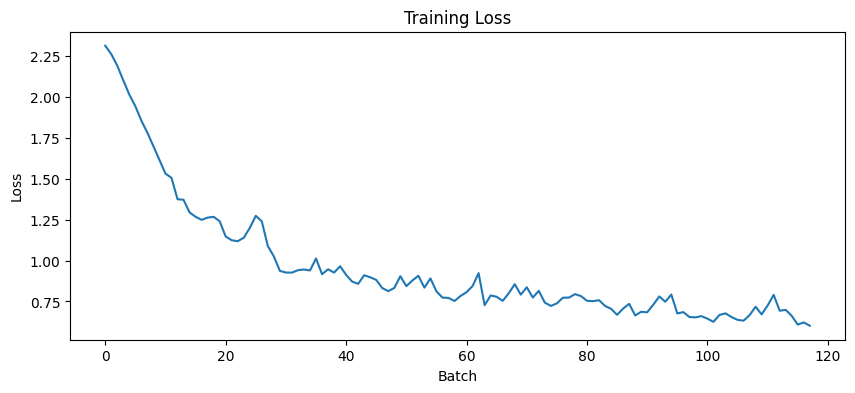

In [58]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(2)

![](img_8.png)

## Updated versions since the lesson

After the lesson we noticed that `contextlib.context_manager` has a surprising "feature" which doesn't let us raise an exception before the `yield`. Therefore we've replaced the context manager with a decorator in this updated version of `Learner`. We have also added a few more callbacks in `one_epoch()`.

In [ ]:
# =====================================================
# DECORATOR FOR CALLBACK CONTEXT
# =====================================================

class with_cbs:
    """
    Decorator that wraps a method with before/after callbacks.
    
    For a method decorated with @with_cbs('batch'):
    - Calls 'before_batch' callbacks before the method
    - Calls 'after_batch' callbacks after the method
    - Catches Cancel*Exception to control flow
    - Always calls 'cleanup_batch' (even on exception)
    """
    
    def __init__(self, nm):
        self.nm = nm
    
    def __call__(self, f):
        def _f(o, *args, **kwargs):
            try:
                o.callback(f'before_{self.nm}')
                f(o, *args, **kwargs) # here after this is called, o will be the learner
                o.callback(f'after_{self.nm}')
            except globals()[f'Cancel{self.nm.title()}Exception']:
                pass
            finally:
                o.callback(f'cleanup_{self.nm}')
        return _f

In [ ]:
#|export
class Learner():
    def __init__(self, model, dls=(0,), loss_func=F.mse_loss, lr=0.1, cbs=None, opt_func=optim.SGD):
        cbs = fc.L(cbs) # Ensure cbs is a fastcore list (L) to handle None or single items uniformly
        fc.store_attr()

    @with_cbs('batch')
    def _one_batch(self):
        self.predict()
        self.callback('after_predict')
        self.get_loss()
        self.callback('after_loss')
        if self.training:
            self.backward()
            self.callback('after_backward')
            self.step()
            self.callback('after_step')
            self.zero_grad()

    @with_cbs('epoch')
    def _one_epoch(self):
        for self.iter,self.batch in enumerate(self.dl): self._one_batch()

    def one_epoch(self, training):
        self.model.train(training)
        self.dl = self.dls.train if training else self.dls.valid
        self._one_epoch()

    @with_cbs('fit')
    def _fit(self, train, valid):
        for self.epoch in self.epochs:
            if train: self.one_epoch(True)
            if valid: torch.no_grad()(self.one_epoch)(False)

    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = fc.L(cbs)
        # `add_cb` and `rm_cb` were added in lesson 18
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            if lr is None: lr = self.lr
            if self.opt_func: self.opt = self.opt_func(self.model.parameters(), lr)
            self._fit(train, valid)
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def __getattr__(self, name):
        if name in ('predict','get_loss','backward','step','zero_grad'): return partial(self.callback, name)
        raise AttributeError(name)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training

accuracy	loss	epoch	train
0.610	1.158	0	train
0.690	0.823	0	eval
0.745	0.709	1	train
0.749	0.662	1	eval


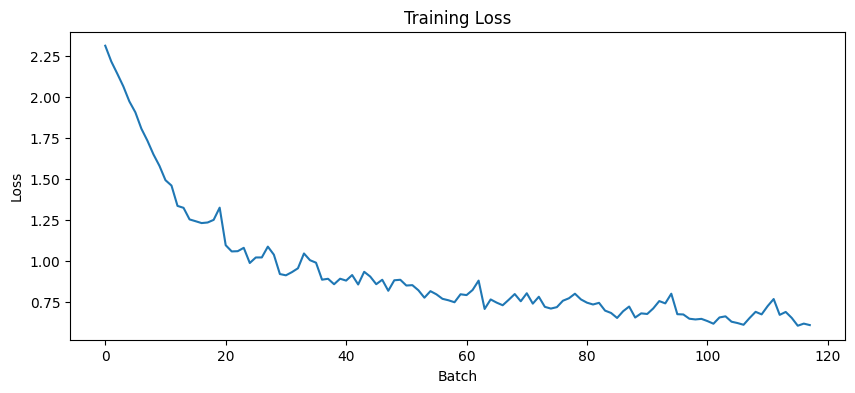

In [61]:
# =====================================================
# TEST FLEXIBLE LEARNER
# =====================================================

model = get_model()

metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]

learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(2)

![](img_9.png)

---

# Part 7: TrainLearner and MomentumLearner

---

Sometimes it's easier to subclass Learner than use callbacks for everything.

In [ ]:
# =====================================================
# TRAINLEARNER: LEARNER WITH BUILT-IN TRAINING LOGIC
# =====================================================

class TrainLearner(Learner):
    """
    Learner with training logic built into the class.
    
    Instead of using TrainCB, the training methods are
    defined directly on the Learner.
    
    This is simpler when you don't need to swap training strategies.
    """
    
    def predict(self):
        """Forward pass."""
        self.preds = self.model(self.batch[0])
    
    def get_loss(self):
        """Compute loss."""
        self.loss = self.loss_func(self.preds, self.batch[1])
    
    def backward(self):
        """Backpropagation."""
        self.loss.backward()
    
    def step(self):
        """Optimizer step."""
        self.opt.step()
    
    def zero_grad(self):
        """Reset gradients."""
        self.opt.zero_grad()

# How Is TrainLearner Different from Learner, and What Is It Trying to Show?

---

## The Problem TrainLearner Solves

In the Flexible Learner, when `one_epoch` calls `self.predict()`, the Learner class doesn't actually have a method called `predict`. So Python goes through a long chain to make it work:

```
self.predict()
│
├── Step 1: Python looks for 'predict' on the Learner instance → not found
├── Step 2: Python looks for 'predict' on the Learner class   → not found
├── Step 3: Python looks in parent classes                     → not found
├── Step 4: Python calls __getattr__('predict')
│           → returns partial(self.callback, 'predict')
├── Step 5: The () calls the returned function
│           → self.callback('predict')
│           → run_cbs loops through all callbacks
│           → finds TrainCB.predict
│           → TrainCB.predict(learn): learn.preds = learn.model(learn.batch[0])
```

Five steps just to do `self.preds = self.model(self.batch[0])`. This indirection is powerful (any callback can override `predict`), but it's also complex.

TrainLearner asks: **what if we skip all that and just define the methods directly?**

---

## What TrainLearner Does

TrainLearner inherits from Learner and defines the five "ghost methods" as real methods on the class:

```python
class TrainLearner(Learner):

    def predict(self):
        self.preds = self.model(self.batch[0])

    def get_loss(self):
        self.loss = self.loss_func(self.preds, self.batch[1])

    def backward(self):
        self.loss.backward()

    def step(self):
        self.opt.step()

    def zero_grad(self):
        self.opt.zero_grad()
```

These are the exact same operations that TrainCB performs — but now they live directly on the class instead of in a separate callback.

---

## What Changes at Runtime

Now when `one_epoch` calls `self.predict()`, Python finds `predict` directly on the TrainLearner class through normal attribute lookup:

```
self.predict()
│
├── Check 1: instance attributes (self.__dict__)  → not there
├── Check 2: CLASS attributes (TrainLearner)       → FOUND! predict is defined here ✅
│            Python stops here. Done.
├── Check 3: parent classes (Learner)              → never reached
└── Check 4: __getattr__                           → never called
```

Two steps instead of five. `__getattr__` is **completely bypassed**. No `partial`, no `self.callback('predict')`, no `run_cbs` searching through callbacks — the method just runs directly.

This is because of Python's attribute lookup order. `__getattr__` is only called as a **last resort** — after checking the instance, the class, and all parent classes. Since TrainLearner defines `predict` as a real class method, Python finds it at Check 2 and never falls through to Check 4.

---

## The Practical Consequence: No TrainCB Needed

With the base Learner, you need TrainCB in your callback list to provide the training logic:

```python
# With Learner — TrainCB is REQUIRED (it defines predict, get_loss, backward, step, zero_grad)
cbs = [TrainCB(), DeviceCB(), MetricsCB(), ProgressCB()]
learn = Learner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(2)
```

With TrainLearner, the training logic is built into the class, so TrainCB is unnecessary:

```python
# With TrainLearner — no TrainCB needed (the class itself defines the training methods)
cbs = [DeviceCB(), MetricsCB(), ProgressCB()]
learn = TrainLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(2)
```

Both produce identical training behavior. The difference is where the training logic lives.

---

## What the Notebook Is Demonstrating: A Design Tradeoff

The notebook shows both approaches side by side to make an important software design point: the callback architecture is a **choice**, not a requirement. There are two valid ways to structure the training logic:

**Approach A: Learner + TrainCB (callback-based)**

The training steps live in a callback (TrainCB). The Learner itself has no opinion about how to predict, compute loss, etc. — it dispatches events through `__getattr__` → `callback()` → `run_cbs`, and whatever callback defines the method handles it.

**Approach B: TrainLearner (class-based)**

The training steps live directly on the class as normal Python methods. No callback dispatch needed. Simpler and more direct.

Here's the tradeoff:

| | Learner + TrainCB (Approach A) | TrainLearner (Approach B) |
|---|---|---|
| **Training logic lives in** | A callback object (TrainCB) | The class itself |
| **Swappable at runtime?** | **Yes** — pass a different callback to `fit()` | **No** — hardcoded in the class definition |
| **Simpler to understand?** | No — requires understanding `__getattr__`, `partial`, `run_cbs` | **Yes** — normal Python methods, nothing magic |
| **Need TrainCB in cbs?** | Yes | No |
| **Mix training strategies per run?** | **Yes** — different callbacks for different `fit()` calls | Only by creating another subclass |
| **Code path for `self.predict()`** | `__getattr__` → `partial` → `callback` → `run_cbs` → TrainCB | Direct method call on the class |

**When to use which:**

- Use **Learner + TrainCB** when you need maximum flexibility — when you might swap training strategies at runtime, mix different callbacks for different runs, or when building a framework that others will extend with their own callbacks.

- Use **TrainLearner** when your training logic is fixed and you want simpler, more readable code — when you know exactly how training will work and don't need to swap it out.

---

## Why This Sets Up MomentumLearner

The notebook introduces TrainLearner not just to show the tradeoff — but to set up what comes next. Immediately after TrainLearner, the notebook defines:

```python
class MomentumLearner(TrainLearner):

    def __init__(self, model, dls, loss_func, lr, cbs, opt_func=optim.SGD, mom=0.85):
        self.mom = mom
        super().__init__(model, dls, loss_func, lr, cbs, opt_func)

    def zero_grad(self):
        with torch.no_grad():
            for p in self.model.parameters():
                p.grad *= self.mom
```

MomentumLearner inherits from TrainLearner and overrides **just one method**: `zero_grad`. Instead of zeroing the gradients (the standard behavior), it multiplies them by a momentum factor (0.85). This means 85% of the previous batch's gradient direction is carried forward into the next batch, which helps the optimizer build up speed in consistent directions and converge faster.

Everything else — `predict`, `get_loss`, `backward`, `step` — is inherited unchanged from TrainLearner. MomentumLearner only changes the one piece it cares about.

This demonstrates the **subclassing approach** to customization: instead of writing a custom callback to override `zero_grad`, you subclass TrainLearner and override the method directly. It's the class-based alternative to the callback-based approach.

**The three ways to customize training, as demonstrated in the notebook:**

```
1. CALLBACK APPROACH (most flexible):
   Learner + TrainCB + custom callback that also defines zero_grad
   → run_cbs calls both; ordering via 'order' attribute

2. SUBCLASS APPROACH (simplest):
   MomentumLearner(TrainLearner) — override zero_grad directly
   → normal Python inheritance, no callbacks needed for this part

3. MIXED APPROACH (practical):
   TrainLearner with some callbacks for monitoring (MetricsCB, ProgressCB)
   and training logic in the class itself
   → training steps are direct methods; observation/logging stays in callbacks
```

The notebook walks through all three to show that the callback system and class inheritance are complementary tools, not competitors. You can use whichever fits your situation — or combine them.

In [ ]:
# =====================================================
# MOMENTUMLEARNER: LEARNER WITH MOMENTUM
# =====================================================

class MomentumLearner(TrainLearner):
    """
    Learner that implements momentum manually.
    
    Momentum helps optimization by:
    - Keeping some of the previous gradient direction
    - Smoothing out noisy gradients
    - Helping escape local minima
    
    Instead of zeroing gradients, we multiply by momentum factor.
    This keeps a weighted average of past gradients.
    
    Arguments:
        mom - Momentum factor (default 0.85)
              Higher = more of previous gradient kept
    """
    
    def __init__(self, model, dls, loss_func, lr=None, cbs=None, 
                 opt_func=optim.SGD, mom=0.85):
        self.mom = mom
        super().__init__(model, dls, loss_func, lr, cbs, opt_func)

    def zero_grad(self):
        """
        Instead of zeroing gradients, multiply by momentum.
        
        This keeps a fraction of the previous gradient:
        new_grad = current_grad + mom * old_grad
        """
        with torch.no_grad():
            for p in self.model.parameters():
                p.grad *= self.mom

accuracy	loss	epoch	train
0.660	0.977	0	train
0.792	0.587	0	eval
0.819	0.518	1	train
0.820	0.512	1	eval


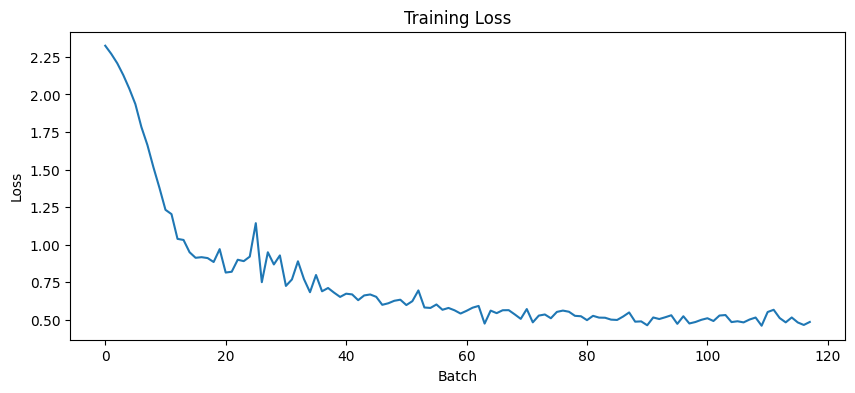

In [64]:
# =====================================================
# TEST MOMENTUM LEARNER
# =====================================================

# Note: No TrainCB needed since training logic is in the class
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [DeviceCB(), metrics, ProgressCB(plot=True)]

learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=0.1, cbs=cbs)
learn.fit(2)

![](img_10.png)

---

# Part 8: Learning Rate Finder

---

The **Learning Rate Finder** is a technique to automatically find a good learning rate.

## How It Works

1. Start with a very small learning rate
2. Train for one batch
3. Increase the learning rate exponentially
4. Repeat until loss explodes
5. Plot loss vs learning rate
6. Choose LR where loss is still decreasing (before minimum)

> **🎮 Interactive — the Learning Rate Finder, in 3D.** The LR finder multiplies the learning rate by ~1.3 every batch. Orbit the 3D loss landscape and watch the ball: frozen at tiny LRs, rolling smoothly in the sweet spot, then flung up the wall as the LR explodes — mirrored in the classic loss-vs-LR curve. Press **Suggest LR** for the rule-of-thumb pick.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/lr_finder_3d.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. LR Finder in 3D: exponential LR sweep on a loss landscape.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/lr_finder_3d.html", height="820px")

## LRFinderCB

In [ ]:
class LRFinderCB(Callback):
    def __init__(self, lr_mult=1.3): fc.store_attr()
    
    def before_fit(self, learn):
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if loss > self.min*3: raise CancelFitException()
        for g in learn.opt.param_groups: g['lr'] *= self.lr_mult

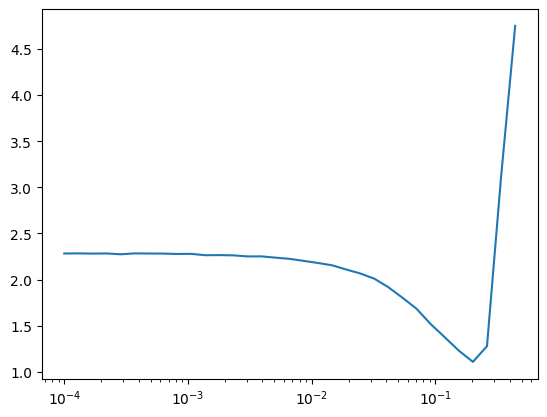

In [67]:
lrfind = LRFinderCB()
cbs = [DeviceCB(), lrfind]
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=1e-4, cbs=cbs)
learn.fit(1)
plt.plot(lrfind.lrs, lrfind.losses)
plt.xscale('log')

![](img_11.png)

[ExponentialLR](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html#torch.optim.lr_scheduler.ExponentialLR)

In [68]:
# =====================================================
# LEARNING RATE FINDER CALLBACK
# =====================================================

# Import the ExponentialLR tool from PyTorch's scheduler module to change the LR over time
from torch.optim.lr_scheduler import ExponentialLR

# Define a class named LRFinderCB that inherits from the Callback base class
class LRFinderCB(Callback):
    """
    Callback that implements the learning rate finder algorithm.

    Arguments:
        gamma    - Factor to multiply LR by after each batch (default 1.3)
        max_mult - Stop when loss exceeds min_loss * max_mult (default 3)

    After running, check:
        - lrfinder.lrs: list of learning rates tried
        - lrfinder.losses: corresponding losses
    """

    # The __init__ function runs when we first create an instance of this class
    def __init__(self, gamma=1.3, max_mult=3):
        # Store gamma (the increase factor) as an internal property of the object
        self.gamma = gamma
        # Store max_mult (the explosion threshold) as an internal property of the object
        self.max_mult = max_mult

    # The before_fit method is called by the Learner once before training begins
    def before_fit(self, learn):
        """
        Initialize LR finder.

        Creates an ExponentialLR scheduler that multiplies
        the learning rate by gamma after each step.
        """
        # Initialize the PyTorch scheduler to multiply the optimizer's LR by gamma every step
        self.sched = ExponentialLR(learn.opt, self.gamma)
        # Create an empty list to store the history of learning rates used
        self.lrs = []
        # Create an empty list to store the history of losses calculated
        self.losses = []
        # Set the starting minimum loss to infinity (a very high value)
        self.min = math.inf

    # The after_batch method is called by the Learner after every batch is processed
    def after_batch(self, learn):
        """
        After each batch:
        1. Record the learning rate and loss
        2. Check if loss has exploded
        3. Increase learning rate
        """
        # Check if the model is currently in validation mode (not training)
        if not learn.training:
            # If it's validation, skip the rest of the epoch processing
            raise CancelEpochException()

        # Get the current learning rate from the optimizer and add it to our list
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        # Convert the current loss to a CPU-based number for easier handling
        loss = to_cpu(learn.loss)
        # Add the current loss value to our history of losses
        self.losses.append(loss)

        # Compare the current loss to the lowest loss we've seen so far
        if loss < self.min:
            # If the current loss is lower, update our minimum loss record
            self.min = loss

        # Check if the loss is invalid (NaN) or has increased too much compared to the minimum
        if math.isnan(loss) or (loss > self.min * self.max_mult):
            # If the loss has 'exploded', stop the entire training process immediately
            raise CancelFitException()

        # Call the scheduler to update (increase) the learning rate for the next batch
        self.sched.step()

    # The cleanup_fit method is called after training finishes or is cancelled
    def cleanup_fit(self, learn):
        """Plot the results."""
        # Create a new plot window with a width of 10 units and height of 4 units
        plt.figure(figsize=(10, 4))
        # Plot the learning rates on the horizontal axis and losses on the vertical axis
        plt.plot(self.lrs, self.losses)
        # Set the horizontal axis to a logarithmic scale to show wide ranges of LR clearly
        plt.xscale('log')
        # Add a text label to the horizontal axis
        plt.xlabel('Learning Rate (log)')

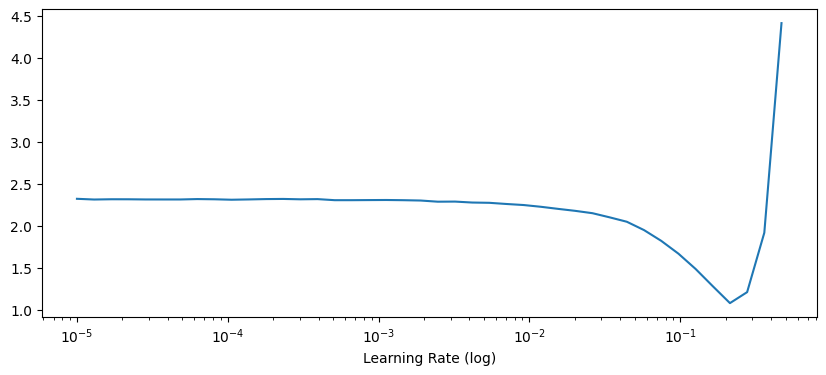

In [69]:
# =====================================================
# RUN LEARNING RATE FINDER
# =====================================================

cbs = [DeviceCB()]
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=1e-5, cbs=cbs)

# Add LRFinderCB just for this run
learn.fit(3, cbs=[LRFinderCB()])

![](img_12.png)

**How to read the plot:**

1. Look for where the loss starts decreasing rapidly
2. Choose a learning rate **before** the minimum (where it's still decreasing)
3. A good choice is usually 1/10 of the LR where loss is minimum

In this plot, a learning rate around 0.01 - 0.1 would be a good choice.

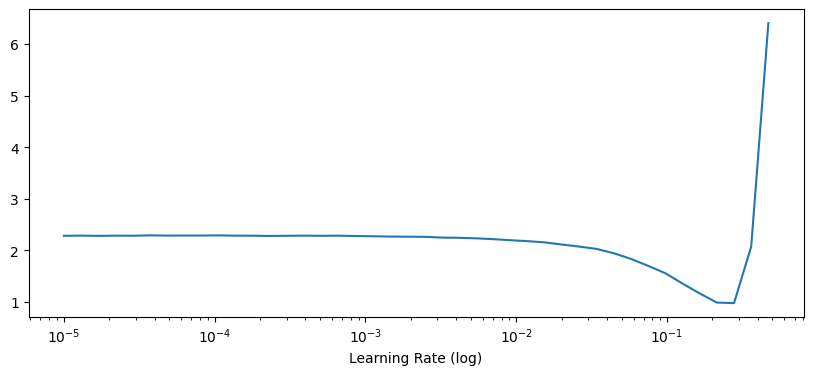

In [70]:
# =====================================================
# CONVENIENT LR_FIND METHOD
# =====================================================

def lr_find(learner, gamma=1.3, max_mult=3, start_lr=1e-5, max_epochs=10):
    """
    Convenience function to run the learning rate finder.
    
    Arguments:
        learner    - The Learner object
        gamma      - LR multiplier per batch
        max_mult   - Stop when loss > min_loss * max_mult
        start_lr   - Initial learning rate
        max_epochs - Maximum epochs to run
    """
    learner.fit(max_epochs, lr=start_lr, cbs=[LRFinderCB(gamma=gamma, max_mult=max_mult)])

# Test it
learn = MomentumLearner(get_model(), dls, F.cross_entropy, cbs=[DeviceCB()])
lr_find(learn)

`lr_find` was added in lesson 18. It's just a shorter way of using `LRFinderCB`.

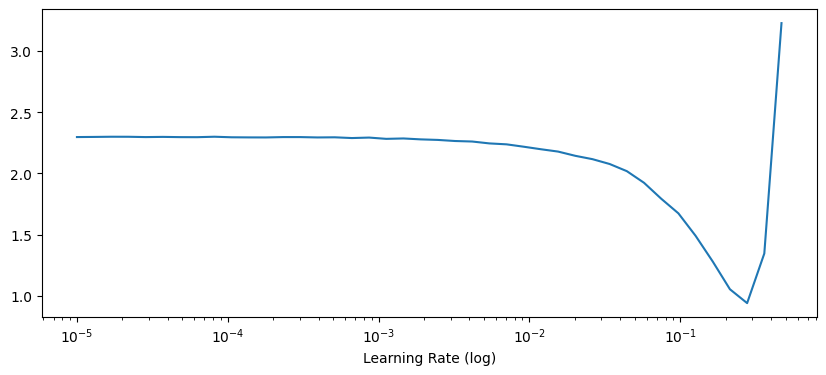

In [71]:
lr_find(MomentumLearner(get_model(), dls, F.cross_entropy, cbs=cbs))

![](img_13.png)

## Export

In [72]:
# import nbdev; nbdev.nbdev_export()

---

# Summary

---

## Key Concepts Learned

### The Learner Class
- **Encapsulates** the training loop
- **Components**: model, data loaders, loss function, optimizer
- **Methods**: fit(), one_epoch(), one_batch()

### Callbacks
- **Purpose**: Customize training without modifying Learner code
- **Hook points**: before/after fit, epoch, batch
- **Cancel exceptions**: Control flow (early stopping, etc.)
- **Order**: Lower order runs first

### Important Callbacks

| Callback | Purpose |
|----------|--------|
| **DeviceCB** | Move model and data to GPU |
| **MetricsCB** | Track and log metrics |
| **ProgressCB** | Show progress bars and plots |
| **TrainCB** | Core training logic (predict, loss, backward) |
| **SingleBatchCB** | Stop after one batch (debugging) |
| **LRFinderCB** | Find optimal learning rate |

### Metrics
- Track values across batches
- Weighted averaging for correct epoch metrics
- Built-in: loss, accuracy

### MomentumLearner
- Implements momentum by keeping fraction of previous gradients
- Helps optimization converge faster

### Learning Rate Finder
- Automatically find good learning rate
- Start small, increase exponentially
- Choose LR before loss minimum

---

## Design Patterns Used

| Pattern | Usage |
|---------|-------|
| **Callback** | Extensibility without modification |
| **Template Method** | Define skeleton, let subclasses fill in |
| **Decorator** | @with_cbs wraps methods with callbacks |
| **Strategy** | TrainCB encapsulates training algorithm |

---